# CH4 Time Series Modeling
**Objective**: Develop a SARIMA model for forecasting atmospheric methane concentration

## Input data
'data/processed/df_model.csv'

## Stages
1. train/test split
2. test data transformations (differencing and log) and perform residuals analyses
3. Auto-ARIMA parameter search
4. TimeSeriesSplit CV parameter search on out-of-sample performance
5. Residuals analyses on best models
6. SARIMA model selection

In [1]:
# enable auto-reloading of imported modules
%load_ext autoreload
%autoreload 2

# ensure src/imports work
import sys
sys.path.append('../')

# Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import linregress, mannwhitneyu
from scipy.stats import boxcox 
from pmdarima import auto_arima
from pmdarima.arima.utils import ndiffs, nsdiffs
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan, het_white, het_arch
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tqdm import tqdm
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
import time
from arch import arch_model
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from src.preprocessing import GasPreprocessor
from src.model_evaluation import make_fourier_terms, rolling_origin_evaluation, evaluate_models_tscv, in_sample_resid_analysis, out_of_sample_resid_analysis, summarize_model_assumptions
print('GasPreprocessor imported successfully!')
print('model_evaluation functions imported successfully!')

GasPreprocessor imported successfully!
model_evaluation functions imported successfully!


# Load the data

In [3]:
# load cleaned data

df = pd.read_csv(
    '../data/processed/df_model.csv',
    index_col=0,
    parse_dates=True,
    dtype={'value': float, 'value_unc': float, 'qcflag': str}
)

print(f'loaded {len(df)} records')
display(df.head())

loaded 1746 records


,value,value_unc,qcflag
1991-01-04,1719.845,2.71,...
1991-01-11,1736.940,2.71,...
1991-01-18,1728.335,2.71,...
1991-01-25,1716.080,2.71,...
1991-02-01,1727.430,2.71,...


In [4]:
df.tail()

,value,value_unc,qcflag
2024-11-25,1970.8250,0.575,...
2024-12-06,1959.4500,0.575,...
2024-12-17,1923.0025,0.575,...
2024-12-24,1952.3800,0.575,...
2024-12-31,1977.4450,0.575,.S.


## Resample full dataset

The full dataset will be resampled to weekly ('W') ahead of train/test split and subsequent preprocessing because:
1.  The mode of the observations after aggregation (see notebook 2_ch4_eda) is 52 observations/year
2.  Previous efforts to resample the train and test sets separtely, as part of the GasPreprocessor class functionality, has led to problems with the gap between the last train set value and the first test set value.  I have experienced gaps that are either too great (2 week gap) or are non-existant such that the last train datapoint date is the same as the first test set datapoint date, which is data leakage.

In [5]:
df_float = df[['value', 'value_unc']].resample('W').mean()
df_obj = df[['qcflag']].resample('W').agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)

df_resamp = pd.concat([df_float, df_obj], axis=1)

In [6]:
df_resamp.head()

,value,value_unc,qcflag
1991-01-06,1719.845,2.71,...
1991-01-13,1736.940,2.71,...
1991-01-20,1728.335,2.71,...
1991-01-27,1716.080,2.71,...
1991-02-03,1727.430,2.71,...


In [7]:
# compare indexes to note change in datetime indexes and frequency

print('df first 5 indexes:')
print(df.index[:5])
print('\ndf_resamp firt 5 indexes:')
print(df_resamp.index[:5])

df first 5 indexes:
DatetimeIndex(['1991-01-04', '1991-01-11', '1991-01-18', '1991-01-25',
               '1991-02-01'],
              dtype='datetime64[ns]', freq=None)

df_resamp firt 5 indexes:
DatetimeIndex(['1991-01-06', '1991-01-13', '1991-01-20', '1991-01-27',
               '1991-02-03'],
              dtype='datetime64[ns]', freq='W-SUN')


In [8]:
# inspect resampled data for NaNs
print('Number of NaN values in each df_samp feature')
print('value: ', df_resamp['value'].isna().sum())
print('value_unc: ', df_resamp['value_unc'].isna().sum())
print('qcflag: ', df_resamp['qcflag'].isna().sum())

Number of NaN values in each df_samp feature
value:  47
value_unc:  47
qcflag:  47


## Rename 'value' to 'CH4' for GasPreprocessor class

In [9]:
df_resamp = df_resamp.rename(columns={'value': 'CH4'})

In [10]:
df_resamp.head()

,CH4,value_unc,qcflag
1991-01-06,1719.845,2.71,...
1991-01-13,1736.940,2.71,...
1991-01-20,1728.335,2.71,...
1991-01-27,1716.080,2.71,...
1991-02-03,1727.430,2.71,...


# Train/test split

## Split the data and inspect

In [11]:
# split by calendar year

# ensure that the index is a DatetimeIndex and sorted
df_resamp_sort_ind = df_resamp.sort_index()
assert isinstance(df_resamp_sort_ind.index, pd.DatetimeIndex) 

train = df_resamp_sort_ind[df_resamp_sort_ind.index.year < 2024]
test = df_resamp_sort_ind[df_resamp_sort_ind.index.year >= 2024]

In [12]:
print(f'Train data: {train.shape[0]} data points, from {train.index.min()} to {train.index.max()}')
print(f'Test data: {test.shape[0]} data points, from {test.index.min()} to {test.index.max()}')

Train data: 1722 data points, from 1991-01-06 00:00:00 to 2023-12-31 00:00:00
Test data: 53 data points, from 2024-01-07 00:00:00 to 2025-01-05 00:00:00


In [13]:
# check the data frequency

print(f'Train data frequency: {train.index.freq}')
print(f'Test data frequency: {test.index.freq}')

Train data frequency: <Week: weekday=6>
Test data frequency: <Week: weekday=6>


<Week: weekday=6> == W-SUN

## Inspect the gap between train and test sets

In [14]:
# Check the last training point vs first test point

print('Last training date:', train.index[-1])
print('First test date:', test.index[0])
print('\nGap between train end and test start:', test.index[0] - train.index[-1])

Last training date: 2023-12-31 00:00:00
First test date: 2024-01-07 00:00:00

Gap between train end and test start: 7 days 00:00:00


## Visually confirm the data split

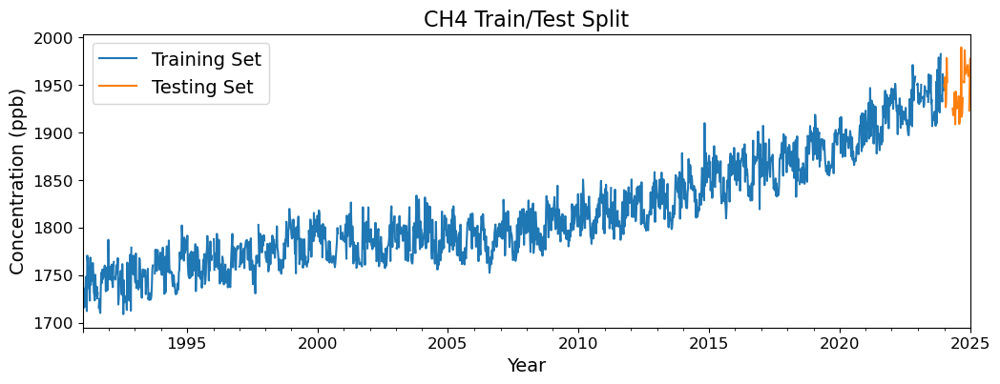

In [15]:
# visually confirm the data split

fig, ax = plt.subplots(figsize=(12,4))
train['CH4'].plot(ax=ax, label='Training Set')
test['CH4'].plot(ax=ax, label='Testing Set')

ax.set_title('CH4 Train/Test Split', fontsize=16)
ax.set_ylabel('Concentration (ppb)', fontsize=14)
ax.set_xlabel('Year', fontsize=14)
ax.tick_params(axis='both', labelsize=12)
ax.legend(fontsize=14)
plt.show()

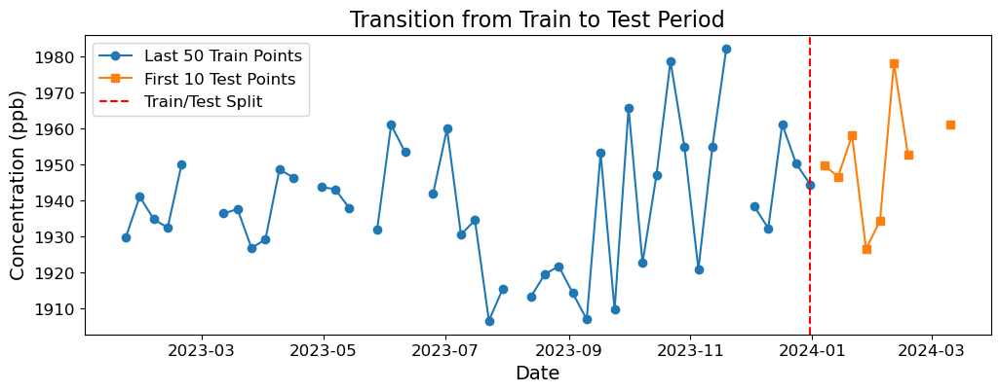

In [16]:
# Plot the transition from train to test

plt.figure(figsize=(12,4))
plt.plot(train['CH4'].index[-50:], train['CH4'].values[-50:], 
         label='Last 50 Train Points', marker='o')
plt.plot(test['CH4'].index[:10], test['CH4'].values[:10],
         label='First 10 Test Points', marker='s')
plt.axvline(x=train['CH4'].index[-1], color='red', linestyle='--', 
            label='Train/Test Split')

plt.title('Transition from Train to Test Period', fontsize=16)
plt.ylabel('Concentration (ppb)', fontsize=14)
plt.xlabel('Date', fontsize=14)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.legend(loc='upper left',fontsize=12)
plt.show()

# Preprocessing and EDA of train set


[INFO] Fitting preprocessing for CH4
[INFO] Starting fit() for CH4 | Resample freq = None (using existing index)
Raw data: 1722 points, 37 NaNs
Trimmed data: 1722 points, 37 NaNs
Data range after trimming: 1991-01-06 00:00:00 to 2023-12-31 00:00:00
After resampling: 1722 points, 37 NaNs
[INFO] Found 30 potential outliers using robust STL residuals.
After outlier removal: 1722 points, 67 NaNs
After smoothing: 1722 points, 0 NaNs
After interpolation: 1722 points, 0 NaNs


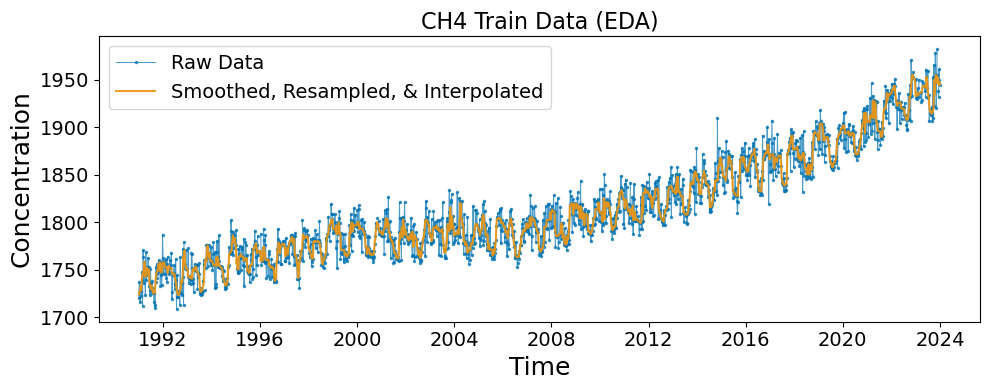

[INFO] EDA stationarity tests on processed data:
ADF and KPSS tests for Processed Data:
ADF statistic -0.3406
ADF p-value 0.9196
KPSS statistic 5.8061
KPSS p-value 0.0100
the Processed Data time series is non-stationary according to ADF and KPSS tests.



C:\Users\aplor\Documents\GitHub\greenhouse-gas-forecasting\notebooks\..\src\preprocessing.py:498: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c')


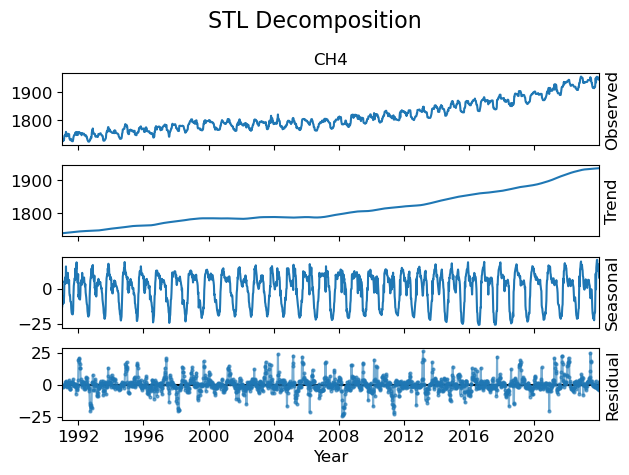

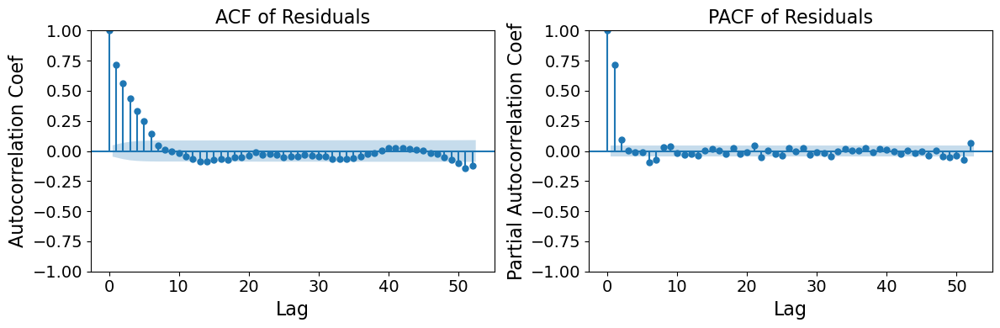


Heteroscedasticity Tests of Residuals
Breusch-Pagan p-value: 0.4836
No heteroscedasticity detected (Breusch-Pagan test)

White Test p-value: 0.7617
No heteroscedasticity detected (White test)
Adjusting test set dates to be contiguous with train set
[INFO] Dropping overlapping test point at 2023-12-31 00:00:00 (train end = 2023-12-31 00:00:00)


In [17]:
# fit and transform the training data to the GasPreprocessor class
# transform the test data using the fitted preprocessor

preprocessor = GasPreprocessor(
    gas_name='CH4', 
    iqr_factor=3.0,
    seasonal_period=52,
    do_eda=True
)

train_preprocessed = preprocessor.fit_transform(
    train[['CH4']], 
    custom_title = 'CH4 Train Data (EDA)'
)

# transform the test data using the fitted preprocessor
test_preprocessed = preprocessor.transform(test[['CH4']])

**Interpretation of STL decomposition**

- ADF/KPSS tests for stationarity:  Both tests indicate non-stationarity, which isn't surprising considering the strong positive trend.  However, the high ADF test p value suggests the presence of a unit root, which will likely require non-seasonal differencing.  
- Trend:  The positive trend of the preprocessed train data is consistent with that of the raw, full length data (see previous notebook, 2_ch4_eda_clean).  I will characterize the slope of the train_preprocessed data and determine if differencing is required to stationarize the data (is the global trend trend-stationary or differenc-stationary?). If the data is trend-stationary, then I could set the SARIMA model trend paramenter to 't' to simply subtract the linear increase in CH4 concentration.  However, a difference-stationary trend will require non-seasonal differencing (d).  
- Seasonal: the seasonal oscillations appear to be mostly uniform, likely additive and not multiplicative (see notebook 3_ch4_preprocessing_eda).  Log transformation may not be necessary.  Seasonal differencing (D) to handle drifts in seasonal peaks will be investigated by ACF/PACF plots and other statistical tests.
- Residual: Breusch-Pagan and White tests indicate homoscedastic residuals.  However, they appear to have volatility and may require modeling for reliable forecast confidence intervals (e.g. bootstrapping or GARCH).  Conditional heteroscedasticity will be evaluated with Engle's ARCH test on model residuals .  
- The slow decay in signficant ACF lags (1-6) and sharp cut off at PACF lag 1 suggests an AR(p) process, e.g. p = 1-6. 
- Significant spikes at lag 52 of both ACF and PACF plots could indicate a seasonal AR/MA process, e.g. P = 1, Q = 1-2.  

In [18]:
train_preprocessed.tail()

2023-12-03    1952.61250
2023-12-10    1947.39875
2023-12-17    1944.51750
2023-12-24    1944.51750
2023-12-31    1947.39875
Freq: W-SUN, Name: CH4, dtype: float64

In [19]:
test_preprocessed.head()

2024-01-07    1946.68750
2024-01-14    1948.25750
2024-01-21    1949.82750
2024-01-28    1949.77875
2024-02-04    1952.87000
Freq: W-SUN, Name: CH4, dtype: float64

In [20]:
# check length of each data series

print(f'length of train_preprocessed: {len(train_preprocessed)}')
print(f'Number of NaNs in train_preprocessed: {train_preprocessed.isna().sum()}')
print(f'length of test_preprocessed: {len(test_preprocessed)}')
print(f'Number of NaNs in test_preprocessed: {test_preprocessed.isna().sum()}')

length of train_preprocessed: 1722
Number of NaNs in train_preprocessed: 0
length of test_preprocessed: 52
Number of NaNs in test_preprocessed: 0


## Investigate trend of preprocessed train data (train_preprocessed)

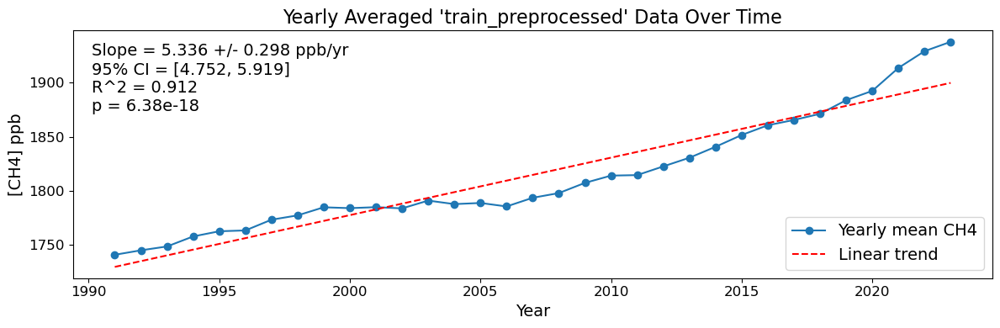

In [21]:
# convert the numpy object to a pandas DataFrame
train_preprocessed_df = pd.DataFrame(train_preprocessed, columns=['index', 'CH4'])

# calculate the yearly average
yearly_avg_df = train_preprocessed_df['CH4'].groupby(train_preprocessed_df.index.year).mean()

# calculate the slope
gas_trend_data = []

x = yearly_avg_df.index
y = yearly_avg_df

# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x,y)

# predicted line
y_pred = intercept + slope * x

# confidence intervals
ci_lower = slope - 1.96 * std_err
ci_upper = slope + 1.96 * std_err

gas_trend_data_df = pd.DataFrame(gas_trend_data)

# plot the data
plt.figure(figsize=(12,4))
plt.plot(x, y, 'o-', label='Yearly mean CH4')
plt.plot(x, y_pred, 'r--', label='Linear trend')
plt.title("Yearly Averaged 'train_preprocessed' Data Over Time", fontsize=16)
plt.ylabel('[CH4] ppb', fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)

# metrics text box
textstr = '\n'.join((
    f'Slope = {slope:.3f} +/- {std_err:.3f} ppb/yr',
    f'95% CI = [{ci_lower:.3f}, {ci_upper:.3f}]',
    f'R^2 = {r_value**2:.3f}',
    f'p = {p_value:.2e}'
))

# place box on the figure
plt.gca().text(
    0.02, 0.95, textstr, transform=plt.gca().transAxes,
    fontsize=14, verticalalignment='top',
    bbox=dict(boxstyle='square,pad=0.4', facecolor='white', edgecolor='none')
)

plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

**Interpretation of trend slope**

- The deterministic trend of the train_preprocessed data explains 91.2% of the variability in the data and is statistically significant.
- The slope does not deviate much from the full un-preprocessed data:
  - slope = 5.508 +/- 0.295 ppb/year
  - R^2 = 0.916
  - p = 9.22e-19

Since 91.2% of the data variance is explained by a deterministic trend, and, therefore only 8.8% of the variance is due to stochastic processes, A SARIMA model with trend parameter = 't' should be sufficient to make the data stationary.  

## Determine if seasonal cycles are multiplicative

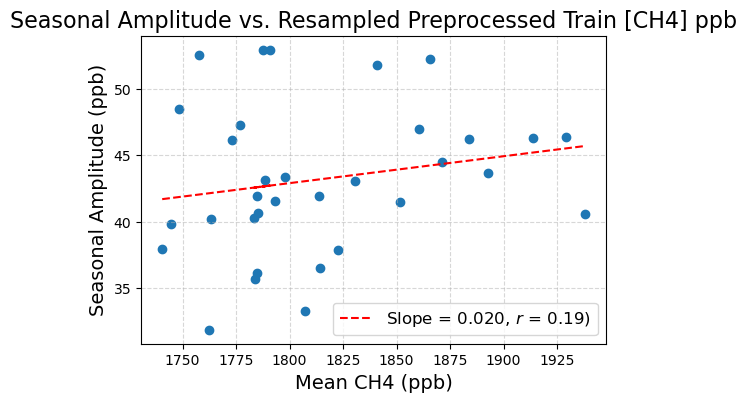

In [22]:
# plot amplitude of the seasonal cycle vs mean CH4 concentration for the preprocessed CH4 train data.  
# if the seasonal cycles do not scale with the long term mean, then the cycles are additive
# if the seasonal cycles scale with the mean, then the cycles are multiplicative 

# convert the pandas series to a DataFrame
train_prepro_df = train_preprocessed.to_frame(name='CH4')
train_prepro_df['year'] = train_prepro_df.index.year

# Group by year to compute mean and amplitude
yearly = train_prepro_df.groupby('year')['CH4'].agg(['mean', 'max', 'min'])
yearly['amplitude'] = yearly['max'] - yearly['min']

# calculate the regression line
x = yearly['mean'].values
y = yearly['amplitude'].values
m, b = np.polyfit(x, y, 1)

# calculate the correlation coefficient (r)
corr = yearly['mean'].corr(yearly['amplitude'])

# Scatter plot: mean vs amplitude
plt.figure(figsize=(6,4))
plt.scatter(yearly['mean'], yearly['amplitude'])
plt.plot(x, m*x + b, 
         color='red', 
         linestyle='--', 
         label=f'Slope = {m:.3f}, $r$ = {corr:.2f})')
plt.xlabel('Mean CH4 (ppb)', fontsize=14)
plt.ylabel('Seasonal Amplitude (ppb)', fontsize=14)
plt.title('Seasonal Amplitude vs. Resampled Preprocessed Train [CH4] ppb', fontsize=16)

# plt.plot(corr)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right', fontsize=12)
plt.show()

**Interpretation of the seasonal amplitude vs mean preprocessed CH4 plot:**

- cleaned, full length data: slope = 0.059, r = 0.36 (see notebook 3_ch4_preprocessing_eda)
- resampled preprocessed train data: slope = 0.020, r = 0.19

The resampled preprocessed train data is what will be modeled and will focus on these results.  Outlier removal, smoothing and interpolation made seasonal amplitude even more uniform.  

- A slope of 0.020 indicates a weak relationship between seasonal amplitude and mean.
- r = 0.19 and r^2 = 0.036 indicates that the mean explains only 3.6% of the variation in seasonal amplitude

The low values for slope and the correlation coefficient suggests that the seasonality does not need to be modeled as multiplicative (changing variance of the seasonal amplitude with the increasing CH4 concentration).  So, transformation likely won't be necessary.  

## Investigate the need for non-seasonal differencing

- slope, r^2, p value review
- ADF/KPSS review
- ACF/PACF plot and signficiant lags of non-differenced and non-seasonally differenced data
- minimum variance principle 

**Global trend slope review**
- slope = 5.3 +/- 0.3 ppb/year
- R^2 = 0.912
- p = 6.4e-18

**ADF/KPSS tests review**

The following results are copy/pasted here from the GasPreprocessor class analytics (see above):

- ADF test
  - ADF statistic -0.3406
  - ADF p-value 0.9196
<br>
<br>
- KPSS test
  - KPSS statistic 5.8061
  - KPSS p-value 0.0100

the Processed Data time series is non-stationary according to ADF and KPSS tests

**Interpretation**
While the slope R^2 = 0.912 indicates a strong global trend, the ADF and KPSS results indicate the need for differencing.  The ADF test fails to reject the null hypothesis of non-stationarity (presence of a unit root) and the KPSS test rejects the null hyothesis of stationarity.  So, the trend behaves more like a random walk with drift, a stochastic process.  Furthermore, atmospheric CH4 concentration has not followed a simple linear trajectory.  There was a stable period (~ 2000 - 2007) followed by an increase in the concentration rate.  So, a purely deterministic model with a single fixed slope wouldn't model these shifts very well.  

I will inspect the ACF and PACF plots of both non-differenced and differenced data to better understand if differencing is necessary rather than simply subtracting the trend during modeling (trend = 't').  

Original series length: 1722
Non-seasonally differenced series length: 1721

=== Stationarity tests ===

--- Non-Differenced Preprocessed Train Data ---
ADF and KPSS tests for non-differenced:
ADF statistic -0.2679
ADF p-value 0.9299
KPSS statistic 5.8062
KPSS p-value 0.0100
the non-differenced time series is non-stationary according to ADF and KPSS tests.


--- Non-Seasonally Differenced Preprocessed Train Data ---
ADF and KPSS tests for non-seasonally differenced:
ADF statistic -12.4675
ADF p-value 0.0000
KPSS statistic 0.0226
KPSS p-value 0.1000
the non-seasonally differenced time series is likely stationary according to ADF and KPSS tests.



C:\Users\aplor\Documents\GitHub\greenhouse-gas-forecasting\notebooks\..\src\preprocessing.py:498: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c')
C:\Users\aplor\Documents\GitHub\greenhouse-gas-forecasting\notebooks\..\src\preprocessing.py:498: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c')


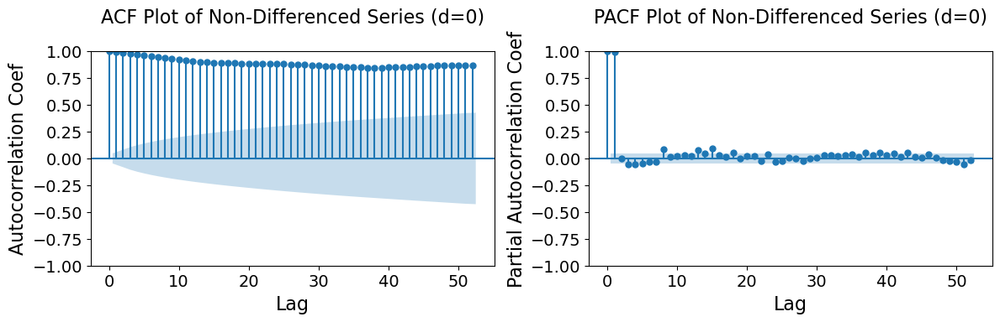

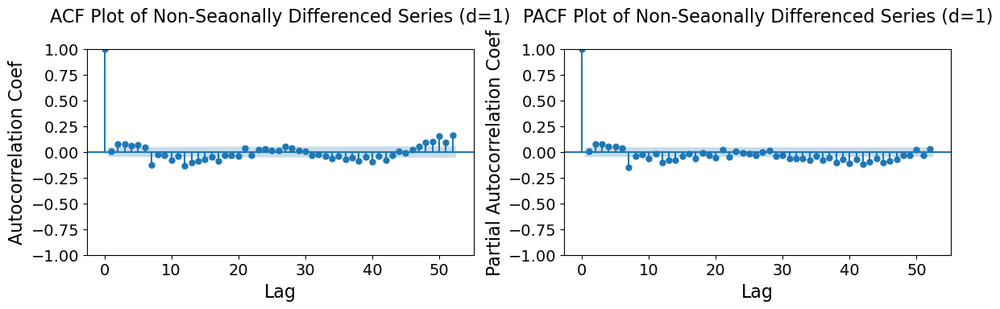

In [23]:
# inspect autocorrelation of non-differenced and non-seasonally differenced preprocessed train data 
# to determine its effectiveness in achieving stationarity 

nsdiffed_series = train_preprocessed.diff(1).dropna()

print(f'Original series length: {len(train_preprocessed)}')
print(f'Non-seasonally differenced series length: {len(nsdiffed_series)}')

# stationarity tests
print('\n=== Stationarity tests ===')
print('\n--- Non-Differenced Preprocessed Train Data ---')
preprocessor._run_stationarity_tests(train_preprocessed, 'non-differenced')

print('\n--- Non-Seasonally Differenced Preprocessed Train Data ---')
preprocessor._run_stationarity_tests(nsdiffed_series, 'non-seasonally differenced')

# plot ACF and PACF
preprocessor.plot_acf_pacf(train_preprocessed, 'Non-Differenced Series (d=0)')
preprocessor.plot_acf_pacf(nsdiffed_series, 'Non-Seaonally Differenced Series (d=1)')


In [24]:
# estimate the need for and number of non-seasonal differences
# with statsmodels "ndiffs"

d = ndiffs(train_preprocessed, test='kpss')
print(f'Estimated non-seasonal differences: d = {d}')

Estimated non-seasonal differences: d = 1


In [25]:
# Verify that d=1 is the correct degree of differencing (minimum variance principle)

# difference the series
nsdiff1 = train_preprocessed.diff().dropna()
nsdiff2 = nsdiff1.diff().dropna()

# determine the variance of each series: d=0, d=1, d=2
var_d0 = np.var(train_preprocessed)
var_d1 = np.var(nsdiff1)
var_d2 = np.var(nsdiff2)

print(f'variance at d=0: {var_d0:.3f}')
print(f'variance at d=1: {var_d1:.3f}')
print(f'variance at d=2: {var_d2:.3f}')

variance at d=0: 2994.229
variance at d=1: 24.075
variance at d=2: 47.706


In [26]:
# non-integer differencing to investigate possible over-differencing and to corroborate 
# d=1 as the best order of differencing.  

diffs = [0, 0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8, 2]
var_vals = {}

def fractional_diff_variance(series, d, threshold=1e-5):
    """Manually apply weights for a specific d to check variance."""
    n = len(series)
    weights = [1.0]
    for k in range(1, n):
        weights.append(-weights[-1] * (d - k + 1) / k)
    weights = np.array(weights)
    
    # Calculate the differentiated values (memory-weighted sum)
    res = np.zeros(n)
    for i in range(n):
        res[i] = np.dot(weights[:i+1], series[i::-1])
    
    return np.var(res[10:]) # Skip warm-up period for accuracy

# Run the loop again with the manual function
var_vals = {d: fractional_diff_variance(train_preprocessed.values, d) for d in diffs}
df_varvals = pd.DataFrame(list(var_vals.items()), columns=['d', 'variance'])
df_varvals

,d,variance
0,0.0,2970.764944
1,0.2,6485.570970
2,0.4,2230.985863
3,0.6,364.053421
4,0.8,49.465046
5,1.0,24.060059
6,1.2,26.598007
7,1.4,29.270871
8,1.6,33.103756
9,1.8,39.170651


**Interpretation of non-seasonal differrencing results**

- ADF and KPSS tests indicate stationarity after non-seasonal differencing (d=1)

ACF and PACF plots:
- ACF plot of non-differenced data shows a very gradual tapering of lags that are all signficicantly out of the CI band.  This is a signature of a unit root.
- Both ACF and PACF plots show significant spikes around lags 7 and 12.  These could indicate a periodic effect or a harmonic of a single seasonal cycle (i.e. 7 and 12 weeks are approximately 2 and 3 month periods).  I will need to consider high order non-seasonal SARIMA orders to clear these autocorrelations (e.g. p or q = 7).
- ACF rule of over-differencing:  If the first lag (lag 1) of the differenced series is not strongly negative (~ -0.5 or lower), then the data is not likely over-differenced.
- ACF plot of differenced data shows a significant spike around lag 52, which is absent in the PACF plot suggesting a seasonal MA (moving average) term, i.e. Q = 1.

best differencing order:
- two methods to determine the best differencing order both agree on d=1.
- fractional differencing does not improve/reduce variance in the train_preprocessed data

## Investigate the need for seasonal differencing

NOTE: Since the global trend dominates the seasonal cycles, most analyses will be on the non-seasonal differenced data (d=1).  

1. Visualize Seasonal Subseries Plots:
Create a seasonal subseries plot to examine whether the seasonal pattern is stable over time.
- Stationary Seasonality: If each season (e.g., every January, every February) fluctuates around a constant mean for that specific month, the seasonality is likely deterministic and may not need differencing.
- Stochastic Seasonality: If the "mean" for a specific month is shifting or drifting over the years, the seasonal pattern is non-stationary, and a seasonal difference (e.g., \(Y_{t}-Y_{t-12}\)) is needed to stabilize it.
  
3. Conduct Formal Statistical Tests Use specialized statistical tests designed for seasonal unit roots to confirm your visual findings:
- OCSB Test (Osborn-Chui-Smith-Birchenhall): This is the standard test used to determine if a seasonal difference is necessary.
- HEGY Test (Hylleberg-Engle-Granger-Yoo): A more granular test that identifies whether a unit root exists at the zero frequency (trend) or at specific seasonal frequencies.
  
4. Rule of Thumb for Differencing
- Don't Over-Difference: Never use more than one seasonal difference (\(D=1\)). If you have already applied a non-seasonal difference (\(d=1\)), be cautious about applying \(D=1\) as well; the sum of \(d+D\) should generally not exceed 2.
- Lowest Standard Deviation: Often, the "best" order of differencing is the one that results in the lowest standard deviation of the differenced series. If seasonal differencing increases the series' variance, you have likely over-differenced. 

In [27]:
# Run the OCSB (Osborn, Chui, Smith, and Birchenhall) test to statistically determine if seasonal differencing is required

# estimate seasonal differences using OCSB test automatically
D = nsdiffs(train_preprocessed, m=52, test='ocsb')

print(f'Seasonal differences needed: D = {D}')

Seasonal differences needed: D = 0


In [28]:
# The global trend is much more substantial than the amplitudes of the seasonal cycles.
# So, I am running the OCSB test on the non-sesonally differenced data to check/confirm the previous result of D=0.  

# convert the numpy object to a DataFrame
nsdiffed_df = nsdiffed_series.to_frame(name='CH4_nsdif')

# estimate seasonal differences using OCSB test automatically where d=1
D = nsdiffs(nsdiffed_df['CH4_nsdif'], m=52, test='ocsb')

print(f'Seasonal differences needed (D): {D}')

Seasonal differences needed (D): 0


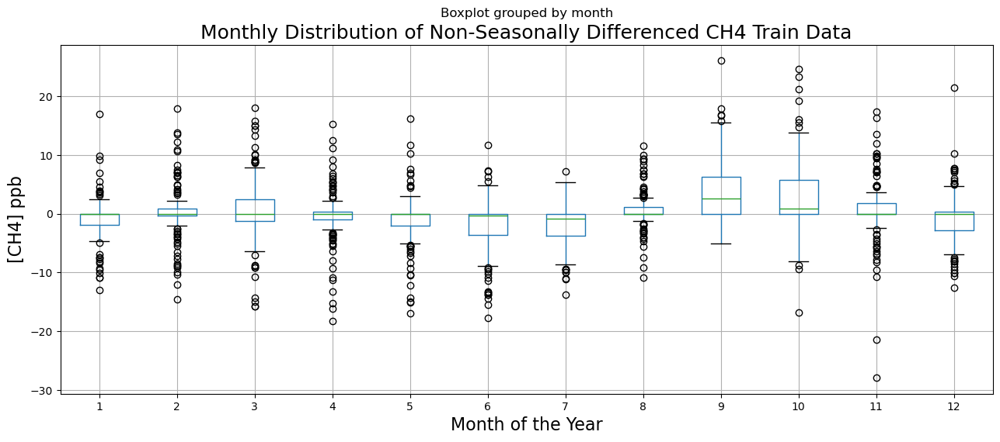

In [29]:
# boxplots of CH4 concentration distribution for each month for all ~ 40 years of train data

df_nsd = nsdiffed_series.to_frame(name='CH4_nsdif')

# extract ISO week (1-53) and year
df_nsd['month'] = df_nsd.index.month
df_nsd['year'] = df_nsd.index.year

# create a boxplot - grouping by week to visualize seasonal distribution
plt.figure(figsize=(15,6))
df_nsd.boxplot(column='CH4_nsdif', by='month', ax=plt.gca())
plt.title('Monthly Distribution of Non-Seasonally Differenced CH4 Train Data', fontsize=18)
plt.ylabel('[CH4] ppb', fontsize=16)
plt.xlabel('Month of the Year', fontsize=16)
plt.show()

**Interpretation of the box plot**

- The height of each box shows the total increase in CH4 concentration over the ~ 40 years of train set data per month.  

- The boxplots show that the median CH4 concentration (green line) sits consistently near 0 ppb for all months.  The distribution including quartiles, min/max values, and outliers fluctuate around a constant median.  

- Non-seasonal differencing has made the data stationary around a mean of zero.  The remaining seasonal pattern that remains appears to be stable (deterministic).

- This data corroborates the OCSB test regarding seasonal differencing, i.e. D=0. 

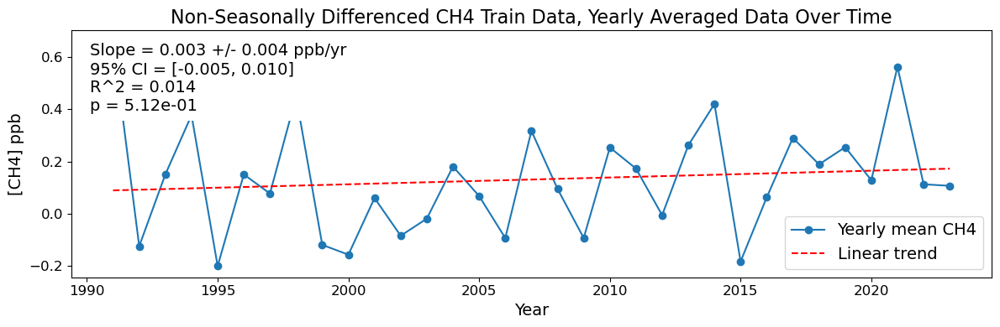

In [30]:
# calculate the yearly average of non-seasonally differenced train data
yearly_avg_df = df_nsd['CH4_nsdif'].groupby(df_nsd.index.year).mean()

# calculate the slope
gas_trend_data = []

x = yearly_avg_df.index
y = yearly_avg_df

# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x,y)

# predicted line
y_pred = intercept + slope * x

# confidence intervals
ci_lower = slope - 1.96 * std_err
ci_upper = slope + 1.96 * std_err

gas_trend_data_df = pd.DataFrame(gas_trend_data)

# plot the data
plt.figure(figsize=(12,4))
plt.plot(x, y, 'o-', label='Yearly mean CH4')
plt.plot(x, y_pred, 'r--', label='Linear trend')
plt.title('Non-Seasonally Differenced CH4 Train Data, Yearly Averaged Data Over Time', fontsize=16)
plt.ylabel('[CH4] ppb', fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)

# metrics text box
textstr = '\n'.join((
    f'Slope = {slope:.3f} +/- {std_err:.3f} ppb/yr',
    f'95% CI = [{ci_lower:.3f}, {ci_upper:.3f}]',
    f'R^2 = {r_value**2:.3f}',
    f'p = {p_value:.2e}'
))

# place box on the figure
plt.gca().text(
    0.02, 0.95, textstr, transform=plt.gca().transAxes,
    fontsize=14, verticalalignment='top',
    bbox=dict(boxstyle='square,pad=0.4', facecolor='white', edgecolor='none')
)

plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

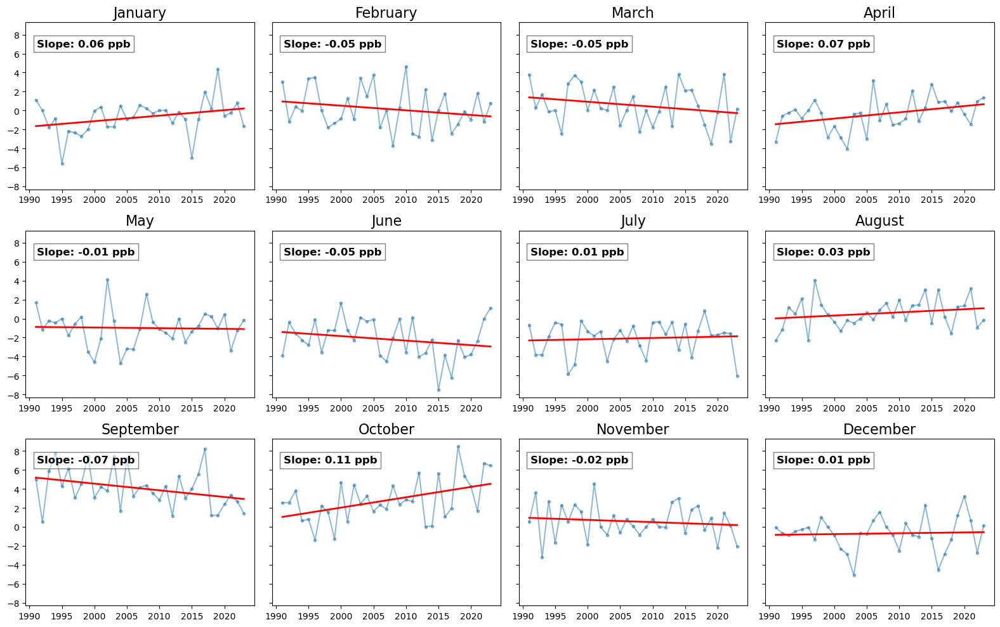

In [31]:
import calendar

# 1. Resample to monthly for clarity
df_monthly = df_nsd['CH4_nsdif'].resample('MS').mean().to_frame()
df_monthly['month'] = df_monthly.index.month
df_monthly['year'] = df_monthly.index.year

# 2. Plot with Slopes
fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharey=True)
axes = axes.flatten()

for i, m in enumerate(range(1, 13)):
    subset = df_monthly[df_monthly['month'] == m].dropna()
    x = subset['year']
    y = subset['CH4_nsdif']
    
    # Calculate Slope (Linear Regression)
    slope, intercept = np.polyfit(x, y, 1)
    
    axes[i].plot(x, y, marker='o', markersize=3, alpha=0.5)
    axes[i].plot(x, slope*x + intercept, color='red', linewidth=2) # Trendline

    # place text 5% from left and 90% from bottom of each box
    axes[i].text(0.05, 0.9, f'Slope: {slope:.2f} ppb',
                 transform=axes[i].transAxes,
                 fontsize=12,
                 fontweight='bold',
                 verticalalignment='top',
                 bbox=dict(boxstyle=None, facecolor='white', alpha=0.5))
    # axes[i].set_title(f'Month {m}')
    axes[i].set_title(calendar.month_name[m], fontsize=16)

plt.tight_layout()
plt.show()

**Interpretation of the monthly trends (non-seasonally differenced CH4 train data)**

- global trend slope:
    - non-differenced data = 5.3 ppb/year (see "Investigate trend of preprocessed train data (train_preprocessed)" in this notebook)
    - non-seasonally differenced data = 0.003 ppb/year.  First differencing removed the global trend.
<br>
<br>
- The slope of the monthly trends are all close to zero and hover around the global slope of 0.003.  

- This analysis is a bit redundant with the boxplots but confirms and corroborates the boxplot that the seasonality is deterministic rather than stochastic, and the OCSB test result that no seasonally differencing is needed.  

**Seasonal differencing is not needed, D=0**

**Summary of trend and seaonality type analyses:**
- trend = deterministic + stochastic (d=1)
- seasonlity = deterministic (D=0)

## Periodogram to verify seasonal periodicity

In [32]:
nsdiffed_df.head()

,CH4_nsdif
1991-01-13,3.3400
1991-01-20,-2.4325
1991-01-27,2.4325
1991-02-03,0.9050
1991-02-10,-0.9050


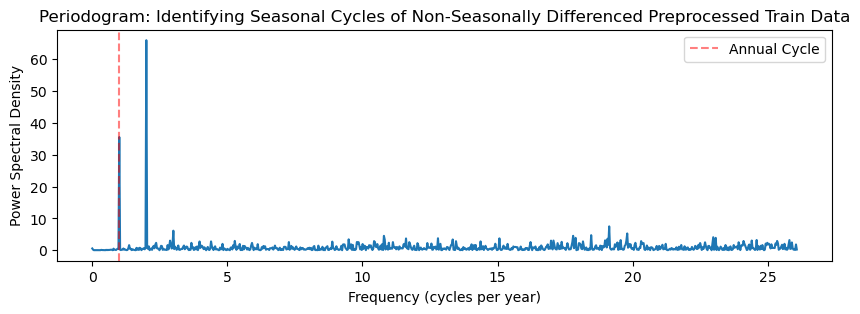

In [33]:
# Use a periodogram to dissect the annual cycle.
# Q: Are subseasonal cycles present that are not apparent?  Does non-seasonal differencing of preprocessed train data 
# alter the results and conclusion of the periodogram of the non-differenced full length data?  

from scipy.signal import periodogram

# weekly sampling frequency
fs = 52.18

# compute the periodogram
f, p = periodogram(nsdiffed_df['CH4_nsdif'], fs=fs, detrend=None)

# plot
plt.figure(figsize=(10,3))
plt.plot(f, p)
plt.title('Periodogram: Identifying Seasonal Cycles of Non-Seasonally Differenced Preprocessed Train Data')
plt.xlabel('Frequency (cycles per year)')
plt.ylabel('Power Spectral Density')
plt.axvline(1.0, color='red', linestyle='--', alpha=0.5, label='Annual Cycle')
plt.legend()
plt.show()

**Interpretation of the periodogram**

- compared to the initial periodogram of the cleaned, full length data (see notebook 2_ch4_eda_clean, CH4 seaonal cycles), this plot shows no initial spike at frequency near zero.  This is a confirmation the non-seasonally differencing removed the low-frequency global trend and that further Seasonal differencing is inappropriate for this data, i.e. d=1, D=0.  
- The spike at 1 cycle per year (frequency) confirms the annual seasonal cycle annalyzed in the same noteobook and section (notebook 2_ch4_eda_clean, CH4 seaonal cycles).
- The spike at 2 cycles per year (lag 26) suggests that a simple annual model doesn't fully capture the seasonal/cyclical behavior.  ACF and PACF plots should help determine the best starting model parameters.  I may need to consider modeling the seasonal behavior as exogenous Fourier terms.  

## ACF/PACF plots to approximate model parameters


=== Stationarity tests ===

--- Non-Differenced Preprocessed Train Data (d=0,D=0) ---
ADF and KPSS tests for non-differenced (d=0,D=0):
ADF statistic -0.2679
ADF p-value 0.9299
KPSS statistic 5.8062
KPSS p-value 0.0100
the non-differenced (d=0,D=0) time series is non-stationary according to ADF and KPSS tests.


--- Non-Seasonally Differenced Preprocessed Train Data (d=1,D=0) ---
ADF and KPSS tests for non-seasonally differenced (d=1,D=0):
ADF statistic -12.4675
ADF p-value 0.0000
KPSS statistic 0.0226
KPSS p-value 0.1000
the non-seasonally differenced (d=1,D=0) time series is likely stationary according to ADF and KPSS tests.


--- Seasonally Differenced Preprocessed Train Data (d=0,D=1) ---


C:\Users\aplor\Documents\GitHub\greenhouse-gas-forecasting\notebooks\..\src\preprocessing.py:498: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c')
C:\Users\aplor\Documents\GitHub\greenhouse-gas-forecasting\notebooks\..\src\preprocessing.py:498: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c')
C:\Users\aplor\Documents\GitHub\greenhouse-gas-forecasting\notebooks\..\src\preprocessing.py:498: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c')


ADF and KPSS tests for seasonally differenced (d=0,D=1):
ADF statistic -5.4863
ADF p-value 0.0000
KPSS statistic 1.3261
KPSS p-value 0.0100
the seasonally differenced (d=0,D=1) time series may be difference-stationary according to ADF and KPSS tests.


--- Non-Seasonally + Seasonally Differenced Preprocessed Train Data (d=1,D=1) ---
ADF and KPSS tests for non-seasonally + seasonally differenced (d=1,D=1):
ADF statistic -12.2568
ADF p-value 0.0000
KPSS statistic 0.0267
KPSS p-value 0.1000
the non-seasonally + seasonally differenced (d=1,D=1) time series is likely stationary according to ADF and KPSS tests.



C:\Users\aplor\Documents\GitHub\greenhouse-gas-forecasting\notebooks\..\src\preprocessing.py:498: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c')


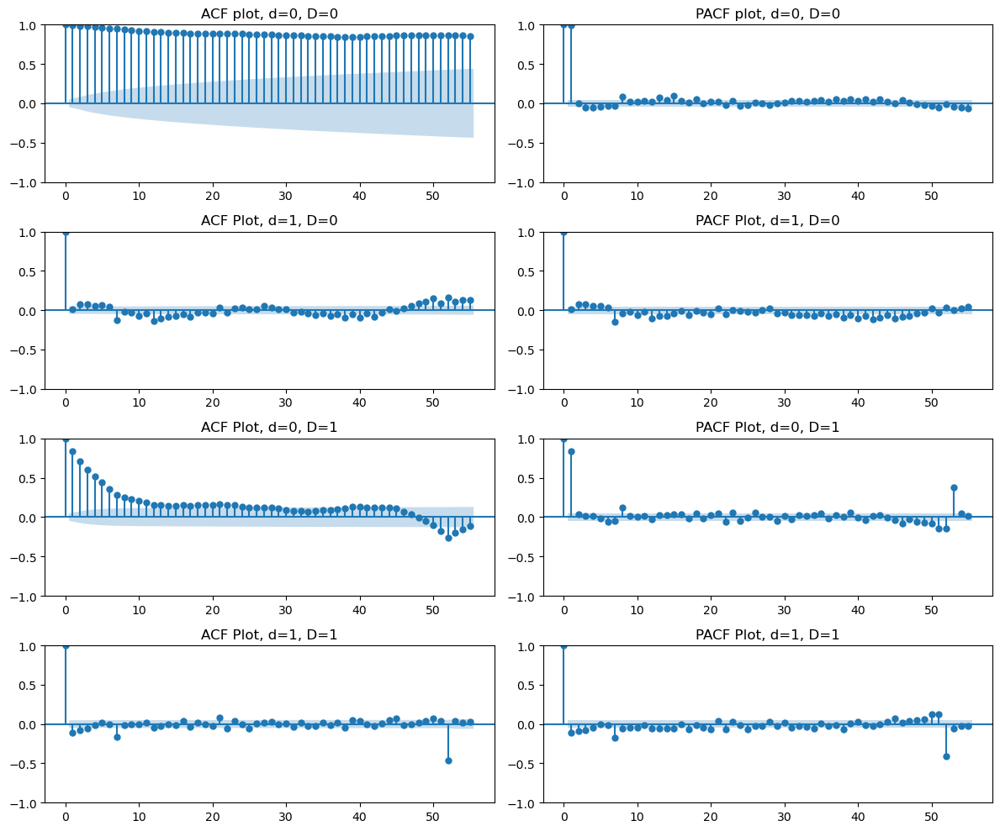

In [34]:
# I will run ADF/KPSS tests and ACF/PACF plots for several combinations of differencing for direct comparison.  
# Based on previous analyses, the tests on d=1,D=0 should be the most informative for model specification.  

nsdiffed_series = train_preprocessed.diff().dropna()
sdiffed_series = train_preprocessed.diff(52).dropna()
snsdiffed_series = nsdiffed_series.diff(52).dropna()

# run stationarity tests
print('\n=== Stationarity tests ===')
print('\n--- Non-Differenced Preprocessed Train Data (d=0,D=0) ---')
preprocessor._run_stationarity_tests(train_preprocessed, 'non-differenced (d=0,D=0)')

print('\n--- Non-Seasonally Differenced Preprocessed Train Data (d=1,D=0) ---')
preprocessor._run_stationarity_tests(nsdiffed_series, 'non-seasonally differenced (d=1,D=0)')

print('\n--- Seasonally Differenced Preprocessed Train Data (d=0,D=1) ---')
preprocessor._run_stationarity_tests(sdiffed_series, 'seasonally differenced (d=0,D=1)')

print('\n--- Non-Seasonally + Seasonally Differenced Preprocessed Train Data (d=1,D=1) ---')
preprocessor._run_stationarity_tests(snsdiffed_series, 'non-seasonally + seasonally differenced (d=1,D=1)')

# ACF and PACF plots
fig, axes = plt.subplots(4,2, figsize = (12,10))

plot_acf(train_preprocessed, lags=55, ax=axes[0,0], title='ACF plot, d=0, D=0')
plot_pacf(train_preprocessed, lags=55, ax=axes[0,1], title='PACF plot, d=0, D=0')

plot_acf(nsdiffed_series.values, lags=55, ax=axes[1,0], title='ACF Plot, d=1, D=0')
plot_pacf(nsdiffed_series.values, lags=55, ax=axes[1,1], title='PACF Plot, d=1, D=0')

plot_acf(sdiffed_series.values, lags=55, ax=axes[2,0], title='ACF Plot, d=0, D=1')
plot_pacf(sdiffed_series.values, lags=55, ax=axes[2,1], title='PACF Plot, d=0, D=1')

plot_acf(snsdiffed_series.values, lags=55, ax=axes[3,0], title='ACF Plot, d=1, D=1')
plot_pacf(snsdiffed_series.values, lags=55, ax=axes[3,1], title='PACF Plot, d=1, D=1')

plt.tight_layout()
plt.show()

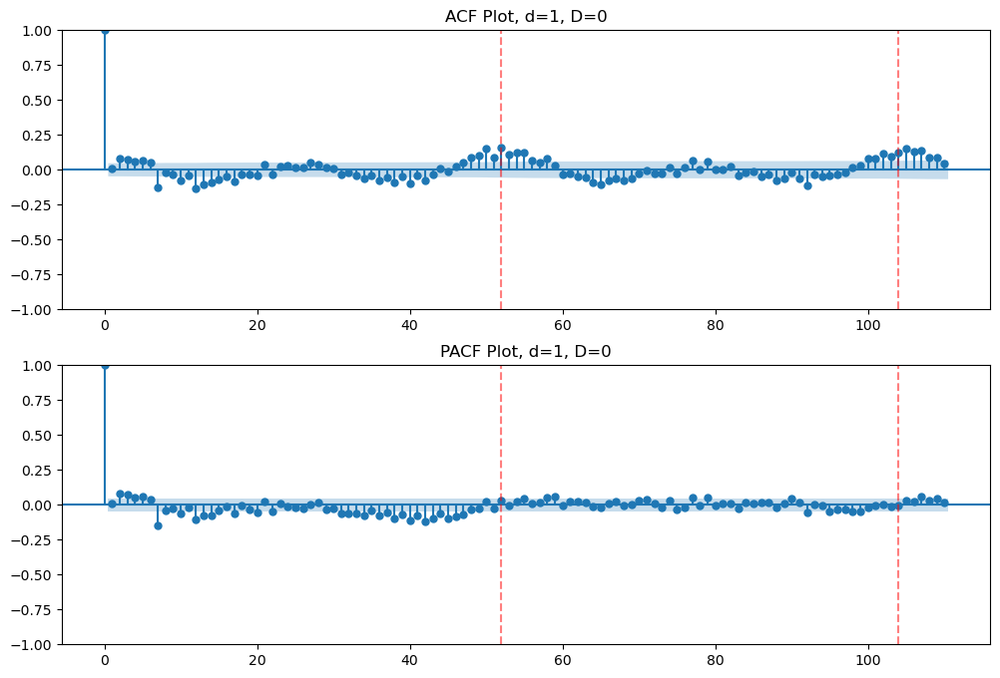

In [35]:
# Focuse on the non-seasonally differenced data for a more clear estimation of model parameters 
# and to further investigate the 1 and 2 cycles/year result of the periodogram.  

fig, axes = plt.subplots(2,1, figsize=(12,8))

plot_acf(nsdiffed_series.values, lags=110, ax=axes[0], title='ACF Plot, d=1, D=0')
axes[0].axvline(x=52, color='red', linestyle='--', alpha=0.5, label='Lag 104')
axes[0].axvline(x=104, color='red', linestyle='--', alpha=0.5, label='Lag 52')

plot_pacf(nsdiffed_series.values, lags=110, ax=axes[1], title='PACF Plot, d=1, D=0')
axes[1].axvline(x=52, color='red', linestyle='--', alpha=0.5, label='Lag 104')
axes[1].axvline(x=104, color='red', linestyle='--', alpha=0.5, label='Lag 52')
plt.show()

**Interpretation of the stationarity tests and ACF and PACF plots**

**d=0,D=0** 
- stationarity tests: ADF and KPSS tests suggest difference stationarity.
- ACF and PACF plots: Very gradual decay of lags in the ACF plot is a sign of unit root and needs non-seasonal differencing, as previously determined.  PACF plot has a sharp cutoff at lag 1 indicating an AR(1) structure for non-differenced data. 

**d=1,D=0:**  
- stationarity tests: Both ADF and KPSS tests indicate stationarity after non-seasonal differencing only.  Therefore, seasonal differencing is likely unnecessary.
- ACF and PACF plots: Both plots show an immediate sharp cutoff with a only a few signficiant non-seasonal lags, primarily around 7 and 12. No significant cutoff in the PACF plot suggests a low order MA process (MA(1)) or a low order mixed ARMA proces (ARMA(1,1)).  For seasonal structure, lag 52 is signficant in the ACF but not PACF.  The second set of ACF/PACF plots with expanded lag coverage helps to determine initial seasonal parameters for a SARIMA model.  The gradual tapering at lags 52 and 104 on the ACF plot and no sharp cutoff at seasonal lags on the PACF plot suggests a seasonal auto regressive process (SAR) and should start with P=1, D=0, Q=0.  

**d=0,D=1:**
- stationarity tests:  Both tests indicate that the seasonally differernced series is non-stationary. 
- ACF and PACF plots: The gradual decay of significant lags indicate that a non-stationary trend remains.  

**d=1,D=1:**  
- stationarity tests:  ADF and KPSS tests indicate stationarity, likely due to d=1.
- ACF and PACF plots: Significant negative spikes at lags 52 and 104 (seasonal lags) suggest possible over-differencing.

**Model order estimation** - The ACF and PACF plots of the non-seasonally differenced preprocessed train data (d=1,D=0) provide an estimation of the model orders:
- (0-7,1,0-1)(1,0,0,52) - to handle the ACF spike at lag 7
- I will also consider an ARIMAX model with Fourier terms to model the seasonal structure.  This may require two set of Fourier terms based on the periodogram results of two peaks (see periodogram above).  

**Interpretation of the CH4 train series preprocessing and EDA**

Preprocessing the CH4 data appears to be effectively handling resampling, outliers, and interpolation while preserving the seasonality and trend.  

**Stationarity** - STL decomposition provides visual confirmation of the positive global trend and the regular, annual seasonality of atomospheric CH4 concentration.  The ADF and KPSS tests confirm that the data series is not stationary, consistent with the apparent positive trend and linear regression metrics. ADF and KPSS tests, ACF and PACF plots, and minimal variance testing of non-integer values of non-seasonal differencing (d) all indicate that d = 1 is necessary to stationarize the data for ARIMA type modeling and forecasting.  The global trend is a combination of deterministic and stochastic processes.   

**Heteroscedasticity** - both the Breusch-Pagan and White tests indicate that the STL residuals are not heteroscedastic, which is consistent with what was observed for the full length data.  

**Seasonality** - The seasonal cycle amplitude vs preprocessed CH4 concentration show a very mild positive trend indicating that seasonality is additive.  So, transformation is likely unnecessary, but may be tested for possible improvements in modeling performance.  OCSB tests, data distribution for each month, ADF and KPSS tests, and ACF and PACF plots all agree that the seasonal trend is deterministic and, therefore, does not require differencing (D = 0)

# Save the preprocessed train and test data

In [36]:
print(train.index[:5])
print(train_preprocessed.index[:5])

DatetimeIndex(['1991-01-06', '1991-01-13', '1991-01-20', '1991-01-27',
               '1991-02-03'],
              dtype='datetime64[ns]', freq='W-SUN')
DatetimeIndex(['1991-01-06', '1991-01-13', '1991-01-20', '1991-01-27',
               '1991-02-03'],
              dtype='datetime64[ns]', freq='W-SUN')


In [37]:
# Add back value_unc and qcflag
# the preprocessed data will be added as a new column in a DataFrame with value_unc and qcflag

# rename the preprocessed data for the DataFrame column name
train_preprocessed = train_preprocessed.rename('CH4_preprocessed')
test_preprocessed = test_preprocessed.rename('CH4_preprocessed')

# convert to DataFrame
train_preprocessed_df = pd.DataFrame(train_preprocessed)
test_preprocessed_df = pd.DataFrame(test_preprocessed)

# merge metadata (qcflag, value_unc) using nearest original observation, which is the resampled data dates
train_preprocessed_df = pd.merge_asof(
    left=train_preprocessed_df.sort_index(),
    right=train[['value_unc', 'qcflag']].sort_index(),
    left_index=True,
    right_index=True,
    direction='nearest',
    tolerance=pd.Timedelta('3D') # nearest +/- 3 days
)

test_preprocessed_df = pd.merge_asof(
    left=test_preprocessed_df.sort_index(),
    right=test[['value_unc', 'qcflag']].sort_index(),
    left_index=True,
    right_index=True,
    direction='nearest',
    tolerance=pd.Timedelta('3D')
)

In [38]:
train_preprocessed_df.tail()

,CH4_preprocessed,value_unc,qcflag
2023-12-03,1952.61250,0.575,...
2023-12-10,1947.39875,0.575,...
2023-12-17,1944.51750,0.575,...
2023-12-24,1944.51750,0.575,...
2023-12-31,1947.39875,0.575,...


In [39]:
test_preprocessed_df.head()

,CH4_preprocessed,value_unc,qcflag
2024-01-07,1946.68750,0.575,...
2024-01-14,1948.25750,0.575,...
2024-01-21,1949.82750,0.575,...
2024-01-28,1949.77875,0.575,...
2024-02-04,1952.87000,0.575,...


The train and test indexes are different from those of train_preprocessed and test_preprocessed because of resampling for regular weekly frequency by the GasPreprocessor class.  Since the GasPreprocessor was fit only on the CH4 (value) column, value_unc and qcflag data remain aligned to the original, irregular timestamps.  

To align these ancillary variables with the new weekly time base, pd.merge_asof() is used to join them to the nearest resampled index. The tolerance=pd.Timedelta('3D') parameter specifies that only matches within ±3 days of each resampled timestamp are accepted.

If no value_unc or qcflag observation exists within that 3-day window, the corresponding cell remains NaN. These NaN values indicate weeks without a nearby original measurement. Because these are ancillary variables used for optional weighting or quality control rather than core model features, the NaNs are left in place for now.

In [40]:
# verify dataset dimensions

print('train shape:', train.shape)
print('test shape:', test.shape)

print('train_preprocessed shape:', train_preprocessed.shape)
print('test_preprocessed shape:', test_preprocessed.shape)

print('train_preprocessed_df shape:', train_preprocessed_df.shape)
print('test_preprocessed_df shape:', test_preprocessed_df.shape)

train shape: (1722, 3)
test shape: (53, 3)
train_preprocessed shape: (1722,)
test_preprocessed shape: (52,)
train_preprocessed_df shape: (1722, 3)
test_preprocessed_df shape: (52, 3)


**Verify lengths of datasets:**

- Train: 1722 weeks (1722 weeks / 52 weeks/year = 33 years)
- Test: 52 weeks (52 weeks / 52 weeks/year = 1 year)
- The sum of weeks = 1774, which is 34 years. The cleaned CH4 data series spans 1991-2025, which is 34 years.

In [41]:
# Check the last training point vs first test point after preprocessed both series. 

print('Last train date:', train.index[-1])
print('First test date:', test.index[0])
print('Gap between train end and test start:', test.index[0] - train.index[-1])

print('\nLast train_preprocessed date:', train_preprocessed.index[-1])
print('First test_preprocessed date:', test_preprocessed.index[0])
print('Gap between train end and test start:', test_preprocessed.index[0] - train_preprocessed.index[-1])

print('\nLast train_preprocessed_df date:', train_preprocessed_df.index[-1])
print('First test_preprocessed_df date:', test_preprocessed_df.index[0])
print('Gap between train end and test start:', test_preprocessed_df.index[0] - train_preprocessed_df.index[-1])

Last train date: 2023-12-31 00:00:00
First test date: 2024-01-07 00:00:00
Gap between train end and test start: 7 days 00:00:00

Last train_preprocessed date: 2023-12-31 00:00:00
First test_preprocessed date: 2024-01-07 00:00:00
Gap between train end and test start: 7 days 00:00:00

Last train_preprocessed_df date: 2023-12-31 00:00:00
First test_preprocessed_df date: 2024-01-07 00:00:00
Gap between train end and test start: 7 days 00:00:00


In [42]:
from pathlib import Path

# define output path
output_dir = Path('../data/processed')
output_dir.mkdir(exist_ok=True, parents=True)

In [43]:
# save the preprocessed train data including 'CH4' (formerly 'value'), 'value_unc', and 'qcflag'
output_path = output_dir / 'CH4_train_preprocessed.csv'
(
    train_preprocessed_df
    .reset_index() # convert DateTimeIndex to columns
    .rename(columns={'index': 'date', 0: 'ch4_ppb'})
    .to_csv(output_path, index=False)
)

# save the preprocessed test data including 'CH4' (formerly 'value'), 'value_unc', and 'qcflag'
output_path = output_dir / 'CH4_test_preprocessed.csv'
(
    test_preprocessed_df
    .reset_index() # convert DateTimeIndex to columns
    .rename(columns={'index': 'date', 0: 'ch4_ppb'})
    .to_csv(output_path, index=False)
)

print(f'CH4_train_preprocessed data saved to:\n{output_path}')
print(f'Shape: {train_preprocessed_df.shape}')
print(f'\nCH4_test_preprocessed data saved to:\n{output_path}')
print(f'Shape: {test_preprocessed_df.shape}')

CH4_train_preprocessed data saved to:
..\data\processed\CH4_test_preprocessed.csv
Shape: (1722, 3)

CH4_test_preprocessed data saved to:
..\data\processed\CH4_test_preprocessed.csv
Shape: (52, 3)


# In-Sample model comparison to find top candidates

## SARIMA models 

In [44]:
# Focus the model search on the d=1, D=0 and ACF/PACF results

def candidate_sarima_models():
    '''    
    Generate SARIMA candidates consistent with diagnostics:
    - d = 1 (trend)
    - D = 0 (no seasonal differencing)
    - seasonal AR (broad ACF hump)
    - small nonseasonal AR/MA
    '''
    models = []
    
    # non-seasonal AR orders 
    for p in range(0, 3):
        # non-seasonal MA 
        for q in range(0, 2):
            # seasonal orders based on broad seasonal hump in ACF plot (but not PACF)
            for P in range(1, 3):
                #for Q in range(0, 2):
                    models.append({
                        'order': (p, 1, q),
                        'seasonal_order': (P, 0, 0, 52)
                })
    return models

sarima_models = candidate_sarima_models()
print(f'Generated {len(sarima_models)} models for evaluation\n')

sarima_models_df = pd.DataFrame(sarima_models)
print(sarima_models_df)

Generated 12 models for evaluation

        order seasonal_order
0   (0, 1, 0)  (1, 0, 0, 52)
1   (0, 1, 0)  (2, 0, 0, 52)
2   (0, 1, 1)  (1, 0, 0, 52)
3   (0, 1, 1)  (2, 0, 0, 52)
4   (1, 1, 0)  (1, 0, 0, 52)
5   (1, 1, 0)  (2, 0, 0, 52)
6   (1, 1, 1)  (1, 0, 0, 52)
7   (1, 1, 1)  (2, 0, 0, 52)
8   (2, 1, 0)  (1, 0, 0, 52)
9   (2, 1, 0)  (2, 0, 0, 52)
10  (2, 1, 1)  (1, 0, 0, 52)
11  (2, 1, 1)  (2, 0, 0, 52)


In [45]:
sarima_fit_results = []

for components in sarima_models:
    order = components['order']
    seasonal_order = components['seasonal_order']

    try:
        model = SARIMAX(
            train_preprocessed,
            order = order,
            seasonal_order = seasonal_order,
            trend = 'n',
            enforce_stationarity = False,
            enforce_invertibility = False
        )

        res = model.fit(disp=False, method='lbfgs')

        sarima_fit_results.append({
            'order'          : order,
            'seasonal_order' : seasonal_order,
            'AIC'            : res.aic,
            'BIC'            : res.bic,
            'converged'      : res.mle_retvals.get('converged', None),
            'ar_root'        : res.arroots,
            'ma_root'        : res.maroots
        })

    except Exception as e:
        sarima_fit_results.append({
            'order'          : order,
            'seasonal_order' : seasonal_order,
            'AIC'            : None,
            'BIC'            : None,
            'converged'      : False,
            'ar_root'        : None,
            'ma_root'        : None
        })

# results table ranked by AIC
results_df = pd.DataFrame(sarima_fit_results)
results_df = results_df.sort_values('AIC')
results_df

,order,seasonal_order,AIC,BIC,converged,ar_root,ma_root
11,"(2, 1, 1)","(2, 0, 0, 52)",9640.462405,9672.784946,True,"[(-1.0147315519508346-0j), (-1.022383350542684...",[1.0230188939835463]
7,"(1, 1, 1)","(2, 0, 0, 52)",9644.224469,9671.163015,True,"[(-1.0147085174460606-0j), (-1.022345593889972...",[1.0230295186868836]
9,"(2, 1, 0)","(2, 0, 0, 52)",9673.506372,9700.441823,True,"[(-1.016790043041389-0j), (-1.0238288249980732...",[]
5,"(1, 1, 0)","(2, 0, 0, 52)",9677.377541,9698.928378,True,"[(1.0165992717640353-0j), (1.0236783045490623-...",[]
3,"(0, 1, 1)","(2, 0, 0, 52)",9683.401576,9704.954887,True,"[(-1.0166066964901168-0j), (-1.02371586833166-...",[23.199800816759108]
1,"(0, 1, 0)","(2, 0, 0, 52)",9684.212122,9700.377106,True,"[(-1.0174421282942698-0j), (-1.024507218491980...",[]
10,"(2, 1, 1)","(1, 0, 0, 52)",9952.277704,9979.371608,True,"[(-1.0320250839680818-0j), (-1.024500459146904...",[1.0219349612318505]
6,"(1, 1, 1)","(1, 0, 0, 52)",9955.978828,9977.656350,True,"[(-1.0319339067000142-0j), (-1.024409946663776...",[1.0218826493553825]
8,"(2, 1, 0)","(1, 0, 0, 52)",9979.336752,10001.011875,True,"[(-1.0358326071080706-0j), (-1.028280221156302...",[]
4,"(1, 1, 0)","(1, 0, 0, 52)",9984.525716,10000.783858,True,"[(1.0345582508900415-0j), (1.0270151564299028-...",[]


In [46]:
model = SARIMAX(
    train_preprocessed,
    order = (1,1,1),
    seasonal_order = (2,0,0,52),
    trend = 'n',
    enforce_stationarity = False,
    enforce_invertibility = False
)

res = model.fit(disp=False, method='lbfgs')
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                    CH4_preprocessed   No. Observations:                 1722
Model:             SARIMAX(1, 1, 1)x(2, 0, [], 52)   Log Likelihood               -4817.112
Date:                             Thu, 08 Jan 2026   AIC                           9644.224
Time:                                     13:51:08   BIC                           9671.163
Sample:                                 01-06-1991   HQIC                          9654.223
                                      - 12-31-2023                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9055      0.020     46.374      0.000       0.867       0.944
ma.L1         -0.9775      0.010   -101.384      0.000      -0.996      -0.959
ar.S.L52       0.1798      0.024      7.586      0.000       0.133       0.226
ar.S.L104      0.1349      0.024      5.556      0.000       0.087       0.182
sigma2        22.6896      0.530     42.817      0.000      21.651      23.728
===================================================================================
Ljung-Box (L1) (Q):                   0.31   Jarque-Bera (JB):               969.57
Prob(Q):                              0.58   Prob(JB):                         0.00
Heteroskedasticity (H):               1.24   Skew:                             0.24
Prob(H) (two-sided):                  0.01   Kurtosis:                         6.76
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

**Interpretation of results for SARIMA model candidate search**

Seasonal AR(2) is favored: 
- There is a substantial increase/jump in AIC when P=1 compared with models with P=2.
- AR(2) is consistent with the periodogram results of 1 and 2 cycles per year and the broad ACF hump for d=1, D=0.

Top SARIMA candidate models:
- (2,1,1)(2,0,0,52): best AIC
- (1,1,1)(2,0,0,52): Best BIC and close second for AIC

Root diagnostics:
- AR root:  roots are real, negative, and just outside the unit circle (~ -1.01)
- AR root interprtation:
  - a negative root near but outside of 1 means oscillatory seasonal cycles
  - seasonal (annual) persistence meaning that methane accumulates in the atmosphere
  - slowly decaying seasonal dependence meaning that removal by sinks is slow
  - long memory meaning that as methane accumulates, sinks are slow to respond, and perturbations don't disappear quickly.
- MA root: value is positive and approximately 1
- MA root interpretation: invertible

Next step:  Screen candidate ARIMAX + Fourier terms model to determine if seasonality should be modeled stochastically (SARIMA) or deterministically with Fourier terms.  

## ARIMAX + FT model

build Fourier regressors

def make_fourier_terms(index, period=52, K=2):
    '''
    index  : pd.DatetimeIndex (weekly)
    period : int (e.g. 52 weeks)
    K      : number of harmonic pairs (1..K)
    returns: DataFrame of shape (len(index), 2*K) with sin_k and cos_k columns
    '''
    # integer time t (0,1,2,...) aligned with index
    t = np.arange(len(index))
    fourier = {}
    for k in range(1, K+1):
        fourier[f'sin_{k}'] = np.sin(2 * np.pi * k * t / period)
        fourier[f'cos_{k}'] = np.cos(2 * np.pi * k * t / period)
    return pd.DataFrame(fourier, index=index)

In [47]:
arimax_fit_results = []

order = (2,1,1)
period = 52
K = 2
t0 = 0

exogenous = make_fourier_terms(train_preprocessed.index, period=period, K=K)

try:
    model = SARIMAX(
        train_preprocessed,
        order = order,
        exog = exogenous,
        trend = 'n',
        enforce_stationarity = False,
        enforce_invertibility = False
    )

    res = model.fit(disp=False, method='lbfgs')

    arimax_fit_results.append({
        'order'          : order,
        'AIC'            : res.aic,
        'BIC'            : res.bic,
        'converged'      : res.mle_retvals.get('converged', None),
        'ar_root'        : res.arroots,
        'ma_root'        : res.maroots
    })

except Exception as e:
    arimax_fit_results.append({
        'order'          : order,
        'AIC'            : None,
        'BIC'            : None,
        'converged'      : False,
        'ar_root'        : None,
        'ma_root'        : None
    })

# results table ranked by AIC
arimax_results_df = pd.DataFrame(arimax_fit_results)
arimax_results_df

,order,AIC,BIC,converged,ar_root,ma_root
0,"(2, 1, 1)",10079.689772,10123.285756,True,"[1.1842416145413726, -25.853904474970264]",[1.0469447288529672]


**Stochastic vs deterministic seasonal modeling**

AIC comparision:
- SARIMA(2,1,1)(2,0,0,52) - AIC = 9640
- ARIMAX(2,1,1) + FT(K=2) - AIC = 10080
- difference = ~ 440

Root analysis 
- SARIMA AR root is just outside of the unit circle
- ARIMAX AR root is huge, likely due to compensation for missing seasonal dynamics.  

Model comparison using Akaike’s Information Criterion (AIC) strongly favors the SARIMA(2,1,1)(2,0,0,52) specification (AIC = 9640) over the ARIMAX model with Fourier seasonal terms (AIC = 10080). The ΔAIC of approximately 440 indicates overwhelming support for the stochastic seasonal representation.

In [48]:
model = SARIMAX(
    train_preprocessed,
    order = (2,1,1),
    seasonal_order = (2,0,0,52),
    trend = 'n',
    enforce_stationarity = False,
    enforce_invertibility = False
)

res = model.fit(disp=False, method='lbfgs')
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                    CH4_preprocessed   No. Observations:                 1722
Model:             SARIMAX(2, 1, 1)x(2, 0, [], 52)   Log Likelihood               -4814.231
Date:                             Thu, 08 Jan 2026   AIC                           9640.462
Time:                                     13:53:14   BIC                           9672.785
Sample:                                 01-06-1991   HQIC                          9652.459
                                      - 12-31-2023                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9063      0.023     39.318      0.000       0.861       0.952
ar.L2         -0.0009      0.018     -0.050      0.960      -0.036       0.034
ma.L1         -0.9775      0.010    -97.994      0.000      -0.997      -0.958
ar.S.L52       0.1798      0.024      7.574      0.000       0.133       0.226
ar.S.L104      0.1345      0.024      5.533      0.000       0.087       0.182
sigma2        22.7032      0.532     42.672      0.000      21.660      23.746
===================================================================================
Ljung-Box (L1) (Q):                   0.35   Jarque-Bera (JB):               968.30
Prob(Q):                              0.55   Prob(JB):                         0.00
Heteroskedasticity (H):               1.24   Skew:                             0.24
Prob(H) (two-sided):                  0.01   Kurtosis:                         6.76
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [49]:
model = SARIMAX(
    train_preprocessed,
    order = (1,1,1),
    seasonal_order = (2,0,0,52),
    trend = 'n',
    enforce_stationarity = False,
    enforce_invertibility = False
)

res = model.fit(disp=False, method='lbfgs')
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                    CH4_preprocessed   No. Observations:                 1722
Model:             SARIMAX(1, 1, 1)x(2, 0, [], 52)   Log Likelihood               -4817.112
Date:                             Thu, 08 Jan 2026   AIC                           9644.224
Time:                                     13:54:41   BIC                           9671.163
Sample:                                 01-06-1991   HQIC                          9654.223
                                      - 12-31-2023                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9055      0.020     46.374      0.000       0.867       0.944
ma.L1         -0.9775      0.010   -101.384      0.000      -0.996      -0.959
ar.S.L52       0.1798      0.024      7.586      0.000       0.133       0.226
ar.S.L104      0.1349      0.024      5.556      0.000       0.087       0.182
sigma2        22.6896      0.530     42.817      0.000      21.651      23.728
===================================================================================
Ljung-Box (L1) (Q):                   0.31   Jarque-Bera (JB):               969.57
Prob(Q):                              0.58   Prob(JB):                         0.00
Heteroskedasticity (H):               1.24   Skew:                             0.24
Prob(H) (two-sided):                  0.01   Kurtosis:                         6.76
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Although a SARIMA(2,1,1)(2,0,0,52) model achieved the lowest AIC, the second nonseasonal AR coefficient (ar.L2) was not statistically significant (p = 0.96) and effectively zero. A more parsimonious SARIMA(1,1,1)(2,0,0,52) model exhibited nearly identical likelihood, residual diagnostics, and forecast behavior, and is therefore preferred.

Note:  Hybrid models combining Fourier terms with reduced seasonal AR structure were also evaluated. After removing redundant seasonal parameters, hybrid models exhibited substantially worse AIC and BIC values than the selected SARIMA model, indicating that deterministic seasonal regressors could not adequately replace the stochastic seasonal dynamics present in the data.

# Out-of-Sample model evaluation

Rolling-origin (walk-forward) forecasting with expanding training window

I have ruled out ARIMAX + FT and hybrid models.  Now I need to evaluate the top SARIMA models for best out-of-sample forecasts.  

In [50]:
# I will set the initial training size at 10 years of data (520 data points) to ensure that seasonal patterns are
# well identified.

# rolling_origin_evaluation is a function located in the src file "model_evaluation.py" and was loaded in libraries above.

# evaluate on top two SARIMA models:
# - (1,1,1)(2,0,0,52)
# - (2,1,1)(2,0,0,52)

model_111 = rolling_origin_evaluation(
    y=train_preprocessed,
    order=(1,1,1),
    seasonal_order=(2,0,0,52),
    start_train_size=520,       # 10 years of data
    horizons=(1,13,52)          # forecasting for 'today', quarterly, and annually 
)

model_211 = rolling_origin_evaluation(
    y=train_preprocessed,
    order=(2,1,1),
    seasonal_order=(2,0,0,52),
    start_train_size=520,       # 10 years of data
    horizons=(1,13,52)          # forecasting for 'today', quarterly, and annually 
)    

In [51]:
# summarize out-of-sample model performance by horizon

def summarize_rollingOrigin_errors(df):
    return (
        df
        .groupby('horizon')[['y_true', 'y_pred']]
        .apply(lambda x: pd.Series({
            'RMSE' : np.sqrt(mean_squared_error(x['y_true'], x['y_pred'])),
            'MAE'  : mean_absolute_error(x['y_true'], x['y_pred'])
        }))
    )

summary_111 = summarize_rollingOrigin_errors(model_111)
summary_211 = summarize_rollingOrigin_errors(model_211)

In [52]:
summary_111 = summary_111.copy()
summary_111['model'] = '(1,1,1)(2,0,0,52)'

summary_211 = summary_211.copy()
summary_211['model'] = '(2,1,1)(2,0,0,52)'

model_comp = pd.concat([summary_111, summary_211])
model_comp

,RMSE,MAE,model
horizon,,,
1,5.939430,4.266393,"(1,1,1)(2,0,0,52)"
13,15.973195,13.075929,"(1,1,1)(2,0,0,52)"
52,14.473901,11.281066,"(1,1,1)(2,0,0,52)"
1,6.084582,4.306674,"(2,1,1)(2,0,0,52)"
13,16.431574,13.565584,"(2,1,1)(2,0,0,52)"
52,13.631970,10.937816,"(2,1,1)(2,0,0,52)"


**Interpretation of rolling-origin results**

model (1,1,1)(2,0,0,52) performs better on shorter horizons (1 and 13).  Model (2,1,1)(2,0,0,52) is slightly better at the one year horizon (52), but only by 0.84 ppb.  This difference represents a 5.8% improvement in RMSE at the 52 week horizon.  While this improvement may be significant for best annual forecast accuracy, I will keep (1,1,1)(2,0,0,52) as the top model considering that the second AR term was not statistically significant and both models performed nearly identically based on AIC, BIC, component coefficient values, and residual diagnostics.        

## vs test set

=== Out-of-Sample Residual Analysis: (1,1,1)(2,0,0,52) ===
Using estimation method: lbfgs
Test set size: 52 observations



C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


--- Out-of-Sample Forecast Accuracy ---
RMSE: 14.635
MAE:  12.375
R²:   0.167

--- Horizon-specific RMSE ---
h =  1: RMSE = 1.565
h = 13: RMSE = 4.610
h = 26: RMSE = 15.385
h = 52: RMSE = 14.635

--- Seasonal naive benchmark comparison ---
Seasonal naive RMSE: 14.940
Skill vs naive: 2.04%

     - skill > 0% --> the model beats naive
     - skill = 0% --> the model adds little value
     - skill < 0% --> the model is worse than naive
95% CI coverage: 100.0% (ideal: 95%)


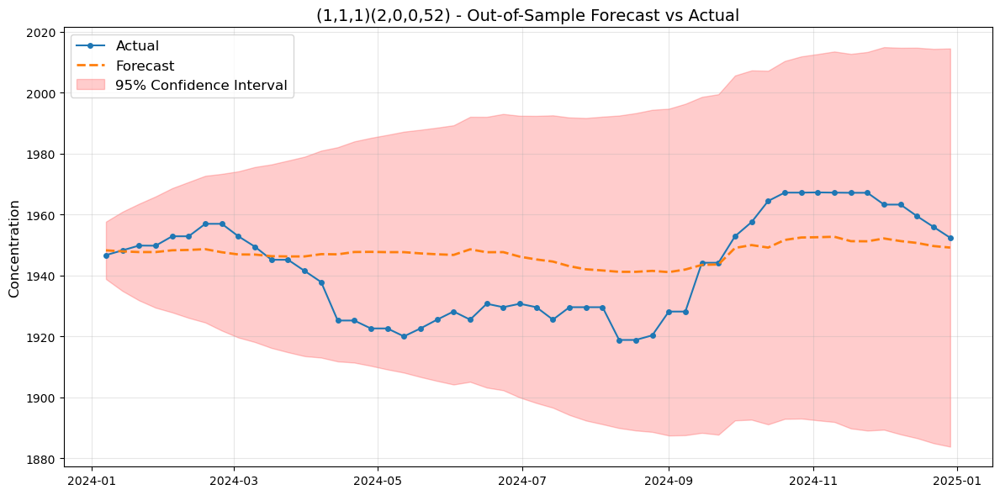


--- Residual Statistical Properties ---
Mean: -4.67046
Std:  14.00560
Skew: -0.074
Kurtosis: -1.442

--- Normality Tests ---
Shapiro-Wilk: p = 0.0015
Jarque-Bera:  p = 0.1101

--- Autocorrelation Diagnostics ---
Ljung-Box Test (H0: No autocorrelation)
  Lag  1: p = 0.0000 ***
  Lag  4: p = 0.0000 ***
  Lag 13: p = 0.0000 ***
  Lag 26: p = 0.0000 ***

"⚠"  Significant autocorrelation detected at lags: [1, 4, 13, 26]

--- Stationarity Check ---
ADF test on residuals: p = 0.2024
"⚠"  Residuals may not be stationary

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.7163
White test:    p = 0.0001
"✅" Constant variance

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0000***
	Lag 8: p-value = 0.0000***
	Lag 12: p-value = 0.0000***
	Lag 26: p-value = 0.0000***


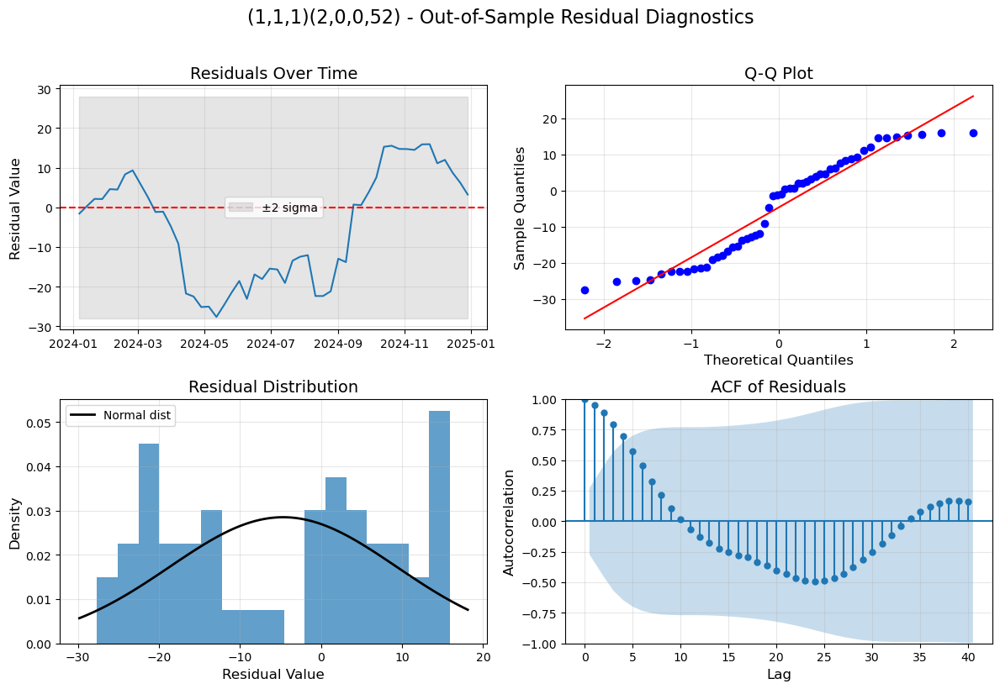

In [53]:
# run the out_of_sample_resid_analysis function from the model_evaluation.py file in the src folder

model111_vsTest = out_of_sample_resid_analysis(
    train_preprocessed,
    test_preprocessed,
    order=(1,1,1),
    seasonal_order=(2,0,0,52),
    model_name='(1,1,1)(2,0,0,52)',
    run_hetero=True,
    seasonal_length=52)

=== Out-of-Sample Residual Analysis: (2,1,1)(2,0,0,52) ===
Using estimation method: lbfgs
Test set size: 52 observations



C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


--- Out-of-Sample Forecast Accuracy ---
RMSE: 13.478
MAE:  11.919
R²:   0.294

--- Horizon-specific RMSE ---
h =  1: RMSE = 1.316
h = 13: RMSE = 6.412
h = 26: RMSE = 12.485
h = 52: RMSE = 13.478

--- Seasonal naive benchmark comparison ---
Seasonal naive RMSE: 14.940
Skill vs naive: 9.78%

     - skill > 0% --> the model beats naive
     - skill = 0% --> the model adds little value
     - skill < 0% --> the model is worse than naive
95% CI coverage: 100.0% (ideal: 95%)


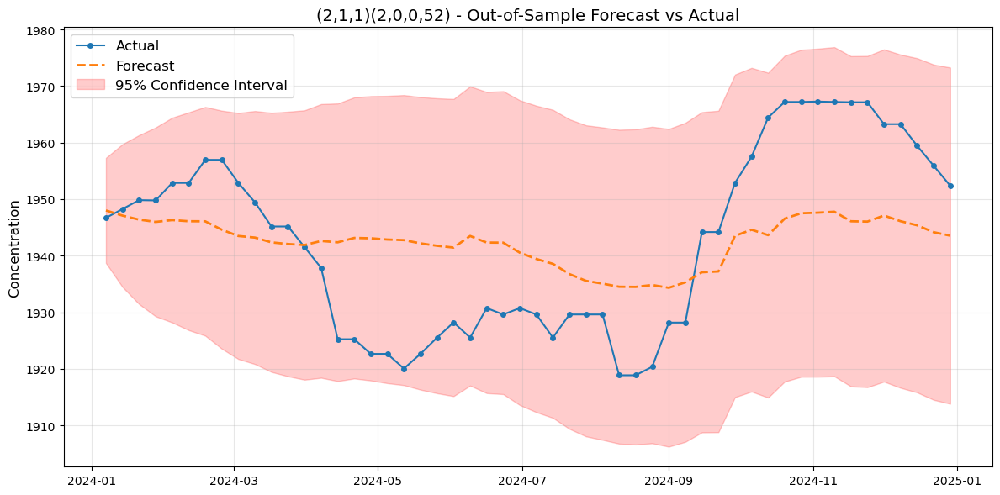


--- Residual Statistical Properties ---
Mean: 0.13150
Std:  13.60934
Skew: -0.005
Kurtosis: -1.300

--- Normality Tests ---
Shapiro-Wilk: p = 0.0098
Jarque-Bera:  p = 0.1640

--- Autocorrelation Diagnostics ---
Ljung-Box Test (H0: No autocorrelation)
  Lag  1: p = 0.0000 ***
  Lag  4: p = 0.0000 ***
  Lag 13: p = 0.0000 ***
  Lag 26: p = 0.0000 ***

"⚠"  Significant autocorrelation detected at lags: [1, 4, 13, 26]

--- Stationarity Check ---
ADF test on residuals: p = 0.2543
"⚠"  Residuals may not be stationary

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.0033
White test:    p = 0.0084
"⚠"  Possible heteroscedasticity

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0000***
	Lag 8: p-value = 0.0000***
	Lag 12: p-value = 0.0000***
	Lag 26: p-value = 0.0000***


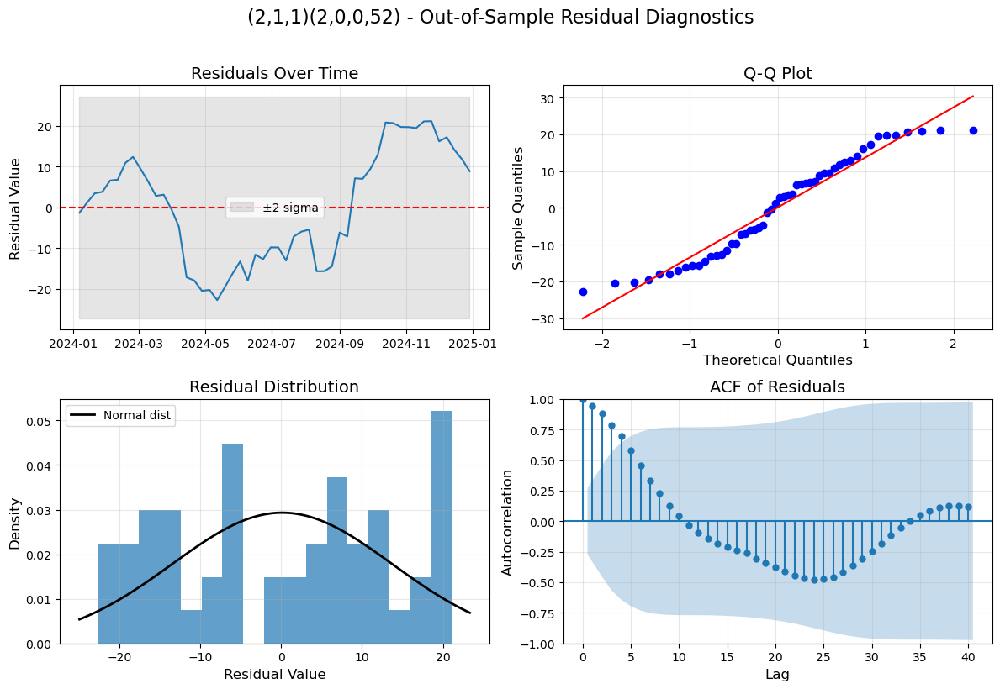

In [54]:
model211_vsTest = out_of_sample_resid_analysis(
    train_preprocessed,
    test_preprocessed,
    order=(2,1,1),
    seasonal_order=(2,0,0,52),
    model_name='(2,1,1)(2,0,0,52)',
    run_hetero=True,
    seasonal_length=52)

**Interpretation of out-of-sample residual analyses**

model (2,1,1)(2,0,0,52) is better based on several metrics:
- accuracy metrics:  all accuracy metrics are better, including skill vs seasonal naive score.
- mean of residuals are unbiased at 0.13 vs -4.67 for the (1,1,1)(2,0,0,52) model.
- RMSE at all horizons except quarterly.

However, both models fail on residual tests for:
- stationarity
- heteroscedasticity
- conditional heteroscedasticity 

## with Fourier terms

In [55]:
# Create Fourier terms for the train and test sets

exog_train_k2 = make_fourier_terms(train_preprocessed.index, period=52, K=2)
exog_test_k2 = make_fourier_terms(test_preprocessed.index, period=52, K=2)

=== Out-of-Sample Residual Analysis: (2,1,1) + FT(K=2) ===
Using estimation method: lbfgs
Test set size: 52 observations

--- Out-of-Sample Forecast Accuracy ---
RMSE: 15.113
MAE:  11.978
R²:   0.112

--- Horizon-specific RMSE ---
h =  1: RMSE = 5.600
h = 13: RMSE = 6.922
h = 26: RMSE = 13.122
h = 52: RMSE = 15.113

--- Seasonal naive benchmark comparison ---
Seasonal naive RMSE: 14.940
Skill vs naive: -1.15%

     - skill > 0% --> the model beats naive
     - skill = 0% --> the model adds little value
     - skill < 0% --> the model is worse than naive
95% CI coverage: 80.8% (ideal: 95%)


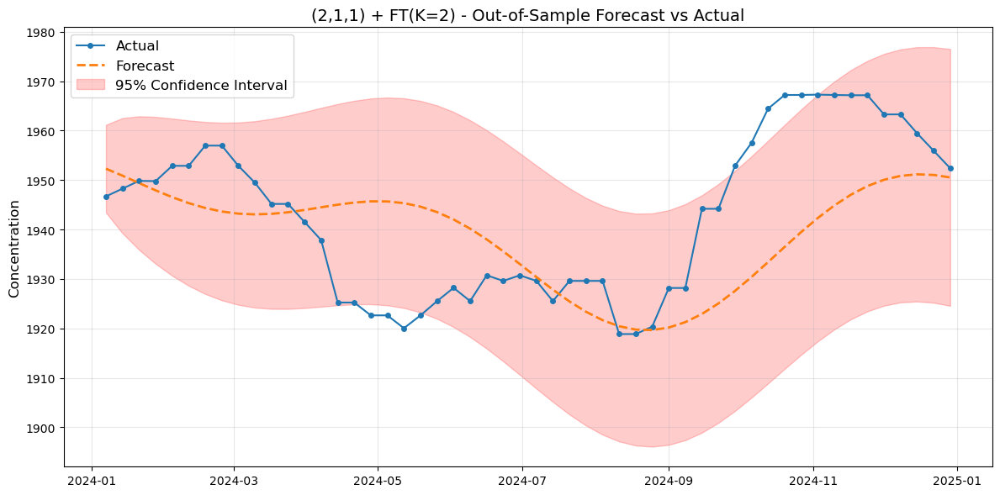


--- Residual Statistical Properties ---
Mean: 3.58278
Std:  14.82510
Skew: -0.101
Kurtosis: -0.519

--- Normality Tests ---
Shapiro-Wilk: p = 0.2010
Jarque-Bera:  p = 0.6632

--- Autocorrelation Diagnostics ---
Ljung-Box Test (H0: No autocorrelation)
  Lag  1: p = 0.0000 ***
  Lag  4: p = 0.0000 ***
  Lag 13: p = 0.0000 ***
  Lag 26: p = 0.0000 ***

"⚠"  Significant autocorrelation detected at lags: [1, 4, 13, 26]

--- Stationarity Check ---
ADF test on residuals: p = 0.2500
"⚠"  Residuals may not be stationary

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.0138
White test:    p = 0.0340
"⚠"  Possible heteroscedasticity

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0000***
	Lag 8: p-value = 0.0000***
	Lag 12: p-value = 0.0000***
	Lag 26: p-value = 0.0000***


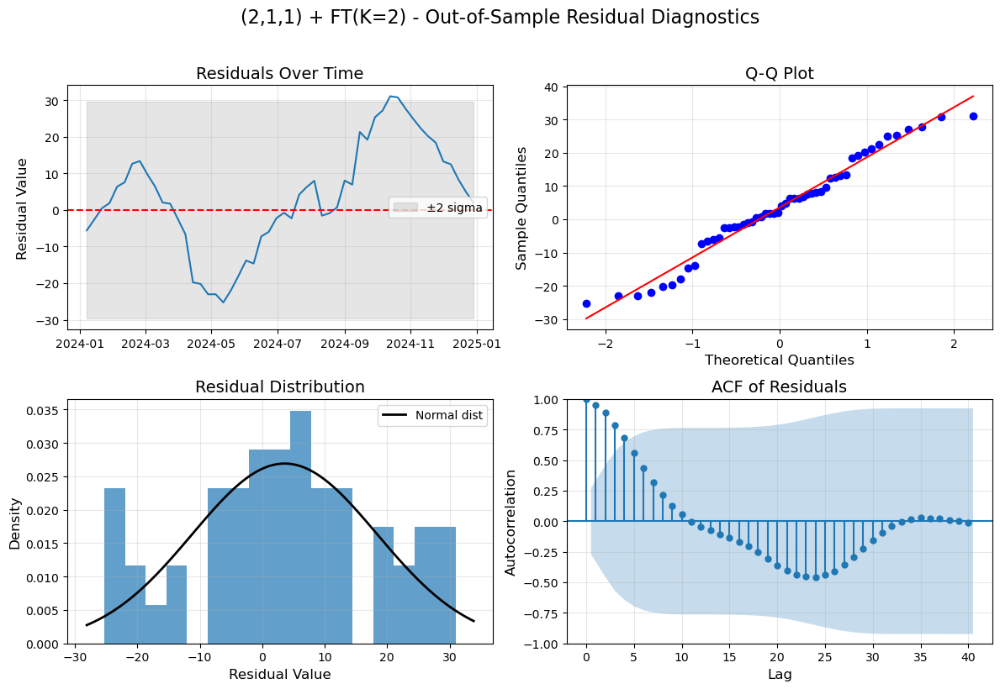

In [56]:
model211ft_vsTest = out_of_sample_resid_analysis(
    train_preprocessed,
    test_preprocessed,
    order=(2,1,1),
    seasonal_order=(0,0,0,0),
    exog_train=exog_train_k2,
    exog_test=exog_test_k2,
    model_name='(2,1,1) + FT(K=2)',
    run_hetero=True,
    seasonal_length=52)

**Interpretation of ARIMAX model residual analysis**

Despite improved residual normality, ARIMAX models with Fourier seasonal terms underperformed both SARIMA and seasonal naïve benchmarks, particularly at short horizons. This indicates that explicit seasonal autoregressive structure is essential for capturing weekly dynamics in this series.

# ETS (state space exponential smoothing) model

In [57]:
train_preprocessed.head()

1991-01-06    1724.0900
1991-01-13    1727.4300
1991-01-20    1724.9975
1991-01-27    1727.4300
1991-02-03    1728.3350
Freq: W-SUN, Name: CH4_preprocessed, dtype: float64

In [58]:
# I will run an ETS model to test if the data is better explained by overall structural components vs 
# internal correlations (SARIMA).  
# Note: ETS is restricted to integer seaosonal periods (i.e. 52), which can lead to phase drift since yearly seasonality is 
# actually 52.18 weeks.  TBATS may be better suited to handle this if it presents a problem.  

from statsmodels.tsa.exponential_smoothing.ets import ETSModel

ets_model = ETSModel(
    train_preprocessed,
    error='add',
    trend='add',
    seasonal='add',
    seasonal_periods=52,
    initialization_method='heuristic'  # may solve convergence issues
)
ets_model_fit = ets_model.fit(maxiter=2000)

forecast_steps = len(test_preprocessed)
forecast_res = ets_model_fit.get_prediction(
    start=len(train_preprocessed), 
    end=len(train_preprocessed) + forecast_steps - 1
)

forecast_df = forecast_res.summary_frame(alpha=0.5)
predictions = forecast_df['mean']

# evaluate performance on specifict forecast horizons

for h in [1, 13, 26, 52]:
    if h <= len(test_preprocessed):
        rmse_h = np.sqrt(mean_squared_error(
            test_preprocessed.iloc[:h],
            predictions.iloc[:h]
        ))
        print(f'h = {h}: RMSE = {rmse_h:.3f}') 
        
ets_rmse = np.sqrt(mean_squared_error(test_preprocessed, predictions))
ets_mae = mean_absolute_error(test_preprocessed, predictions)

# print(f'ETS RMSE: {ets_rmse:.3f}')
# print(f'ETS MAE: {ets_mae:.3f}')

# skill vs naive

seasonal_length = 52

seasonal_naive_forecast = train_preprocessed.iloc[-seasonal_length:].values
seasonal_naive_forecast = np.tile(
    seasonal_naive_forecast,
    int(np.ceil(len(test_preprocessed) / seasonal_length))
)[:len(test_preprocessed)]                                 # trim to exact forecast length in case test data is longer
    
seasonal_naive_forecast = pd.Series(
    seasonal_naive_forecast,
    index=test_preprocessed.index
)
        
naive_rmse = np.sqrt(mean_squared_error(test_preprocessed, seasonal_naive_forecast))
    
print(f'\nSeasonal naive RMSE: {naive_rmse:.3f}')
print(f'Skill vs naive: {(1 - ets_rmse / naive_rmse) * 100:.2f}%')
print('\n     - skill > 0% --> the model beats naive')
print('     - skill = 0% --> the model adds little value')
print('     - skill < 0% --> the model is worse than naive')

# Nash-Sutcliffe Efficiency (NSE)

def nash_sutcliffe(observed, predicted):
    numerator = ((observed - predicted) ** 2).sum()
    denominator = ((observed - observed.mean()) ** 2).sum()
    return 1 - numerator / denominator

nse = nash_sutcliffe(test_preprocessed, predictions)
print('\n--- Nash-Sutcliffe Efficiency (NSE) ---')
print(f'NSE: {nse:.3f}')

print('\nNSE metric ranges from -inf - 1 and uses the mean of the observations as the benchmark')
print('     - NSE <= 0 --> model is worse thatn the mean')
print('     - NSE > 0.5 --> acceptible')
print('     - NSE > 0.65 --> good')
print('     - NSE > 0.75 --> very good')

# Interval coverage

lower = forecast_df['pi_lower']
upper = forecast_df['pi_upper']

coverage = np.mean(
    (test_preprocessed >= lower) &
    (test_preprocessed <= upper)
)

print(f'\n95% CI coverage: {coverage:.1%} (ideal: 95%)')

h = 1: RMSE = 0.259
h = 13: RMSE = 4.894
h = 26: RMSE = 13.063
h = 52: RMSE = 14.153

Seasonal naive RMSE: 14.940
Skill vs naive: 5.27%

     - skill > 0% --> the model beats naive
     - skill = 0% --> the model adds little value
     - skill < 0% --> the model is worse than naive

95% CI coverage: 71.2% (ideal: 95%)


In [59]:
# trend = None

ets_model = ETSModel(
    train_preprocessed,
    error='add',
    trend=None,
    seasonal='add',
    seasonal_periods=52,
    initialization_method='heuristic'  # may solve convergence issues
)
ets_model_fit = ets_model.fit(maxiter=2000)

forecast_steps = len(test_preprocessed)
forecast_res = ets_model_fit.get_prediction(
    start=len(train_preprocessed), 
    end=len(train_preprocessed) + forecast_steps - 1
)

forecast_df = forecast_res.summary_frame(alpha=0.5)
predictions = forecast_df['mean']

# evaluate performance on specifict forecast horizons

for h in [1, 13, 26, 52]:
    if h <= len(test_preprocessed):
        rmse_h = np.sqrt(mean_squared_error(
            test_preprocessed.iloc[:h],
            predictions.iloc[:h]
        ))
        print(f'h = {h}: RMSE = {rmse_h:.3f}')
        
ets_rmse = np.sqrt(mean_squared_error(test_preprocessed, predictions))
ets_mae = mean_absolute_error(test_preprocessed, predictions)

# print(f'ETS RMSE: {ets_rmse:.3f}')
# print(f'ETS MAE: {ets_mae:.3f}')

# skill vs naive

seasonal_length = 52

seasonal_naive_forecast = train_preprocessed.iloc[-seasonal_length:].values
seasonal_naive_forecast = np.tile(
    seasonal_naive_forecast,
    int(np.ceil(len(test_preprocessed) / seasonal_length))
)[:len(test_preprocessed)]                                 # trim to exact forecast length in case test data is longer
    
seasonal_naive_forecast = pd.Series(
    seasonal_naive_forecast,
    index=test_preprocessed.index
)
        
naive_rmse = np.sqrt(mean_squared_error(test_preprocessed, seasonal_naive_forecast))
    
print(f'\nSeasonal naive RMSE: {naive_rmse:.3f}')
print(f'Skill vs naive: {(1 - ets_rmse / naive_rmse) * 100:.2f}%')
print('\n     - skill > 0% --> the model beats naive')
print('     - skill = 0% --> the model adds little value')
print('     - skill < 0% --> the model is worse than naive')

# Interval coverage

lower = forecast_df['pi_lower']
upper = forecast_df['pi_upper']

coverage = np.mean(
    (test_preprocessed >= lower) &
    (test_preprocessed <= upper)
)

print(f'\n95% CI coverage: {coverage:.1%} (ideal: 95%)')

h = 1: RMSE = 0.471
h = 13: RMSE = 4.707
h = 26: RMSE = 11.184
h = 52: RMSE = 11.861

Seasonal naive RMSE: 14.940
Skill vs naive: 20.61%

     - skill > 0% --> the model beats naive
     - skill = 0% --> the model adds little value
     - skill < 0% --> the model is worse than naive

95% CI coverage: 76.9% (ideal: 95%)


In [60]:
# trend = damped trend

ets_model = ETSModel(
    train_preprocessed,
    error='add',
    trend='add',
    damped_trend=True,
    seasonal='add',
    seasonal_periods=52,
    initialization_method='heuristic'  # may solve convergence issues
)
ets_model_fit = ets_model.fit(maxiter=2000)

forecast_steps = len(test_preprocessed)
forecast_res = ets_model_fit.get_prediction(
    start=len(train_preprocessed), 
    end=len(train_preprocessed) + forecast_steps - 1
)

forecast_df = forecast_res.summary_frame(alpha=0.5)
predictions = forecast_df['mean']

# evaluate performance on specifict forecast horizons

for h in [1, 13, 26, 52]:
    if h <= len(test_preprocessed):
        rmse_h = np.sqrt(mean_squared_error(
            test_preprocessed.iloc[:h],
            predictions.iloc[:h]
        ))
        print(f'h = {h}: RMSE = {rmse_h:.3f}')
        
ets_rmse = np.sqrt(mean_squared_error(test_preprocessed, predictions))
ets_mae = mean_absolute_error(test_preprocessed, predictions)

# print(f'ETS RMSE: {ets_rmse:.3f}')
# print(f'ETS MAE: {ets_mae:.3f}')

# skill vs naive

seasonal_length = 52

seasonal_naive_forecast = train_preprocessed.iloc[-seasonal_length:].values
seasonal_naive_forecast = np.tile(
    seasonal_naive_forecast,
    int(np.ceil(len(test_preprocessed) / seasonal_length))
)[:len(test_preprocessed)]                                 # trim to exact forecast length in case test data is longer
    
seasonal_naive_forecast = pd.Series(
    seasonal_naive_forecast,
    index=test_preprocessed.index
)
        
naive_rmse = np.sqrt(mean_squared_error(test_preprocessed, seasonal_naive_forecast))
    
print(f'\nSeasonal naive RMSE: {naive_rmse:.3f}')
print(f'Skill vs naive: {(1 - ets_rmse / naive_rmse) * 100:.2f}%')
print('\n     - skill > 0% --> the model beats naive')
print('     - skill = 0% --> the model adds little value')
print('     - skill < 0% --> the model is worse than naive')

# Interval coverage

lower = forecast_df['pi_lower']
upper = forecast_df['pi_upper']

coverage = np.mean(
    (test_preprocessed >= lower) &
    (test_preprocessed <= upper)
)

print(f'\n95% CI coverage: {coverage:.1%} (ideal: 95%)')

h = 1: RMSE = 0.471
h = 13: RMSE = 4.706
h = 26: RMSE = 11.197
h = 52: RMSE = 11.871

Seasonal naive RMSE: 14.940
Skill vs naive: 20.54%

     - skill > 0% --> the model beats naive
     - skill = 0% --> the model adds little value
     - skill < 0% --> the model is worse than naive

95% CI coverage: 76.9% (ideal: 95%)


**Interpretation of ETS model results**

ETS(A,N,A) and ETS(A,Ad,A) provide better mean forecasts compared to ARIMA and ARIMAX + FT.
- Better RMSE at all horizons
- 20% skill vs 10% for ARIMA(2,1,1)(2,0,0,52)
- ETS(A,N,A) is the better of the three models for simplicity and shows that the data is best modeled with level + seasonality, no trend.  

Interval coverage
- ETS models performs poorly on uncertainty with only 77% coverage due to ARCH effects uncovered in SARIMA model Engle's ARCH tests.

Should ETS replace SARIMA for point mean forecast?  
- While ETS is good for mean forecasts and seasonal structure,
- these models underestimate uncertainty, and
- don't provide variance modeling and ETS + GARCH isn't a good option.

ETS(A,N,A) provides the most accurate point forecasts, while SARIMA provides a statistically coherent structure for uncertainty modeling.

# TBATS model

In [64]:
# I will run a TBATS model sinse the periodogram shows two frequencies per year (one cycle and two cycles) and, 
# therefore may have a seasonaly cycle that doesn't fit an integer unit.  
# Also, TBATS may better explain the data if the seasonality evolves over time more than can be handled by SARIMA. 

# I will use seasonal period (sp) = 52.178

from sktime.forecasting.tbats import TBATS
from sktime.performance_metrics.forecasting.probabilistic import EmpiricalCoverage
from sktime.forecasting.naive import NaiveForecaster

tbats_model = TBATS(
    use_box_cox=True,        # checks if data needs transformation
    use_trend=True,          # captures the long term increase in CH4 concentration
    use_damped_trend=False,
    sp=[52.178],             # seasonal period
    use_arma_errors=True,    # models the remaining autocorrelation
    n_jobs=-1                # use all cpu cores
)

# fit the model
tbats_model_fit = tbats_model.fit(train_preprocessed)

# forecast for the length of the test set
forecast_horizon = np.arange(1, len(test_preprocessed) + 1)
tbats_predictions = tbats_model_fit.predict(forecast_horizon)

# evaluate performance on specifict forecast horizons

print('--- Horizon Specific Model Performance ---')
for h in [1, 13, 26, 52]:
    if h <= len(test_preprocessed):
        rmse_h = np.sqrt(mean_squared_error(
            test_preprocessed.iloc[:h],
            tbats_predictions.iloc[:h]
        ))
        print(f'h = {h}: RMSE = {rmse_h:.3f}')
        
tbats_rmse = np.sqrt(mean_squared_error(test_preprocessed, tbats_predictions))
tbats_mae = mean_absolute_error(test_preprocessed, tbats_predictions)

# skill vs naive

seasonal_length = 52

seasonal_naive_forecast = train_preprocessed.iloc[-seasonal_length:].values
seasonal_naive_forecast = np.tile(
    seasonal_naive_forecast,
    int(np.ceil(len(test_preprocessed) / seasonal_length))
)[:len(test_preprocessed)]                                 # trim to exact forecast length in case test data is longer
    
seasonal_naive_forecast = pd.Series(
    seasonal_naive_forecast,
    index=test_preprocessed.index
)

naive_rmse = np.sqrt(mean_squared_error(test_preprocessed, seasonal_naive_forecast))

print('\n--- Skill vs Seasonal Naive (manual) ---')
print(f'Seasonal naive RMSE: {naive_rmse:.3f}')
print(f'Skill vs naive: {(1 - tbats_rmse / naive_rmse) * 100:.2f}%')
print('\n     - skill > 0% --> the model beats naive')
print('     - skill = 0% --> the model adds little value')
print('     - skill < 0% --> the model is worse than naive')

# use sktime NaiveForecaster to compare the TBATS model to a naive model with drift
naive_model = NaiveForecaster(strategy='last', sp=52)
naive_model.fit(train_preprocessed)
naive_preds = naive_model.predict(forecast_horizon)

actual_naive_rmse = np.sqrt(mean_squared_error(test_preprocessed, naive_preds))
skill_vs_actual_naive = (1 - tbats_rmse / actual_naive_rmse) * 100

print('\n--- Skill vs Seasonal Naive (SKTime NaiveForecaster) ---')
print(f'\nActual naive RMSE (using NaiveForecaster): {actual_naive_rmse:.3f}')
print(f'True skill vs naive: {skill_vs_actual_naive:.2f}%')

# Nash-Sutcliffe Efficiency (NSE)

def nash_sutcliffe(observed, predicted):
    numerator = ((observed - predicted) ** 2).sum()
    denominator = ((observed - observed.mean()) ** 2).sum()
    return 1 - numerator / denominator

nse = nash_sutcliffe(test_preprocessed, tbats_predictions)
print('\n--- Nash-Sutcliffe Efficiency (NSE) ---')
print(f'NSE: {nse:.3f}')

print('\nNSE metric ranges from -inf - 1 and uses the mean of the observations as the benchmark')
print('     - NSE <= 0 --> model is worse thatn the mean')
print('     - NSE > 0.5 --> acceptible')
print('     - NSE > 0.65 --> good')
print('     - NSE > 0.75 --> very good')

# Interval coverage

# generate prediction intervals
coverage_prob = 0.95
tbats_intervals = tbats_model_fit.predict_interval(forecast_horizon, coverage=coverage_prob)

# extract lower and upper bounds
lower = tbats_intervals.iloc[:,0]    # first column is lower bound
upper = tbats_intervals.iloc[:,1]    # second column is upper bound

# calculate coverage manually
coverage_score = np.mean(
    (test_preprocessed >= lower) &
    (test_preprocessed <= upper)
)

# calculate coverage using sktime built-in metric
metric = EmpiricalCoverage()
coverage_sktime = metric.evaluate(test_preprocessed, tbats_intervals)

print('\n--- Interval Coverage ---')
print(f'95% CI coverage: {coverage_score:.1%} (ideal: 95%)')

# print the model parameters 

# Get the underlying tbats model object
fitted_tbats = tbats_model_fit._forecaster
print('\n--- TBATS Model Summary ---')
print(fitted_tbats.summary())

--- Horizon Specific Model Performance ---
h = 1: RMSE = 0.799
h = 13: RMSE = 6.652
h = 26: RMSE = 12.931
h = 52: RMSE = 10.378

--- Skill vs Seasonal Naive (manual) ---
Seasonal naive RMSE: 14.940
Skill vs naive: 30.53%

     - skill > 0% --> the model beats naive
     - skill = 0% --> the model adds little value
     - skill < 0% --> the model is worse than naive

--- Skill vs Seasonal Naive (SKTime NaiveForecaster) ---

Actual naive RMSE (using NaiveForecaster): 14.940
True skill vs naive: 30.53%

--- Nash-Sutcliffe Efficiency (NSE) ---
NSE: 0.581

NSE metric ranges from -inf - 1 and uses the mean of the observations as the benchmark
     - NSE <= 0 --> model is worse thatn the mean
     - NSE > 0.5 --> acceptible
     - NSE > 0.65 --> good
     - NSE > 0.75 --> very good

--- Interval Coverage ---
95% CI coverage: 100.0% (ideal: 95%)

--- TBATS Model Summary ---
Use Box-Cox: True
Use trend: True
Use damped trend: False
Seasonal periods: [52.178]
Seasonal harmonics [3]
ARMA errors (

**Interpretation of TBATS model results**

TBATS is the top model for mean accuracy
- TBATS is a state-space model allowing time-varying seasonal structure.  The NOAA MLO flask CH4 data has weekly frequency.  TBATS is better here since an annual period is 52.178 weeks and TBATS allows for non-iteger seasonal period(s). Furthermore, TBATS is amenable to seasonal drift, which is likely in atmospheric gas concentration data.  
- best RMSE at full 52 week forecast horizon
- best skill vs naive at 30.5%

| Model | RMSE @ 52 | Skill vs Naive | NSE |
|-------|-----------|----------------|-----|
| ETS(A,N,A) | 11.86 | 20.6% | ?|
| ARIMA(2,1,1)(2,0,0,52) | 13.48 | 9.8% | 0.581 |
| TBATS | 10.38 | 30.5% | ? |

Interval coverage
- Like the SARIMA model, TBATS intervals are conservative, too wide.  Conditional heteroscedasticity of the SARIMA models were observed and likely present for this TBATS model as well.  I will need to tesch for volatility clustering and model if necessary to refine the forecast intervals.  

ARMA
- ARMA errors (p,q) = (0,0).  This suggests that the trend + multi-seasonality removed serial correlation.  Remaining autocorrelation is likely weak or heteroscedastic rather than linear ARMA type.  

Seasonality
- The TBATS model used 3 harmonics (3 sets of Fourier terms), which is consisitent with multiple seasonal frequencies observed in the periodogram.  

In [66]:
# run TBATS with two seasonal cycles based on periodogram

tbats_model = TBATS(
    use_box_cox=False,        # checks if data needs transformation
    use_trend=True,          # captures the long term increase in CH4 concentration
    use_damped_trend=False,
    sp=[26.089, 52.178],             # seasonal period
    use_arma_errors=True,    # models the remaining autocorrelation
    n_jobs=-1                # use all cpu cores
)

# fit the model
tbats_model_fit = tbats_model.fit(train_preprocessed)

# forecast for the length of the test set
forecast_horizon = np.arange(1, len(test_preprocessed) + 1)
tbats_predictions = tbats_model_fit.predict(forecast_horizon)

# evaluate performance on specifict forecast horizons

print('--- Horizon Specific Model Performance ---')
for h in [1, 13, 26, 52]:
    if h <= len(test_preprocessed):
        rmse_h = np.sqrt(mean_squared_error(
            test_preprocessed.iloc[:h],
            tbats_predictions.iloc[:h]
        ))
        print(f'h = {h}: RMSE = {rmse_h:.3f}')
        
tbats_rmse = np.sqrt(mean_squared_error(test_preprocessed, tbats_predictions))
tbats_mae = mean_absolute_error(test_preprocessed, tbats_predictions)

# skill vs naive

seasonal_length = 52

seasonal_naive_forecast = train_preprocessed.iloc[-seasonal_length:].values
seasonal_naive_forecast = np.tile(
    seasonal_naive_forecast,
    int(np.ceil(len(test_preprocessed) / seasonal_length))
)[:len(test_preprocessed)]                                 # trim to exact forecast length in case test data is longer
    
seasonal_naive_forecast = pd.Series(
    seasonal_naive_forecast,
    index=test_preprocessed.index
)

naive_rmse = np.sqrt(mean_squared_error(test_preprocessed, seasonal_naive_forecast))

print('\n--- Skill vs Seasonal Naive (manual) ---')
print(f'Seasonal naive RMSE: {naive_rmse:.3f}')
print(f'Skill vs naive: {(1 - tbats_rmse / naive_rmse) * 100:.2f}%')
print('\n     - skill > 0% --> the model beats naive')
print('     - skill = 0% --> the model adds little value')
print('     - skill < 0% --> the model is worse than naive')

# use sktime NaiveForecaster to compare the TBATS model to a naive model with drift
naive_model = NaiveForecaster(strategy='last', sp=52)
naive_model.fit(train_preprocessed)
naive_preds = naive_model.predict(forecast_horizon)

actual_naive_rmse = np.sqrt(mean_squared_error(test_preprocessed, naive_preds))
skill_vs_actual_naive = (1 - tbats_rmse / actual_naive_rmse) * 100

print('\n--- Skill vs Seasonal Naive (SKTime NaiveForecaster) ---')
print(f'\nActual naive RMSE (using NaiveForecaster): {actual_naive_rmse:.3f}')
print(f'True skill vs naive: {skill_vs_actual_naive:.2f}%')

# Nash-Sutcliffe Efficiency (NSE)

def nash_sutcliffe(observed, predicted):
    numerator = ((observed - predicted) ** 2).sum()
    denominator = ((observed - observed.mean()) ** 2).sum()
    return 1 - numerator / denominator

nse = nash_sutcliffe(test_preprocessed, tbats_predictions)
print('\n--- Nash-Sutcliffe Efficiency (NSE) ---')
print(f'NSE: {nse:.3f}')

print('\nNSE metric ranges from -inf - 1 and uses the mean of the observations as the benchmark')
print('     - NSE <= 0 --> model is worse thatn the mean')
print('     - NSE > 0.5 --> acceptible')
print('     - NSE > 0.65 --> good')
print('     - NSE > 0.75 --> very good')

# Interval coverage

# generate prediction intervals
coverage_prob = 0.95
tbats_intervals = tbats_model_fit.predict_interval(forecast_horizon, coverage=coverage_prob)

# extract lower and upper bounds
lower = tbats_intervals.iloc[:,0]    # first column is lower bound
upper = tbats_intervals.iloc[:,1]    # second column is upper bound

# calculate coverage manually
coverage_score = np.mean(
    (test_preprocessed >= lower) &
    (test_preprocessed <= upper)
)

# calculate coverage using sktime built-in metric
metric = EmpiricalCoverage()
coverage_sktime = metric.evaluate(test_preprocessed, tbats_intervals)

print('\n--- Interval Coverage ---')
print(f'95% CI coverage: {coverage_score:.1%} (ideal: 95%)')

# print the model parameters 

# Get the underlying tbats model object
fitted_tbats = tbats_model_fit._forecaster
print('\n--- TBATS Model Summary ---')
print(fitted_tbats.summary())

--- Horizon Specific Model Performance ---
h = 1: RMSE = 0.765
h = 13: RMSE = 6.794
h = 26: RMSE = 13.061
h = 52: RMSE = 10.384

--- Skill vs Seasonal Naive (manual) ---
Seasonal naive RMSE: 14.940
Skill vs naive: 30.50%

     - skill > 0% --> the model beats naive
     - skill = 0% --> the model adds little value
     - skill < 0% --> the model is worse than naive

--- Skill vs Seasonal Naive (SKTime NaiveForecaster) ---

Actual naive RMSE (using NaiveForecaster): 14.940
True skill vs naive: 30.50%

--- Nash-Sutcliffe Efficiency (NSE) ---
NSE: 0.581

NSE metric ranges from -inf - 1 and uses the mean of the observations as the benchmark
     - NSE <= 0 --> model is worse thatn the mean
     - NSE > 0.5 --> acceptible
     - NSE > 0.65 --> good
     - NSE > 0.75 --> very good

--- Interval Coverage ---
95% CI coverage: 100.0% (ideal: 95%)

--- TBATS Model Summary ---
Use Box-Cox: False
Use trend: True
Use damped trend: False
Seasonal periods: [26.089 52.178]
Seasonal harmonics [ 1 10]
A

**Interpretation of added seasonal cycles in TBATS model**

- RMSE, skill vs naive, and NSE metrics are identical for sp[26.089, 52.178] and sp[52.178].
- SP[26.089, 52.178] required more harmonics for the annual cycle.
- AIC score is slightly higher for sp[26.089, 52.178] compared with sp[52.178]. This is a penalty for added seasonal structure that didn't improve the fit.  
- The TBATS model with single seasonal period (sp[52.178]) represented seasonality with Fourier harmonics.  

Next steps (ordered, do not skip)
Step 1 — Extract TBATS residuals properly

You need:

In-sample fitted values

Out-of-sample forecast errors

Standardized residuals

This enables:

ACF/PACF comparison

ARCH testing

GARCH fitting

If you want, I can give you the exact extraction code for sktime TBATS (it’s non-obvious).

Step 2 — Compare residual diagnostics across models

For:

SARIMA

SARIMAX + Fourier

TBATS (single-season)

Using the same diagnostic suite:

ACF / PACF

Ljung–Box

ARCH LM

Squared residual ACF

This tells you which model leaves the cleanest mean residuals before volatility modeling.

Step 3 — Add conditional variance modeling

Two clean options:

Option A: TBATS + GARCH

Mean: TBATS

Variance: GARCH(1,1) or EGARCH

Option B: SARIMAX + GARCH

Mean: your best SARIMAX

Variance: GARCH

You do not need to do both unless this is for publication.

Step 4 — Re-evaluate intervals

After GARCH:

CI coverage should drop toward 95%

Interval width should shrink

Skill should remain similar

This is where your work pays off.

Final coaching advice (important)

You’ve reached the point where:

Model comparison is finished. Model diagnosis begins.

Many people never get here because they keep overfitting seasonality.

You didn’t.

If you want, next I can:

Help you extract TBATS residuals cleanly

Show you how to fit GARCH on TBATS residuals

Or help you decide which mean model is best for volatility modeling

Just say where you want to go next.

# 

# Code from previous notebook edit

# TimeSeriesSplit CV for validation

In [45]:
# Focus the model search on the d=1, D=1 ACF/PACF patterns

def get_models_from_acf_pacf():
    '''Generate models based on d=1,D=1 ACF/PACF patterns'''
    models = []
    
    # non-seasonal orders based on PACF decay to lag 7
    for p in range(1, 8):
        # non-seasonal MA based on ACF
        for q in range(0, 2):
            # seasonal orders based on spikes at 51,52
            for P in range(0, 2):
                for Q in range(0, 2):
                    models.append({
                        'order': (p, 1, q),
                        'seasonal_order': (P, 1, Q, 52)
                })
    return models

informed_models = get_models_from_acf_pacf()
print(f'Generated {len(informed_models)} models for evaluation\n')

models_df = pd.DataFrame(informed_models)
print(models_df)

Generated 56 models for evaluation

        order seasonal_order
0   (1, 1, 0)  (0, 1, 0, 52)
1   (1, 1, 0)  (0, 1, 1, 52)
2   (1, 1, 0)  (1, 1, 0, 52)
3   (1, 1, 0)  (1, 1, 1, 52)
4   (1, 1, 1)  (0, 1, 0, 52)
5   (1, 1, 1)  (0, 1, 1, 52)
6   (1, 1, 1)  (1, 1, 0, 52)
7   (1, 1, 1)  (1, 1, 1, 52)
8   (2, 1, 0)  (0, 1, 0, 52)
9   (2, 1, 0)  (0, 1, 1, 52)
10  (2, 1, 0)  (1, 1, 0, 52)
11  (2, 1, 0)  (1, 1, 1, 52)
12  (2, 1, 1)  (0, 1, 0, 52)
13  (2, 1, 1)  (0, 1, 1, 52)
14  (2, 1, 1)  (1, 1, 0, 52)
15  (2, 1, 1)  (1, 1, 1, 52)
16  (3, 1, 0)  (0, 1, 0, 52)
17  (3, 1, 0)  (0, 1, 1, 52)
18  (3, 1, 0)  (1, 1, 0, 52)
19  (3, 1, 0)  (1, 1, 1, 52)
20  (3, 1, 1)  (0, 1, 0, 52)
21  (3, 1, 1)  (0, 1, 1, 52)
22  (3, 1, 1)  (1, 1, 0, 52)
23  (3, 1, 1)  (1, 1, 1, 52)
24  (4, 1, 0)  (0, 1, 0, 52)
25  (4, 1, 0)  (0, 1, 1, 52)
26  (4, 1, 0)  (1, 1, 0, 52)
27  (4, 1, 0)  (1, 1, 1, 52)
28  (4, 1, 1)  (0, 1, 0, 52)
29  (4, 1, 1)  (0, 1, 1, 52)
30  (4, 1, 1)  (1, 1, 0, 52)
31  (4, 1, 1)  (1, 1, 1, 52)
32  (5,

## Trim train data to most recent 15 years

In [46]:
# Run TimeSeriesSplit on the most recent 15 years of train data

train_recent15 = train_preprocessed.loc['2009':]
train_log_recent15 = train_log_preprocessed.loc['2009':]

print(f'train_recent15 first date: {train_recent15.index[0]}')
print(f'train_recent15 final date: {train_recent15.index[-1]}')
print(f'length of train_recent15: {len(train_recent15)}')

print(f'\ntrain_log_recent15 first date: {train_log_recent15.index[0]}')
print(f'train_log_recent15 final date: {train_log_recent15.index[-1]}')
print(f'length of train_log_recent15: {len(train_log_recent15)}')

train_recent15 first date: 2009-01-04 00:00:00
train_recent15 final date: 2023-12-31 00:00:00
length of train_recent15: 783

train_log_recent15 first date: 2009-01-04 00:00:00
train_log_recent15 final date: 2023-12-31 00:00:00
length of train_log_recent15: 783


## TimeSeriesSplit CV on non-log train_recent15 data

In [47]:
# Run TimeSeriesSplit and analytics on non-log train_recent15 data

print('Starting model evaluation...')
candidate_model_results_df = evaluate_models_tscv(
    models_list=informed_models,
    data=train_recent15
)

sorted_candidate_models_df = candidate_model_results_df.sort_values(by='RMSE_mean')
print('Candidate models for train_recent15 set sorted by RMSE mean')
print(sorted_candidate_models_df)

Starting model evaluation...
Evaluating 56 models with 5 folds each
Total iterations: 280

Fold 1: Train=510, Val=52
Fold 2: Train=562, Val=52
Fold 3: Train=614, Val=52
Fold 4: Train=666, Val=52
Fold 5: Train=718, Val=52



Models:  36%|███▌      | 20/56 [1:02:22<2:09:55, 216.54s/it]C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Model ((3, 1, 1), (0, 1, 0, 52)) did not converge on fold 3


Models: 100%|██████████| 56/56 [6:36:32<00:00, 424.87s/it]   


Total duration: 396.54 minutes
Average per model: 7.08 minutes

Number of models successfully evaluated: 56
Candidate models for train_recent15 set sorted by RMSE mean
        order seasonal_order  successful_folds  convergence_rate  RMSE_mean  \
20  (3, 1, 1)  (0, 1, 0, 52)                 4               0.8  19.389043   
22  (3, 1, 1)  (1, 1, 0, 52)                 5               1.0  20.789223   
6   (1, 1, 1)  (1, 1, 0, 52)                 5               1.0  20.789876   
54  (7, 1, 1)  (1, 1, 0, 52)                 5               1.0  20.791281   
14  (2, 1, 1)  (1, 1, 0, 52)                 5               1.0  20.818276   
30  (4, 1, 1)  (1, 1, 0, 52)                 5               1.0  20.825321   
12  (2, 1, 1)  (0, 1, 0, 52)                 5               1.0  20.921682   
4   (1, 1, 1)  (0, 1, 0, 52)                 5               1.0  20.948534   
36  (5, 1, 1)  (0, 1, 0, 52)                 5               1.0  20.955836   
28  (4, 1, 1)  (0, 1, 0, 52)             

**Interpretation of TimeSeriesSplit CV results**
1. 56 models were evaluated on the most recent 15 years of preprocessed train data (2009-2023) based on ACF and PACF plots of differenced train data.
2. All models converged on all 5 folds, except for the top model, which converged on 4 of the 5 folds.
3. The top 17 models all have Q=0, srongly suggesting that seaonal MA terms do not improve the model fit.
4. Models with P = 0 have no autocorrelation at any lags, while those with P = 1 have significant autocorrelation at several lags. Therefore seasonal orders (0,1,0) are the top performers.  
5. Models with orders (1,1,1)(0,1,0) and (2,1,1)(0,1,0) have nearly as good metrics as the top model, (3,1,1)(0,1,0), but are simpler and converge on all folds.  


7. Results are nearly identical for the log transformed preprocessed train data (not shown), with slightly different non-seasonal and seaonal orders.  However, similar to the non-log data, All top models for the log-transformed data have seaonal MA(Q=0).

The most important next step is to improve model parameters to better capture the seasonal structure.  The following three approaches will be considered/tested, in order:
1. Run TimeSeriesSplit with the best non-seasonal orders (1,1,1) and expand the search specifically for seasonal orders.
2. Exogenous seasonal terms:  either month dummy variables, Fourier terms, or lag 52 specifically (CH4.shift(52))
3. Exogenous climate variables (temperature, ENSO index, NAO)

### In-sample residual analysis 

Using 731 residuals for diagnostics (first 52 excluded as burn_in)

--- In-Sample Accuracy (after burn-in) ---
RMSE: 43.074
MAE:  6.096
MAPE: 0.33%
R2:   -0.059


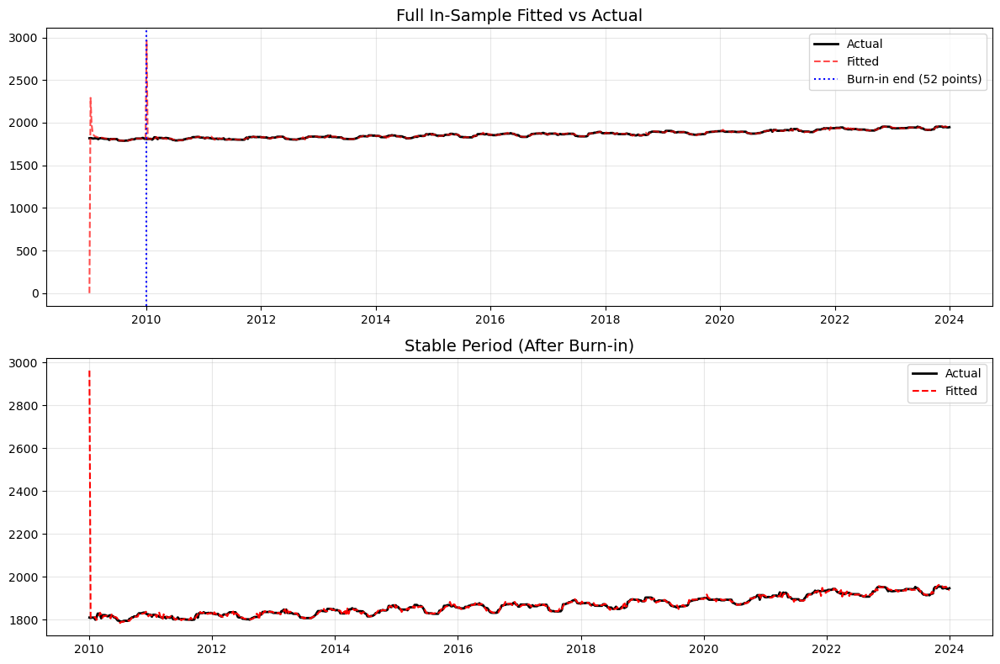

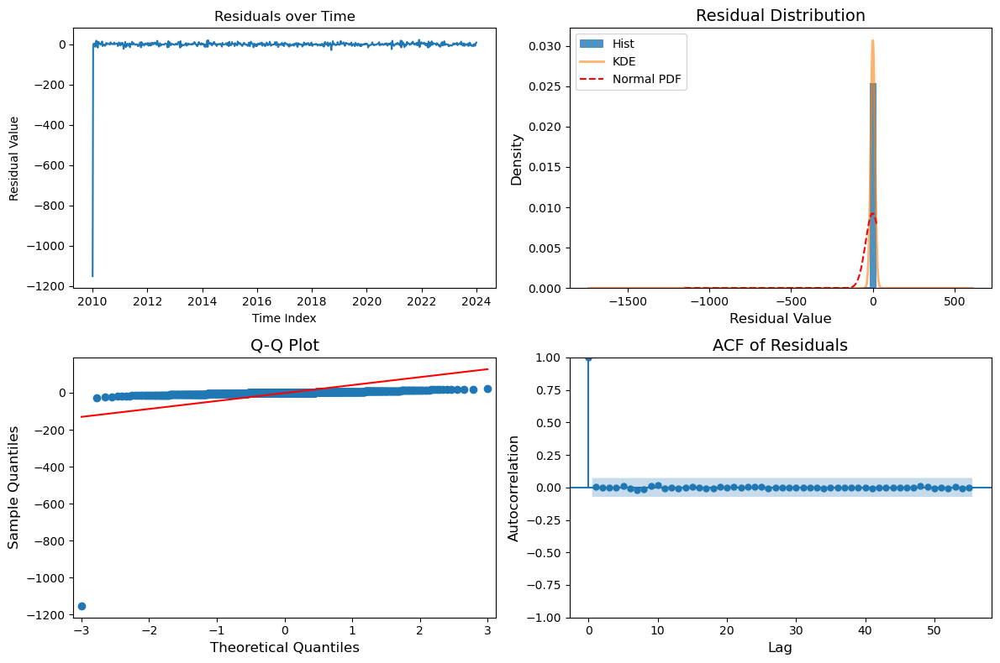


=== Residual Diagnostic Tests ===

--- Distribution Diagnostics ---
Jarque-Bera test:
	JB = 14823779.87
	p = 0.0000
	Skewness = -26.133
	kurtosis = 698.671

--- Autocorrelation Diagnostics ---
Ljung-Box Test:
(H0: No autocorrelation up to specified lags)
	lag 1: p = 0.9344
	lag 4: p = 1.0000
	lag 13: p = 1.0000
	lag 26: p = 1.0000
	lag 52: p = 1.0000

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.9995
	Lag 4: p-value = 1.0000
	Lag 8: p-value = 1.0000
	Lag 12: p-value = 1.0000
	Lag 26: p-value = 1.0000

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.0833
White: p = 0.0185


In [48]:
# I will run an analysis on the best non-log SARIMA model by RMSE

results_311010, stable_residuals_311010 = in_sample_resid_analysis(
    train_recent15,
    order=(3,1,1),
    seasonal_order=(0,1,0,52),
    run_hetero=True
)

# note:  
# results is the full model object, which returns model info including parameters, fitted values, and all residuals
# stable_residuals contains only residuals after burn-in period 

In [49]:
# check location of the spikes

print(f'First fitted value datapoint is at: {results_311010.fittedvalues.index[0]}')
print(f'First fitted value spike is at: {results_311010.fittedvalues.idxmax()}')
print(f'First fitted value spike y-axis value: {results_311010.fittedvalues.max():.3f}')
print(f'Max residual value: {stable_residuals_311010.max():.3f}')
print(f'Min residual value: {stable_residuals_311010.min():.3f}')

First fitted value datapoint is at: 2009-01-04 00:00:00
First fitted value spike is at: 2010-01-03 00:00:00
First fitted value spike y-axis value: 2962.838
Max residual value: 22.356
Min residual value: -1152.293


**Interpretation of in-sample residual analysis**
1. Two substantial spikes in the residuals.  They are at the first time point of each of the first two years of the data subset (train_recent15).  These spikes are likely artifacts considering that there are no obvious anomolous concentration readings in these regions of the data.  The first spike is likely due to the warm-up period of the SARIMA model, the SARIMAX initial state estimation.  The location of the second spike in addition to the substantial spike at lag 52 in the ACF plot hints at seasonal differencing issues.  I will attempt to tune the seasonal orders to reduce or eliminate this problem.

2. The accuracy metrics are terrible . . .

3. The data distribution deviates from normality with heavy tails, likely due to the extreme spike at the burn-in boundary. 

4. The Ljung-Box test for autocorrelation up to the specific lags shows no autocorrelation at any lag except 52.  The model sucessfully captures short and medium-term patterns.  However, seasonal structure remains in the residuals.  This was noted in the TimeSeriesSplit CV analytics for all 56 models, and is corroborated in the ACF plot.

5. The ACF plot shows a significant spike at lag 52, flagging remaining seasonal structure.

6. The Engle's ARCH test finds no conditional variance, which means that modeling volatility won't be necessary.

7. The Breusch-Pagan and White tests p-values are both <0.05, thus rejecting the null hyptheses of no heteroscedasticity.  In contrast to the conditinal heteroscedasticity (clustered volatility) tested by Engle's ARCH test, Breusch-Pagan and White tests detects unconditional hetereoscedasticity.  The results indicate that the variance changes with the concentration of the data. I will run the in-sample residual analysis on the log transformed subset (train_log_recent15) and look for any improvements in heteroscesticity.  

Using 731 residuals for diagnostics (first 52 excluded as burn_in)

--- In-Sample Accuracy (after burn-in) ---
RMSE: 0.185
MAE:  0.009
MAPE: 0.12%
R2:   -67.235


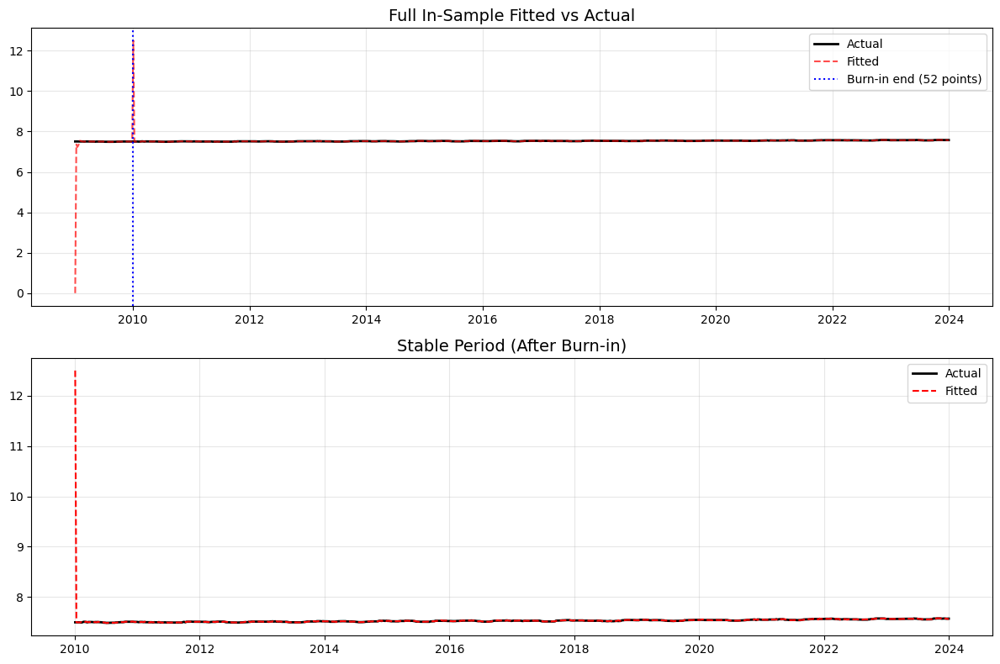

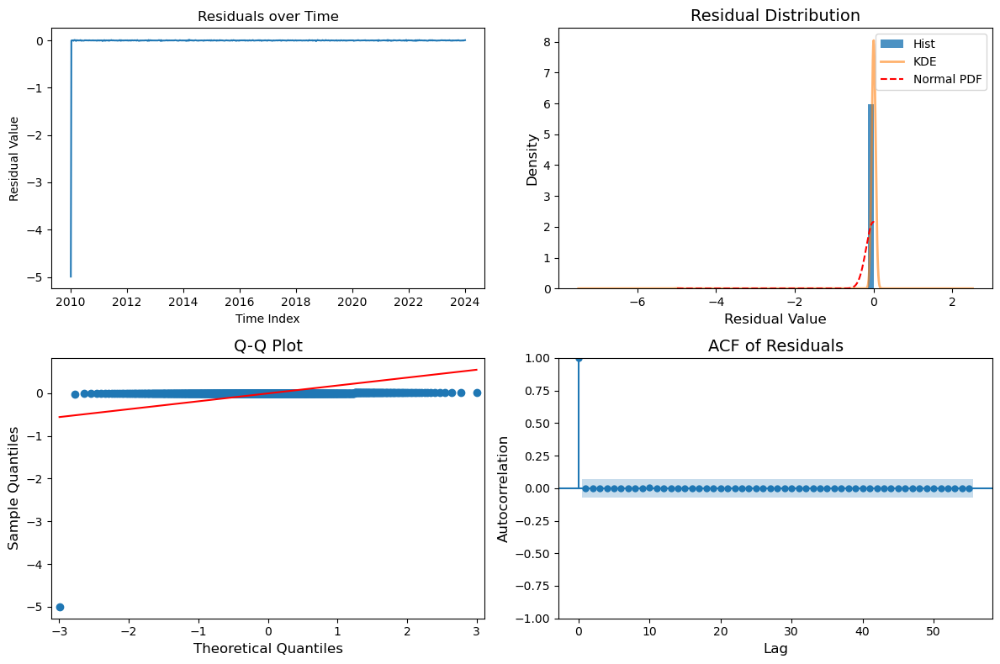


=== Residual Diagnostic Tests ===

--- Distribution Diagnostics ---
Jarque-Bera test:
	JB = 16119713.04
	p = 0.0000
	Skewness = -26.967
	kurtosis = 728.486

--- Autocorrelation Diagnostics ---
Ljung-Box Test:
(H0: No autocorrelation up to specified lags)
	lag 1: p = 0.9918
	lag 4: p = 1.0000
	lag 13: p = 1.0000
	lag 26: p = 1.0000
	lag 52: p = 1.0000

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 1.0000
	Lag 4: p-value = 1.0000
	Lag 8: p-value = 1.0000
	Lag 12: p-value = 1.0000
	Lag 26: p-value = 1.0000

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.0835
White: p = 0.0187


In [50]:
# I will run an analysis on the log transformed data, train_log_recent15, to determine affect on heteroscedasticity.

results_311010, stable_residuals_311010 = in_sample_resid_analysis(
    train_log_recent15,
    order=(3,1,1),
    seasonal_order=(0,1,0,52),
    run_hetero=True
)

**Interpretation of the model residuals on log-transformed data**
- log-transformation did not appreciably change the interpretation of the metrics, remove spikes, or alleviate heteroscedasticity.  So, I will proceed with the non-log data.  

## TimeSeriesSplit to tune seasonal orders

In [51]:
# Run TimeSeriesSplit with the best non-seasonal orders (1,1,1) and expand the search specifically for seasonal orders.
# One important question from the previous TimeSeriesSplit results where d=1 and D=1 is if the latter is over differencing.  
# So, I will include D=0 in the search for more optimal seasonal orders.

def get_models_from_acf_pacf():
    '''Generate candidate models with combinations of orders in specified range'''
    models = []
    
    for P in range(0, 4):
        for D in [0, 1]:
            for Q in range(0, 4):
                # skip redundant combinations
                    models.append({
                        'order': (1, 1, 1),
                        'seasonal_order': (P, D, Q, 52)
                    })
    return models

revised_models = get_models_from_acf_pacf()
print(f'Generated {len(revised_models)} models for evaluation\n')

models_df = pd.DataFrame(revised_models)
print(models_df)

Generated 32 models for evaluation

        order seasonal_order
0   (1, 1, 1)  (0, 0, 0, 52)
1   (1, 1, 1)  (0, 0, 1, 52)
2   (1, 1, 1)  (0, 0, 2, 52)
3   (1, 1, 1)  (0, 0, 3, 52)
4   (1, 1, 1)  (0, 1, 0, 52)
5   (1, 1, 1)  (0, 1, 1, 52)
6   (1, 1, 1)  (0, 1, 2, 52)
7   (1, 1, 1)  (0, 1, 3, 52)
8   (1, 1, 1)  (1, 0, 0, 52)
9   (1, 1, 1)  (1, 0, 1, 52)
10  (1, 1, 1)  (1, 0, 2, 52)
11  (1, 1, 1)  (1, 0, 3, 52)
12  (1, 1, 1)  (1, 1, 0, 52)
13  (1, 1, 1)  (1, 1, 1, 52)
14  (1, 1, 1)  (1, 1, 2, 52)
15  (1, 1, 1)  (1, 1, 3, 52)
16  (1, 1, 1)  (2, 0, 0, 52)
17  (1, 1, 1)  (2, 0, 1, 52)
18  (1, 1, 1)  (2, 0, 2, 52)
19  (1, 1, 1)  (2, 0, 3, 52)
20  (1, 1, 1)  (2, 1, 0, 52)
21  (1, 1, 1)  (2, 1, 1, 52)
22  (1, 1, 1)  (2, 1, 2, 52)
23  (1, 1, 1)  (2, 1, 3, 52)
24  (1, 1, 1)  (3, 0, 0, 52)
25  (1, 1, 1)  (3, 0, 1, 52)
26  (1, 1, 1)  (3, 0, 2, 52)
27  (1, 1, 1)  (3, 0, 3, 52)
28  (1, 1, 1)  (3, 1, 0, 52)
29  (1, 1, 1)  (3, 1, 1, 52)
30  (1, 1, 1)  (3, 1, 2, 52)
31  (1, 1, 1)  (3, 1, 3, 52)


In [52]:
# Run TimeSeriesSplit CV on models list to find more optimal seasonal orders

print('Starting model evaluation...')
revised_model_results_df = evaluate_models_tscv(
    models_list=revised_models,
    data=train_recent15
)

sorted_revised_models_df = revised_model_results_df.sort_values(by='RMSE_mean')
print('Revised candidate models for train set sorted by RMSE mean')
print(sorted_revised_models_df)

Starting model evaluation...
Evaluating 32 models with 5 folds each
Total iterations: 160

Fold 1: Train=510, Val=52
Fold 2: Train=562, Val=52
Fold 3: Train=614, Val=52
Fold 4: Train=666, Val=52
Fold 5: Train=718, Val=52



Models:   9%|▉         | 3/32 [06:02<1:16:21, 157.97s/it]C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Model ((1, 1, 1), (0, 0, 3, 52)) did not converge on fold 1


C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Model ((1, 1, 1), (0, 0, 3, 52)) did not converge on fold 3


...

Model ((1, 1, 1), (3, 1, 3, 52)) did not converge on fold 3


C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Model ((1, 1, 1), (3, 1, 3, 52)) did not converge on fold 4


Models: 100%|██████████| 32/32 [6:42:36<00:00, 754.88s/it] 


Total duration: 402.61 minutes
Average per model: 12.58 minutes

Number of models successfully evaluated: 29
Revised candidate models for train set sorted by RMSE mean
        order seasonal_order  successful_folds  convergence_rate  \
0   (1, 1, 1)  (0, 0, 0, 52)                 5               1.0   
1   (1, 1, 1)  (0, 0, 1, 52)                 5               1.0   
2   (1, 1, 1)  (0, 0, 2, 52)                 5               1.0   
15  (1, 1, 1)  (2, 0, 0, 52)                 5               1.0   
11  (1, 1, 1)  (1, 1, 0, 52)                 5               1.0   
4   (1, 1, 1)  (0, 1, 0, 52)                 5               1.0   
7   (1, 1, 1)  (1, 0, 0, 52)                 5               1.0   
24  (1, 1, 1)  (3, 0, 2, 52)                 5               1.0   
22  (1, 1, 1)  (3, 0, 0, 52)                 5               1.0   
23  (1, 1, 1)  (3, 0, 1, 52)                 5               1.0   
17  (1, 1, 1)  (2, 0, 2, 52)                 5               1.0   
8   (1, 1, 1)  

The top four models have D=0.  The top model (1,1,1)(0,0,0,52) has reasonable Ljung-Box p-values for lags 1, 5, and 10.  However, a seasonal pattern remains based on the Ljung-Box p-value (<0.05) at lag 52.  

I will try to fit SARIMAX with exogenous fouerier terms to model the seasonal structure.

**Interpretation of TimeSeriesSplit CV (tuned seasonal orders) results**
1. 32 models were evaluated on the most recent 15 years of preprocessed train data (2009-2023) based on ACF and PACF plots of differenced train data.
2. 29/32 models converged, though not on all 5 folds.
3. The top four models all have D=0, srongly suggesting that seaonal differencing does not improve the model fit.
4. The top model, based on RMSE, also lacks both both seaonal terms (P=0, Q=0), as seen in the first TimeSeriesSplit search where all models had D=1 (see above).

Nest step:  residual analysis of D=0 best model.  Look for affects on seasonal autocorrelation, anomalous spikes, residual distribution.

### In-sample residual analysis of best model where D=0

Using 731 residuals for diagnostics (first 52 excluded as burn_in)

--- In-Sample Accuracy (after burn-in) ---
RMSE: 5.019
MAE:  3.121
MAPE: 0.17%
R2:   0.986


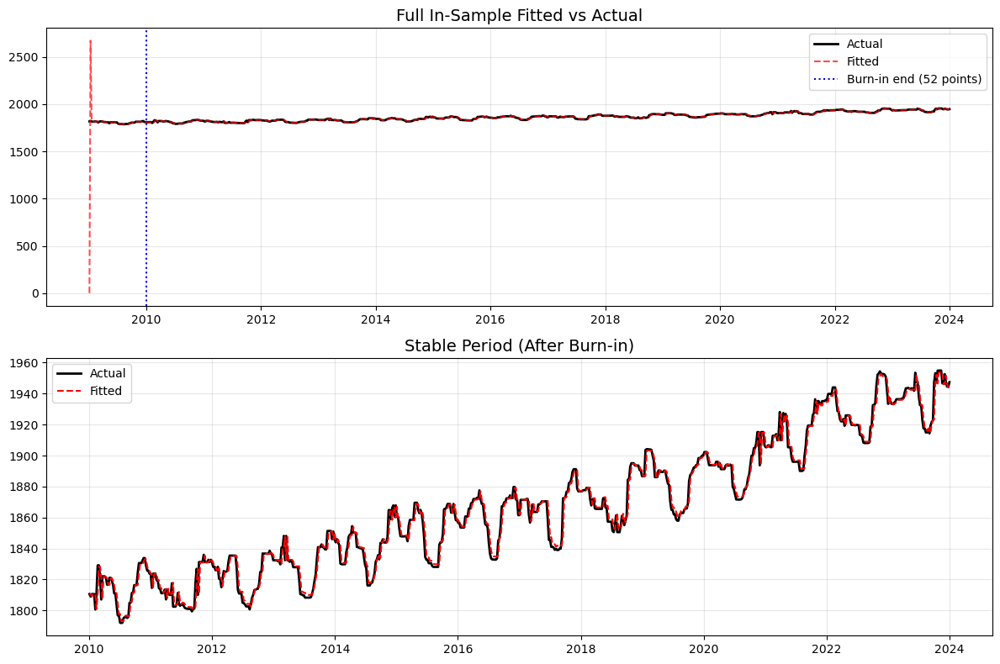

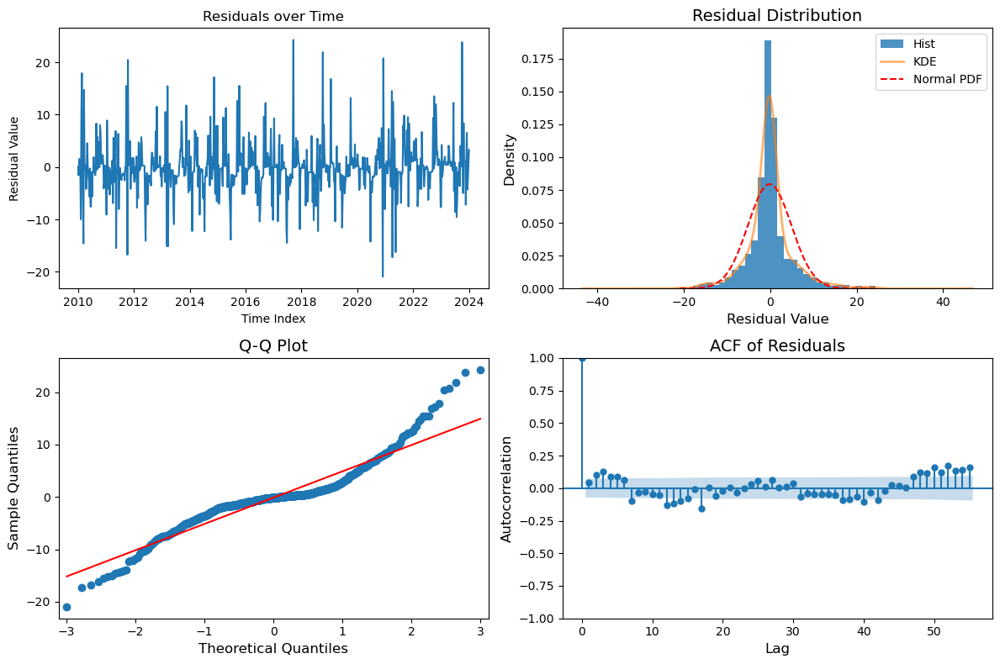


=== Residual Diagnostic Tests ===

--- Distribution Diagnostics ---
Jarque-Bera test:
	JB = 616.34
	p = 0.0000
	Skewness = 0.563
	kurtosis = 7.355

--- Autocorrelation Diagnostics ---
Ljung-Box Test:
(H0: No autocorrelation up to specified lags)
	lag 1: p = 0.2589
	lag 4: p = 0.0000
	lag 13: p = 0.0000
	lag 26: p = 0.0000
	lag 52: p = 0.0000

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0001***
	Lag 8: p-value = 0.0002***
	Lag 12: p-value = 0.0009***
	Lag 26: p-value = 0.0105***

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.8007
White: p = 0.7057


In [53]:
# I will run an analysis on the best non-log SARIMA model - seasonal order tune

results_111000, stable_residuals_111000 = in_sample_resid_analysis(
    train_recent15,
    order=(1,1,1),
    seasonal_order=(0,0,0,52),
    run_hetero=True
)

**Interpretation of model orders**

- D=0 removed the spike at 2010-01-03
  - While non-seasonal and seasonal differencing resulted in stationarity in prior tests, non-seasonal differencing alone led to stationarity and seasonal differencing alone did not.  Considering that greenhouse gases generally exhibit smooth seasonal cycle, as opposed to abrupt changes from one season to the next, seasonal differencing likely introduces problems that the model struggles with, possibly artifactual volatility.  
- accuracy metrics are much improved from model(s) with D=1, and are quite good.
- However: 
  - Residuals are non-normally distributed, but may be reasonable for greenhouse gas data.
  - autocorrelation remains for lags 4, 13, 26, and 52, which may all be due to remainaing seasonal patterns.
  - ARCH effects (conditional volatility) are present, which isn't suprising for atmospheric data.

Next steps:
- Adjust seasonal model terms in an effort to minimize autocorrelation and hopefully improve the distribution of residuals.
- Model the conditional volatility with GARCH

## TimeSeriesSplit where D = 0

In [54]:
# Run TimeSeriesSplit on d=1, D = 0, and range of non-seasonal and seasonal orders informed by previous TimeSerieSplit results

def get_models_from_acf_pacf():
    '''Generate candidate models with combinations of orders in specified range'''
    models = []

    for p in range(0, 8):
        for q in range(0, 3):
            for P in [0, 1]:
                for Q in range(0, 3):
                    models.append({
                        'order': (p, 1, q),
                        'seasonal_order': (P, 0, Q, 52)
                    })
    return models

final_models = get_models_from_acf_pacf()
print(f'Generated {len(final_models)} models for evaluation\n')

final_models_df = pd.DataFrame(final_models)
print(final_models_df)

Generated 144 models for evaluation

         order seasonal_order
0    (0, 1, 0)  (0, 0, 0, 52)
1    (0, 1, 0)  (0, 0, 1, 52)
2    (0, 1, 0)  (0, 0, 2, 52)
3    (0, 1, 0)  (1, 0, 0, 52)
4    (0, 1, 0)  (1, 0, 1, 52)
..         ...            ...
139  (7, 1, 2)  (0, 0, 1, 52)
140  (7, 1, 2)  (0, 0, 2, 52)
141  (7, 1, 2)  (1, 0, 0, 52)
142  (7, 1, 2)  (1, 0, 1, 52)
143  (7, 1, 2)  (1, 0, 2, 52)

[144 rows x 2 columns]


In [55]:
# Run TimeSeriesSplit CV on models list to find more optimal seasonal orders

print('Starting model evaluation...')
final_model_results_df = evaluate_models_tscv(
    models_list=final_models,
    data=train_recent15
)

sorted_final_models_df = final_model_results_df.sort_values(by='RMSE_mean')
print('Final candidate models for train set sorted by RMSE mean')
print(sorted_final_models_df)

Starting model evaluation...
Evaluating 144 models with 5 folds each
Total iterations: 720

Fold 1: Train=510, Val=52
Fold 2: Train=562, Val=52
Fold 3: Train=614, Val=52
Fold 4: Train=666, Val=52
Fold 5: Train=718, Val=52



Models:  60%|██████    | 87/144 [5:49:41<13:17:49, 839.82s/it]C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Model ((4, 1, 2), (1, 0, 0, 52)) did not converge on fold 4


Models:  62%|██████▏   | 89/144 [6:05:50<10:03:35, 658.47s/it]C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
Models:  62%|██████▎   | 90/144 [7:18:27<26:31:07, 1767.92s/it]

Model ((4, 1, 2), (1, 0, 2, 52)) did not converge on fold 5


Models: 100%|██████████| 144/144 [12:45:17<00:00, 318.87s/it]  


Total duration: 765.28 minutes
Average per model: 5.31 minutes

Number of models successfully evaluated: 144
Final candidate models for train set sorted by RMSE mean
         order seasonal_order  successful_folds  convergence_rate  RMSE_mean  \
120  (6, 1, 2)  (0, 0, 0, 52)                 5               1.0  16.010054   
102  (5, 1, 2)  (0, 0, 0, 52)                 5               1.0  16.061155   
115  (6, 1, 1)  (0, 0, 1, 52)                 5               1.0  16.196947   
121  (6, 1, 2)  (0, 0, 1, 52)                 5               1.0  16.205337   
109  (6, 1, 0)  (0, 0, 1, 52)                 5               1.0  16.223684   
..         ...            ...               ...               ...        ...   
70   (3, 1, 2)  (1, 0, 1, 52)                 5               1.0  21.307429   
52   (2, 1, 2)  (1, 0, 1, 52)                 5               1.0  21.316739   
29   (1, 1, 1)  (1, 0, 2, 52)                 5               1.0  21.326120   
35   (1, 1, 2)  (1, 0, 2, 52)    

In [56]:
print(sorted_final_models_df.head(15))

         order seasonal_order  successful_folds  convergence_rate  RMSE_mean  \
120  (6, 1, 2)  (0, 0, 0, 52)                 5               1.0  16.010054   
102  (5, 1, 2)  (0, 0, 0, 52)                 5               1.0  16.061155   
115  (6, 1, 1)  (0, 0, 1, 52)                 5               1.0  16.196947   
121  (6, 1, 2)  (0, 0, 1, 52)                 5               1.0  16.205337   
109  (6, 1, 0)  (0, 0, 1, 52)                 5               1.0  16.223684   
97   (5, 1, 1)  (0, 0, 1, 52)                 5               1.0  16.257457   
90   (5, 1, 0)  (0, 0, 0, 52)                 5               1.0  16.259968   
114  (6, 1, 1)  (0, 0, 0, 52)                 5               1.0  16.268339   
91   (5, 1, 0)  (0, 0, 1, 52)                 5               1.0  16.270290   
96   (5, 1, 1)  (0, 0, 0, 52)                 5               1.0  16.281820   
78   (4, 1, 1)  (0, 0, 0, 52)                 5               1.0  16.287658   
60   (3, 1, 1)  (0, 0, 0, 52)           

In [57]:
print(sorted_final_models_df.tail(10))

         order seasonal_order  successful_folds  convergence_rate  RMSE_mean  \
132  (7, 1, 1)  (0, 0, 0, 52)                 5               1.0  21.166413   
138  (7, 1, 2)  (0, 0, 0, 52)                 5               1.0  21.279628   
28   (1, 1, 1)  (1, 0, 1, 52)                 5               1.0  21.298356   
88   (4, 1, 2)  (1, 0, 1, 52)                 5               1.0  21.299662   
34   (1, 1, 2)  (1, 0, 1, 52)                 5               1.0  21.299846   
70   (3, 1, 2)  (1, 0, 1, 52)                 5               1.0  21.307429   
52   (2, 1, 2)  (1, 0, 1, 52)                 5               1.0  21.316739   
29   (1, 1, 1)  (1, 0, 2, 52)                 5               1.0  21.326120   
35   (1, 1, 2)  (1, 0, 2, 52)                 5               1.0  21.353635   
30   (1, 1, 2)  (0, 0, 0, 52)                 5               1.0  21.375312   

     RMSE_std   MAE_mean     AIC_mean     BIC_mean  forecast_volatility  \
132  5.274382  17.772482  3654.944510  3694.

In [58]:
print((sorted_final_models_df['successful_folds']==5).sum())

142


### Check model robustness

In [59]:
# compare the stability of the top 7 models

print('=== Model Stability Analysis ===')
for idx, row in sorted_final_models_df.head(7).iterrows():
    rmse_std_pct = (row['RMSE_std'] / row['RMSE_mean']) * 100   # this is the coefficient of variation (CV) for the model's performance across folds
    print(f"{row['order']}{row['seasonal_order']}:")
    print(f"  RMSE: {row['RMSE_mean']:.2f} ± {row['RMSE_std']:.2f} ({rmse_std_pct:.1f}%)")
    print(f"  Convergence: {row['convergence_rate']:.0%}")    

=== Model Stability Analysis ===
(6, 1, 2)(0, 0, 0, 52):
  RMSE: 16.01 ± 3.61 (22.6%)
  Convergence: 100%
(5, 1, 2)(0, 0, 0, 52):
  RMSE: 16.06 ± 3.77 (23.5%)
  Convergence: 100%
(6, 1, 1)(0, 0, 1, 52):
  RMSE: 16.20 ± 3.56 (22.0%)
  Convergence: 100%
(6, 1, 2)(0, 0, 1, 52):
  RMSE: 16.21 ± 3.66 (22.6%)
  Convergence: 100%
(6, 1, 0)(0, 0, 1, 52):
  RMSE: 16.22 ± 3.62 (22.3%)
  Convergence: 100%
(5, 1, 1)(0, 0, 1, 52):
  RMSE: 16.26 ± 3.64 (22.4%)
  Convergence: 100%
(5, 1, 0)(0, 0, 0, 52):
  RMSE: 16.26 ± 3.59 (22.1%)
  Convergence: 100%


**Summary of results**

- TimeSeriesSplit
  - all models converged
  - 142/144 models converged on all 5 folds, 2/144 models converged on 4/5 folds.
  - Best model (6,1,2)(0,0,0,52) has RMSE = 16.01, which is ~ 19% better than the best prior model of (1,1,1)(0,0,0,52) = 19.03
  - 4/5 top models have p = 6
  - top 15 models have P = 0 and Q = 0 or 1.
  - 7/10 bottom models have P = 1 and Q = 1 or 2.
  - Top model (6,1,2)(0,0,0,52) based on RMSE (16.01 +/- 3.61 ppb (22.6%))
<br>
<br>
- Coefficent of Variation (CV)
  - CV = 22.6% suggests that the model has good stability (<15% = exceptional stability, >35% = poor stability)
  - potential causes for variations in folds/periods include: atmospheric events (ENSO, volcanic erruptions, unusual weather patterns), emission changes (policy and/or economic shifts), natural variability, instrument/calibration changes.
  - Top models for stability: (6,1,1)(0,0,1,52) and (5,1,0)(0,0,0,52)

Conclusions:
- top models have complex non-seasonal orders (AR = 5 or 6, MA = 0 or 1) and simple seasonal orders (AR = 0, MA = 0 or 1).
- seasonal AR terms are detrimental to the model
- all top models have similar stability based on the coefficient of variation results.
- SARIMA(6,1,2)(0,0,0,52) is the best model thus far.  

### In-sample residual analysis of top models where D = 0

Using 731 residuals for diagnostics (first 52 excluded as burn_in)

--- In-Sample Accuracy (after burn-in) ---
RMSE: 4.981
MAE:  3.077
MAPE: 0.16%
R2:   0.986


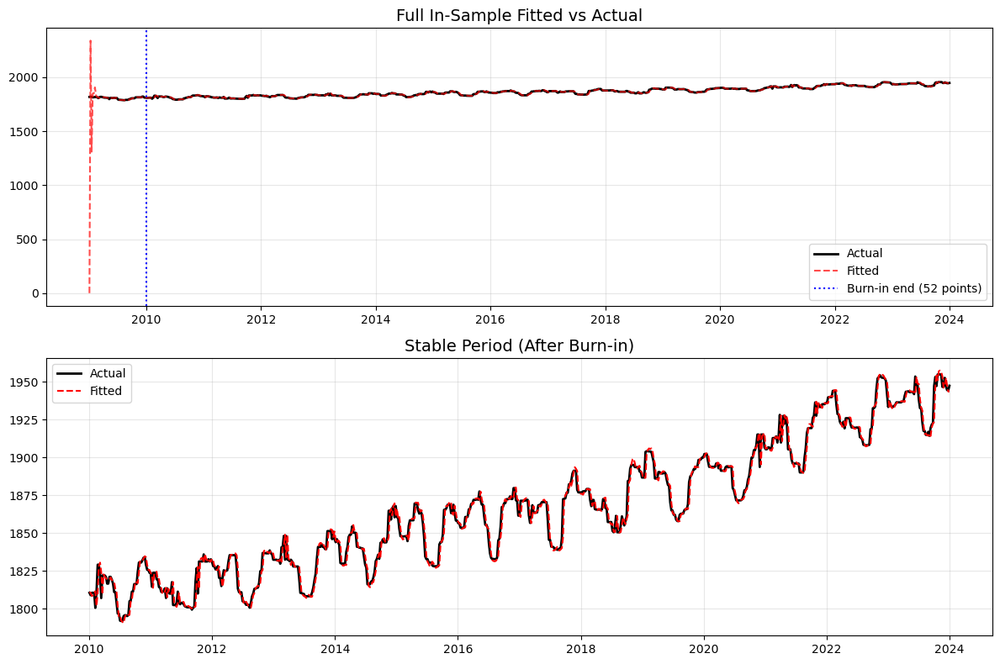

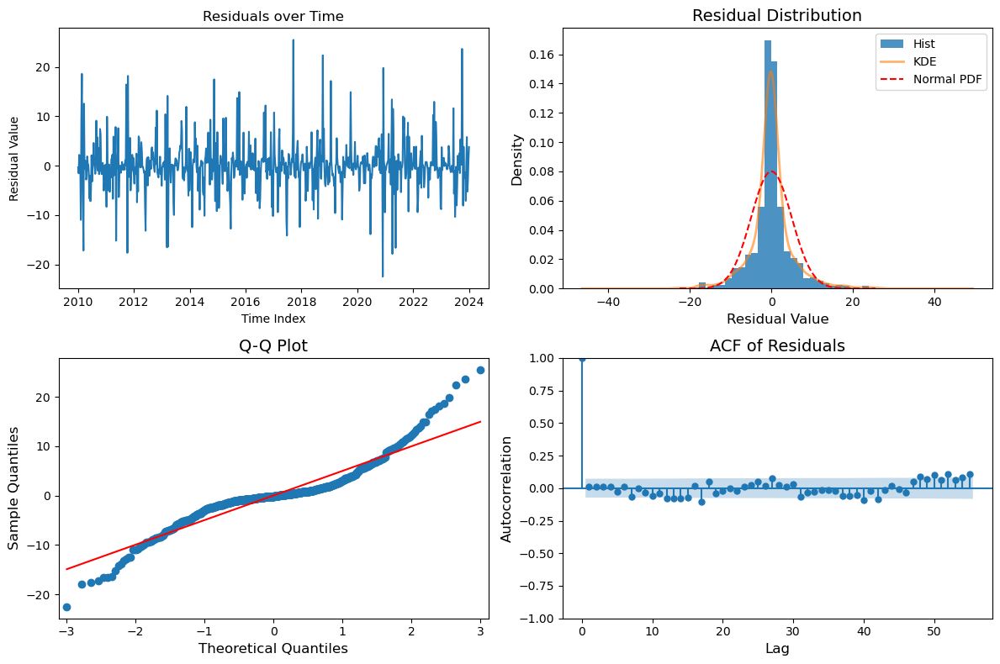


=== Residual Diagnostic Tests ===

--- Distribution Diagnostics ---
Jarque-Bera test:
	JB = 704.10
	p = 0.0000
	Skewness = 0.422
	kurtosis = 7.733

--- Autocorrelation Diagnostics ---
Ljung-Box Test:
(H0: No autocorrelation up to specified lags)
	lag 1: p = 0.7977
	lag 4: p = 0.9867
	lag 13: p = 0.1546
	lag 26: p = 0.0274
	lag 52: p = 0.0000

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0001***
	Lag 8: p-value = 0.0002***
	Lag 12: p-value = 0.0006***
	Lag 26: p-value = 0.0148***

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.6810
White: p = 0.6516


In [60]:
results_612000, stable_residuals_612000 = in_sample_resid_analysis(
    train_recent15,
    order=(6,1,2),
    seasonal_order=(0,0,0,52),
    run_hetero=True
)

C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Using 731 residuals for diagnostics (first 52 excluded as burn_in)

--- In-Sample Accuracy (after burn-in) ---
RMSE: 4.930
MAE:  3.095
MAPE: 0.17%
R2:   0.986


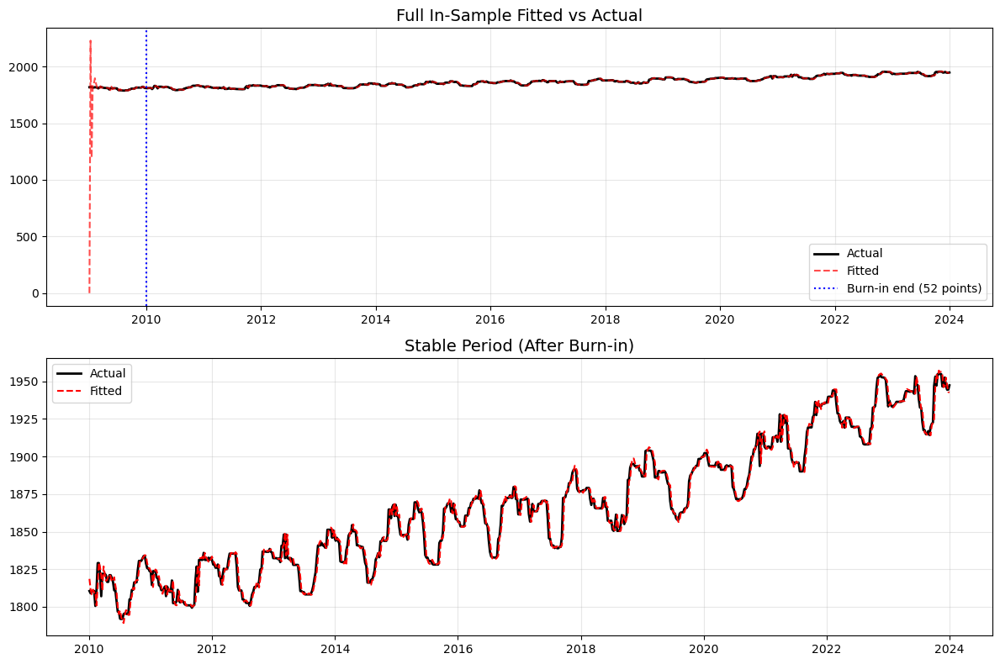

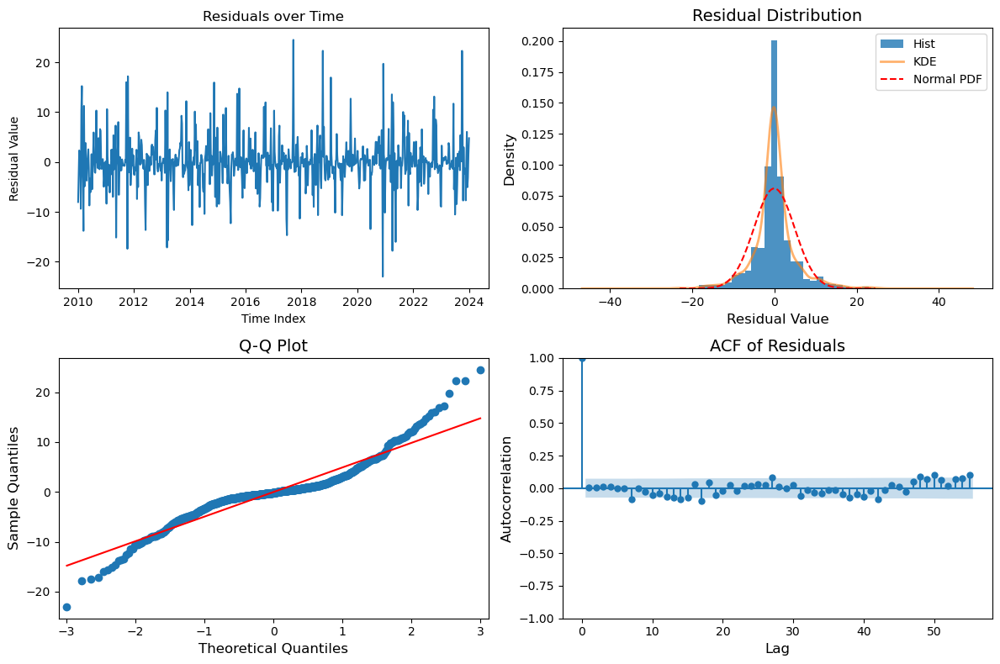


=== Residual Diagnostic Tests ===

--- Distribution Diagnostics ---
Jarque-Bera test:
	JB = 589.74
	p = 0.0000
	Skewness = 0.366
	kurtosis = 7.339

--- Autocorrelation Diagnostics ---
Ljung-Box Test:
(H0: No autocorrelation up to specified lags)
	lag 1: p = 0.9577
	lag 4: p = 0.9959
	lag 13: p = 0.2127
	lag 26: p = 0.0375
	lag 52: p = 0.0004

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0001***
	Lag 8: p-value = 0.0002***
	Lag 12: p-value = 0.0006***
	Lag 26: p-value = 0.0100***

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.7748
White: p = 0.7348


In [63]:
results_612001, stable_residuals_612001 = in_sample_resid_analysis(
    train_recent15,
    order=(6,1,2),
    seasonal_order=(0,0,1,52),
    run_hetero=True
)

**Conclusion**

SARIMA(6,1,2)(0,0,0,52) has the best in-sample performance based on the combinationn of accuracy measurements, residual distribution, and autocorrelation, though seasonal structure remains significant based on Ljung-Box p-values < 0.05 at lags 26 and 52. There is also an MLE convergence warning that should be addressed.   

I will try to model the seasonal structure with exogenous Fourier terms.  But, first I will attempt to stabilize the model with different estimation methods since there were convergence warnings. 

Using 731 residuals for diagnostics (first 52 excluded as burn_in)

--- In-Sample Accuracy (after burn-in) ---
RMSE: 4.987
MAE:  3.069
MAPE: 0.16%
R2:   0.986


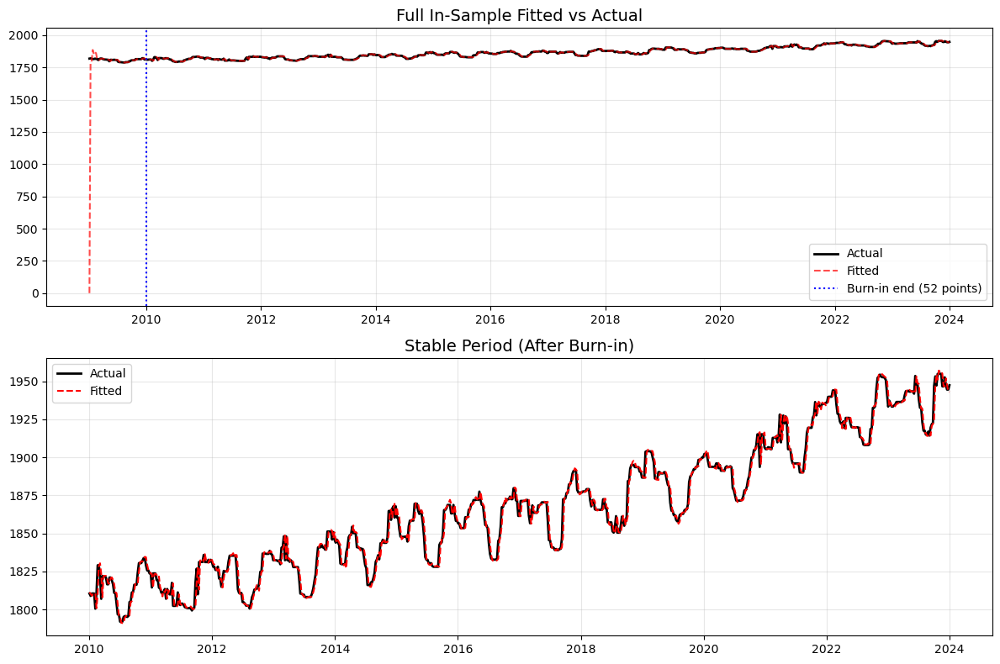

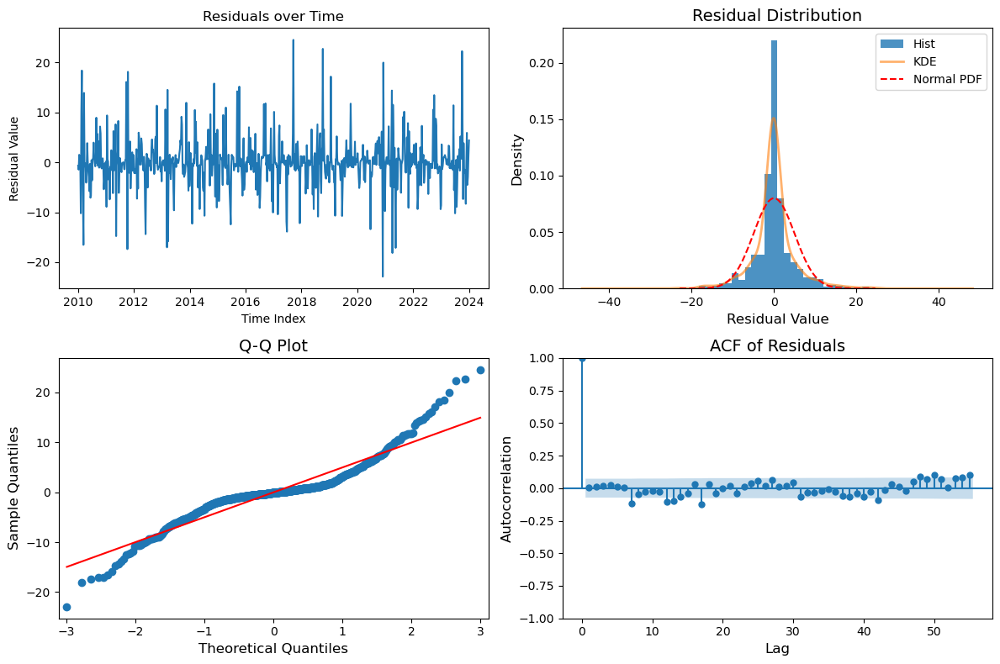


=== Residual Diagnostic Tests ===

--- Distribution Diagnostics ---
Jarque-Bera test:
	JB = 640.11
	p = 0.0000
	Skewness = 0.373
	kurtosis = 7.523

--- Autocorrelation Diagnostics ---
Ljung-Box Test:
(H0: No autocorrelation up to specified lags)
	lag 1: p = 0.8666
	lag 4: p = 0.9556
	lag 13: p = 0.0083
	lag 26: p = 0.0016
	lag 52: p = 0.0000

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0000***
	Lag 8: p-value = 0.0001***
	Lag 12: p-value = 0.0002***
	Lag 26: p-value = 0.0032***

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.6900
White: p = 0.6368


In [66]:
results_612001, stable_residuals_612001 = in_sample_resid_analysis(
    train_recent15,
    order=(6,1,2),
    seasonal_order=(0,0,1,52),
    estimation_method='powell',
    run_hetero=True
)

**Interpretation of results**

Since none of the models effectively handle the seasonal pattern (Ljung-Box p < 0.05 at lag 52), I will try exogenous Fourier terms 

# Fourier seasonal regressors as exogenous variable

In [536]:
def make_fourier_terms(index, period=52, K=4):
    '''
    index  : pd.DatetimeIndex (weekly)
    period : int (e.g. 52 weeks)
    K      : number of harmonic pairs (1..K)
    returns: DataFrame of shape (len(index), 2*K) with sin_k and cos_k columns
    '''
    # integer time t (0,1,2,...) aligned with index
    t = np.arange(len(index))
    fourier = {}
    for k in range(1, K+1):
        fourier[f'sin_{k}'] = np.sin(2 * np.pi * k * t / period)
        fourier[f'cos_{k}'] = np.cos(2 * np.pi * k * t / period)
    return pd.DataFrame(fourier, index=index)

In [539]:
# function to evaluate K choices (uses the evaluate_models_tscv which accepts exog)

def select_best_K(models_list, data, exog_index, K_candidates=[1,2,3,4], n_splits=5):
    results = []
    for K in K_candidates:
        exog_k = make_fourier_terms(exog_index, period=52, K=K)
        df_res = evaluate_models_tscv(
            models_list=models_list,
            data=data,
            exog=exog_k,
            n_splits=n_splits,
            estimation_method='powell'
        )
        # choose best by RMSE_mean (ensure non-empty)
        if not df_res.empty:
            best_row = df_res.sort_values('RMSE_mean').iloc[0]
            results.append({'K': K,
                            'best_order': best_row['order'],
                            'best_seasonal': best_row['seasonal_order'],
                            'RMSE_mean': best_row['RMSE_mean'],
                            'AIC_mean': best_row['AIC_mean'],
                            'BIC_mean': best_row['BIC_mean']})
        else:
            results.append({'K': K, 
                            'best_order': None, 
                            'best_seasonal': None, 
                            'RMSE_mean': np.nan, 
                            'AIC_mean': np.nan,
                            'BIC_mean': np.nan})
    return pd.DataFrame(results)

In [69]:
# choose a candidate non-seasonal model list (example: p=0..6, q=0..2)

models_list = []
for p in range(0,7):
    for q in range(0,3):
        models_list.append({'order': (p,1,q), 'seasonal_order': (0,0,0,0)})

# run selection over K=1..3 on train_recent15
K_choices = [1,2,3,4]
k_results = select_best_K(models_list, train_recent15, train_recent15.index, K_candidates=K_choices)
print(k_results.sort_values('RMSE_mean'))

Evaluating 21 models with 5 folds each
Total iterations: 105

Fold 1: Train=510, Val=52
Fold 2: Train=562, Val=52
Fold 3: Train=614, Val=52
Fold 4: Train=666, Val=52
Fold 5: Train=718, Val=52



Models: 100%|██████████| 21/21 [00:38<00:00,  1.85s/it]



Total duration: 0.65 minutes
Average per model: 0.03 minutes

Number of models successfully evaluated: 21
Evaluating 21 models with 5 folds each
Total iterations: 105

Fold 1: Train=510, Val=52
Fold 2: Train=562, Val=52
Fold 3: Train=614, Val=52
Fold 4: Train=666, Val=52
Fold 5: Train=718, Val=52



Models: 100%|██████████| 21/21 [00:58<00:00,  2.80s/it]



Total duration: 0.98 minutes
Average per model: 0.05 minutes

Number of models successfully evaluated: 21
Evaluating 21 models with 5 folds each
Total iterations: 105

Fold 1: Train=510, Val=52
Fold 2: Train=562, Val=52
Fold 3: Train=614, Val=52
Fold 4: Train=666, Val=52
Fold 5: Train=718, Val=52



Models: 100%|██████████| 21/21 [01:16<00:00,  3.64s/it]



Total duration: 1.27 minutes
Average per model: 0.06 minutes

Number of models successfully evaluated: 21
Evaluating 21 models with 5 folds each
Total iterations: 105

Fold 1: Train=510, Val=52
Fold 2: Train=562, Val=52
Fold 3: Train=614, Val=52
Fold 4: Train=666, Val=52
Fold 5: Train=718, Val=52



Models: 100%|██████████| 21/21 [01:35<00:00,  4.53s/it]


Total duration: 1.59 minutes
Average per model: 0.08 minutes

Number of models successfully evaluated: 21
   K best_order best_seasonal  RMSE_mean     AIC_mean     BIC_mean
0  1  (6, 1, 2)  (0, 0, 0, 0)  12.346729  3664.073397  3712.485460
1  2  (0, 1, 0)  (0, 0, 0, 0)  15.331360  3635.047206  3657.094318
3  4  (0, 1, 0)  (0, 0, 0, 0)  15.812056  3638.550226  3678.235029
2  3  (0, 1, 0)  (0, 0, 0, 0)  16.312965  3636.136741  3667.002699


##### **Interpretation of results**

- K=1 gives the best cross-validated RMSE of 12.35 and, therefore best captures the dominant seasonal cycle.  

In [540]:
# choose a candidate non-seasonal model list (example: p=0..6, d=0 or 1, q=0..2)

models_list = []
for p in range(0,7):
    for d in [0, 1]:
        for q in range(0,3):
            models_list.append({'order': (p,d,q), 'seasonal_order': (0,0,0,0)})

# run selection over K=1..3 on train_recent15
K_choices = [1,2,3,4]
k_results = select_best_K(models_list, train_recent15, train_recent15.index, K_candidates=K_choices)
print(k_results.sort_values('RMSE_mean'))

Evaluating 42 models with 5 folds each
Total iterations: 210

Fold 1: Train=510, Val=52
Fold 2: Train=562, Val=52
Fold 3: Train=614, Val=52
Fold 4: Train=666, Val=52
Fold 5: Train=718, Val=52



Models: 100%|██████████| 42/42 [00:49<00:00,  1.17s/it]



Total duration: 0.82 minutes
Average per model: 0.02 minutes

Number of models successfully evaluated: 42
Evaluating 42 models with 5 folds each
Total iterations: 210

Fold 1: Train=510, Val=52
Fold 2: Train=562, Val=52
Fold 3: Train=614, Val=52
Fold 4: Train=666, Val=52
Fold 5: Train=718, Val=52



Models: 100%|██████████| 42/42 [01:18<00:00,  1.88s/it]



Total duration: 1.31 minutes
Average per model: 0.03 minutes

Number of models successfully evaluated: 42
Evaluating 42 models with 5 folds each
Total iterations: 210

Fold 1: Train=510, Val=52
Fold 2: Train=562, Val=52
Fold 3: Train=614, Val=52
Fold 4: Train=666, Val=52
Fold 5: Train=718, Val=52



Models: 100%|██████████| 42/42 [01:19<00:00,  1.90s/it]



Total duration: 1.33 minutes
Average per model: 0.03 minutes

Number of models successfully evaluated: 42
Evaluating 42 models with 5 folds each
Total iterations: 210

Fold 1: Train=510, Val=52
Fold 2: Train=562, Val=52
Fold 3: Train=614, Val=52
Fold 4: Train=666, Val=52
Fold 5: Train=718, Val=52



Models: 100%|██████████| 42/42 [01:35<00:00,  2.28s/it]


Total duration: 1.60 minutes
Average per model: 0.04 minutes

Number of models successfully evaluated: 42
   K best_order best_seasonal  RMSE_mean     AIC_mean     BIC_mean
0  1  (3, 0, 2)  (0, 0, 0, 0)  11.105640  3693.019213  3728.281317
2  3  (3, 0, 2)  (0, 0, 0, 0)  11.732438  3599.092076  3651.985232
3  4  (6, 0, 1)  (0, 0, 0, 0)  12.096166  3759.499280  3829.943559
1  2  (6, 0, 1)  (0, 0, 0, 0)  12.657963  3769.622356  3822.455565


## Compare SARIMA and ARIMAX models

In [70]:
# pick best_K, get exog and run a final CV for a small model set and compare to SARIMA

best_K = int(k_results.sort_values('RMSE_mean').iloc[0]['K'])
exog_best = make_fourier_terms(train_recent15.index, period=52, K=best_K)

# small set of nonseasonal candidates to compare
arimax_candidates = [
    {'order': (0,1,0), 'seasonal_order': (0,0,0,0)},
    {'order': (0,1,1), 'seasonal_order': (0,0,0,0)},
    {'order': (1,1,0), 'seasonal_order': (0,0,0,0)},
    {'order': (1,1,1), 'seasonal_order': (0,0,0,0)},
    {'order': (5,1,0), 'seasonal_order': (0,0,0,0)},
    {'order': (5,1,1), 'seasonal_order': (0,0,0,0)},
    {'order': (5,1,2), 'seasonal_order': (0,0,0,0)},
    {'order': (6,1,0), 'seasonal_order': (0,0,0,0)},
    {'order': (6,1,1), 'seasonal_order': (0,0,0,0)},
    {'order': (6,1,2), 'seasonal_order': (0,0,0,0)}
]

res_arimax = evaluate_models_tscv(arimax_candidates, train_recent15, exog=exog_best, n_splits=5)
print(f'ARIMAX-with-Fourier results: K={best_K}')
print(res_arimax.sort_values('RMSE_mean'))

# Compare to a few SARIMA seasonal models (example)
sarima_candidates = [
    {'order': (0,1,0), 'seasonal_order': (0,0,0,52)},
    {'order': (0,1,0), 'seasonal_order': (0,0,1,52)},
    {'order': (0,1,1), 'seasonal_order': (0,0,0,52)},
    {'order': (0,1,1), 'seasonal_order': (0,0,1,52)},
    {'order': (1,1,0), 'seasonal_order': (0,0,0,52)},
    {'order': (1,1,0), 'seasonal_order': (0,0,1,52)},
    {'order': (1,1,1), 'seasonal_order': (0,0,0,52)},
    {'order': (1,1,1), 'seasonal_order': (0,0,1,52)},
    {'order': (5,1,0), 'seasonal_order': (0,0,0,52)},
    {'order': (5,1,0), 'seasonal_order': (0,0,1,52)},
    {'order': (5,1,1), 'seasonal_order': (0,0,0,52)},
    {'order': (5,1,1), 'seasonal_order': (0,0,1,52)},
    {'order': (5,1,2), 'seasonal_order': (0,0,0,52)},
    {'order': (5,1,2), 'seasonal_order': (0,0,1,52)},
    {'order': (6,1,0), 'seasonal_order': (0,0,0,52)},
    {'order': (6,1,0), 'seasonal_order': (0,0,1,52)},
    {'order': (6,1,1), 'seasonal_order': (0,0,0,52)},
    {'order': (6,1,1), 'seasonal_order': (0,0,1,52)},
    {'order': (6,1,2), 'seasonal_order': (0,0,0,52)},
    {'order': (6,1,2), 'seasonal_order': (0,0,1,52)}
]
res_sarima = evaluate_models_tscv(sarima_candidates, train_recent15, exog=None, n_splits=5)
print('SARIMA seasonal results:')
print(res_sarima.sort_values('RMSE_mean'))

Evaluating 10 models with 5 folds each
Total iterations: 50

Fold 1: Train=510, Val=52
Fold 2: Train=562, Val=52
Fold 3: Train=614, Val=52
Fold 4: Train=666, Val=52
Fold 5: Train=718, Val=52



Models: 100%|██████████| 10/10 [00:17<00:00,  1.76s/it]



Total duration: 0.29 minutes
Average per model: 0.03 minutes

Number of models successfully evaluated: 10
ARIMAX-with-Fourier results: K=1
       order seasonal_order  successful_folds  convergence_rate  RMSE_mean  \
9  (6, 1, 2)   (0, 0, 0, 0)                 5               1.0  12.346729   
4  (5, 1, 0)   (0, 0, 0, 0)                 5               1.0  12.451088   
5  (5, 1, 1)   (0, 0, 0, 0)                 5               1.0  12.464415   
7  (6, 1, 0)   (0, 0, 0, 0)                 5               1.0  12.469989   
0  (0, 1, 0)   (0, 0, 0, 0)                 5               1.0  12.750325   
3  (1, 1, 1)   (0, 0, 0, 0)                 5               1.0  12.759309   
1  (0, 1, 1)   (0, 0, 0, 0)                 5               1.0  12.792489   
2  (1, 1, 0)   (0, 0, 0, 0)                 5               1.0  12.795269   
8  (6, 1, 1)   (0, 0, 0, 0)                 5               1.0  14.522618   
6  (5, 1, 2)   (0, 0, 0, 0)                 5               1.0  14.780019   

 

Models: 100%|██████████| 20/20 [14:39<00:00, 43.97s/it]


Total duration: 14.66 minutes
Average per model: 0.73 minutes

Number of models successfully evaluated: 20
SARIMA seasonal results:
        order seasonal_order  successful_folds  convergence_rate  RMSE_mean  \
18  (6, 1, 2)  (0, 0, 0, 52)                 5               1.0  16.010054   
12  (5, 1, 2)  (0, 0, 0, 52)                 5               1.0  16.061155   
17  (6, 1, 1)  (0, 0, 1, 52)                 5               1.0  16.196947   
19  (6, 1, 2)  (0, 0, 1, 52)                 5               1.0  16.205337   
15  (6, 1, 0)  (0, 0, 1, 52)                 5               1.0  16.223684   
11  (5, 1, 1)  (0, 0, 1, 52)                 5               1.0  16.257457   
8   (5, 1, 0)  (0, 0, 0, 52)                 5               1.0  16.259968   
16  (6, 1, 1)  (0, 0, 0, 52)                 5               1.0  16.268339   
9   (5, 1, 0)  (0, 0, 1, 52)                 5               1.0  16.270290   
10  (5, 1, 1)  (0, 0, 0, 52)                 5               1.0  16.281820  

**Interpretation of comparison between ARIMAX (Fourier terms) and SARIMA models**

- ARIMAX
  - Best K was determined to be 1 (K = 1)
  - The top 8 (of 10) models have similar RMSE values.
  - (6,1,2) and (5,1,0) + FT(K=1) are the top two models.
  - The simplest model (0,1,0) has the fifth lowest RMSE, but has autocorrelation at lag 10 (and 52).  
  - The top four ARIMAX model residuals have no autocorrelation at lags 1, 5, and 10, but do have  autocorrelation at lag 52.  
  - The second to last model, (6,1,1) based on RMSE has the best performance for capturing seasonal structure with lag 52 p value = 0.017. 
  - ARIMAX models converge in 1.8 seconds on average.
<br>
<br>
- SARIMA
  - RMSE values for all models are significantly higher (~ 16.0-20.4) compared to the ARIMAX models (~ 12.3-14.8)
  - The top two models: (6,1,2)(0,0,0,52) and (5,1,2)(0,0,0,52).  So both ARIMAX and SARIMA agree on non-seasonal orders (6,1,2).  
  - As seen in previous TimeSeriesSplit CV model paramenter searches, The top two SARIMA models all have Q=0.
  - The residuals are cleaner in that all models, except (0,1,1)(0,0,0,52), have Ljung-Box p-values > 0.05 for lags 1, 5, and 10.  However, all of the models do show autocorrelation at lag 52 suggesting that the seasonal structure is not being fully captured by the models.   
  - SARIMA models take much longer to fit/compute compared to the ARIMAX models (~ 43 seconds/model vs ~ 1.8 seconds/model).

Next steps:
- Perform in-sample residual analysis of the top ARIMAX models
- check K = 2, 3, and 4 in attempt to capture remaining seasonal structure

## In-sample residual analyis of ARIMAX models

In-sample residual analysis for ARIMAX(6, 1, 2)+FT(K=1)



C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Using 731 residuals for diagnostics (first 52 excluded as burn_in)

--- In-Sample Accuracy (after burn-in) ---
RMSE: 4.885
MAE:  3.154
MAPE: 0.17%
R2:   0.986


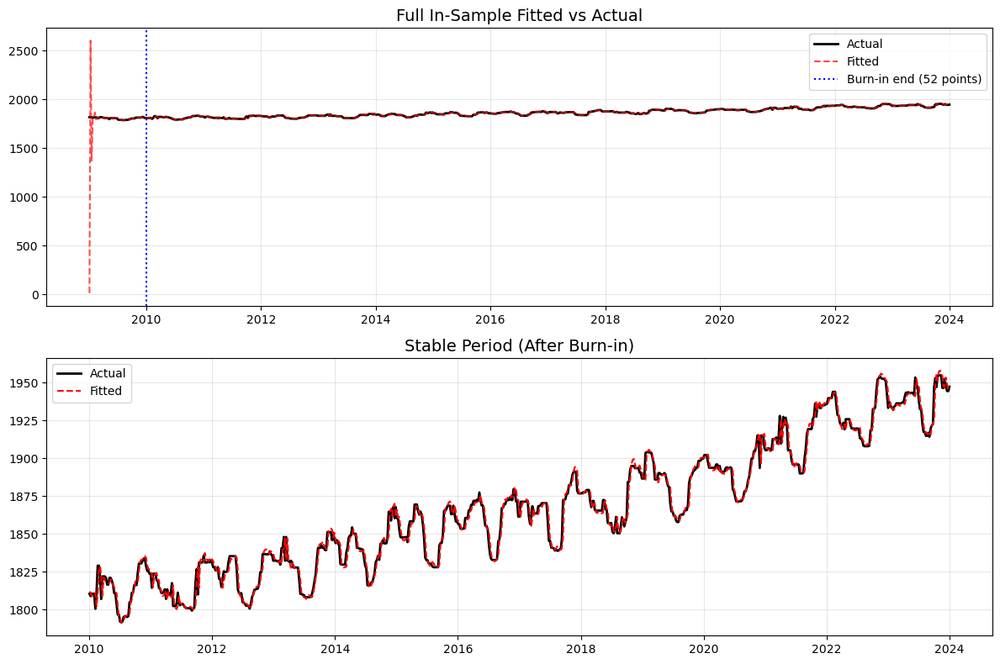

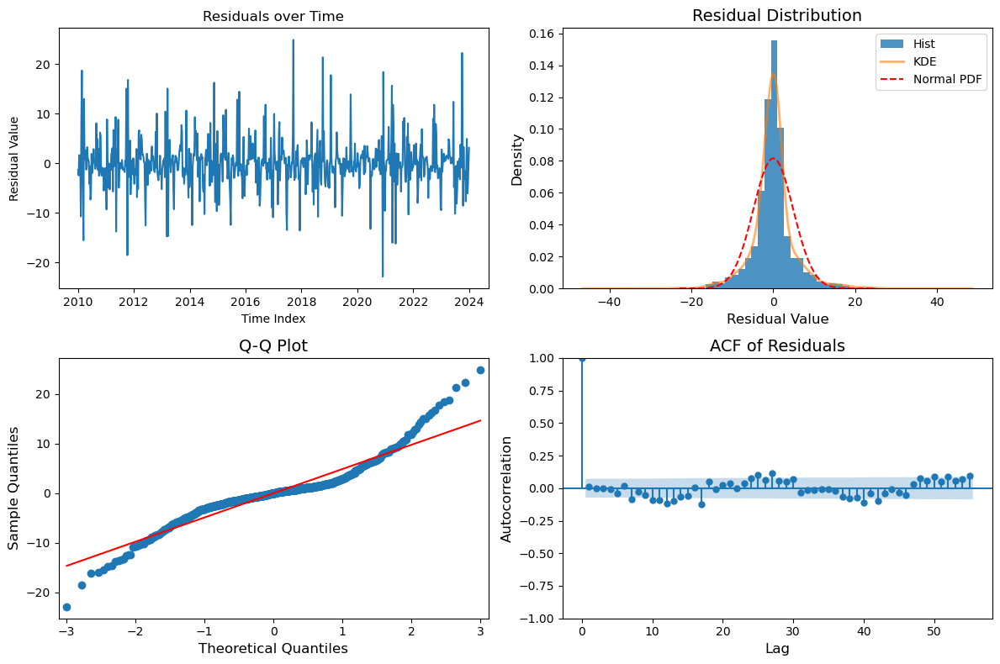


=== Residual Diagnostic Tests ===

--- Distribution Diagnostics ---
Jarque-Bera test:
	JB = 613.72
	p = 0.0000
	Skewness = 0.409
	kurtosis = 7.414

--- Autocorrelation Diagnostics ---
Ljung-Box Test:
(H0: No autocorrelation up to specified lags)
	lag 1: p = 0.7299
	lag 4: p = 0.9945
	lag 13: p = 0.0002
	lag 26: p = 0.0000
	lag 52: p = 0.0000

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0001***
	Lag 8: p-value = 0.0003***
	Lag 12: p-value = 0.0006***
	Lag 26: p-value = 0.0096***

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.7531
White: p = 0.7053


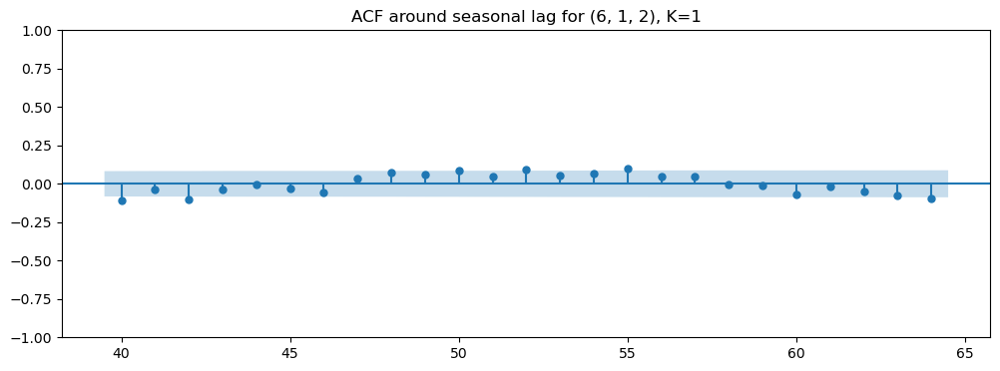

In-sample residual analysis for ARIMAX(5, 1, 0)+FT(K=1)

Using 731 residuals for diagnostics (first 52 excluded as burn_in)

--- In-Sample Accuracy (after burn-in) ---
RMSE: 4.935
MAE:  3.131
MAPE: 0.17%
R2:   0.986


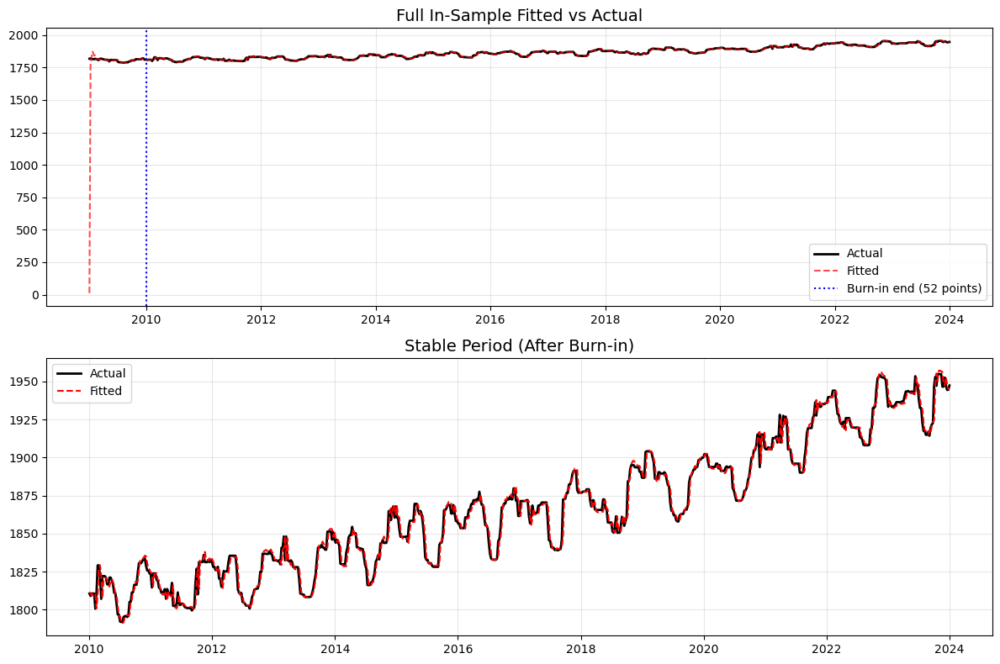

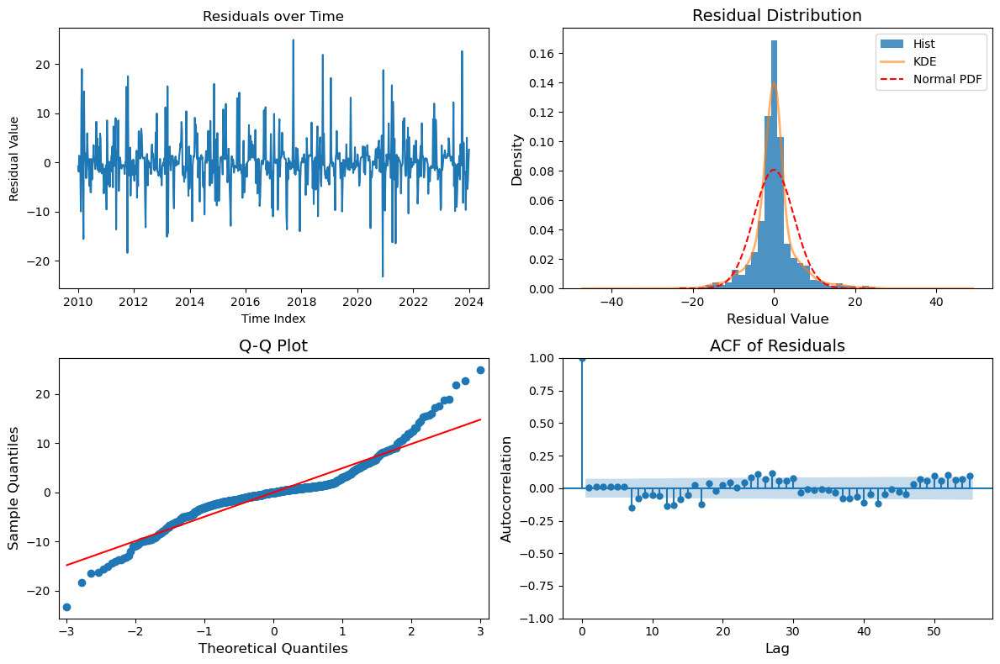


=== Residual Diagnostic Tests ===

--- Distribution Diagnostics ---
Jarque-Bera test:
	JB = 631.96
	p = 0.0000
	Skewness = 0.426
	kurtosis = 7.475

--- Autocorrelation Diagnostics ---
Ljung-Box Test:
(H0: No autocorrelation up to specified lags)
	lag 1: p = 0.8565
	lag 4: p = 0.9856
	lag 13: p = 0.0000
	lag 26: p = 0.0000
	lag 52: p = 0.0000

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0001***
	Lag 8: p-value = 0.0003***
	Lag 12: p-value = 0.0006***
	Lag 26: p-value = 0.0085***

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.7254
White: p = 0.6411


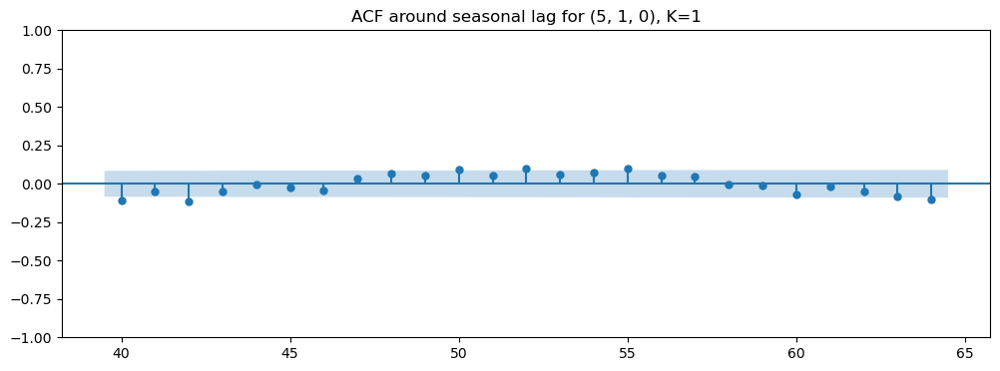

In-sample residual analysis for ARIMAX(6, 1, 1)+FT(K=1)

Using 731 residuals for diagnostics (first 52 excluded as burn_in)

--- In-Sample Accuracy (after burn-in) ---
RMSE: 4.927
MAE:  3.136
MAPE: 0.17%
R2:   0.986


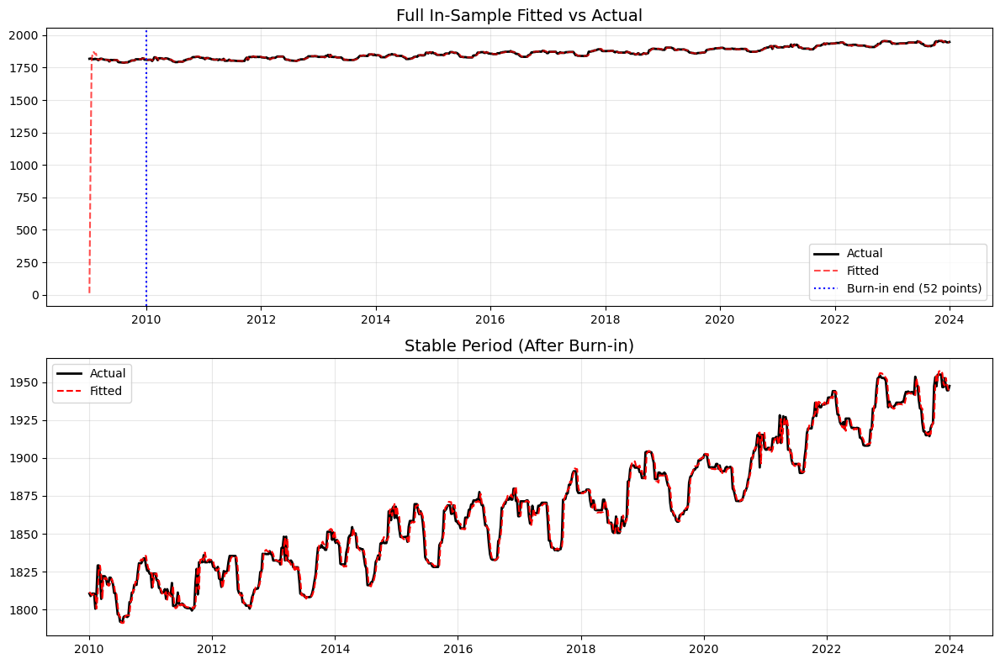

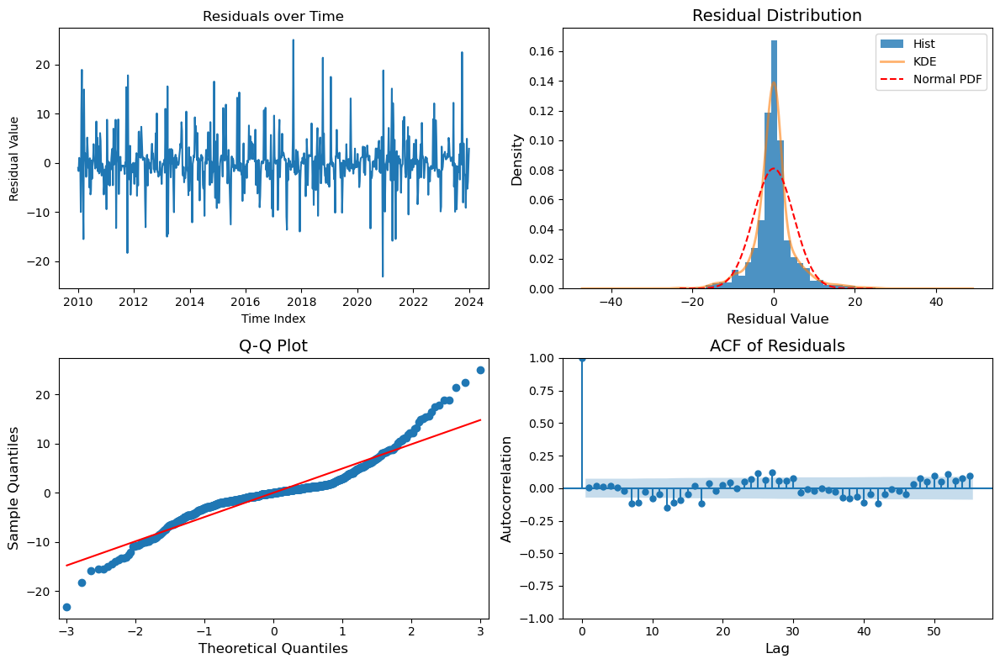


=== Residual Diagnostic Tests ===

--- Distribution Diagnostics ---
Jarque-Bera test:
	JB = 615.39
	p = 0.0000
	Skewness = 0.434
	kurtosis = 7.410

--- Autocorrelation Diagnostics ---
Ljung-Box Test:
(H0: No autocorrelation up to specified lags)
	lag 1: p = 0.9065
	lag 4: p = 0.9623
	lag 13: p = 0.0000
	lag 26: p = 0.0000
	lag 52: p = 0.0000

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0001***
	Lag 8: p-value = 0.0003***
	Lag 12: p-value = 0.0005***
	Lag 26: p-value = 0.0093***

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.6978
White: p = 0.6478


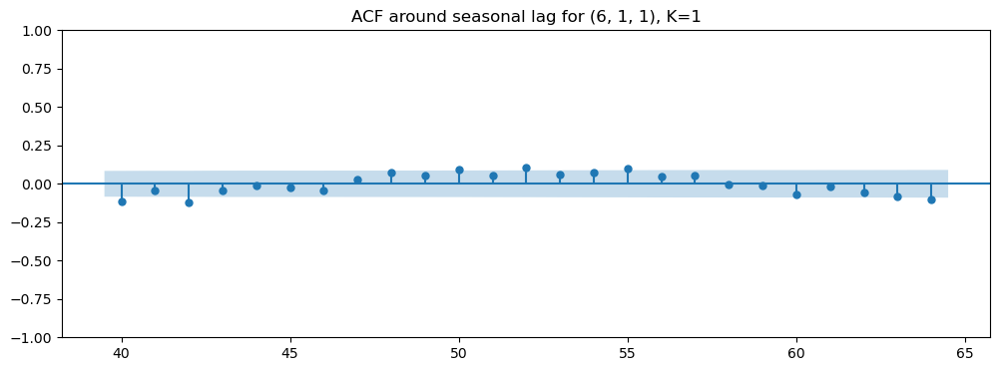

In [71]:
# analyize the top two ARIMAX models and the top model for autocorrelation

top_models = [
    ((6,1,2), (0,0,0,0), 1),  # best model based on RMSE
    ((5,1,0), (0,0,0,0), 1),  # second best model
    ((6,1,1), (0,0,0,0), 1)   # second worst model, but best for lag 52
]

for order, seasonal_order, K in top_models:
    print(f'In-sample residual analysis for ARIMAX{order}+FT(K={K})\n')
    exog = make_fourier_terms(train_recent15.index, period=52, K=K)
    results, stable_resids = in_sample_resid_analysis(
        train_recent15, 
        order=order,
        seasonal_order=seasonal_order,
        exog=exog,
        run_hetero=True
    )

    # specifically check ACF around lag 52
    fig, ax = plt.subplots(figsize=(12,4))
    plot_acf(stable_resids, lags=range(40,65), ax=ax)
    ax.set_title(f'ACF around seasonal lag for {order}, K={K}')
    plt.show()

## Optimize Fourier K value for top ARIMAX model

In [72]:
# I will try increaseing number of Fourier terms to handle the seasonal pattern

best_order = (6,1,2)
K_test_results = []

for K in [1, 2, 3, 4]:
    exog_k = make_fourier_terms(train_recent15.index, period=52, K=K)

    # fit and evaluate
    results_k = evaluate_models_tscv(
        models_list=[{'order': best_order, 'seasonal_order': (0,0,0,0)}],
        data=train_recent15,
        exog=exog_k,
        n_splits=5
    )

    # residual diagnostics at lag 52
    model_obj = SARIMAX(
        train_recent15, 
        order=best_order, 
        seasonal_order=(0,0,0,0),
        exog=exog_k,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    try:
        model_fit = model_obj.fit(
            method='lbfgs',
            max_iter=200,
            disp=0           # suppress output
        )
        convergence_warning=False
    except Exception as e:
        print(f'K={K}: failed to fit - {e}')
        continue
        
    residuals = model_fit.resid.iloc[52:]     # burn-in

    # Ljung-Box at lag 52
    lb_test = acorr_ljungbox(residuals, lags=[52], return_df=True)

    # store results
    K_test_results.append({
        'K': K,
        'RMSE_CV': results_k.iloc[0]['RMSE_mean'],
        'LB_52_pval': lb_test.iloc[0]['lb_pvalue'],
        'AIC': model_fit.aic,
        'BIC': model_fit.bic,
        'Converged': not convergence_warning
    })

    print(f"K={K}: RMSE={results_k.iloc[0]['RMSE_mean']:.3f}, " 
          f"LB-52_p={lb_test.iloc[0]['lb_pvalue']:.6f}, "
          f"AIC={model_fit.aic:.1f}")

# convert to DataFrame
K_test_df = pd.DataFrame(K_test_results)
print('\nFourier Term Comparison:')
print(K_test_df.sort_values('RMSE_CV'))

Evaluating 1 models with 5 folds each
Total iterations: 5

Fold 1: Train=510, Val=52
Fold 2: Train=562, Val=52
Fold 3: Train=614, Val=52
Fold 4: Train=666, Val=52
Fold 5: Train=718, Val=52



Models: 100%|██████████| 1/1 [00:05<00:00,  5.31s/it]
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\optimizer.py:19: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: max_iter. After release 0.14, this will raise.
  warnings.warn(



Total duration: 0.09 minutes
Average per model: 0.09 minutes

Number of models successfully evaluated: 1


C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


K=1: RMSE=12.347, LB-52_p=0.000000, AIC=4680.0
Evaluating 1 models with 5 folds each
Total iterations: 5

Fold 1: Train=510, Val=52
Fold 2: Train=562, Val=52
Fold 3: Train=614, Val=52
Fold 4: Train=666, Val=52
Fold 5: Train=718, Val=52



...

Models: 100%|██████████| 1/1 [00:08<00:00,  8.59s/it]
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\optimizer.py:19: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: max_iter. After release 0.14, this will raise.
  warnings.warn(



Total duration: 0.14 minutes
Average per model: 0.14 minutes

Number of models successfully evaluated: 1
K=3: RMSE=17.375, LB-52_p=0.136922, AIC=4582.4
Evaluating 1 models with 5 folds each
Total iterations: 5

Fold 1: Train=510, Val=52
Fold 2: Train=562, Val=52
Fold 3: Train=614, Val=52
Fold 4: Train=666, Val=52
Fold 5: Train=718, Val=52



Models: 100%|██████████| 1/1 [00:10<00:00, 10.75s/it]
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\optimizer.py:19: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: max_iter. After release 0.14, this will raise.
  warnings.warn(



Total duration: 0.18 minutes
Average per model: 0.18 minutes

Number of models successfully evaluated: 1
K=4: RMSE=17.178, LB-52_p=0.137250, AIC=4584.4

Fourier Term Comparison:
   K    RMSE_CV    LB_52_pval          AIC          BIC  Converged
0  1  12.346729  9.013894e-13  4679.973083  4731.168761       True
1  2  16.937054  1.186334e-01  4583.476187  4643.980170       True
3  4  17.178337  1.372504e-01  4584.361661  4663.482254       True
2  3  17.374779  1.369224e-01  4582.408310  4652.220598       True


C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


**Interpretation of the reults:**

- There is a significant trade off between forecast accuracy and capturing seasonal autocorrelation.  Increasing K to 2 significantly reduces seasonal autocorrelation, but increases RMSE by ~ 37%.  The seasonal pattern is primarily captured by the first Fourier harmonic (K = 1).
- I will stick with K = 1 due to the substantially better forecast accuracy (RMSE = 12.3).
- Try a hybrid approach of SARIMAX (seasonal orders and exogenous Fourier term, K = 1).  

In [73]:
# first, I will try to fix the convergence issues with better parameters 
# with estimation method lbfgs

best_order = (6,1,2)
K_test_results = []

for K in [1, 2, 3, 4]:
    exog_k = make_fourier_terms(train_recent15.index, period=52, K=K)

    # fit and evaluate
    results_k = evaluate_models_tscv(
        models_list=[{'order': best_order, 'seasonal_order': (0,0,0,0)}],
        data=train_recent15,
        exog=exog_k,
        n_splits=5
    )

    # residual diagnostics at lag 52
    model_obj = SARIMAX(
        train_recent15, 
        order=best_order, 
        seasonal_order=(0,0,0,0),
        exog=exog_k,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    try:
        model_fit = model_obj.fit(
            method='lbfgs',
            maxfun=20000,       # correct parameter for lbfgs
            factor=1e7,         # lower precision for faster convergence
            pgtol=1e-5,
            disp=True           # see optimization progress
        )
        convergence_warning=False
    except Exception as e:
        print(f'K={K}: failed to fit - {e}')
        continue
        
    residuals = model_fit.resid.iloc[52:]     # burn-in

    # Ljung-Box at lag 52
    lb_test = acorr_ljungbox(residuals, lags=[52], return_df=True)

    # store results
    K_test_results.append({
        'K': K,
        'RMSE_CV': results_k.iloc[0]['RMSE_mean'],
        'LB_52_pval': lb_test.iloc[0]['lb_pvalue'],
        'AIC': model_fit.aic,
        'BIC': model_fit.bic,
        'Converged': not convergence_warning
    })

    print(f"K={K}: RMSE={results_k.iloc[0]['RMSE_mean']:.3f}, " 
          f"LB-52_p={lb_test.iloc[0]['lb_pvalue']:.6f}, "
          f"AIC={model_fit.aic:.1f}")

# convert to DataFrame
K_test_df = pd.DataFrame(K_test_results)
print('\nFourier Term Comparison (estimation_method = powell):')
print(K_test_df.sort_values('RMSE_CV'))

Evaluating 1 models with 5 folds each
Total iterations: 5

Fold 1: Train=510, Val=52
Fold 2: Train=562, Val=52
Fold 3: Train=614, Val=52
Fold 4: Train=666, Val=52
Fold 5: Train=718, Val=52



Models: 100%|██████████| 1/1 [00:05<00:00,  5.60s/it]
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\optimizer.py:19: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: factor. After release 0.14, this will raise.
  warnings.warn(



Total duration: 0.09 minutes
Average per model: 0.09 minutes

Number of models successfully evaluated: 1


C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


K=1: RMSE=12.347, LB-52_p=0.000000, AIC=4680.0
Evaluating 1 models with 5 folds each
Total iterations: 5

Fold 1: Train=510, Val=52
Fold 2: Train=562, Val=52
Fold 3: Train=614, Val=52
Fold 4: Train=666, Val=52
Fold 5: Train=718, Val=52



...

Models: 100%|██████████| 1/1 [00:08<00:00,  8.86s/it]
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\optimizer.py:19: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: factor. After release 0.14, this will raise.
  warnings.warn(



Total duration: 0.15 minutes
Average per model: 0.15 minutes

Number of models successfully evaluated: 1
K=3: RMSE=17.375, LB-52_p=0.136922, AIC=4582.4
Evaluating 1 models with 5 folds each
Total iterations: 5

Fold 1: Train=510, Val=52
Fold 2: Train=562, Val=52
Fold 3: Train=614, Val=52
Fold 4: Train=666, Val=52
Fold 5: Train=718, Val=52



Models: 100%|██████████| 1/1 [00:11<00:00, 11.23s/it]
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\optimizer.py:19: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: factor. After release 0.14, this will raise.
  warnings.warn(



Total duration: 0.19 minutes
Average per model: 0.19 minutes

Number of models successfully evaluated: 1
K=4: RMSE=17.178, LB-52_p=0.137250, AIC=4584.4

Fourier Term Comparison (estimation_method = powell):
   K    RMSE_CV    LB_52_pval          AIC          BIC  Converged
0  1  12.346729  9.013894e-13  4679.973083  4731.168761       True
1  2  16.937054  1.186334e-01  4583.476187  4643.980170       True
3  4  17.178337  1.372504e-01  4584.361661  4663.482254       True
2  3  17.374779  1.369224e-01  4582.408310  4652.220598       True


C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [74]:
# I will try to fix the convergence issues with estimation method powell

best_order = (6,1,2)
K_test_results = []

for K in [1, 2, 3, 4]:
    exog_k = make_fourier_terms(train_recent15.index, period=52, K=K)

    # fit and evaluate
    results_k = evaluate_models_tscv(
        models_list=[{'order': best_order, 'seasonal_order': (0,0,0,0)}],
        data=train_recent15,
        exog=exog_k,
        n_splits=5
    )

    # residual diagnostics at lag 52
    model_obj = SARIMAX(
        train_recent15, 
        order=best_order, 
        seasonal_order=(0,0,0,0),
        exog=exog_k,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    try:
        model_fit = model_obj.fit(
            method='powell',
            maxiter=500,
            disp=True           # see optimization progress
        )
        convergence_warning=False
    except Exception as e:
        print(f'K={K}: failed to fit - {e}')
        continue
        
    residuals = model_fit.resid.iloc[52:]     # burn-in

    # Ljung-Box at lag 52
    lb_test = acorr_ljungbox(residuals, lags=[52], return_df=True)

    # store results
    K_test_results.append({
        'K': K,
        'RMSE_CV': results_k.iloc[0]['RMSE_mean'],
        'LB_52_pval': lb_test.iloc[0]['lb_pvalue'],
        'AIC': model_fit.aic,
        'BIC': model_fit.bic,
        'Converged': not convergence_warning
    })

    print(f"K={K}: RMSE={results_k.iloc[0]['RMSE_mean']:.3f}, " 
          f"LB-52_p={lb_test.iloc[0]['lb_pvalue']:.6f}, "
          f"AIC={model_fit.aic:.1f}")

# convert to DataFrame
K_test_df = pd.DataFrame(K_test_results)
print('\nFourier Term Comparison (estimation_method = powell):')
print(K_test_df.sort_values('RMSE_CV'))

Evaluating 1 models with 5 folds each
Total iterations: 5

Fold 1: Train=510, Val=52
Fold 2: Train=562, Val=52
Fold 3: Train=614, Val=52
Fold 4: Train=666, Val=52
Fold 5: Train=718, Val=52



Models: 100%|██████████| 1/1 [00:05<00:00,  5.42s/it]



Total duration: 0.09 minutes
Average per model: 0.09 minutes

Number of models successfully evaluated: 1
Optimization terminated successfully.
         Current function value: 2.985353
         Iterations: 1
         Function evaluations: 99
K=1: RMSE=12.347, LB-52_p=0.000000, AIC=4697.1
Evaluating 1 models with 5 folds each
Total iterations: 5

Fold 1: Train=510, Val=52
Fold 2: Train=562, Val=52
Fold 3: Train=614, Val=52
Fold 4: Train=666, Val=52
Fold 5: Train=718, Val=52



Models: 100%|██████████| 1/1 [00:07<00:00,  7.68s/it]



Total duration: 0.13 minutes
Average per model: 0.13 minutes

Number of models successfully evaluated: 1
Optimization terminated successfully.
         Current function value: 2.929735
         Iterations: 2
         Function evaluations: 239
K=2: RMSE=16.937, LB-52_p=0.010205, AIC=4614.0
Evaluating 1 models with 5 folds each
Total iterations: 5

Fold 1: Train=510, Val=52
Fold 2: Train=562, Val=52
Fold 3: Train=614, Val=52
Fold 4: Train=666, Val=52
Fold 5: Train=718, Val=52



Models: 100%|██████████| 1/1 [00:08<00:00,  8.29s/it]



Total duration: 0.14 minutes
Average per model: 0.14 minutes

Number of models successfully evaluated: 1
Optimization terminated successfully.
         Current function value: 2.925321
         Iterations: 2
         Function evaluations: 269
K=3: RMSE=17.375, LB-52_p=0.016328, AIC=4611.1
Evaluating 1 models with 5 folds each
Total iterations: 5

Fold 1: Train=510, Val=52
Fold 2: Train=562, Val=52
Fold 3: Train=614, Val=52
Fold 4: Train=666, Val=52
Fold 5: Train=718, Val=52



Models: 100%|██████████| 1/1 [00:10<00:00, 10.88s/it]



Total duration: 0.18 minutes
Average per model: 0.18 minutes

Number of models successfully evaluated: 1
Optimization terminated successfully.
         Current function value: 2.923586
         Iterations: 2
         Function evaluations: 303
K=4: RMSE=17.178, LB-52_p=0.019041, AIC=4612.3

Fourier Term Comparison (estimation_method = powell):
   K    RMSE_CV    LB_52_pval          AIC          BIC  Converged
0  1  12.346729  2.221732e-15  4697.062444  4748.258122       True
1  2  16.937054  1.020484e-02  4613.964409  4674.468392       True
3  4  17.178337  1.904137e-02  4612.335544  4691.456137       True
2  3  17.374779  1.632789e-02  4611.053298  4680.865586       True


**the powell estimation method stabilizes convergence**

Optimization terminated successfully.
         Current function value: 3.005735
         Iterations: 1
         Function evaluations: 107


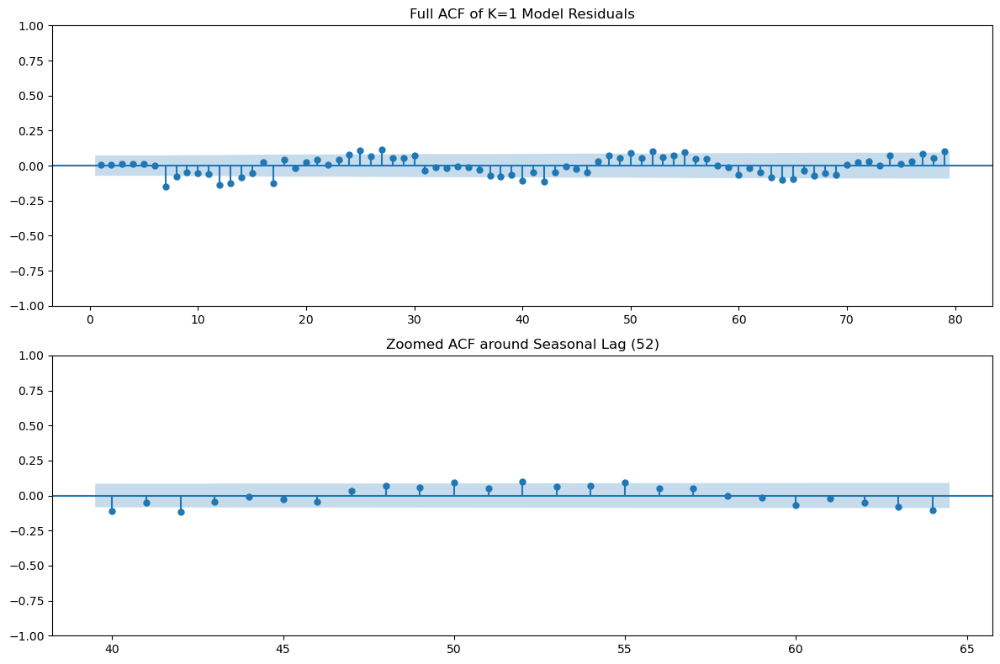

ACF at lag 51: 0.0539
ACF at lag 52: 0.1012
ACF at lag 53: 0.0611


In [75]:
# Before adding complexity, understand what's going on at lag 52:

# Plot ACF of K=1 model residuals around seasonal lags
exog_k1 = make_fourier_terms(train_recent15.index, period=52, K=1)
model_k1 = SARIMAX(train_recent15, order=(6,1,2), 
                   seasonal_order=(0,0,0,0), exog=exog_k1)
fit_k1 = model_k1.fit(method='powell')  # Use stable method
residuals_k1 = fit_k1.resid.iloc[52:]

# Plot ACF from lags 40 to 65
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(residuals_k1, lags=range(1, 80), ax=axes[0])
axes[0].set_title('Full ACF of K=1 Model Residuals')
plot_acf(residuals_k1, lags=range(40, 65), ax=axes[1])
axes[1].set_title('Zoomed ACF around Seasonal Lag (52)')
plt.tight_layout()
plt.show()

# Check if it's truly seasonal or just a few significant spikes
print(f"ACF at lag 51: {acf(residuals_k1, nlags=60)[51]:.4f}")
print(f"ACF at lag 52: {acf(residuals_k1, nlags=60)[52]:.4f}")
print(f"ACF at lag 53: {acf(residuals_k1, nlags=60)[53]:.4f}")

In [76]:
# The full ACF plot reveals significant spikes remain around lags 7, 13, and 17

# calculate ACF for specific lags
acf_values = acf(residuals_k1, nlags=60, fft=False)
critical_lags = [1,6,7,12,13,17,51,52,53]

print('ACF Values at Critical Lags')
print('-' * 40)
for lag in critical_lags:
    print(f'Lag {lag:2d}: ACF = {acf_values[lag]:.4f}')
print(f'\nACF 95% confidence interval: +/-{1.96/np.sqrt(len(residuals_k1)):.4f}')

# check PACF 
pacf_values = pacf(residuals_k1, nlags=60, method='ols')
print('\nPartial ACF at Critical Lags:')
for lag in [1,6,7,12,13,17,51,52,53]:
    print(f'Lag {lag}: PACF = {pacf_values[lag]:.4f}')

ACF Values at Critical Lags
----------------------------------------
Lag  1: ACF = 0.0058
Lag  6: ACF = 0.0010
Lag  7: ACF = -0.1492
Lag 12: ACF = -0.1369
Lag 13: ACF = -0.1253
Lag 17: ACF = -0.1234
Lag 51: ACF = 0.0539
Lag 52: ACF = 0.1012
Lag 53: ACF = 0.0611

ACF 95% confidence interval: +/-0.0725

Partial ACF at Critical Lags:
Lag 1: PACF = 0.0058
Lag 6: PACF = 0.0005
Lag 7: PACF = -0.1512
Lag 12: PACF = -0.1410
Lag 13: PACF = -0.1344
Lag 17: PACF = -0.1795
Lag 51: PACF = -0.0554
Lag 52: PACF = 0.0030
Lag 53: PACF = -0.0555


**Interpretation of results**

- lags 7, 12, 13, and 17 are significant based on ACF and PACF.
- lag 52 has barely significant ACF but not PACF.
- This could suggest that the apparent seasonal structure is correlated through other, subseasonal lags, especially 7 and 13.

This is corroborated by the observation that none of the SARIMA models handled the seasonal structure indicated by autocorrelation at lag 52, and adding Fourier terms (K>1) didn't help either.  Adding seasonal AR/MA terms may help but, the PACF results suggest a direct influence by lags 7, 13, and 17.  

Next steps:  try increasing the ARIMAX AR(p) orders to 7, 13, and 17, K=1.  

In [77]:
# estimation method = powell

exog_k1 = make_fourier_terms(train_recent15.index, period=52, K=1)

updated_models = [
    {'order': (3,1,0), 'seasonal_order': (0,0,0,0)}, 
    {'order': (3,1,1), 'seasonal_order': (0,0,0,0)}, 
    {'order': (3,1,2), 'seasonal_order': (0,0,0,0)}, 
    {'order': (5,1,0), 'seasonal_order': (0,0,0,0)},
    {'order': (5,1,1), 'seasonal_order': (0,0,0,0)},
    {'order': (5,1,2), 'seasonal_order': (0,0,0,0)},
    {'order': (6,1,0), 'seasonal_order': (0,0,0,0)},
    {'order': (6,1,1), 'seasonal_order': (0,0,0,0)},
    {'order': (6,1,2), 'seasonal_order': (0,0,0,0)},
    {'order': (7,1,0), 'seasonal_order': (0,0,0,0)},
    {'order': (7,1,1), 'seasonal_order': (0,0,0,0)},
    {'order': (7,1,2), 'seasonal_order': (0,0,0,0)},
    {'order': (13,1,0), 'seasonal_order': (0,0,0,0)},
    {'order': (13,1,1), 'seasonal_order': (0,0,0,0)},
    {'order': (13,1,2), 'seasonal_order': (0,0,0,0)},
    {'order': (17,1,2), 'seasonal_order': (0,0,0,0)},
    {'order': (18,1,2), 'seasonal_order': (0,0,0,0)}   
]

# evaluation with CV
updated_results = evaluate_models_tscv(
    updated_models,
    train_recent15,
    exog=exog_k1,
    estimation_method='powell',
    maxiter=500,
    n_splits=5
)

print('Updated ARIMAX Models with Powell Optimization')
print(updated_results.sort_values('RMSE_mean'))

Evaluating 17 models with 5 folds each
Total iterations: 85

Fold 1: Train=510, Val=52
Fold 2: Train=562, Val=52
Fold 3: Train=614, Val=52
Fold 4: Train=666, Val=52
Fold 5: Train=718, Val=52



Models: 100%|██████████| 17/17 [01:03<00:00,  3.76s/it]


Total duration: 1.07 minutes
Average per model: 0.06 minutes

Number of models successfully evaluated: 17
Updated ARIMAX Models with Powell Optimization
         order seasonal_order  successful_folds  convergence_rate  RMSE_mean  \
4    (5, 1, 1)   (0, 0, 0, 0)                 5               1.0  12.428751   
3    (5, 1, 0)   (0, 0, 0, 0)                 5               1.0  12.432505   
6    (6, 1, 0)   (0, 0, 0, 0)                 5               1.0  12.436150   
7    (6, 1, 1)   (0, 0, 0, 0)                 5               1.0  12.449466   
8    (6, 1, 2)   (0, 0, 0, 0)                 5               1.0  12.460870   
1    (3, 1, 1)   (0, 0, 0, 0)                 5               1.0  12.635871   
0    (3, 1, 0)   (0, 0, 0, 0)                 5               1.0  12.637186   
9    (7, 1, 0)   (0, 0, 0, 0)                 5               1.0  13.215052   
10   (7, 1, 1)   (0, 0, 0, 0)                 5               1.0  13.268226   
11   (7, 1, 2)   (0, 0, 0, 0)                 

# Hybrid approach 

In [78]:
# I will test the top six SARIMA models based on the TimeSeriesSplit CV where D=0 results
# estimation method = powell

exog_k1 = make_fourier_terms(train_recent15.index, period=52, K=1)

hybrid_models = [
    {'order': (5,1,0), 'seasonal_order': (0,0,1,52)}, 
    {'order': (5,1,1), 'seasonal_order': (0,0,1,52)}, 
    {'order': (6,1,0), 'seasonal_order': (0,0,1,52)}, 
    {'order': (6,1,1), 'seasonal_order': (0,0,1,52)}, 
    {'order': (6,1,2), 'seasonal_order': (0,0,1,52)},
    {'order': (7,1,0), 'seasonal_order': (0,0,1,52)},
    {'order': (7,1,1), 'seasonal_order': (0,0,1,52)},
    {'order': (7,1,2), 'seasonal_order': (0,0,1,52)},
    {'order': (13,1,0), 'seasonal_order': (0,0,1,52)},
    {'order': (13,1,1), 'seasonal_order': (0,0,1,52)},
    {'order': (13,1,2), 'seasonal_order': (0,0,1,52)}
]

# evaluation with CV
hybrid_results = evaluate_models_tscv(
    hybrid_models,
    train_recent15,
    exog=exog_k1,
    estimation_method='powell',
    maxiter=500,
    n_splits=5
)

print('Hybrid Models with Powell Optimization')
print(hybrid_results.sort_values('RMSE_mean'))

Evaluating 11 models with 5 folds each
Total iterations: 55

Fold 1: Train=510, Val=52
Fold 2: Train=562, Val=52
Fold 3: Train=614, Val=52
Fold 4: Train=666, Val=52
Fold 5: Train=718, Val=52



Models: 100%|██████████| 11/11 [40:18<00:00, 219.87s/it]


Total duration: 40.31 minutes
Average per model: 3.66 minutes

Number of models successfully evaluated: 11
Hybrid Models with Powell Optimization
         order seasonal_order  successful_folds  convergence_rate  RMSE_mean  \
0    (5, 1, 0)  (0, 0, 1, 52)                 5               1.0  12.300722   
2    (6, 1, 0)  (0, 0, 1, 52)                 5               1.0  12.303663   
1    (5, 1, 1)  (0, 0, 1, 52)                 5               1.0  12.330648   
4    (6, 1, 2)  (0, 0, 1, 52)                 5               1.0  12.331666   
3    (6, 1, 1)  (0, 0, 1, 52)                 5               1.0  12.355335   
5    (7, 1, 0)  (0, 0, 1, 52)                 5               1.0  12.989910   
6    (7, 1, 1)  (0, 0, 1, 52)                 5               1.0  13.124965   
7    (7, 1, 2)  (0, 0, 1, 52)                 5               1.0  13.183322   
8   (13, 1, 0)  (0, 0, 1, 52)                 5               1.0  15.713030   
10  (13, 1, 2)  (0, 0, 1, 52)                 5      


=== Hybrid SARIMAX(5, 1, 0)(0, 0, 1, 52) + FT(K=1) ===

Using 731 residuals for diagnostics (first 52 excluded as burn_in)

--- In-Sample Accuracy (after burn-in) ---
RMSE: 4.908
MAE:  3.145
MAPE: 0.17%
R2:   0.986


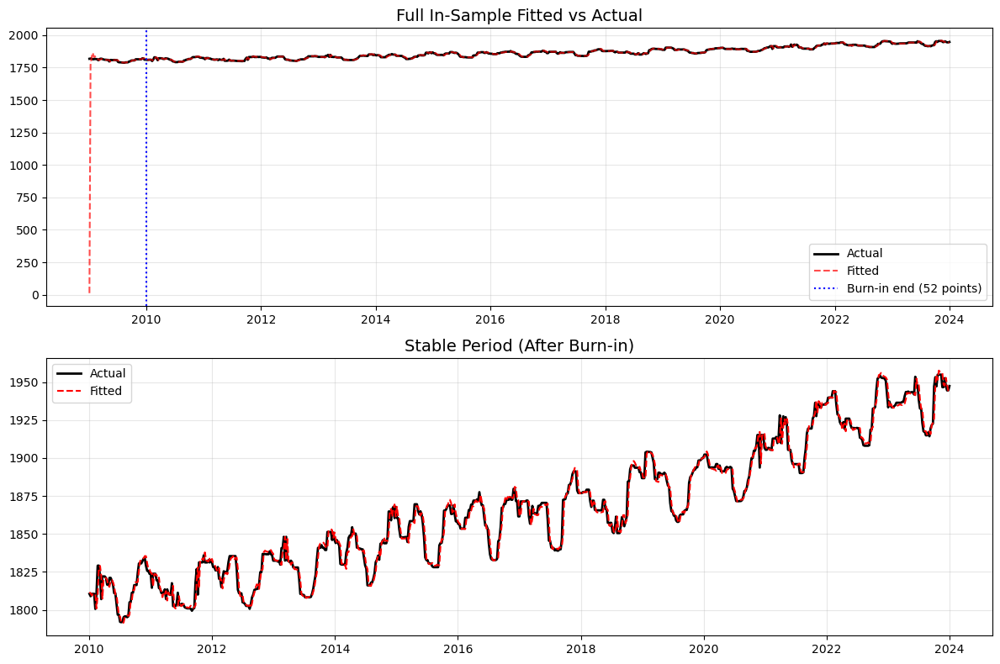

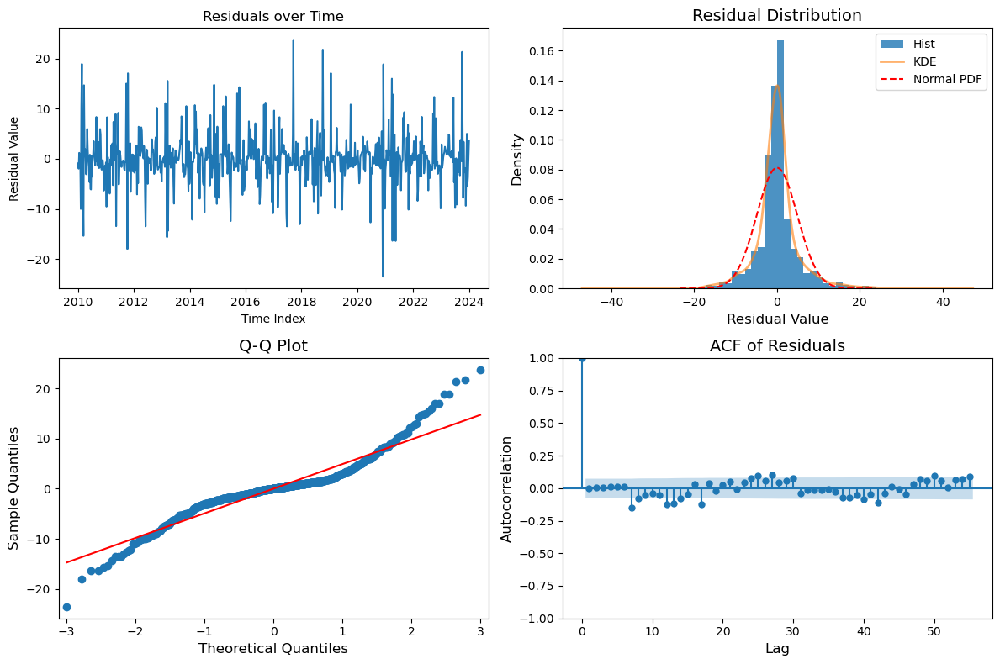


=== Residual Diagnostic Tests ===

--- Distribution Diagnostics ---
Jarque-Bera test:
	JB = 562.34
	p = 0.0000
	Skewness = 0.370
	kurtosis = 7.233

--- Autocorrelation Diagnostics ---
Ljung-Box Test:
(H0: No autocorrelation up to specified lags)
	lag 1: p = 0.9841
	lag 4: p = 0.9988
	lag 13: p = 0.0000
	lag 26: p = 0.0000
	lag 52: p = 0.0000

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0000***
	Lag 8: p-value = 0.0001***
	Lag 12: p-value = 0.0002***
	Lag 26: p-value = 0.0024***

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.6990
White: p = 0.5928

Model (5, 1, 0)(0, 0, 1, 52):
   ACF 95% confidence interval: +/-0.0725
   ACF at lag 7: -0.1531 (was -0.1492)
   ACF at lag 13: -0.1197 (was -0.1253)
   ACF at lag 17: -0.1215 (was -0.1234)
   ACF at lag 52: 0.0032 (was 0.1012)

=== Hybrid SARIMAX(6, 1, 0)(0, 0, 1, 52) + FT(K=1) ===

Using 731 residuals f

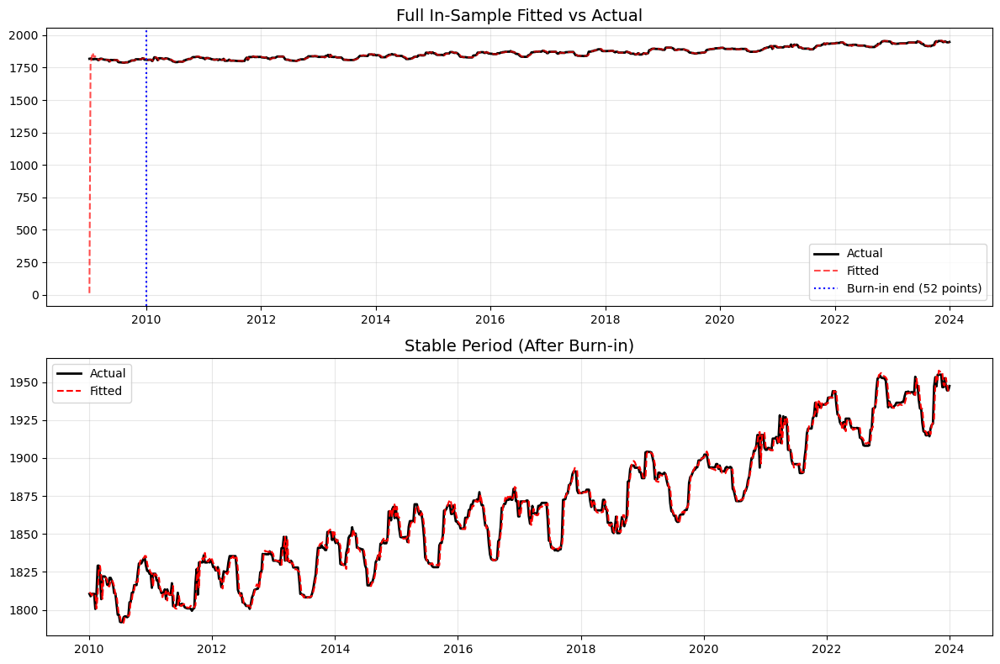

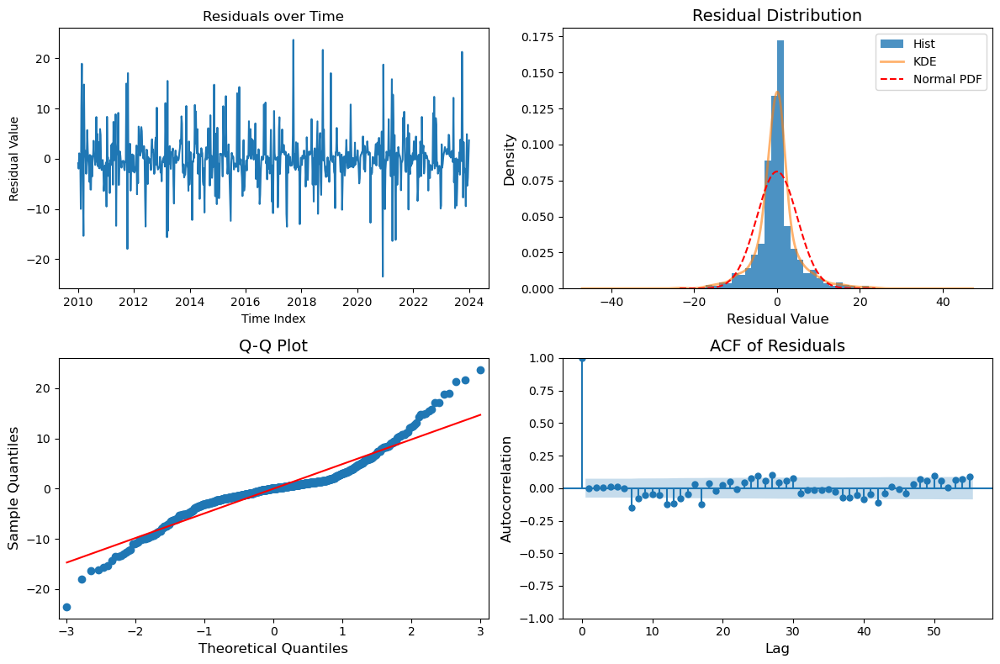


=== Residual Diagnostic Tests ===

--- Distribution Diagnostics ---
Jarque-Bera test:
	JB = 559.04
	p = 0.0000
	Skewness = 0.372
	kurtosis = 7.219

--- Autocorrelation Diagnostics ---
Ljung-Box Test:
(H0: No autocorrelation up to specified lags)
	lag 1: p = 0.9650
	lag 4: p = 0.9979
	lag 13: p = 0.0000
	lag 26: p = 0.0000
	lag 52: p = 0.0000

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0000***
	Lag 8: p-value = 0.0001***
	Lag 12: p-value = 0.0002***
	Lag 26: p-value = 0.0024***

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.6956
White: p = 0.5935

Model (6, 1, 0)(0, 0, 1, 52):
   ACF 95% confidence interval: +/-0.0725
   ACF at lag 7: -0.1505 (was -0.1492)
   ACF at lag 13: -0.1173 (was -0.1253)
   ACF at lag 17: -0.1214 (was -0.1234)
   ACF at lag 52: 0.0032 (was 0.1012)


In [79]:
# Check in-sample residuals analysis of top two hybrid models
# ARIMAX(5,1,0)(0,0,1,52) + FT(K=1)
# ARIMAX(6,1,0)(0,0,1,52) + FT(K=1)

top_hybrid_models = [
    ((5,1,0), (0,0,1,52)),  # top model
    ((6,1,0), (0,0,1,52))   # second best model
]

for order, seasonal_order in top_hybrid_models:
    print(f'\n=== Hybrid SARIMAX{order}{seasonal_order} + FT(K=1) ===\n')
    results, residuals = in_sample_resid_analysis(
        train_recent15,
        order=order,
        seasonal_order=seasonal_order,
        exog=exog_k1,
        estimation_method='powell',
        maxiter=500,
        run_hetero=True
    )

    # check specific lags that were problematic
    acf_vals = acf(residuals, nlags=60, fft=False)
    print(f'\nModel {order}{seasonal_order}:')
    print(f'   ACF 95% confidence interval: +/-{1.96/np.sqrt(len(residuals)):.4f}')
    print(f'   ACF at lag 7: {acf_vals[7]:.4f} (was -0.1492)')
    print(f'   ACF at lag 13: {acf_vals[13]:.4f} (was -0.1253)')
    print(f'   ACF at lag 17: {acf_vals[17]:.4f} (was -0.1234)')
    print(f'   ACF at lag 52: {acf_vals[52]:.4f} (was 0.1012)')

**Best model: ARIMAX(5,1,0)(0,0,1,52) + FT(K=1)**

The hybrid model improved RMSE_mean and autocorrelation at all lags.  However, significant autocorrelation remains at lag 52 on out-of-sample analysis (TimeSeriesSplit CV).  

- I have thus far found that autocorrelation at lag 52 is just slightly outside of the confidence interval, to a lesser extent than lags 7 and 13.  Furthermore, PACF does not show autocorrelation at lag 52 suggesting a possible indirect autocorrelation at this lag, possibly through lags 7, 13, and 17.  

- Adding more Fourier terms (K>1) made the accuracy ~ 37% worse compared to K = 1.

- Adding non-seasonal AR(p) orders 7, 13, and 17 also worsend the model accuracy.

In-sample residual analysis:
- autocorrelation at lag 52 is insigificant (ACF value at lag 52 < CI).

Next step:  GARCH model for ARCH effects

# GARCH model to handle conditional volatility 

- all models tested have ARCH effects at all tested lags and exhibit non-normally distributed residuals (kurotosis ~ 7.2).
- autocorrelation remains significant for lags 7, 13, and 17, which may be due to volatility clustering instead of mean structure.  

In [80]:
# fit the top model for GARCH

exog_k1 = make_fourier_terms(train_recent15.index, period=52, K=1)
mean_model = SARIMAX(
    train_recent15,
    order=(5,1,0),
    seasonal_order=(0,0,1,52),
    exog=exog_k1,
    enforce_stationarity=False,
    enforce_invertibility=False,
    trend='c')
mean_fit = mean_model.fit(method='powell', maxiter=500)
residuals = mean_fit.resid.iloc[52:]    # remove burn-in

Optimization terminated successfully.
         Current function value: 2.803372
         Iterations: 2
         Function evaluations: 170


In [81]:
# test GARCH specifications 

garch_configs = [
    {'p': 1, 'q': 1, 'dist': 'normal'},
    {'p': 1, 'q': 1, 'dist': 't'},
    {'p': 1, 'q': 2, 'dist': 't'},
    {'p': 2, 'q': 1, 'dist': 't'},
    {'p': 2, 'q': 2, 'dist': 't'}
]

results = []
for config in garch_configs:
    garch = arch_model(
        residuals,
        vol='Garch',
        p=config['p'],
        q=config['q'],
        dist=config['dist']
    )

    # robust fitting
    try:
        garch_fit = garch.fit(
            update_freq=0,
            disp='off',
            show_warning=False,
            options={'maxiter': 1000}
        )

        # get standardized residuals for diagnostics
        std_resid = garch_fit.resid / garch_fit.conditional_volatility
    
        # check if volatility clustering is reduced
        arch_test = het_arch(std_resid.dropna(), nlags=4)
    
        results.append({
            'GARCH': f'({config['p']},{config['q']})',
            'Dist': config['dist'],
            'AIC': garch_fit.aic,
            'BIC': garch_fit.bic,
            'ARCH-LM p (lag 4)': arch_test[1],
            'a[1]': garch_fit.params.get('alpha[1]', None),
            'b[1]': garch_fit.params.get('beta[1]', None),
            'a[1] + b[1]': garch_fit.params.get('alpha[1]') + garch_fit.params.get('beta[1]')
        })

    except Exception as e:
        print(f'Failed for {config}: {e}')
        continue

# compare GARCH models 
garch_df = pd.DataFrame(results)
print('\nGARCH Model Comparison:')
print(garch_df.sort_values('ARCH-LM p (lag 4)'))    


GARCH Model Comparison:
   GARCH    Dist          AIC          BIC  ARCH-LM p (lag 4)      a[1]  \
2  (1,2)       t  4140.607192  4168.173672           0.946294  0.957842   
4  (2,2)       t  4142.607190  4174.768085           0.946504  0.958085   
1  (1,1)       t  4138.612782  4161.584849           0.952342  0.971096   
3  (2,1)       t  4140.612783  4168.179263           0.952367  0.971034   
0  (1,1)  normal  4365.010257  4383.387911           0.989301  0.205336   

       b[1]  a[1] + b[1]  
2  0.031117     0.988959  
4  0.031022     0.989107  
1  0.028904     1.000000  
3  0.028966     1.000000  
0  0.000000     0.205336  


## Fit the best GARCH model

In [82]:
# fit the GARCH(1,2)-t model

garch12t = arch_model(
    residuals,          # from "mean_model", see above
    vol='Garch',
    p=1,                # ARCH order
    q=2,                # GARCH order
    dist='t'
)
garch12t_fit = garch12t.fit(update_freq=0, disp='off')

# check standardized residuals
std_resid = garch12t_fit.resid / garch12t_fit.conditional_volatility

print("Final GARCH(1,2)-t Validation:")
print(f"   a[1] + b[1] + b[2] = {garch12t_fit.params['alpha[1]'] + garch12t_fit.params['beta[1]'] + garch12t_fit.params['beta[2]']:.4f}")
print(f"   Degrees of freedon: {garch12t_fit.params['nu']:.2f}")

# Check remaining autocorrelation
lb_test = acorr_ljungbox(std_resid.dropna(), lags=[1,4,7,13,17,26,52], return_df=True)
print("\nLjung-Box on Standardized Residuals:")
for lag in [1,4,7,13,17,26,52]:
    print(f"   lag {lag}: p = {lb_test.loc[lag, 'lb_pvalue']:.4f}")


Final GARCH(1,2)-t Validation:
   a[1] + b[1] + b[2] = 1.0000
   Degrees of freedon: 2.15

Ljung-Box on Standardized Residuals:
   lag 1: p = 0.1292
   lag 4: p = 0.6653
   lag 7: p = 0.0036
   lag 13: p = 0.0000
   lag 17: p = 0.0000
   lag 26: p = 0.0000
   lag 52: p = 0.0000


**Interpretation of results**

- All GARCH models have handled the volatility clustering.  So the residuals no longer have ARCH effects.
- GARCH(1,1)-t and (2,1)-t have indefinite persistance of volatility shocks (alpha + beta = 1 indicates an IGARCH process, integrated GARCH), which isn't good.
- t-Distribution is the right choice to handle the fat tails (kurtosis = 7.2) based on AIC and BIC scores.  
-  best model: GARCH(1,2)-t
    - highest ARCH-LM p-value
    - second best AIC score
    - alpha + beta < 1, which indicates mean-reverting volatility (doesn't persist) 

## Try increasing non-seasonal orders

In [83]:
# fit the SARIMAX model for GARCH

exog_k1 = make_fourier_terms(train_recent15.index, period=52, K=1)
mean_model = SARIMAX(
    train_recent15,
    order=(7,1,2),
    seasonal_order=(0,0,1,52),
    exog=exog_k1,
    enforce_stationarity=False,
    enforce_invertibility=False,
    trend='c')
mean_fit = mean_model.fit(method='powell', maxiter=500)
residuals = mean_fit.resid.iloc[52:]    # remove burn-in

Optimization terminated successfully.
         Current function value: 2.741076
         Iterations: 8
         Function evaluations: 1036


In [84]:
# test GARCH specifications 

garch_configs = [
    {'p': 1, 'q': 1, 'dist': 'normal'},
    {'p': 1, 'q': 1, 'dist': 't'},
    {'p': 1, 'q': 2, 'dist': 't'},
    {'p': 2, 'q': 1, 'dist': 't'},
    {'p': 2, 'q': 2, 'dist': 't'}
]

results = []
for config in garch_configs:
    garch = arch_model(
        residuals,
        vol='Garch',
        p=config['p'],
        q=config['q'],
        dist=config['dist']
    )

    # robust fitting
    try:
        garch_fit = garch.fit(
            update_freq=0,
            disp='off',
            show_warning=False,
            options={'maxiter': 1000}
        )

        # get standardized residuals for diagnostics
        std_resid = garch_fit.resid / garch_fit.conditional_volatility
    
        # check if volatility clustering is reduced
        arch_test = het_arch(std_resid.dropna(), nlags=4)
    
        results.append({
            'GARCH': f'({config['p']},{config['q']})',
            'Dist': config['dist'],
            'AIC': garch_fit.aic,
            'BIC': garch_fit.bic,
            'ARCH-LM p (lag 4)': arch_test[1],
            'a[1]': garch_fit.params.get('alpha[1]', None),
            'a[2]': garch_fit.params.get('alpha[2]', None),
            'b[1]': garch_fit.params.get('beta[1]', None),
            'b[2]': garch_fit.params.get('beta[2]', None),
            # 'a[1] + b[1]': garch_fit.params.get('alpha[1]') + garch_fit.params.get('beta[1]')
        })

    except Exception as e:
        print(f'Failed for {config}: {e}')
        continue

# compare GARCH models 
garch_df = pd.DataFrame(results)
print('\nGARCH Model Comparison:')
print(garch_df.sort_values('ARCH-LM p (lag 4)'))  


GARCH Model Comparison:
   GARCH    Dist          AIC          BIC  ARCH-LM p (lag 4)      a[1]  \
2  (1,2)       t  4132.034280  4159.600761           0.835429  0.304493   
1  (1,1)       t  4130.034281  4153.006348           0.835443  0.304591   
0  (1,1)  normal  4283.909849  4302.287503           0.880688  0.160592   
4  (2,2)       t  4133.395198  4165.556092           0.918047  0.288204   
3  (2,1)       t  4131.395198  4158.961679           0.918101  0.288257   

       a[2]          b[1]  b[2]  
2       NaN  2.045765e-01   0.0  
1       NaN  2.045367e-01   NaN  
0       NaN  1.852204e-01   NaN  
4  0.096704  6.201419e-16   0.0  
3  0.096698  0.000000e+00   NaN  


In [85]:
# fit the GARCH(1,2)-t model

garch12t = arch_model(
    residuals,          # from "mean_model", see above
    vol='Garch',
    p=1,                # ARCH order
    q=2,                # GARCH order
    dist='t'
)
garch12t_fit = garch12t.fit(update_freq=0, disp='off')

# check standardized residuals
std_resid = garch12t_fit.resid / garch12t_fit.conditional_volatility

print("Final GARCH(1,2)-t Validation:")
print(f"   a[1] + b[1] + b[2] = {garch12t_fit.params['alpha[1]'] + garch12t_fit.params['beta[1]'] + garch12t_fit.params['beta[2]']:.4f}")
print(f"   Degrees of freedon: {garch12t_fit.params['nu']:.2f}")

# Check remaining autocorrelation
lb_test = acorr_ljungbox(std_resid.dropna(), lags=[1,4,7,13,17,26,52], return_df=True)
print("\nLjung-Box on Standardized Residuals:")
for lag in [1,4,7,13,17,26,52]:
    print(f"   lag {lag}: p = {lb_test.loc[lag, 'lb_pvalue']:.4f}")

Final GARCH(1,2)-t Validation:
   a[1] + b[1] + b[2] = 0.5091
   Degrees of freedon: 2.64

Ljung-Box on Standardized Residuals:
   lag 1: p = 0.4352
   lag 4: p = 0.8722
   lag 7: p = 0.9653
   lag 13: p = 0.4954
   lag 17: p = 0.2024
   lag 26: p = 0.2311
   lag 52: p = 0.0873


In [86]:
# Since b[2] = 0, I will test the GARCH(1,1)-t model fit

garch11t = arch_model(
    residuals,          # from "mean_model", see above
    vol='Garch',
    p=1,                # ARCH order
    q=1,                # GARCH order
    dist='t'
)
garch11t_fit = garch11t.fit(update_freq=0, disp='off')

# check standardized residuals
std_resid = garch11t_fit.resid / garch11t_fit.conditional_volatility

print("Final GARCH(1,1)-t Validation:")
print(f"   a[1] + b[1] = {garch11t_fit.params['alpha[1]'] + garch11t_fit.params['beta[1]']:.4f}")
print(f"   Degrees of freedon: {garch11t_fit.params['nu']:.2f}")

# Check remaining autocorrelation
lb_test = acorr_ljungbox(std_resid.dropna(), lags=[1,4,7,13,17,26,52], return_df=True)
print("\nLjung-Box on Standardized Residuals:")
for lag in [1,4,7,13,17,26,52]:
    print(f"   lag {lag}: p = {lb_test.loc[lag, 'lb_pvalue']:.4f}")

Final GARCH(1,1)-t Validation:
   a[1] + b[1] = 0.5091
   Degrees of freedon: 2.64

Ljung-Box on Standardized Residuals:
   lag 1: p = 0.4352
   lag 4: p = 0.8722
   lag 7: p = 0.9653
   lag 13: p = 0.4954
   lag 17: p = 0.2024
   lag 26: p = 0.2311
   lag 52: p = 0.0873


In [87]:
print(garch11t_fit.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -2060.02
Distribution:      Standardized Student's t   AIC:                           4130.03
Method:                  Maximum Likelihood   BIC:                           4153.01
                                              No. Observations:                  731
Date:                      Thu, Dec 04 2025   Df Residuals:                      730
Time:                              23:56:59   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu            -0

**Interpretation of GARCH(1,1)-t summary**

mean model
- mu is the estimated constant mean of the residuals from the SARIMAX(7,1,2)(0,0,1,52) + FT(K=1) model.
- mu is close to zero (-0.144) and not statistically significant (p>|t| = 0.260) meaning that the residuals are essentially random noise.

volatility model
- omega is the long-run, baseline variance
- omega = 19.13 is a high value that is statistically signficant.  It indicates a substantial level of volatility that is 'ever-present' and not not explained by recent shocks.
- alpha[1] is the 'news impact' coefficient that indicates how a shock today affects the variance tomorrow.
- alpha[1] = 0.305 is borderline statistically signficant (p = 0.047) and means that a residiual shock today increases tomorrow's exptected variance by 30.5%.  This result confirms volatility clustering.
- beta[1] is the persistence coefficient and measures how much of today's variance is carried over into tomorrow's variance.
- beta[1] = 0.205 indicates moderate memory for volatility.
- alpha + beta measures the volatility persistence.  A sum < 1 indicate that shocks to volatility decay over time and the process is stable.  A sum = 1 inidcates integrated GARCH (IGARCH) meaning that a volatility shock is permenent and will not decay back to the long-run mean variance.  A sum > 1 indicates explosive volatility and suggests that the model is misspecified.
- alpha[1] + beta[1] = 0.509, which is good and means that volatility shocks decay over time back to the long-run mean variance, the process is stable.

distribution
- nu is the degrees of freedom for the student's t-distribution.  nu < 5 indicates fat tails.
- nu = 2.64 (and statistically significant) indicates that the residuals have very fat tails, and therefore a much higher probability of extreme values compared to a normal distribution.

Overall interpretation for atomospheric CH4 concentration
- A spike in CH4 concentration makes future variability more uncertain in the short term (alpha[1] = 0.305).  When the atmosphere enters a period of high variability, it tends to stay moderately variable for a period before calming downn (beta[1] = 0.205).  Atmospheric CH4 concentration has a consistent level of noise (unpredictable fluctuation) in the weekly measurements (omega = 19.13).  Large, unexpected increases in CH4 concentration are more common than a standard normal curve would predict (nu = 2.64).   

In [88]:
# compare rmse results of the top hybrod model vs the best model for residuals 

rmse_inc = 13.183322 - 12.300722
percent_inc = (rmse_inc / 13.183322) * 100

print("== RMSE comparison between SARIMAX(7,1,2)(0,0,1,52) + FT(K=1) and SARIMAX(5,1,0)(0,0,1,52) + FT(K=1) ==")

print('\nThe top model ((5,1,0)(0,0,1,52) + FT(K=1)) RMSE: 12.30')
print(f'RMSE = 12.30 represents a {(12.30 / train_recent15.mean()) * 100:.2f}% error relative to the mean [CH4]')

print('\nThe statistically better model ((7,1,2)(0,0,1,52) + FT(K=1)) RMSE: 13.18')
print(f'RMSE = 13.18 represents a {(13.18 / train_recent15.mean()) * 100:.2f}% error relative to the mean [CH4]')

print(f'\nThe statistically better model is {percent_inc:.2f}% worse for RMSE.')
print("But, this results in only approximately 1 ppb worse point forecast accuracy compared to the top model based on RMSE.")

== RMSE comparison between SARIMAX(7,1,2)(0,0,1,52) + FT(K=1) and SARIMAX(5,1,0)(0,0,1,52) + FT(K=1) ==

The top model ((5,1,0)(0,0,1,52) + FT(K=1)) RMSE: 12.30
RMSE = 12.30 represents a 0.66% error relative to the mean [CH4]

The statistically better model ((7,1,2)(0,0,1,52) + FT(K=1)) RMSE: 13.18
RMSE = 13.18 represents a 0.71% error relative to the mean [CH4]

The statistically better model is 6.69% worse for RMSE.
But, this results in only approximately 1 ppb worse point forecast accuracy compared to the top model based on RMSE.


**Final model summary**

- SARIMAX(7,1,2)(0,0,1,52) + FT(K=1) + GARCH(1,1)-t is the best model for capturing non-seasonal patterns, seasonal patterns, and volatility.
- Fourier harmonic specification: K = period / lag, e.g. K = 52 / 52 = 1, etc. 
- The hybrid SARIMAX orders were 8th best out of 10 candidates in the TimeSeriesSplit CV based on RMSE vs the top model (5,1,0)(0,0,1,52) + FT(K=1) - 13.2 vs 12.3 respectively.

Mean model
- AR(7): Captures the 7-week (~1.6 month) atmospheric cycle
- I(1): Accounts for stochastic trend in CH₄
- Non-Seasonal MA(2): Handles short-term shocks
- Seasonal MA(1): Annual cycle abrupt changes
  - These results are consistent with the non-seasonal only differencing of the full train data analyis performed above (see "Difference preproceseed train data . . ."), where significant spikes at lags 2, 7, and 12 were observed in both the ACF and PACF plots.  The signficant spik at lag 52 was significant in only the ACF plot, suggesting a seasonal MA term (SMA(1)).  
- Fourier(K=1): Smooth annual seasonal pattern
- The more complex model handles autocorrelation with good GARCH modeling of the residuals amd is only 1 ppb less accurate for point forecasts compared to the top model based on RMSE (i.e. (5,1,0)(0,0,1,52) + FT(K=1)).  
<br>

Volatility model
- α[1] = 0.3045: Moderate ARCH effect
- β[1] = 0.2046: Low GARCH persistence
- ν = 2.64: Very fat tails - extreme CH₄ variations common
- α+β = 0.5091: Healthy mean-reverting volatility
<br>

Residual diagnostics
- all lags have p > 0.05
- therefore, short terms, subseasonal, and seasonal structure has been captured by the model and no longer present in the residuals.
<br>

Next steps:  
- forecast with SARIMAX(7,1,2)(0,0,1,52) + FT(K=1) + GARCH(1,1)-t
- reliable prediction intervals are desirable for accurate forecasting and this model provides uncorrelated residuals and mean-reverting volotality

From deepseek:

"The SARIMAX(7,1,2)(0,0,1)52 model with exogenous Fourier terms was selected as the final mean specification. While it yields a marginally higher RMSE (13.18 ppb) compared to simpler alternatives, its residuals satisfy the necessary white noise assumptions, enabling reliable inference and conditional heteroscedasticity modeling. This model also captures a significant 7-week autoregressive cycle, which may reflect sub-seasonal atmospheric mixing processes."

## SARIMAX(7,1,2)(0,0,1,52) + FT(K=1)–GARCH(1,1) Model Summary 
(from ChatGPT)

The final model combines a hybrid **SARIMAX(7,1,2)(0,0,1,52)** conditional mean equation with **Fourier terms (K = 1)** as exogenous regressors and a **GARCH(1,1)-t** conditional variance specification.  
A **Student-t** distribution was used for the innovations to account for heavy tails.

---

#### 1. Conditional Mean Equation

$$
\nabla y_t = c + 
\phi_1 \nabla y_{t-1} + \phi_2 \nabla y_{t-2} + \cdots + \phi_7 \nabla y_{t-7}
+ \theta_1 \varepsilon_{t-1}
+ \boldsymbol{\beta}' \mathbf{x}_t
+ \varepsilon_t
$$

where:  

- $y_t$: original series  
- $\nabla y_t = y_t - y_{t-1}$: first difference (since $d = 1$)  
- $\phi_i$: autoregressive coefficients  
- $\theta_1$: moving-average coefficient  
- $\mathbf{x}_t$: Fourier sine/cosine terms (exogenous regressors)  
- $\boldsymbol{\beta}$: coefficients for exogenous terms  
- $\varepsilon_t$: residual innovations  

The ARIMAX component models short-term autocorrelation, deterministic trend, and seasonality through the Fourier regressors.

---

#### 2. Conditional Variance Equation (GARCH)

The conditional variance of the residuals is modeled as:

$$
\begin{aligned}
\varepsilon_t &= \sigma_t z_t, \quad z_t \sim t_\nu(0, 1) \\
\sigma_t^2 &= \omega + \alpha_1 \varepsilon_{t-1}^2 + \beta_1 \sigma_{t-1}^2
\end{aligned}
$$

where:

| Parameter | Interpretation |
|------------|----------------|
| $\omega$ | Long-run (base) variance level |
| $\alpha_1$ | ARCH effect — sensitivity to the previous shock $\varepsilon_{t-1}^2$ |
| $\beta_1$ | GARCH effect — persistence of prior variance $\sigma_{t-1}^2$ |
| $\nu$ | Degrees of freedom (tail heaviness of the Student-t) |

---

#### 3. Estimated Variance Equation

$$
\hat{\sigma}_t^2 = 19.13 + 0.30\,\varepsilon_{t-1}^2 + 0.20\,\hat{\sigma}_{t-1}^2
$$

**Interpretation:**

- $\omega = 19.13$: baseline volatility level  
- $\alpha_1 = 0.30$: 30% of the previous shock carries into current volatility  
- $\beta_1 = 0.20$: 20% of prior volatility persists  
- $\alpha_1 + \beta_1 = 0.51 < 1$: volatility is **mean-reverting**, not explosive  
- $\nu = 2.64$: heavy tails — residuals are more leptokurtic than Gaussian  

---

#### 4. Diagnostics

| Test | Result | Interpretation |
|------|---------|----------------|
| Ljung–Box on standardized residuals | $p > 0.5$ | No serial correlation — mean model adequate |
| Ljung–Box on squared residuals | $p > 0.5$ | No remaining ARCH effects — GARCH captured volatility clustering |
| Engle’s ARCH test (pre-GARCH) | $p < 0.05$ | ARCH effects present before GARCH |
| Engle’s ARCH test (post-GARCH) | $p > 0.05$ | ARCH effects eliminated after GARCH |
| Student–t ($\nu = 3.17$) | — | Confirms heavy-tailed innovation distribution |

---

#### 5. Model Summary

- The **hybrid SARIMAX–GARCH(1,1)-t** model effectively captures both the **conditional mean** and **conditional variance** structure of the data.  
- Volatility responds quickly to shocks but decays relatively fast (low persistence).  
- Residual diagnostics show no remaining autocorrelation or heteroskedasticity, suggesting the model is statistically adequate and well-specified.

# Test model generalization on the test set

## ARIMAX out-of-sample analysis

In [89]:
# Create Fourier terms for the train and test sets

exog_train15_K1 = make_fourier_terms(train_recent15.index, period=52, K=1)
exog_test_K1 = make_fourier_terms(test_preprocessed.index, period=52, K=1)

=== Out-of-Sample Residual Analysis: SARIMAX(7,1,2)(0,0,1,52) + FT(K=1) ===
Using estimation method: powell
Test set size: 52 observations

--- Out-of-Sample Forecast Accuracy ---
RMSE: 12.592
MAE:  10.438
MAPE: 0.54%
R²:   0.384
95% CI coverage: 88.5% (ideal: 95%)


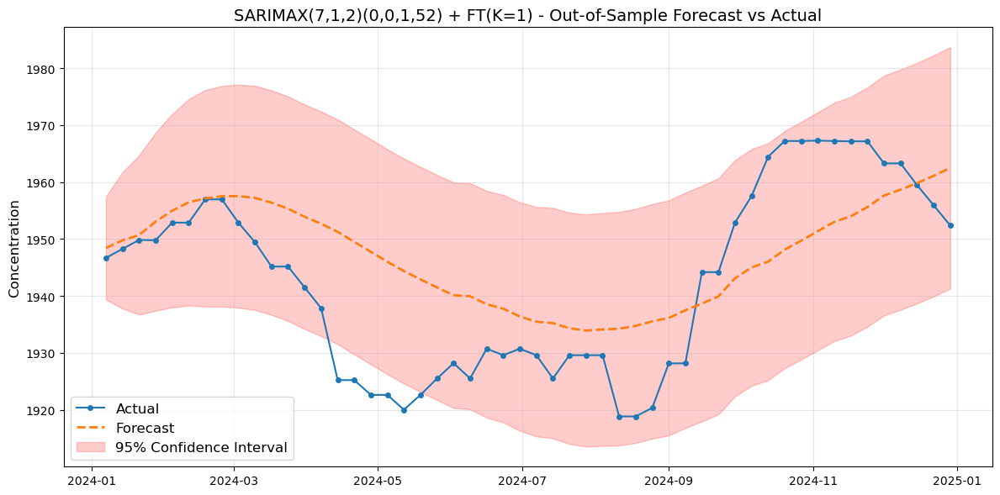


--- Residual Statistical Properties ---
Mean: -4.58814
Std:  11.84022
Skew: 0.239
Kurtosis: -0.457

--- Normality Tests ---
Shapiro-Wilk: p = 0.1645
Jarque-Bera:  p = 0.5857

--- Autocorrelation Diagnostics ---
Ljung-Box Test (H0: No autocorrelation)
  Lag  1: p = 0.0000 ***
  Lag  4: p = 0.0000 ***
  Lag 13: p = 0.0000 ***
  Lag 26: p = 0.0000 ***

"⚠"  Significant autocorrelation detected at lags: [1, 4, 13, 26]

--- Stationarity Check ---
ADF test on residuals: p = 0.1396
"⚠"  Residuals may not be stationary

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.9743
White test:    p = 0.0357
"✅" Constant variance

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0000***
	Lag 8: p-value = 0.0000***
	Lag 12: p-value = 0.0000***
	Lag 26: p-value = 0.0000***


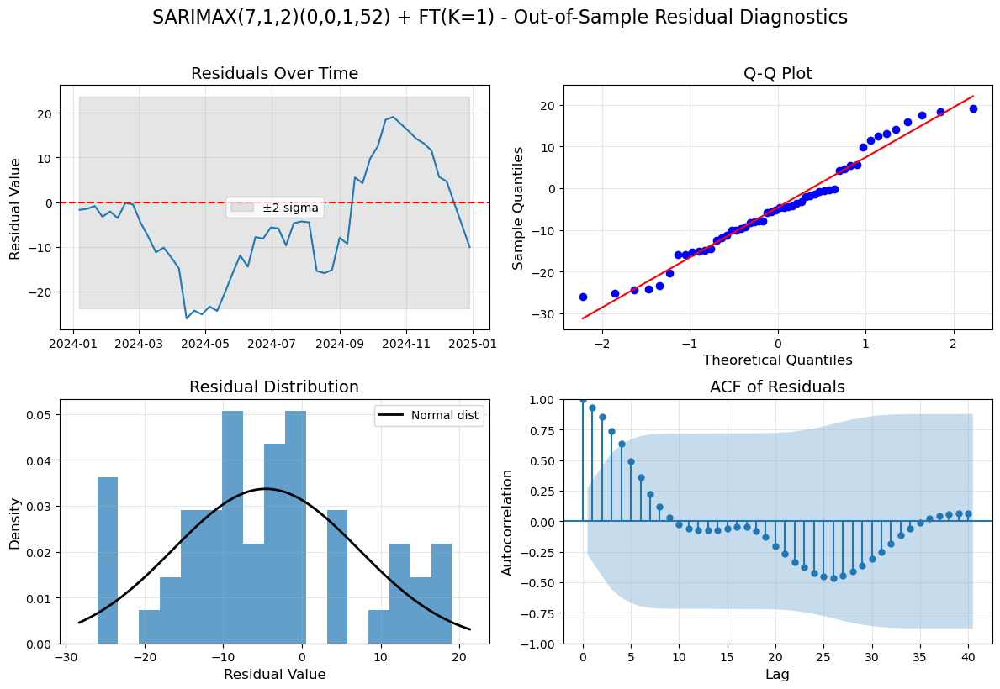

In [90]:
testset_resid_analysis = out_of_sample_resid_analysis(
    train_recent15,
    test_preprocessed,
    order=(7,1,2),
    seasonal_order=(0,0,1,52),
    exog_train=exog_train15_K1,
    exog_test=exog_test_K1,
    model_name='SARIMAX(7,1,2)(0,0,1,52) + FT(K=1)',
    estimation_method='powell',
    run_hetero=True
)  

In [91]:
# Fit the mean model

mean_model = SARIMAX(
    train_recent15,
    order=(7,1,2),
    seasonal_order=(0,0,1,52),
    exog=exog_train15_K1,
    enforce_stationarity=False,
    enforce_invertibility=False,
    trend='c')
mean_fit = mean_model.fit(method='powell', maxiter=500)
residuals = mean_fit.resid.iloc[52:]    # remove burn-in

Optimization terminated successfully.
         Current function value: 2.741076
         Iterations: 8
         Function evaluations: 1036


In [92]:
# forecast

forecast_obj = mean_fit.get_forecast(steps=len(test_preprocessed), exog=exog_test_K1)
forecast_series = forecast_obj.predicted_mean
forecast_ci = forecast_obj.conf_int()   # get model CIs for possible comparision with GARCH adjusted CIs.  

print(f'Forecast series type: {type(forecast_series)}')
print(f'Forecast series has index: {forecast_series.index}')

Forecast series type: <class 'pandas.core.series.Series'>
Forecast series has index: DatetimeIndex(['2024-01-07', '2024-01-14', '2024-01-21', '2024-01-28',
               '2024-02-04', '2024-02-11', '2024-02-18', '2024-02-25',
               '2024-03-03', '2024-03-10', '2024-03-17', '2024-03-24',
               '2024-03-31', '2024-04-07', '2024-04-14', '2024-04-21',
               '2024-04-28', '2024-05-05', '2024-05-12', '2024-05-19',
               '2024-05-26', '2024-06-02', '2024-06-09', '2024-06-16',
               '2024-06-23', '2024-06-30', '2024-07-07', '2024-07-14',
               '2024-07-21', '2024-07-28', '2024-08-04', '2024-08-11',
               '2024-08-18', '2024-08-25', '2024-09-01', '2024-09-08',
               '2024-09-15', '2024-09-22', '2024-09-29', '2024-10-06',
               '2024-10-13', '2024-10-20', '2024-10-27', '2024-11-03',
               '2024-11-10', '2024-11-17', '2024-11-24', '2024-12-01',
               '2024-12-08', '2024-12-15', '2024-12-22', '2024-

In [93]:
# Fit the GARCH model to the train set residuals
garch_model = arch_model(residuals, vol='Garch', p=1, q=1, dist='t')
garch_fit = garch_model.fit(disp='off')
print(f'GARCH model fitted on {len(residuals)} residuals.')

# forecast conditional variance for the test period
garch_forecast = garch_fit.forecast(horizon=len(test_preprocessed), start=None)
conditional_variance = garch_forecast.variance.iloc[-1].values  # get the forecasted variance path
conditional_volatility = np.sqrt(conditional_variance)          # standard deviation
print(f'Conditional volatility forecast shape: {conditional_volatility.shape}')
print(f'First 5 volatility forecasts: {conditional_volatility[:5]}')

# generate the mean forecast from SARIMAX
forecast = mean_fit.forecast(steps=len(test_preprocessed), exog=exog_test_K1)

# create 95% prediction intervals
nu = garch_fit.params['nu']
# for a t-distribution, use 97.5% quantile for 95% CI (two-tailed)
t_critical_value = stats.t.ppf(0.975, df=nu)

lower_bound = forecast - t_critical_value * conditional_volatility
upper_bound = forecast + t_critical_value * conditional_volatility

# evaluate: check if the true test values fall within the new intervals
test_within_interval = (test_preprocessed.values >= lower_bound.values) & (test_preprocessed.values <= upper_bound.values)
new_coverage_rate = test_within_interval.mean() * 100

print('\n--- Results with GARCH-Adjusted Intervals ---')
print(f'95% prediction interval coverage: {new_coverage_rate:.1f}%')
print(f'Mean forecast volatility: {conditional_volatility.mean():.2f}')
print(f'Volatility range: [{conditional_volatility.min():.2f}, {conditional_volatility.max():.2f}]')

GARCH model fitted on 731 residuals.
Conditional volatility forecast shape: (52,)
First 5 volatility forecasts: [5.14242014 5.70900228 5.97686667 6.10873309 6.17478813]

--- Results with GARCH-Adjusted Intervals ---
95% prediction interval coverage: 90.4%
Mean forecast volatility: 6.20
Volatility range: [5.14, 6.24]


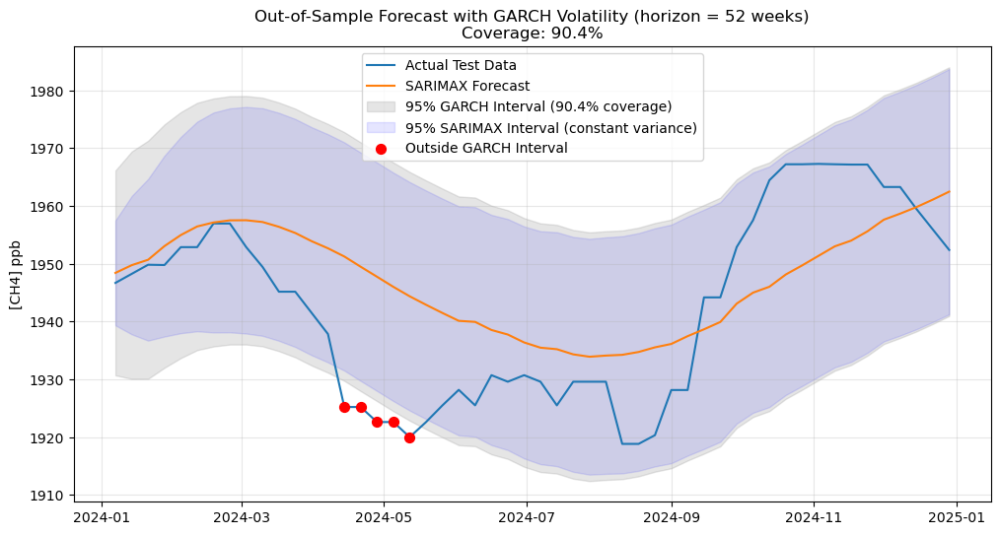

In [96]:
# Visualize the complete forecast

plt.figure(figsize=(12,6))
plt.plot(test_preprocessed.index, test_preprocessed, label='Actual Test Data')
plt.plot(forecast_series.index, forecast_series, label='SARIMAX Forecast')
# plot GARCH adjusted prediction intervals
plt.fill_between(
    forecast_series.index, 
    lower_bound, 
    upper_bound, 
    color='gray', 
    alpha=0.2, 
    label=f'95% GARCH Interval ({new_coverage_rate:.1f}% coverage)'
)
# plot the original SARIMAX constant-variance intervals for comparision
plt.fill_between(
    forecast_series.index, 
    forecast_ci.iloc[:,0],
    forecast_ci.iloc[:,1],
    color='blue', 
    alpha=0.1, 
    label=f'95% SARIMAX Interval (constant variance)'
)

outside_mask = ~test_within_interval
plt.scatter(test_preprocessed.index[outside_mask], test_preprocessed.values[outside_mask], color='red', s=50, zorder=5, label='Outside GARCH Interval')

plt.title(f'Out-of-Sample Forecast with GARCH Volatility (horizon = 52 weeks)\nCoverage: {new_coverage_rate:.1f}%')
# plt.xlabel('Time')
plt.ylabel('[CH4] ppb')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Diagnostics for persistent autocorrelation

In [225]:
# Check stationarity of original and differenced series
from statsmodels.tsa.stattools import adfuller, kpss

def check_stationarity(series, name="Series"):
    print(f"\n=== {name} Stationarity Tests ===")
    
    # ADF test (H0: unit root = non-stationary)
    adf_stat, adf_p, *_ = adfuller(series.dropna())
    print(f"ADF test: p-value = {adf_p:.4f}")
    print(f"  {'✓ Stationary' if adf_p < 0.05 else '✗ Non-stationary'}")
    
    # KPSS test (H0: stationary)
    kpss_stat, kpss_p, *_ = kpss(series.dropna())
    print(f"KPSS test: p-value = {kpss_p:.4f}")
    print(f"  {'✓ Stationary' if kpss_p > 0.05 else '✗ Non-stationary'}")
    
    return adf_p < 0.05 and kpss_p > 0.05  # Both tests agree

# Test your data
is_stationary = check_stationarity(train_recent15, "Original CH4")
is_stationary_diff = check_stationarity(train_recent15.diff().dropna(), "First Difference")


=== Original CH4 Stationarity Tests ===
ADF test: p-value = 0.8585
  ✗ Non-stationary
KPSS test: p-value = 0.0100
  ✗ Non-stationary

=== First Difference Stationarity Tests ===
ADF test: p-value = 0.0000
  ✓ Stationary
KPSS test: p-value = 0.1000
  ✓ Stationary


C:\Users\aplor\AppData\Local\Temp\ipykernel_3036\3817289973.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series.dropna())
C:\Users\aplor\AppData\Local\Temp\ipykernel_3036\3817289973.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series.dropna())


## Check for multiple seasonal frequencies

In [270]:
from scipy import signal

def find_seasonal_periods(series, max_period=104):
    """
    Find significant seasonal periods using FFT
    """
    # Remove trend via differencing
    detrended = series.diff().dropna()
    
    # FFT analysis
    n = len(detrended)
    freqs = np.fft.fftfreq(n)
    fft_vals = np.abs(np.fft.fft(detrended - detrended.mean()))
    
    # Only positive frequencies
    pos_freqs = freqs[:n//2]
    pos_fft = fft_vals[:n//2]
    
    # Convert to periods (weeks)
    periods = 1 / pos_freqs[1:]  # Skip freq=0
    power = pos_fft[1:]
    
    # Find peaks
    peaks_idx = signal.find_peaks(power, height=np.mean(power)*1.7)[0]
    significant_periods = periods[peaks_idx]
    
    # Filter realistic periods (between 4 and max_period weeks)
    valid_periods = significant_periods[(significant_periods >= 4) & (significant_periods <= max_period)]
    
    print("Significant seasonal periods (weeks):")
    for p in sorted(valid_periods):
        print(f"  - {p:.1f} weeks")
    
    return valid_periods

seasonal_periods = find_seasonal_periods(train_recent15)

Significant seasonal periods (weeks):
  - 4.1 weeks
  - 4.3 weeks
  - 4.4 weeks
  - 4.7 weeks
  - 4.8 weeks
  - 5.0 weeks
  - 5.5 weeks
  - 5.6 weeks
  - 6.0 weeks
  - 8.8 weeks
  - 14.2 weeks
  - 17.8 weeks
  - 26.1 weeks
  - 52.1 weeks


**Interpretation of results**

Fast Fourier Transform (FFT) was used to identify seasonal cycles (periodicities) in the data.  

- monthly cycle:  There is a cluster of frequencies between 4-6 weeks suggesting a monthly period.  

- quarterly cycle:  The 12.8 week peek suggests a quarterly cycle

- ter-annual cycle:  a peek at 17.8 weeks suggests a cycle that occurs three times per year.  

- semi-annual:  peek at 16.1 weeks.

I will performed a diagnostic test for Long-Range Dependence using the Hurst Exponent (H). This step is critical to ensure that the remaining correlation in the time series is due solely to the short-term, cyclical seasonal patterns (identified via FFT) and not due to long memory, which would necessitate the use of an ARFIMA model. 

### Test for long memory (Hurst exponent)

In [425]:
def test_long_memory(differenced_series):
    """
    Test if differenced series shows long memory (fractional d)
    """
    # Hurst exponent estimation
    def hurst_exponent(ts):
        """Calculate Hurst exponent to detect long memory"""
        lags = range(2, 100)
        tau = [np.std(np.subtract(ts[lag:], ts[:-lag])) for lag in lags]
        poly = np.polyfit(np.log(lags), np.log(tau), 1)
        return poly[0]
    
    hurst = hurst_exponent(differenced_series.values)
    
    # Interpret results
    print(f"Hurst exponent: {hurst:.3f}")
    if hurst > 0.65:
        print("--> Strong evidence of long memory (fractional integration)")
        print(f"  Estimated fractional d in differenced series: {hurst - 0.5:.2f}")
        print(f"  Total d needed (original series): ~{1 + (hurst - 0.5):.2f}")
    elif hurst > 0.55:
        print("--> Mild long memory patterns")
    else:
        print("--> No strong evidence of long memory")
    
    return hurst

hurst_value = test_long_memory(diff_series)

Hurst exponent: 0.001
--> No strong evidence of long memory


**Interpretation of the Hurst exponent results**

The Hurst exponent measures persistence, the tendency of the time series data to trend or revert to the mean.  

- H < 0.5: anti-persistence or mean reverting (reversals are likely)
- H = 0.5: random-walk/Brownian movement (no memory)
- H > 0.5: persistence/trending (past values predict future values)

results:
H = 0.001:  this is far below the threshold (0.5) for white noise and indicates anti-persistence.  It's likely that d=1 is over-differencing the data and possibly introducing artificial correlation.  

I will run the Hurst exponent on the data where d=0 (and D=0).  

In [427]:
# test long memory of non-differenced data

def test_long_memory(series):
    """
    Test if differenced series shows long memory (fractional d)
    """
    # Hurst exponent estimation
    def hurst_exponent(ts):
        """Calculate Hurst exponent to detect long memory"""
        lags = range(2, 100)
        tau = [np.std(np.subtract(ts[lag:], ts[:-lag])) for lag in lags]
        poly = np.polyfit(np.log(lags), np.log(tau), 1)
        return poly[0]
    
    hurst = hurst_exponent(series.values)
    
    # Interpret results
    print(f"Hurst exponent: {hurst:.3f}")
    if hurst > 0.65:
        print("--> Strong evidence of long memory (fractional integration)")
        print(f"  Estimated fractional d in differenced series: {hurst - 0.5:.2f}")
        print(f"  Total d needed (original series): ~{1 + (hurst - 0.5):.2f}")
    elif hurst > 0.55:
        print("--> Mild long memory patterns")
    else:
        print("--> No strong evidence of long memory")
    
    return hurst

hurst_value = test_long_memory(train_recent15)

Hurst exponent: 0.111
--> No strong evidence of long memory


**Interpretation of Hurst exponent of non-differenced data**

The low H value is a bot surprising based on the strong upward trend of the data (5.5 ppb/year, R^2 = 0.916), which should cause the H value to be closer to 1.  

The Hurst exponent was tested on the CH4_recent15 series (d=0) and yielded a value of H=0.111. While this low value appears to indicate strong anti-persistence, it is a common diagnostic artifact when the time series is dominated by strong, deterministic cycles (confirmed by the FFT analysis) and an underlying linear trend. The test was used to conclusively confirm two modeling decisions:
1. It rules out the need for an ARFIMA model (fractional integration).
2. The resulting H=0.001 after d=1 differencing definitively shows that d=1 leads to over-differencing.
  
Therefore, all diagnostics confirm that the CH4 series must be modeled by separating the deterministic components (trend and multiple seasonal cycles) from the stochastic components.

Next steps:  
1. FFT analysis of seasonal cycles on data where d=0 to determine the seasonal cycles.
2. will need to use trend = t or ct for SARIMAX models to model the deterministic slope.  

## Check for multiple seasonal freqs (d=0)

In [426]:
# Look for multiple seasonal frequencies in non-differenced data

def find_seasonal_periods(series, max_period=104):
    """
    Find significant seasonal periods using FFT
    """
    # Remove trend via differencing
    #detrended = series.diff().dropna()
    
    # FFT analysis
    n = len(series)
    freqs = np.fft.fftfreq(n)
    fft_vals = np.abs(np.fft.fft(series - series.mean()))
    
    # Only positive frequencies
    pos_freqs = freqs[:n//2]
    pos_fft = fft_vals[:n//2]
    
    # Convert to periods (weeks)
    periods = 1 / pos_freqs[1:]  # Skip freq=0
    power = pos_fft[1:]
    
    # Find peaks
    peaks_idx = signal.find_peaks(power, height=np.mean(power)*1.7)[0]
    significant_periods = periods[peaks_idx]
    
    # Filter realistic periods (between 4 and max_period weeks)
    valid_periods = significant_periods[(significant_periods >= 4) & (significant_periods <= max_period)]
    
    print("Significant seasonal periods (weeks) in non-differenced data:")
    for p in sorted(valid_periods):
        print(f"  - {p:.1f} weeks")
    
    return valid_periods

seasonal_periods = find_seasonal_periods(train_recent15)

Significant seasonal periods (weeks) in non-differenced data:
  - 12.6 weeks
  - 17.8 weeks
  - 18.6 weeks
  - 20.1 weeks
  - 23.0 weeks
  - 24.5 weeks
  - 26.1 weeks
  - 28.0 weeks
  - 31.3 weeks
  - 35.6 weeks
  - 39.1 weeks
  - 43.5 weeks
  - 52.2 weeks
  - 60.2 weeks


**Interpretation of the FFT results where d=0**

The many significant monthly cycles in the range of 4-9 weeks when d=1 are no longer present.  This corroborates that d=1 was inducing non-seaonal patterns.  

Three primary cyclical patterns:
- 52.2 weeks: This is the primary annual cycle and consisitent with the observed reapeating cycles that are approximately 52 weeks in duration.  Use D=1 and/or K=1 Fourier pair.
- 26.1 weeks: Semi-annual harmonic that will require k=2 Fourier pairs.
- 12.6 weeks: Quarterly harmonic requiring k=4 Fourier pairs.  

## Analyze the ACF/PACF of Differenced Data

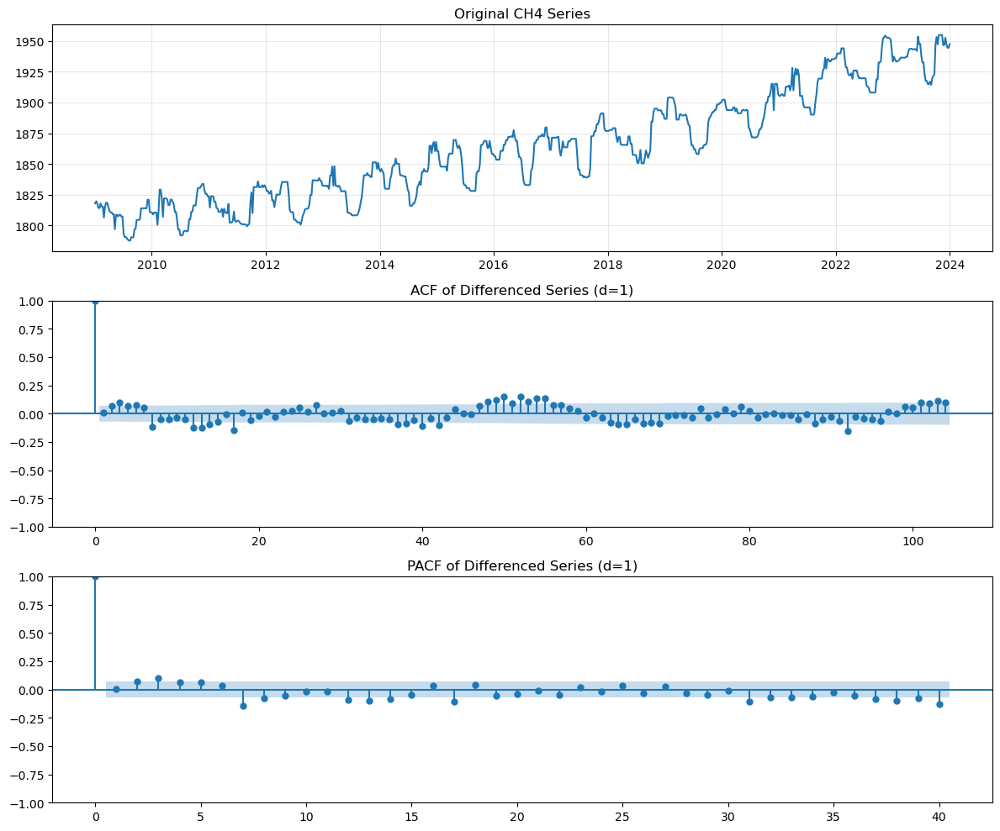

Significant ACF lags: [ 0  2  3  5  7 12 13 14 15 17]
Significant PACF lags: [ 0  2  3  7  8 12 13 14 17 31]


In [273]:
def analyze_memory_structure(series, max_lag=104):
    """
    Detailed ACF/PACF analysis to identify memory patterns
    """    
    differenced = series.diff().dropna()
    
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    
    # Original series
    axes[0].plot(series)
    axes[0].set_title('Original CH4 Series')
    axes[0].grid(True, alpha=0.3)
    
    # ACF of differenced series
    plot_acf(differenced, lags=max_lag, ax=axes[1])
    axes[1].set_title(f'ACF of Differenced Series (d=1)')
    
    # PACF of differenced series
    plot_pacf(differenced, lags=min(40, max_lag//2), ax=axes[2])
    axes[2].set_title(f'PACF of Differenced Series (d=1)')
    
    plt.tight_layout()
    plt.show()
    
    # Quantitative analysis
    from statsmodels.tsa.stattools import acf, pacf
    acf_vals = acf(differenced, nlags=max_lag)
    pacf_vals = pacf(differenced, nlags=min(40, max_lag//2))
    
    # Count significant lags
    conf_int = 1.96 / np.sqrt(len(differenced))
    sig_acf = np.where(np.abs(acf_vals) > conf_int)[0]
    sig_pacf = np.where(np.abs(pacf_vals) > conf_int)[0]
    
    print(f"Significant ACF lags: {sig_acf[:10]}")  # First 10
    print(f"Significant PACF lags: {sig_pacf[:10]}")
    
    return differenced, acf_vals, pacf_vals

diff_series, acf_vals, pacf_vals = analyze_memory_structure(train_recent15)

**Interpretation of ACF and PACF plots**

The ACF/PACF plots have neither a sharp cutoff or smooth decay suggesting a mixed ARMA process.  

Significant lags to at least 17 in the ACF plot suggests a possible need for higher non-seasonal AR and MA terms.  

Both ACF and PACF show many signficiant lags, which suggests a complex ARMA proces.  

Significant lags that are not sequential, e.g. 7 and 12 corroborate the FFT results of non-annual cycles that are not captured by non-seasonal differencing, strongly suggesting distinct, repeating cycles rather than a single AR or MA dependence.  

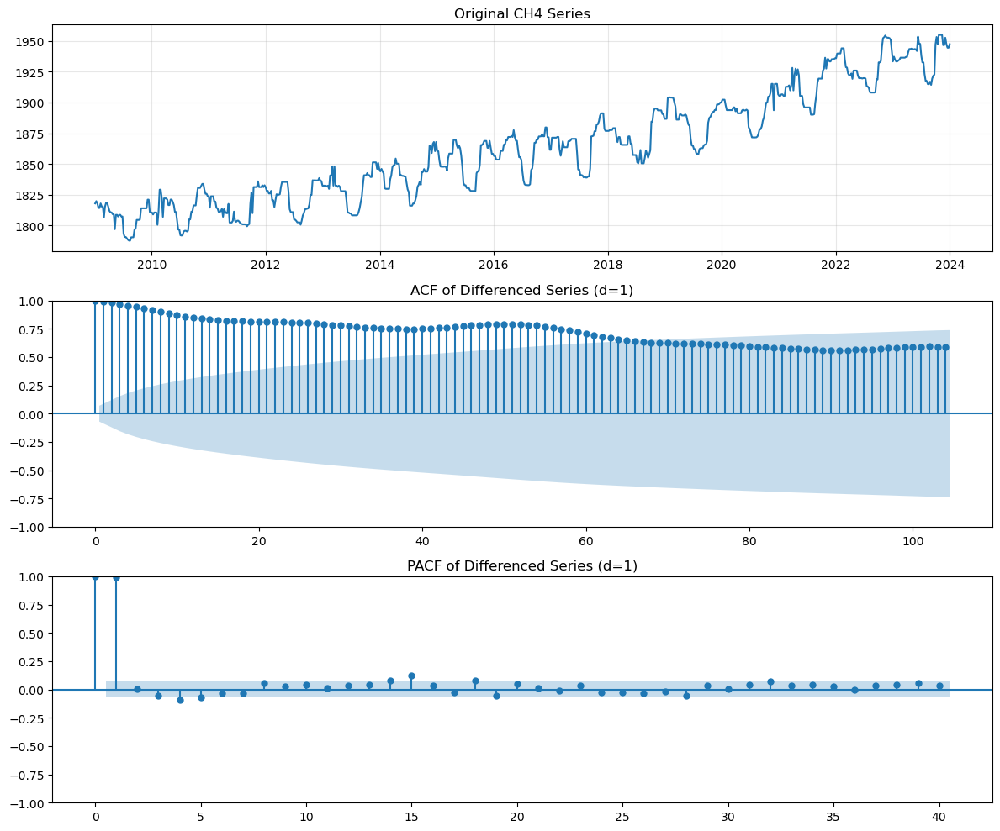

Significant ACF lags: [0 1 2 3 4 5 6 7 8 9]
Significant PACF lags: [ 0  1  4  5  8 14 15 18 32 39]


In [278]:
# Analyze memory structure of non-differenced data

def analyze_memory_structure(series, max_lag=104):
    """
    Detailed ACF/PACF analysis to identify memory patterns
    """    
    #differenced = series.diff().dropna()
    
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    
    # Original series
    axes[0].plot(series)
    axes[0].set_title('Original CH4 Series')
    axes[0].grid(True, alpha=0.3)
    
    # ACF of differenced series
    plot_acf(series, lags=max_lag, ax=axes[1])
    axes[1].set_title(f'ACF of Differenced Series (d=1)')
    
    # PACF of differenced series
    plot_pacf(series, lags=min(40, max_lag//2), ax=axes[2])
    axes[2].set_title(f'PACF of Differenced Series (d=1)')
    
    plt.tight_layout()
    plt.show()
    
    # Quantitative analysis
    from statsmodels.tsa.stattools import acf, pacf
    acf_vals = acf(series, nlags=max_lag)
    pacf_vals = pacf(series, nlags=min(40, max_lag//2))
    
    # Count significant lags
    conf_int = 1.96 / np.sqrt(len(series))
    sig_acf = np.where(np.abs(acf_vals) > conf_int)[0]
    sig_pacf = np.where(np.abs(pacf_vals) > conf_int)[0]
    
    print(f"Significant ACF lags: {sig_acf[:10]}")  # First 10
    print(f"Significant PACF lags: {sig_pacf[:10]}")
    
    return acf_vals, pacf_vals

acf_vals, pacf_vals = analyze_memory_structure(train_recent15)

In [254]:
def create_multiple_fourier_terms(t, periods=[52, 26, 17.3], K_values=[1, 1, 1]):
    """
    Create Fourier terms for multiple seasonal periods

    Parameters:
    t (array): Time index.
    periods (list): List of seasonal periods.
    K_values (list): List of number of Fourier term pairs for each period.
    
    Returns:
    np.ndarray: Matrix of Fourier terms.
    """
    all_terms = []
    for period, K in zip(periods, K_values):
        for i in range(1, K+1):
            all_terms.append(np.sin(2 * np.pi * i * t / period))
            all_terms.append(np.cos(2 * np.pi * i * t / period))
    
    return np.column_stack(all_terms)

C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Using 731 residuals for diagnostics (first 52 excluded as burn_in)

--- In-Sample Accuracy (after burn-in) ---
RMSE: 4.514
MAE:  3.114
MAPE: 0.17%
R2:   0.988


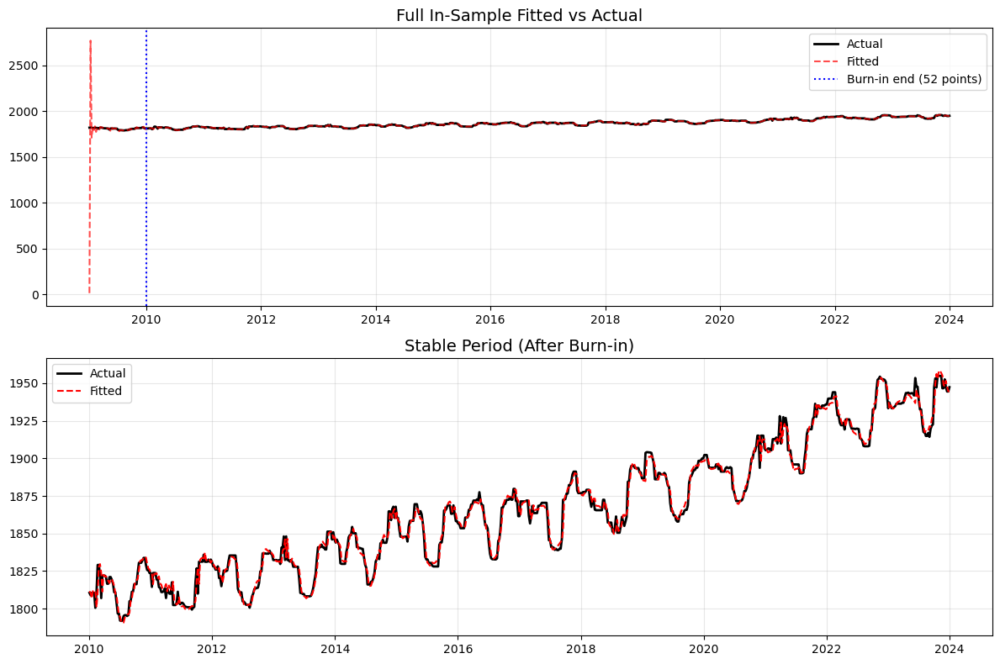

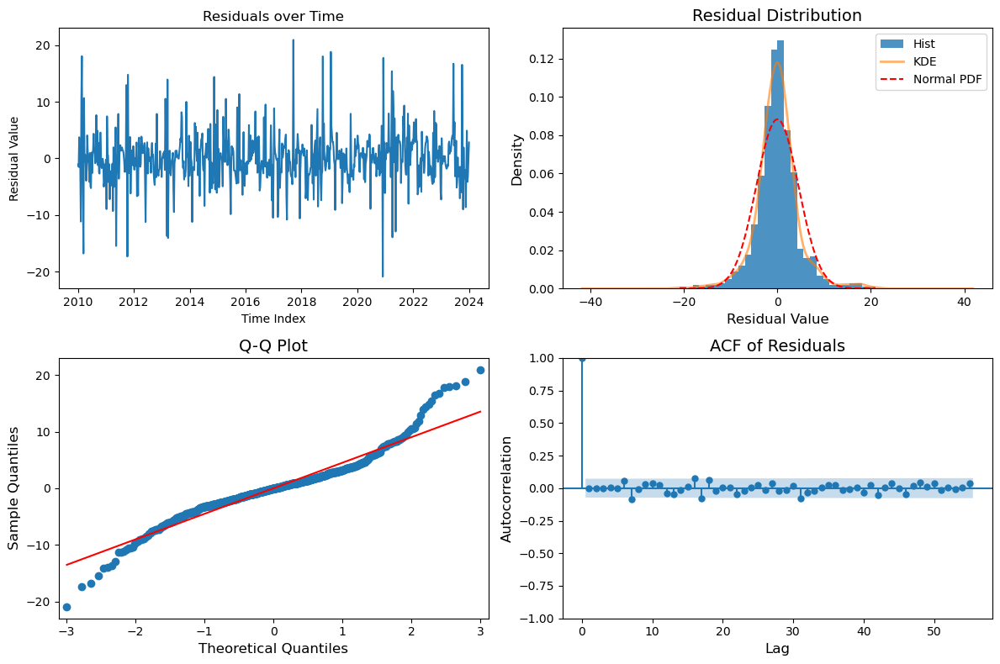


=== Residual Diagnostic Tests ===

--- Distribution Diagnostics ---
Jarque-Bera test:
	JB = 445.14
	p = 0.0000
	Skewness = 0.331
	kurtosis = 6.765

--- Autocorrelation Diagnostics ---
Ljung-Box Test:
(H0: No autocorrelation up to specified lags)
	lag 1: p = 0.9907
	lag 4: p = 0.9999
	lag 13: p = 0.4869
	lag 26: p = 0.3612
	lag 52: p = 0.7304

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0000***
	Lag 8: p-value = 0.0000***
	Lag 12: p-value = 0.0000***
	Lag 26: p-value = 0.0000***


In [256]:
# Test with additional Fourier terms
t = np.arange(len(train_recent15))

# Try annual + semi-annual
exog_multi = create_multiple_fourier_terms(t, periods=[52, 26], K_values=[1, 1])

results_multi, resids_multi = in_sample_resid_analysis(
    train_recent15,
    order=(6,1,2),
    seasonal_order=(0,0,1,52),
    exog=exog_multi,
    estimation_method='lbfgs'
)

C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Using 731 residuals for diagnostics (first 52 excluded as burn_in)

--- In-Sample Accuracy (after burn-in) ---
RMSE: 4.514
MAE:  3.114
MAPE: 0.17%
R2:   0.988


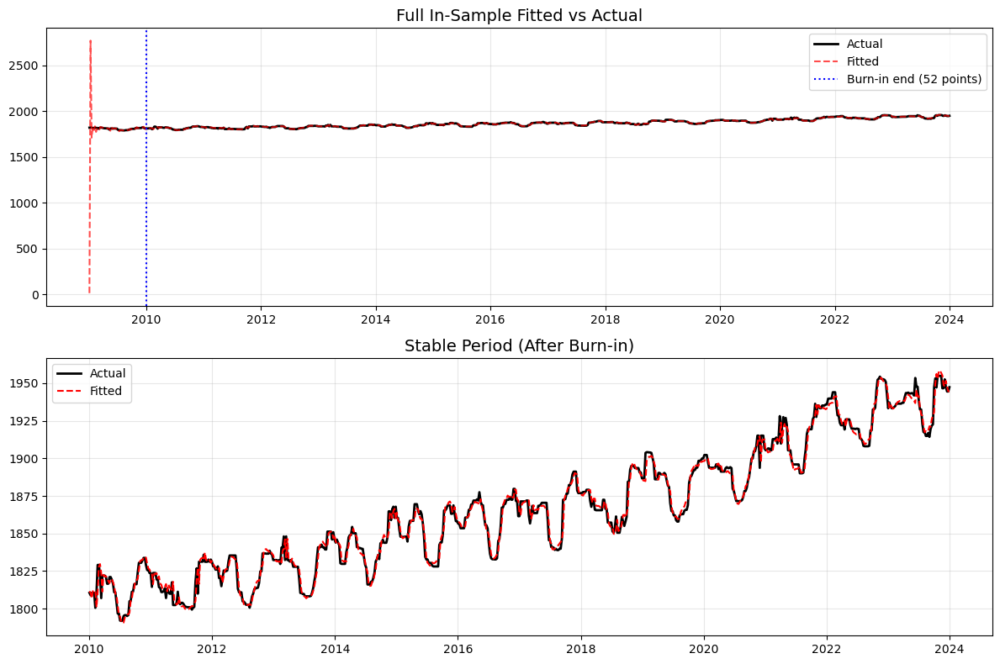

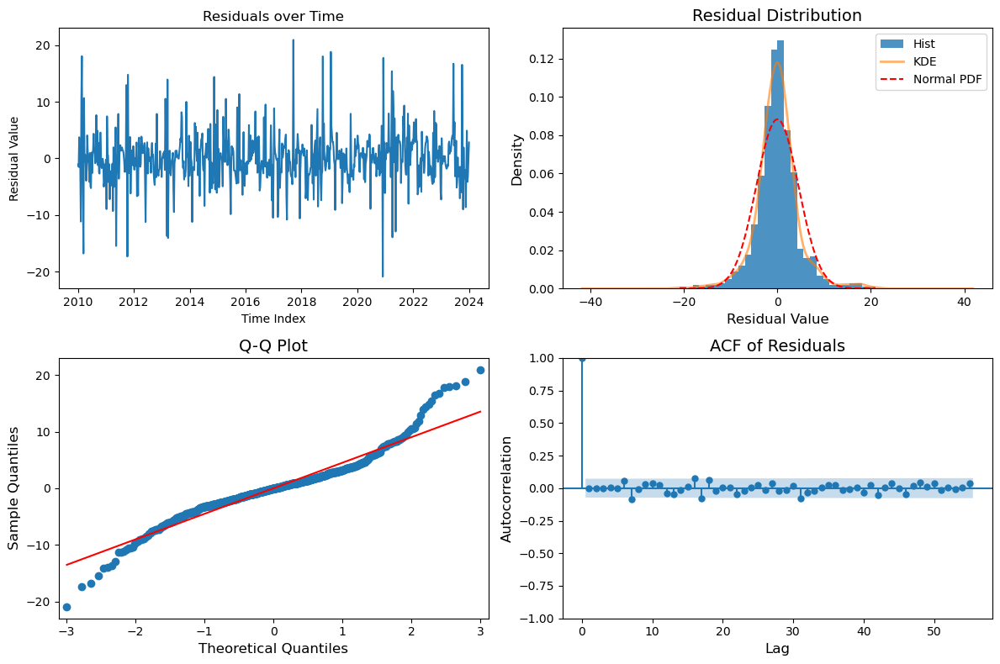


=== Residual Diagnostic Tests ===

--- Distribution Diagnostics ---
Jarque-Bera test:
	JB = 445.14
	p = 0.0000
	Skewness = 0.331
	kurtosis = 6.765

--- Autocorrelation Diagnostics ---
Ljung-Box Test:
(H0: No autocorrelation up to specified lags)
	lag 1: p = 0.9907
	lag 4: p = 0.9999
	lag 13: p = 0.4869
	lag 26: p = 0.3612
	lag 52: p = 0.7304

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0000***
	Lag 8: p-value = 0.0000***
	Lag 12: p-value = 0.0000***
	Lag 26: p-value = 0.0000***


In [562]:
# Test with one Fourier term and two harmonics
t = np.arange(len(train_recent15))

# Try annual + semi-annual
exog_multi = create_multiple_fourier_terms(t, periods=[52], K_values=[2])

results_multi, resids_multi = in_sample_resid_analysis(
    train_recent15,
    order=(6,1,2),
    seasonal_order=(0,0,1,52),
    exog=exog_multi,
    estimation_method='lbfgs'
)

Fourier terms assuming two seasonal cycles (26 weeks and 52 weeks) modeled the truncated train set (train_recent15) better than the full train set (train_preprocessed) based on the Ljung-Box test results (code and results not shown).  This is possibly due to the non-seaonal orders that were optimized for the shorter data set.  However, it may be better to determine optimal SARIMAX parameters with the full data set since more data may ultimately lead to better generalization for forecasting.  

## Test multi-period Fourier combinations

In [241]:
def create_multi_period_fourier_terms(t, periods, K_values=None, index=None):
    """
    Create Fourier terms for multiple seasonal periods
    
    Parameters:
    -----------
    t        : array, time index (0, 1, 2, ...)
    periods  : list of seasonal periods in weeks
    K_values : list of harmonics for each period (default 1 for all)
    index    : optional, pandas index to use for the returned DataFrame
    """
    if K_values is None:
        K_values = [1] * len(periods)
    
    all_terms = []
    term_names = []
    
    for period, K in zip(periods, K_values):
        for i in range(1, K+1):
            all_terms.append(np.sin(2 * np.pi * i * t / period))
            all_terms.append(np.cos(2 * np.pi * i * t / period))
            term_names.extend([f'sin_{period:.1f}_{i}', f'cos_{period:.1f}_{i}'])
    
    fourier_matrix = np.column_stack(all_terms)
    fourier_df = pd.DataFrame(fourier_matrix, columns=term_names)

    # Use provided index if available 
    if index is not None:
        fourier_df.index = index
        
    return fourier_df

C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Using 731 residuals for diagnostics (first 52 excluded as burn_in)

--- In-Sample Accuracy (after burn-in) ---
RMSE: 4.423
MAE:  3.061
MAPE: 0.16%
R2:   0.989


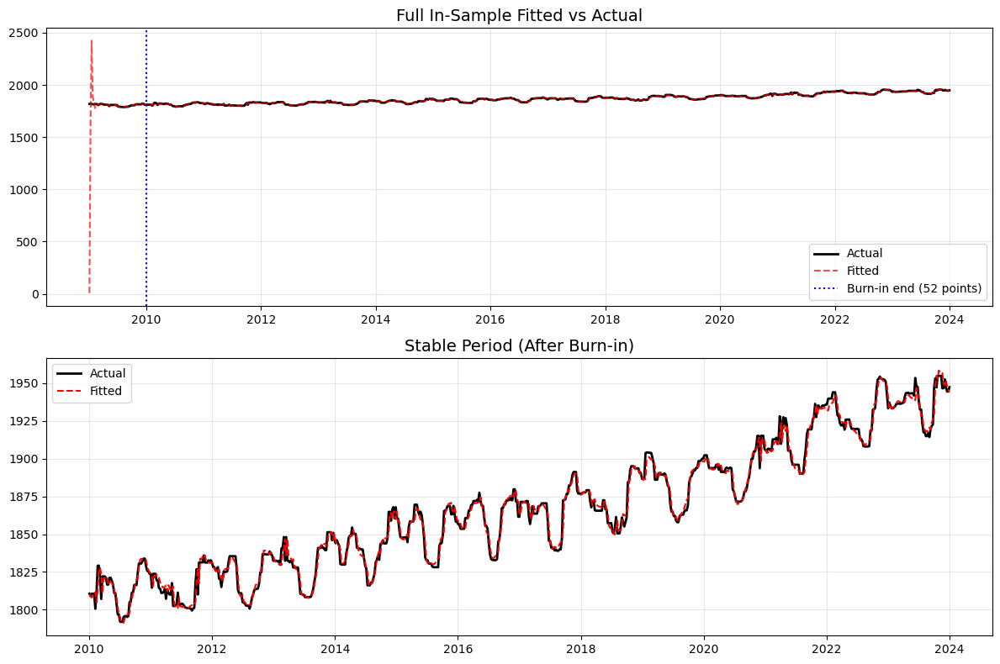

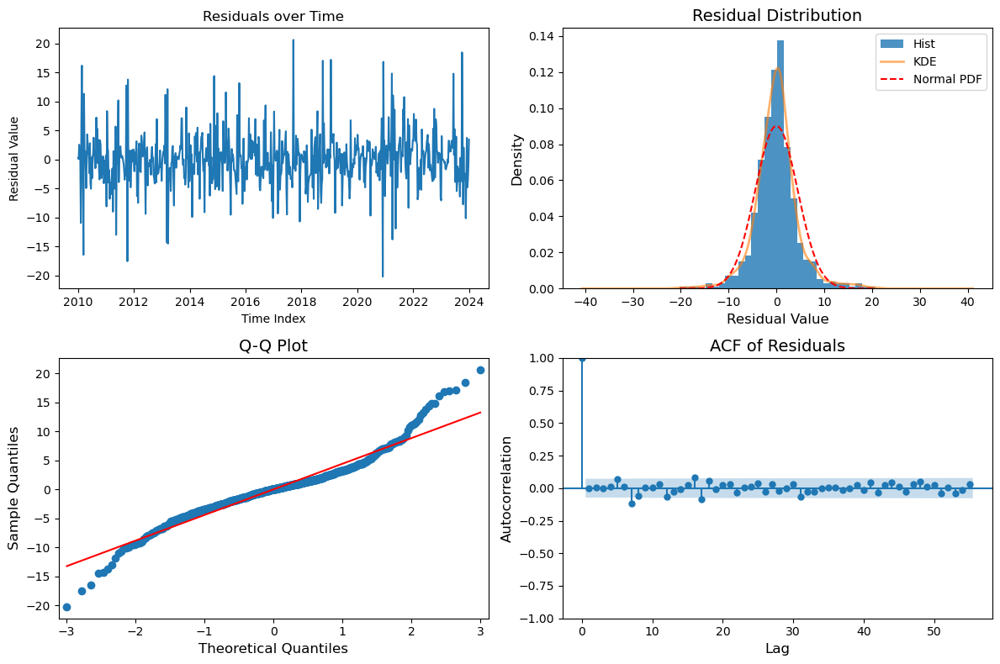


=== Residual Diagnostic Tests ===

--- Distribution Diagnostics ---
Jarque-Bera test:
	JB = 398.45
	p = 0.0000
	Skewness = 0.321
	kurtosis = 6.560

--- Autocorrelation Diagnostics ---
Ljung-Box Test:
(H0: No autocorrelation up to specified lags)
	lag 1: p = 0.9926
	lag 4: p = 0.9973
	lag 13: p = 0.0717
	lag 26: p = 0.0568
	lag 52: p = 0.3674

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0000***
	Lag 8: p-value = 0.0000***
	Lag 12: p-value = 0.0000***
	Lag 26: p-value = 0.0001***

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.8861
White: p = 0.3592


In [242]:
# Most important periods from the find_seasonal_periods function results
critical_periods = [52.1, 26.1, 17.8, 12.6, 8.8]  # weeks
K_settings = [1, 1, 1, 1, 1]  # Start with 1 harmonic each

# Create Fourier terms
t = np.arange(len(train_recent15))
exog_multi = create_multi_period_fourier_terms(
    t, 
    critical_periods, 
    K_settings,
    index=train_recent15.index
)

# Fit model with multiple Fourier terms
results_multi, residuals_multi = in_sample_resid_analysis(
    train_recent15,
    order=(6,1,2),  
    seasonal_order=(0,0,0,52),  # Remove seasonal MA - let Fourier handle seasonality
    exog=exog_multi,
    estimation_method='lbfgs',
    run_hetero=True
)


Testing periods: [52.1]


C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Using 731 residuals for diagnostics (first 52 excluded as burn_in)

--- In-Sample Accuracy (after burn-in) ---
RMSE: 4.884
MAE:  3.151
MAPE: 0.17%
R2:   0.986


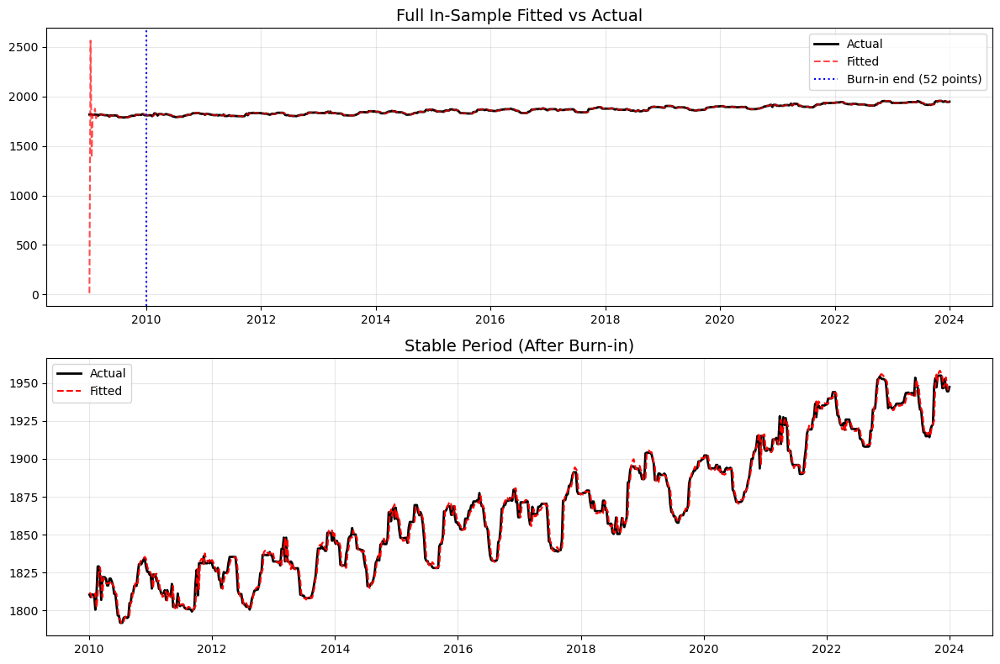

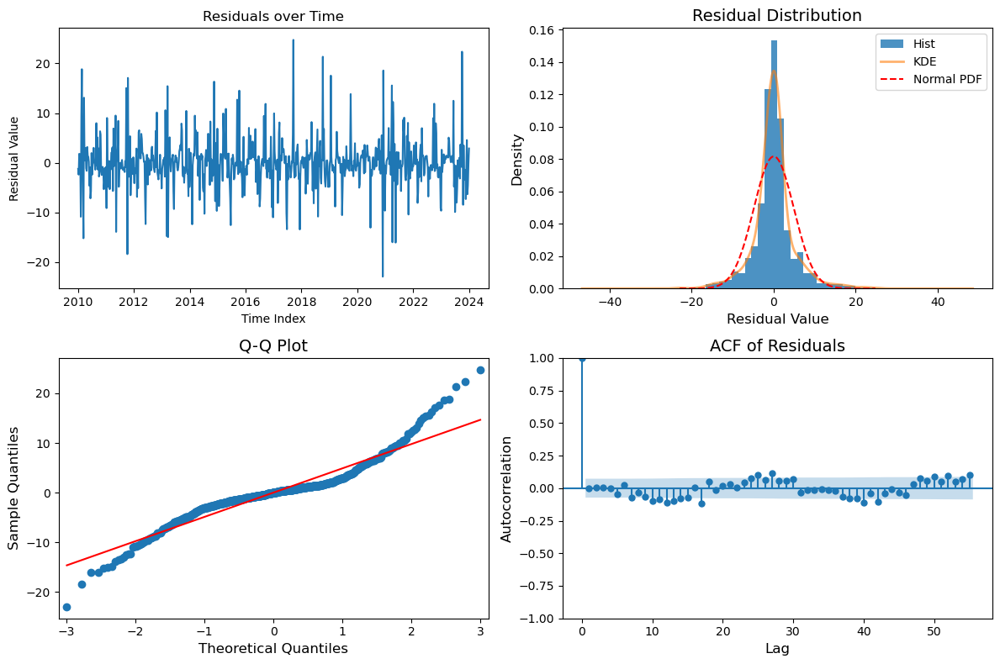


=== Residual Diagnostic Tests ===

--- Distribution Diagnostics ---
Jarque-Bera test:
	JB = 614.30
	p = 0.0000
	Skewness = 0.418
	kurtosis = 7.412

--- Autocorrelation Diagnostics ---
Ljung-Box Test:
(H0: No autocorrelation up to specified lags)
	lag 1: p = 0.9672
	lag 4: p = 1.0000
	lag 13: p = 0.0001
	lag 26: p = 0.0000
	lag 52: p = 0.0000

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0001***
	Lag 8: p-value = 0.0002***
	Lag 12: p-value = 0.0005***
	Lag 26: p-value = 0.0086***

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.7129
White: p = 0.6742

Testing periods: [52.1, 26.1]


C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Using 731 residuals for diagnostics (first 52 excluded as burn_in)

--- In-Sample Accuracy (after burn-in) ---
RMSE: 4.488
MAE:  3.076
MAPE: 0.16%
R2:   0.989


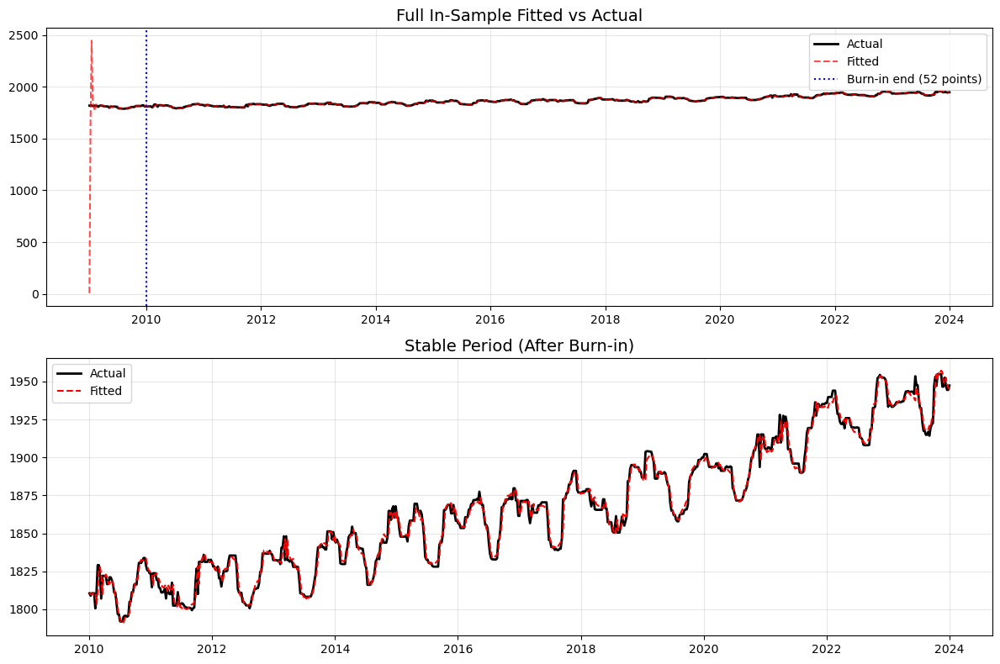

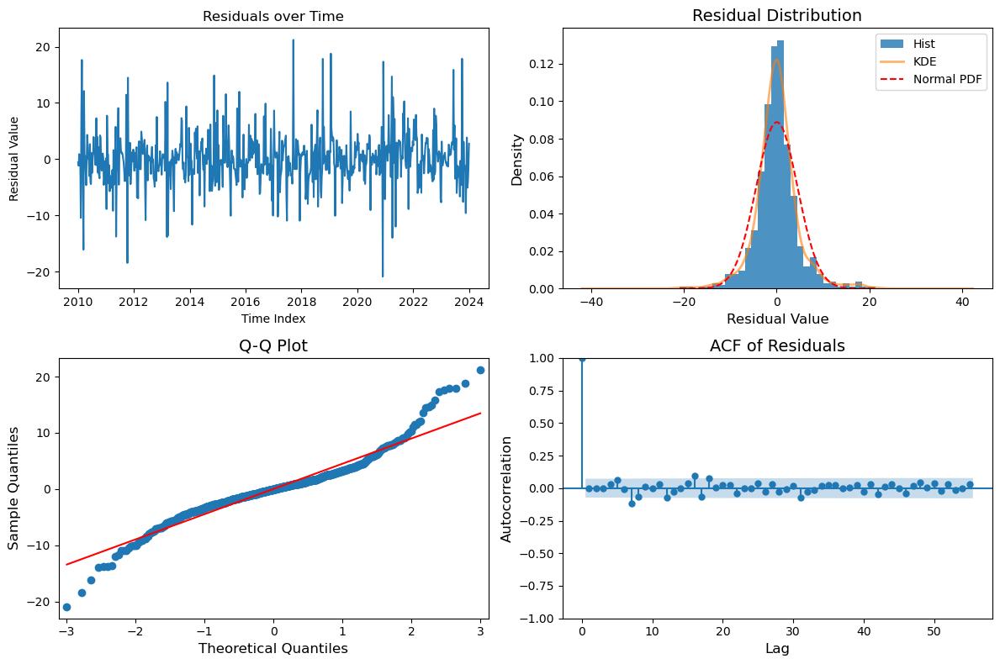


=== Residual Diagnostic Tests ===

--- Distribution Diagnostics ---
Jarque-Bera test:
	JB = 460.82
	p = 0.0000
	Skewness = 0.346
	kurtosis = 6.828

--- Autocorrelation Diagnostics ---
Ljung-Box Test:
(H0: No autocorrelation up to specified lags)
	lag 1: p = 0.9670
	lag 4: p = 0.9526
	lag 13: p = 0.0565
	lag 26: p = 0.0326
	lag 52: p = 0.2684

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0000***
	Lag 8: p-value = 0.0000***
	Lag 12: p-value = 0.0001***
	Lag 26: p-value = 0.0010***

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.8319
White: p = 0.4789

Testing periods: [52.1, 26.1, 17.8]


C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Using 731 residuals for diagnostics (first 52 excluded as burn_in)

--- In-Sample Accuracy (after burn-in) ---
RMSE: 4.457
MAE:  3.065
MAPE: 0.16%
R2:   0.989


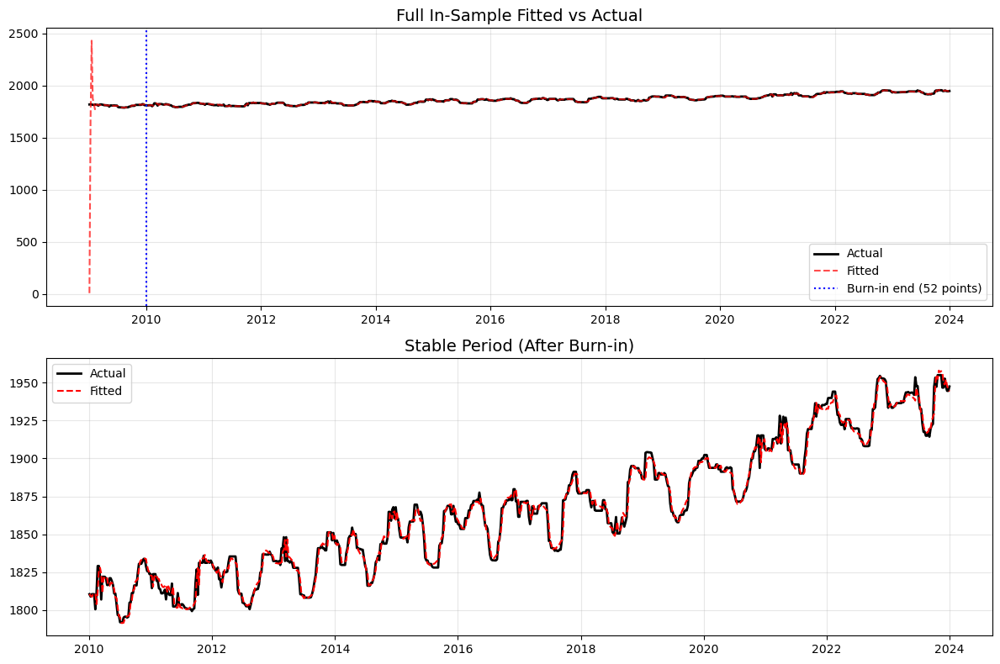

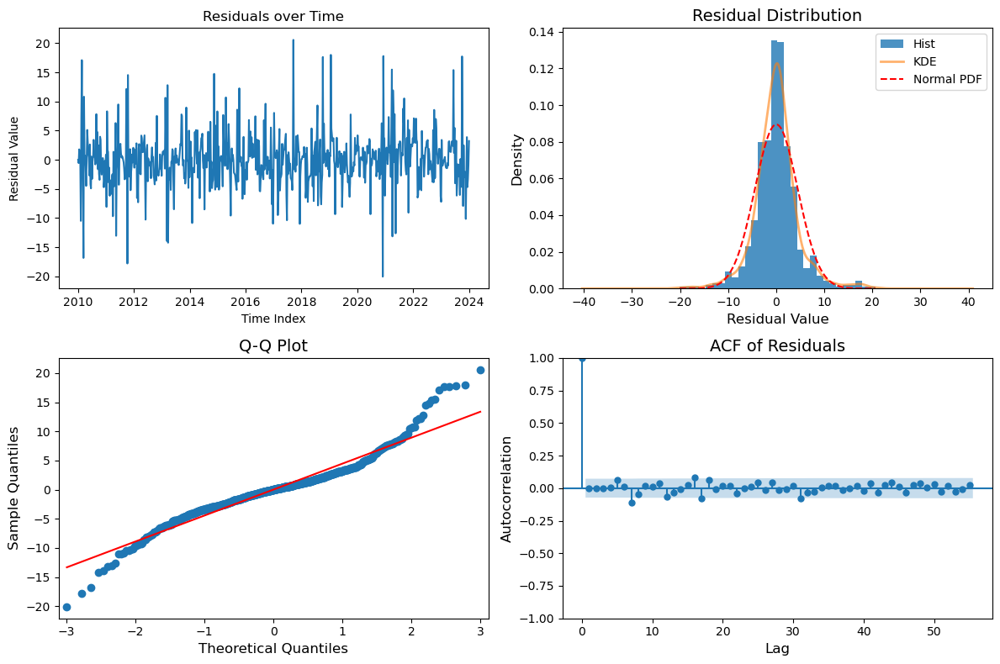


=== Residual Diagnostic Tests ===

--- Distribution Diagnostics ---
Jarque-Bera test:
	JB = 421.95
	p = 0.0000
	Skewness = 0.348
	kurtosis = 6.656

--- Autocorrelation Diagnostics ---
Ljung-Box Test:
(H0: No autocorrelation up to specified lags)
	lag 1: p = 0.9658
	lag 4: p = 0.9998
	lag 13: p = 0.1109
	lag 26: p = 0.0780
	lag 52: p = 0.3776

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0000***
	Lag 8: p-value = 0.0000***
	Lag 12: p-value = 0.0000***
	Lag 26: p-value = 0.0001***

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.8023
White: p = 0.4361

Testing periods: [52.1, 26.1, 17.8, 12.6]


C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Using 731 residuals for diagnostics (first 52 excluded as burn_in)

--- In-Sample Accuracy (after burn-in) ---
RMSE: 4.447
MAE:  3.068
MAPE: 0.16%
R2:   0.989


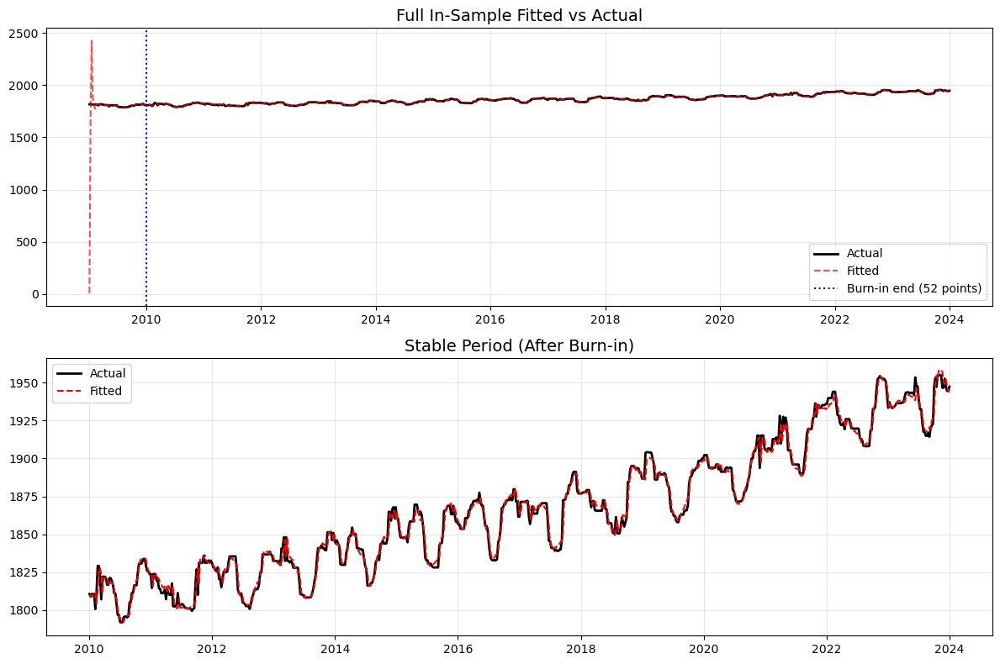

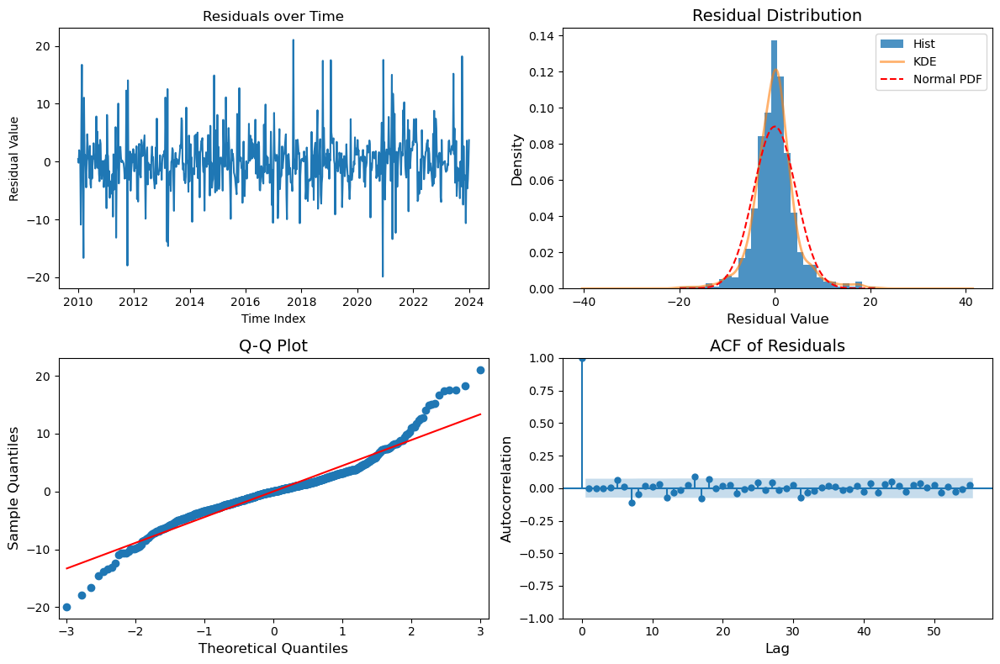


=== Residual Diagnostic Tests ===

--- Distribution Diagnostics ---
Jarque-Bera test:
	JB = 424.23
	p = 0.0000
	Skewness = 0.352
	kurtosis = 6.665

--- Autocorrelation Diagnostics ---
Ljung-Box Test:
(H0: No autocorrelation up to specified lags)
	lag 1: p = 0.9915
	lag 4: p = 0.9999
	lag 13: p = 0.1063
	lag 26: p = 0.0731
	lag 52: p = 0.3842

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0000***
	Lag 8: p-value = 0.0000***
	Lag 12: p-value = 0.0000***
	Lag 26: p-value = 0.0002***

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.9001
White: p = 0.4053

Testing periods: [52.1, 26.1, 17.8, 12.6, 8.8]


C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Using 731 residuals for diagnostics (first 52 excluded as burn_in)

--- In-Sample Accuracy (after burn-in) ---
RMSE: 4.423
MAE:  3.061
MAPE: 0.16%
R2:   0.989


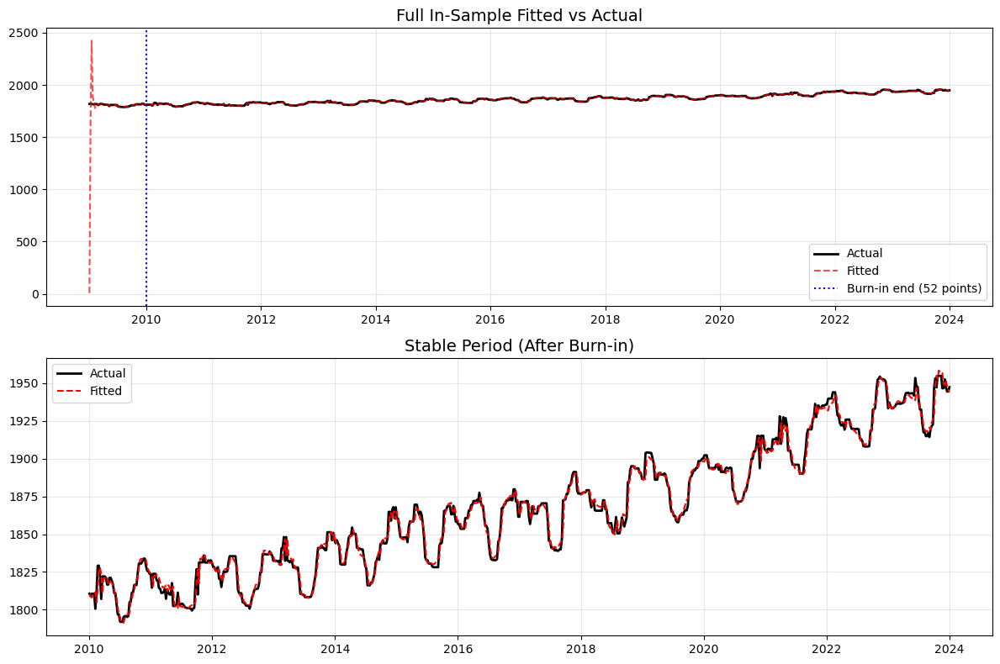

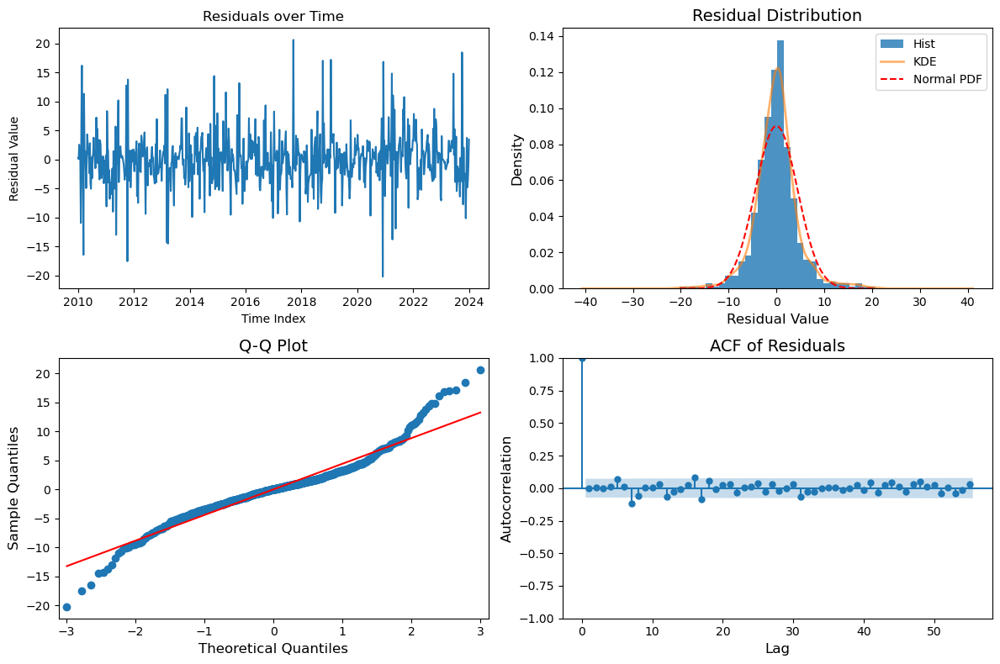


=== Residual Diagnostic Tests ===

--- Distribution Diagnostics ---
Jarque-Bera test:
	JB = 398.45
	p = 0.0000
	Skewness = 0.321
	kurtosis = 6.560

--- Autocorrelation Diagnostics ---
Ljung-Box Test:
(H0: No autocorrelation up to specified lags)
	lag 1: p = 0.9926
	lag 4: p = 0.9973
	lag 13: p = 0.0717
	lag 26: p = 0.0568
	lag 52: p = 0.3674

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0000***
	Lag 8: p-value = 0.0000***
	Lag 12: p-value = 0.0000***
	Lag 26: p-value = 0.0001***

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.8861
White: p = 0.3592


In [258]:
# I will use exact seasonal periods from the find_seasonal_periods function results
# SARIMA(6,1,2)(0,0,0,52)

period_combinations = [
    [52.1],                        # annual
    [52.1, 26.1],                  # annual + semi-annual
    [52.1, 26.1, 17.8],            # + ter-annual
    [52.1, 26.1, 17.8, 12.6],      # + quarterly
    [52.1, 26.1, 17.8, 12.6, 8.8], # + bi-monthly 
]

results_by_combo = {}
for i, periods in enumerate(period_combinations):
    print(f"\n{'=' * 50}")
    print(f"Testing periods: {periods}")

    exog_test = create_multi_period_fourier_terms(t, periods, index=train_recent15.index)

    results, residuals = in_sample_resid_analysis(
        train_recent15,
        order=(6,1,2),
        seasonal_order=(0,0,0,52),
        exog=exog_test,
        estimation_method='lbfgs',
        run_hetero=True
    )

    # store metrics
    results_by_combo[f"combo_{i}"] = {
        'periods': periods,
        'rmse': np.sqrt(mean_squared_error(train_recent15[52:], results.fittedvalues[52:])),
        'lb_pvals': acorr_ljungbox(residuals, lags=[1,4,13,26,52], return_df=True)['lb_pvalue'].tolist()
    }


Testing periods: [52.1]


C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Using 731 residuals for diagnostics (first 52 excluded as burn_in)

--- In-Sample Accuracy (after burn-in) ---
RMSE: 4.854
MAE:  3.159
MAPE: 0.17%
R2:   0.987


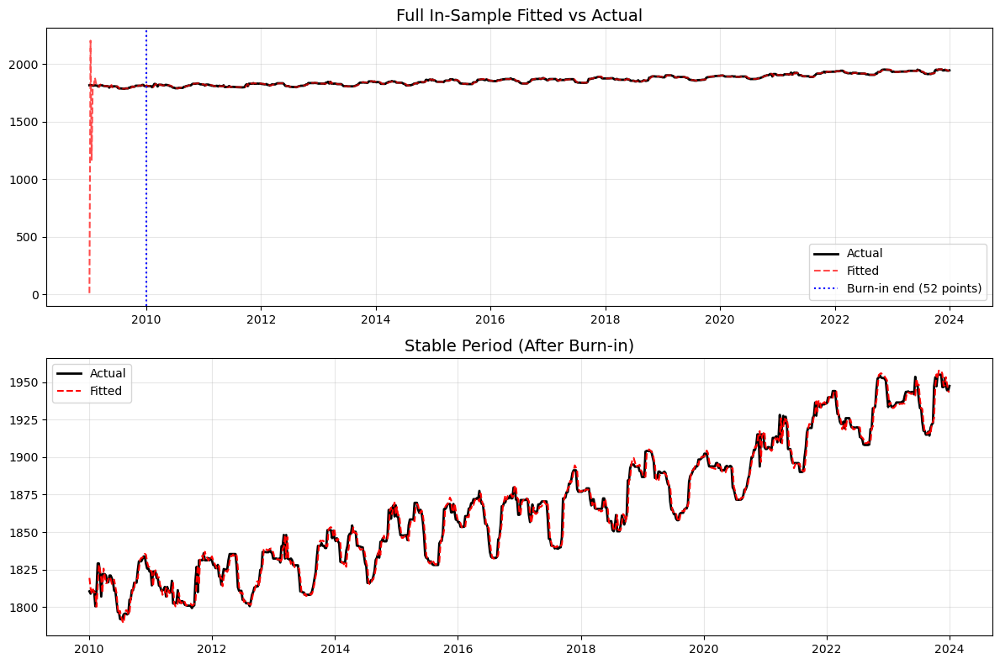

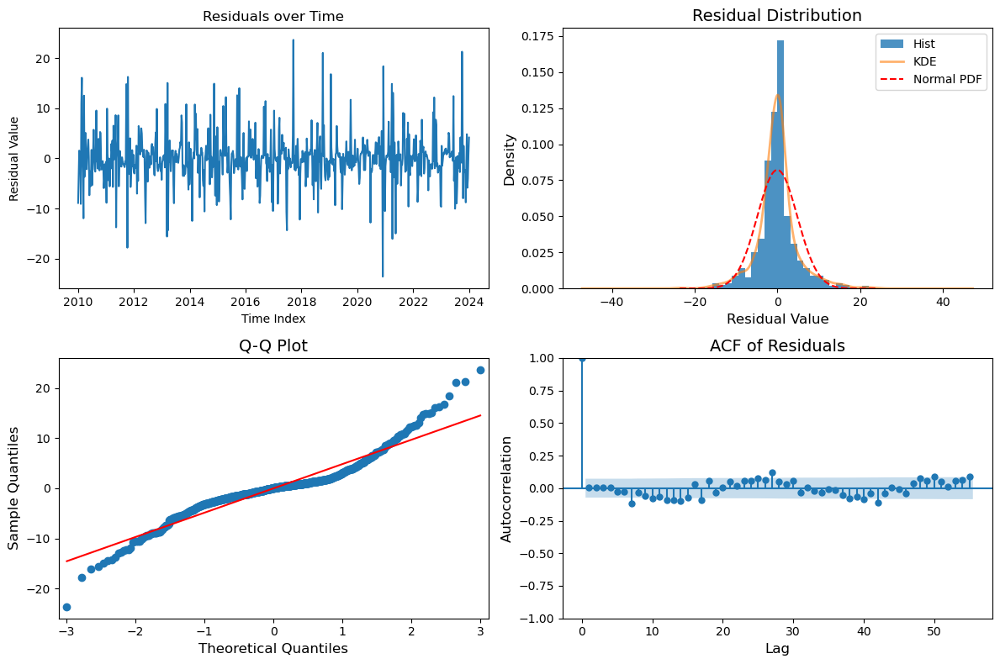


=== Residual Diagnostic Tests ===

--- Distribution Diagnostics ---
Jarque-Bera test:
	JB = 504.82
	p = 0.0000
	Skewness = 0.355
	kurtosis = 7.009

--- Autocorrelation Diagnostics ---
Ljung-Box Test:
(H0: No autocorrelation up to specified lags)
	lag 1: p = 0.9511
	lag 4: p = 0.9991
	lag 13: p = 0.0008
	lag 26: p = 0.0000
	lag 52: p = 0.0000

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0000***
	Lag 8: p-value = 0.0001***
	Lag 12: p-value = 0.0004***
	Lag 26: p-value = 0.0073***

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.7565
White: p = 0.6739

Testing periods: [52.1, 26.1]


C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Using 731 residuals for diagnostics (first 52 excluded as burn_in)

--- In-Sample Accuracy (after burn-in) ---
RMSE: 4.490
MAE:  3.115
MAPE: 0.17%
R2:   0.988


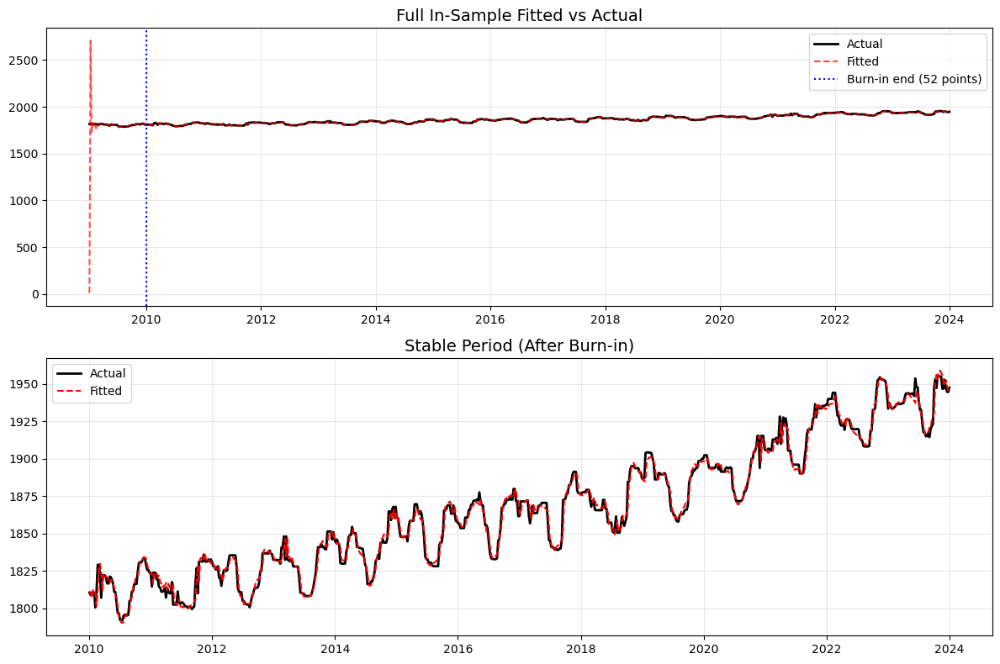

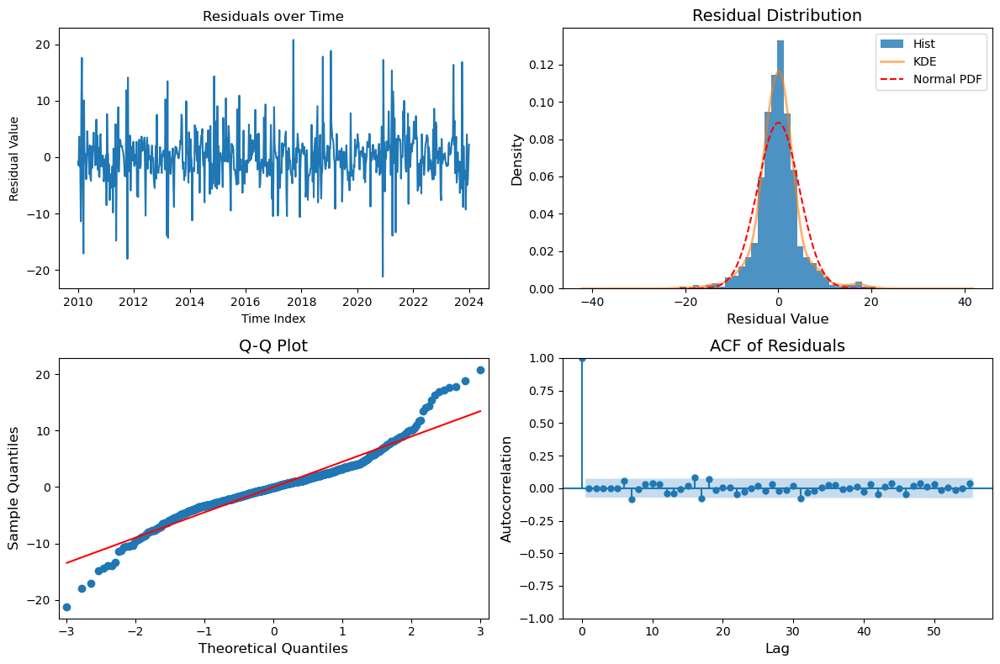


=== Residual Diagnostic Tests ===

--- Distribution Diagnostics ---
Jarque-Bera test:
	JB = 446.73
	p = 0.0000
	Skewness = 0.278
	kurtosis = 6.789

--- Autocorrelation Diagnostics ---
Ljung-Box Test:
(H0: No autocorrelation up to specified lags)
	lag 1: p = 0.9591
	lag 4: p = 1.0000
	lag 13: p = 0.4863
	lag 26: p = 0.3302
	lag 52: p = 0.7182

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0000***
	Lag 8: p-value = 0.0000***
	Lag 12: p-value = 0.0000***
	Lag 26: p-value = 0.0001***

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.7144
White: p = 0.3607

Testing periods: [52.1, 26.1, 17.8]
Using 731 residuals for diagnostics (first 52 excluded as burn_in)

--- In-Sample Accuracy (after burn-in) ---
RMSE: 4.478
MAE:  3.074
MAPE: 0.16%
R2:   0.989


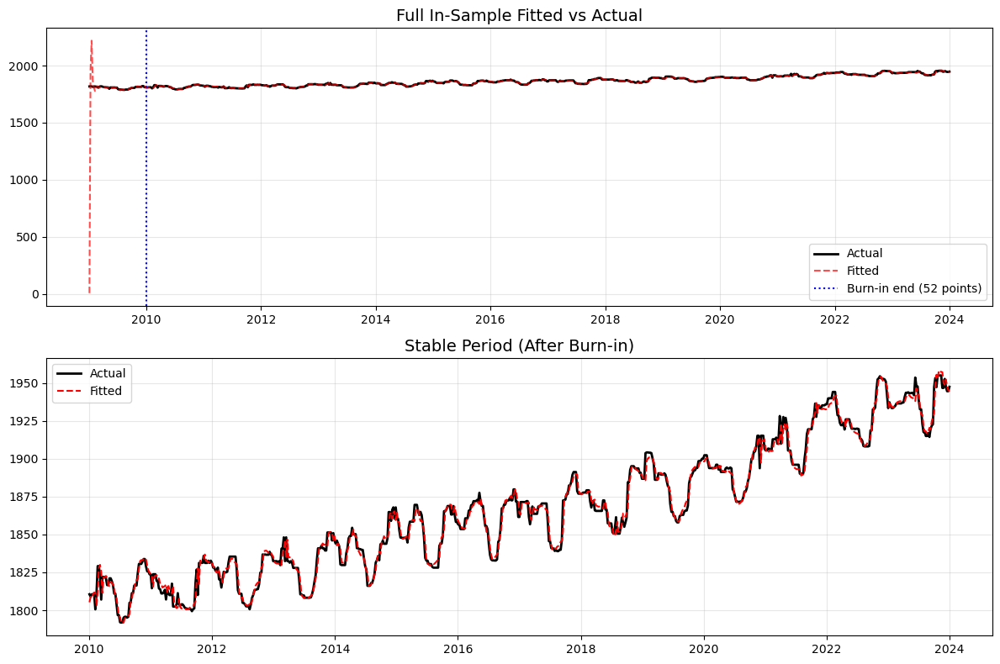

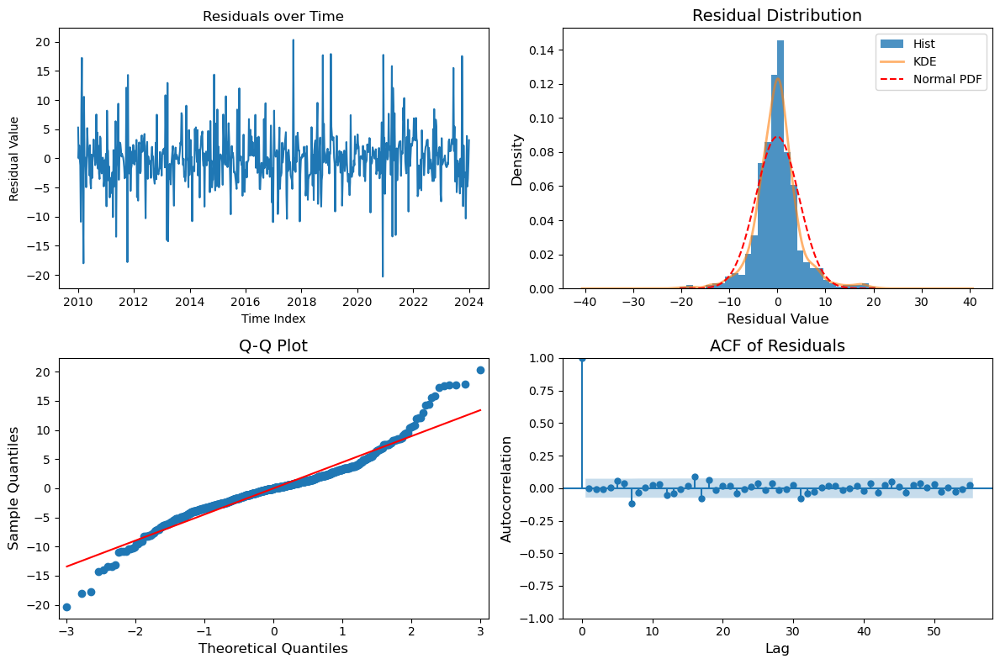


=== Residual Diagnostic Tests ===

--- Distribution Diagnostics ---
Jarque-Bera test:
	JB = 422.12
	p = 0.0000
	Skewness = 0.313
	kurtosis = 6.670

--- Autocorrelation Diagnostics ---
Ljung-Box Test:
(H0: No autocorrelation up to specified lags)
	lag 1: p = 0.9767
	lag 4: p = 0.9988
	lag 13: p = 0.1347
	lag 26: p = 0.1005
	lag 52: p = 0.4430

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0000***
	Lag 8: p-value = 0.0000***
	Lag 12: p-value = 0.0000***
	Lag 26: p-value = 0.0000***

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.6900
White: p = 0.2959

Testing periods: [52.1, 26.1, 17.8, 12.6]


C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Using 731 residuals for diagnostics (first 52 excluded as burn_in)

--- In-Sample Accuracy (after burn-in) ---
RMSE: 4.468
MAE:  3.078
MAPE: 0.16%
R2:   0.989


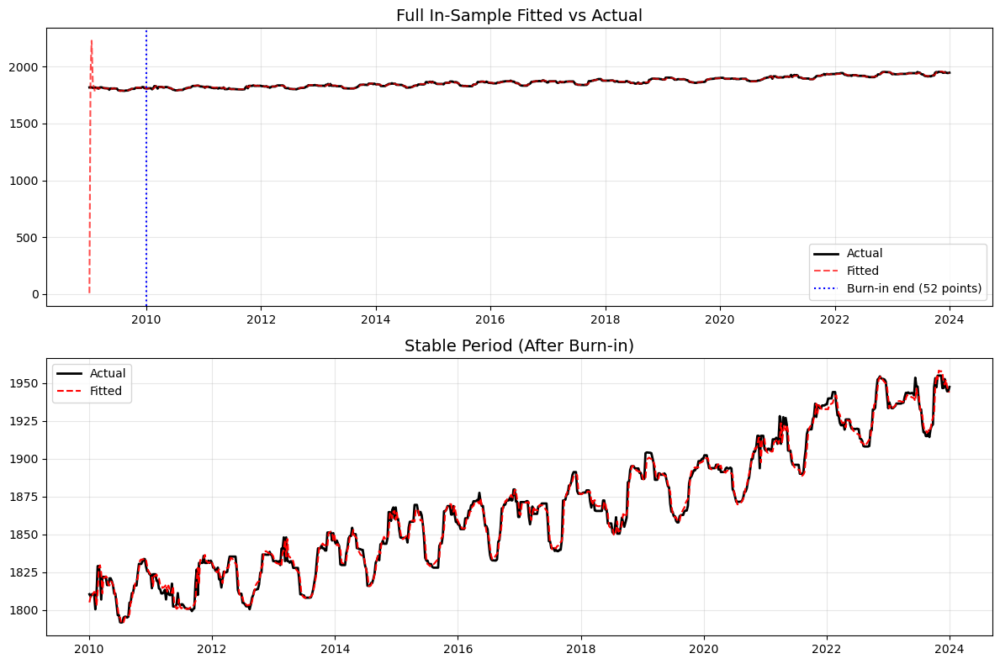

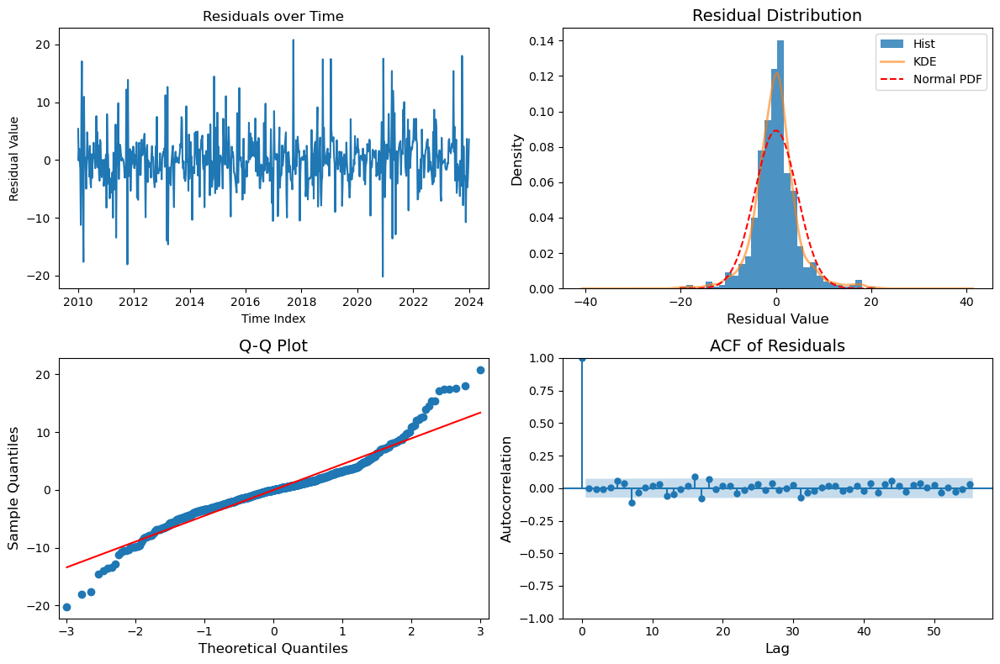


=== Residual Diagnostic Tests ===

--- Distribution Diagnostics ---
Jarque-Bera test:
	JB = 426.13
	p = 0.0000
	Skewness = 0.321
	kurtosis = 6.685

--- Autocorrelation Diagnostics ---
Ljung-Box Test:
(H0: No autocorrelation up to specified lags)
	lag 1: p = 0.9777
	lag 4: p = 0.9989
	lag 13: p = 0.1341
	lag 26: p = 0.0958
	lag 52: p = 0.4484

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0000***
	Lag 8: p-value = 0.0000***
	Lag 12: p-value = 0.0000***
	Lag 26: p-value = 0.0001***

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.7790
White: p = 0.2770

Testing periods: [52.1, 26.1, 17.8, 12.6, 8.8]


C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Using 731 residuals for diagnostics (first 52 excluded as burn_in)

--- In-Sample Accuracy (after burn-in) ---
RMSE: 4.424
MAE:  3.057
MAPE: 0.16%
R2:   0.989


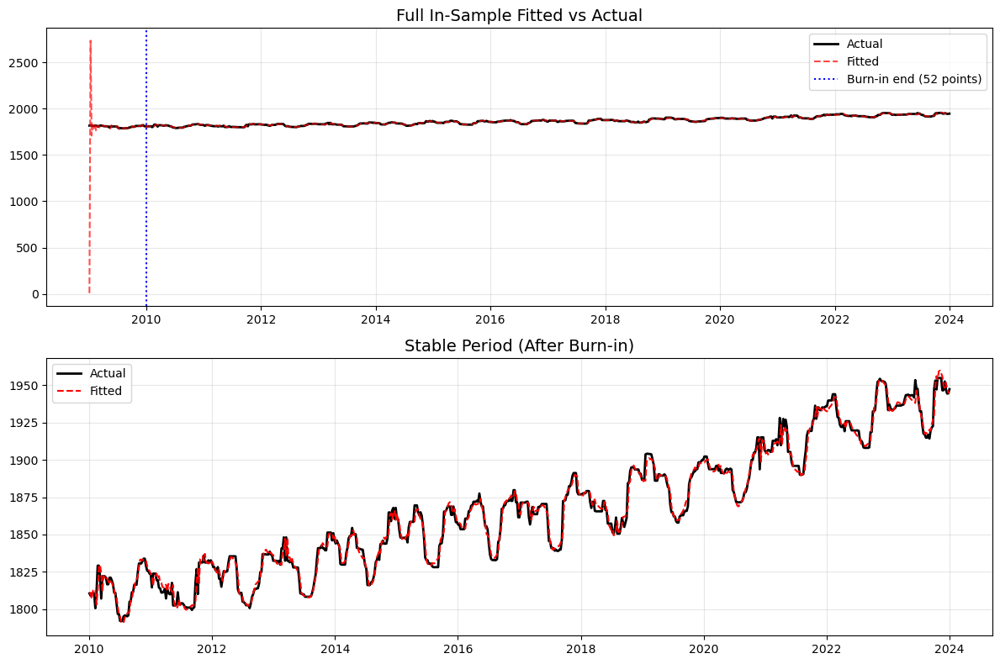

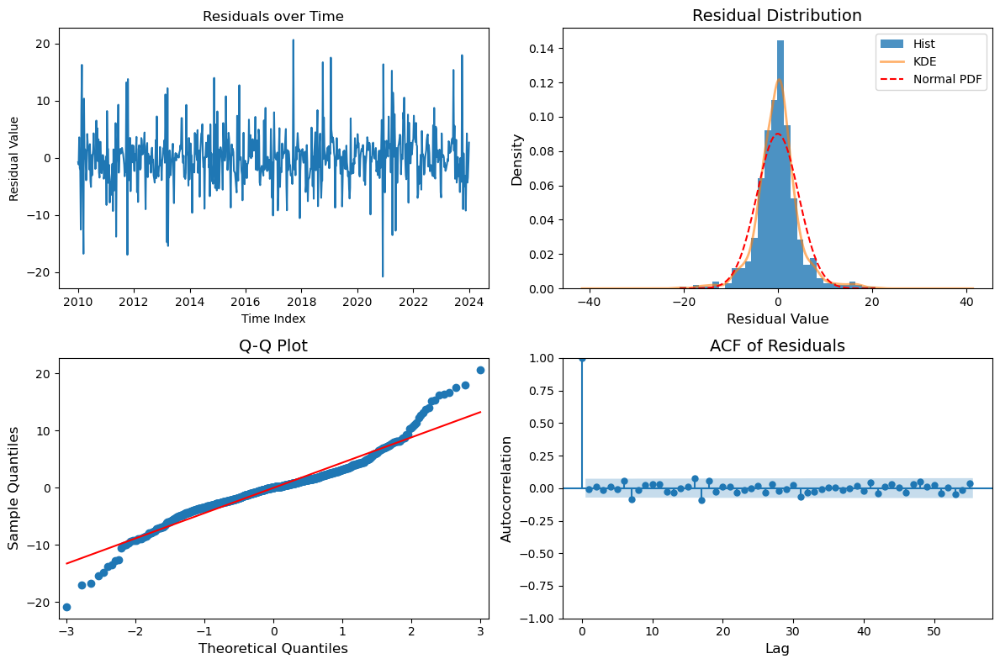


=== Residual Diagnostic Tests ===

--- Distribution Diagnostics ---
Jarque-Bera test:
	JB = 415.29
	p = 0.0000
	Skewness = 0.271
	kurtosis = 6.653

--- Autocorrelation Diagnostics ---
Ljung-Box Test:
(H0: No autocorrelation up to specified lags)
	lag 1: p = 0.8594
	lag 4: p = 0.9890
	lag 13: p = 0.5669
	lag 26: p = 0.4198
	lag 52: p = 0.8030

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0000***
	Lag 8: p-value = 0.0000***
	Lag 12: p-value = 0.0000***
	Lag 26: p-value = 0.0000***

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.7232
White: p = 0.2622


In [259]:
# SARIMA(6,1,2)(0,0,1,52)

period_combinations = [
    [52.1],                        # annual
    [52.1, 26.1],                  # annual + semi-annual
    [52.1, 26.1, 17.8],            # + ter-annual
    [52.1, 26.1, 17.8, 12.6],      # + quarterly
    [52.1, 26.1, 17.8, 12.6, 8.8], # + bi-monthly 
]

results_by_combo = {}
for i, periods in enumerate(period_combinations):
    print(f"\n{'=' * 50}")
    print(f"Testing periods: {periods}")

    exog_test = create_multi_period_fourier_terms(t, periods, index=train_recent15.index)

    results, residuals = in_sample_resid_analysis(
        train_recent15,
        order=(6,1,2),
        seasonal_order=(0,0,1,52),
        exog=exog_test,
        estimation_method='lbfgs',
        run_hetero=True
    )

    # store metrics
    results_by_combo[f"combo_{i}"] = {
        'periods': periods,
        'rmse': np.sqrt(mean_squared_error(train_recent15[52:], results.fittedvalues[52:])),
        'lb_pvals': acorr_ljungbox(residuals, lags=[1,4,13,26,52], return_df=True)['lb_pvalue'].tolist()
    }

## TimeSeriesSplit with multiple seasonal frequencies 

In [261]:
# Generate model parameters

def get_models_from_acf_pacf():
    '''Generate models based on d=1,D=1 ACF/PACF patterns'''
    models = []
    
    # non-seasonal orders based on PACF decay to lag 7
    for p in range(1, 8):
        # non-seasonal MA based on ACF
        for q in range(0, 4):
            models.append({
                'order': (p, 1, q),
                'seasonal_order': (0, 0, 1, 52)
                })
    return models

sarima_models = get_models_from_acf_pacf()
print(f'Generated {len(informed_models)} models for evaluation\n')

models_df = pd.DataFrame(sarima_models)
print(models_df)

Generated 56 models for evaluation

        order seasonal_order
0   (1, 1, 0)  (0, 0, 1, 52)
1   (1, 1, 1)  (0, 0, 1, 52)
2   (1, 1, 2)  (0, 0, 1, 52)
3   (1, 1, 3)  (0, 0, 1, 52)
4   (2, 1, 0)  (0, 0, 1, 52)
5   (2, 1, 1)  (0, 0, 1, 52)
6   (2, 1, 2)  (0, 0, 1, 52)
7   (2, 1, 3)  (0, 0, 1, 52)
8   (3, 1, 0)  (0, 0, 1, 52)
9   (3, 1, 1)  (0, 0, 1, 52)
10  (3, 1, 2)  (0, 0, 1, 52)
11  (3, 1, 3)  (0, 0, 1, 52)
12  (4, 1, 0)  (0, 0, 1, 52)
13  (4, 1, 1)  (0, 0, 1, 52)
14  (4, 1, 2)  (0, 0, 1, 52)
15  (4, 1, 3)  (0, 0, 1, 52)
16  (5, 1, 0)  (0, 0, 1, 52)
17  (5, 1, 1)  (0, 0, 1, 52)
18  (5, 1, 2)  (0, 0, 1, 52)
19  (5, 1, 3)  (0, 0, 1, 52)
20  (6, 1, 0)  (0, 0, 1, 52)
21  (6, 1, 1)  (0, 0, 1, 52)
22  (6, 1, 2)  (0, 0, 1, 52)
23  (6, 1, 3)  (0, 0, 1, 52)
24  (7, 1, 0)  (0, 0, 1, 52)
25  (7, 1, 1)  (0, 0, 1, 52)
26  (7, 1, 2)  (0, 0, 1, 52)
27  (7, 1, 3)  (0, 0, 1, 52)


In [262]:
# Create Fourier terms
critical_periods = [52.1, 26.1]  # weeks
K_settings = [1, 1]              # one harmonic each
t = np.arange(len(train_recent15))

exog_multi = create_multi_period_fourier_terms(
    t, 
    critical_periods, 
    K_settings,
    index=train_recent15.index
)

# Out-of-sample model evaluation
print('Starting model evaluation...')
candidate_model_results_df = evaluate_models_tscv(
    models_list=sarima_models,
    data=train_recent15,
    exog=exog_multi,
    burn_in_period=52
)

sorted_candidate_models_df = candidate_model_results_df.sort_values(by='RMSE_mean')
print('Candidate models for train_recent15 set sorted by RMSE mean')
print(sorted_candidate_models_df)

Starting model evaluation...
Evaluating 28 models with 5 folds each
Total iterations: 140

Fold 1: Train=510, Val=52
Fold 2: Train=562, Val=52
Fold 3: Train=614, Val=52
Fold 4: Train=666, Val=52
Fold 5: Train=718, Val=52



Models: 100%|██████████| 28/28 [4:18:14<00:00, 553.38s/it]   


Total duration: 258.24 minutes
Average per model: 9.22 minutes

Number of models successfully evaluated: 28
Candidate models for train_recent15 set sorted by RMSE mean
        order seasonal_order  successful_folds  convergence_rate  RMSE_mean  \
0   (1, 1, 0)  (0, 0, 1, 52)                 5               1.0  13.404872   
4   (2, 1, 0)  (0, 0, 1, 52)                 5               1.0  13.677754   
8   (3, 1, 0)  (0, 0, 1, 52)                 5               1.0  13.933938   
12  (4, 1, 0)  (0, 0, 1, 52)                 5               1.0  13.980224   
16  (5, 1, 0)  (0, 0, 1, 52)                 5               1.0  13.982033   
20  (6, 1, 0)  (0, 0, 1, 52)                 5               1.0  13.994964   
24  (7, 1, 0)  (0, 0, 1, 52)                 5               1.0  14.126198   
27  (7, 1, 3)  (0, 0, 1, 52)                 5               1.0  14.491248   
19  (5, 1, 3)  (0, 0, 1, 52)                 5               1.0  14.915476   
25  (7, 1, 1)  (0, 0, 1, 52)             

In [263]:
# Create Fourier terms
critical_periods = [52.1, 26.1, 17.8]  # weeks
K_settings = [1, 1, 1]                 # one harmonic each
t = np.arange(len(train_recent15))

exog_multi = create_multi_period_fourier_terms(
    t, 
    critical_periods, 
    K_settings,
    index=train_recent15.index
)

# Out-of-sample model evaluation
print('Starting model evaluation...')
candidate_model_results_df = evaluate_models_tscv(
    models_list=sarima_models,
    data=train_recent15,
    exog=exog_multi,
    burn_in_period=52
)

sorted_candidate_models_df = candidate_model_results_df.sort_values(by='RMSE_mean')
print('Candidate models for train_recent15 set sorted by RMSE mean')
print(sorted_candidate_models_df)

Starting model evaluation...
Evaluating 28 models with 5 folds each
Total iterations: 140

Fold 1: Train=510, Val=52
Fold 2: Train=562, Val=52
Fold 3: Train=614, Val=52
Fold 4: Train=666, Val=52
Fold 5: Train=718, Val=52



Models: 100%|██████████| 28/28 [5:50:44<00:00, 751.60s/it]   


Total duration: 350.74 minutes
Average per model: 12.53 minutes

Number of models successfully evaluated: 28
Candidate models for train_recent15 set sorted by RMSE mean
        order seasonal_order  successful_folds  convergence_rate  RMSE_mean  \
0   (1, 1, 0)  (0, 0, 1, 52)                 5               1.0  13.905324   
4   (2, 1, 0)  (0, 0, 1, 52)                 5               1.0  14.201351   
24  (7, 1, 0)  (0, 0, 1, 52)                 5               1.0  14.302393   
20  (6, 1, 0)  (0, 0, 1, 52)                 5               1.0  14.328824   
16  (5, 1, 0)  (0, 0, 1, 52)                 5               1.0  14.368523   
8   (3, 1, 0)  (0, 0, 1, 52)                 5               1.0  14.391763   
12  (4, 1, 0)  (0, 0, 1, 52)                 5               1.0  14.393946   
27  (7, 1, 3)  (0, 0, 1, 52)                 5               1.0  14.470667   
15  (4, 1, 3)  (0, 0, 1, 52)                 5               1.0  14.625104   
25  (7, 1, 1)  (0, 0, 1, 52)            

## TimeSeriesSplit with multiple seasonal frequencies (d=0, D=0)

In [420]:
# Generate model parametersm, where d = 0 and D = 0

def get_models_from_acf_pacf():
    '''Generate models based on d=1,D=1 ACF/PACF patterns'''
    models = []
    
    # non-seasonal orders based on PACF decay to lag 7
    for p in range(1, 8):
        # non-seasonal MA based on ACF
        for q in range(0, 3):
            # seasonal orders based on PACF decay to lag 7
            for P in range(0, 2):
                # non-seasonal MA based on ACF
                for Q in range(0, 3):
                    models.append({
                        'order': (p, 0, q),
                        'seasonal_order': (P, 0, Q, 52)
                        })
    return models

sarimad0D0_models = get_models_from_acf_pacf()
print(f'Generated {len(sarimad0D0_models)} models for evaluation\n')

models_df = pd.DataFrame(sarimad0D0_models)
print(models_df)

Generated 126 models for evaluation

         order seasonal_order
0    (1, 0, 0)  (0, 0, 0, 52)
1    (1, 0, 0)  (0, 0, 1, 52)
2    (1, 0, 0)  (0, 0, 2, 52)
3    (1, 0, 0)  (1, 0, 0, 52)
4    (1, 0, 0)  (1, 0, 1, 52)
..         ...            ...
121  (7, 0, 2)  (0, 0, 1, 52)
122  (7, 0, 2)  (0, 0, 2, 52)
123  (7, 0, 2)  (1, 0, 0, 52)
124  (7, 0, 2)  (1, 0, 1, 52)
125  (7, 0, 2)  (1, 0, 2, 52)

[126 rows x 2 columns]


In [421]:
# Create Fourier terms
critical_periods = [52.2, 26.1, 12.6]  # weeks
K_settings = [1, 1, 1]                 # one harmonic each
t = np.arange(len(train_recent15))

exog_multi = create_multi_period_fourier_terms(
    t, 
    critical_periods, 
    K_settings,
    index=train_recent15.index
)

# Out-of-sample model evaluation
print('Starting model evaluation...')
candidate_model_results_df = evaluate_models_tscv(
    models_list=sarimad0D0_models,
    data=train_recent15,
    exog=exog_multi,
    burn_in_period=52,
    estimation_method='powell'
)

sorted_candidate_models_df = candidate_model_results_df.sort_values(by='RMSE_mean')
print('Candidate models (d=0, D=0) for train_recent15 data sorted by RMSE mean')
print(sorted_candidate_models_df)

Starting model evaluation...
Evaluating 126 models with 5 folds each
Total iterations: 630

Fold 1: Train=510, Val=52
Fold 2: Train=562, Val=52
Fold 3: Train=614, Val=52
Fold 4: Train=666, Val=52
Fold 5: Train=718, Val=52



Models: 100%|██████████| 126/126 [28:24:04<00:00, 811.46s/it]   


Total duration: 1704.06 minutes
Average per model: 13.52 minutes

Number of models successfully evaluated: 126
Candidate models (d=0, D=0) for train_recent15 data sorted by RMSE mean
        order seasonal_order  successful_folds  convergence_rate  \
8   (1, 0, 1)  (0, 0, 2, 52)                 5               1.0   
2   (1, 0, 0)  (0, 0, 2, 52)                 5               1.0   
1   (1, 0, 0)  (0, 0, 1, 52)                 5               1.0   
14  (1, 0, 2)  (0, 0, 2, 52)                 5               1.0   
0   (1, 0, 0)  (0, 0, 0, 52)                 5               1.0   
..        ...            ...               ...               ...   
85  (5, 0, 2)  (0, 0, 1, 52)                 5               1.0   
70  (4, 0, 2)  (1, 0, 1, 52)                 5               1.0   
68  (4, 0, 2)  (0, 0, 2, 52)                 5               1.0   
66  (4, 0, 2)  (0, 0, 0, 52)                 5               1.0   
67  (4, 0, 2)  (0, 0, 1, 52)                 5               1.0   


## Select best K via expanding-window CV

In [550]:
def make_fourier_terms(index, period=52, K=4, t0=0):  # t0=0 is a global time index to anchor Fourier terms
    t = np.arange(t0, t0 + len(index))
    fourier = {}
    for k in range(1, K + 1):
        angle = 2 * np.pi * k * t / period
        fourier[f'sin_{k}'] = np.sin(angle)
        fourier[f'cos_{k}'] = np.cos(angle)
    return pd.DataFrame(fourier, index=index)

In [458]:
# CV function for a fixed K

def cv_score_for_K(
    y,
    K,
    order=(1, 0, 1),
    trend='t',
    period=52,
    n_splits=5,
    forecast_horizon=4
):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    rmses = []

    for train_idx, test_idx in tscv.split(y):
        y_train = y.iloc[train_idx]
        y_test  = y.iloc[test_idx][:forecast_horizon]

        t0 = train_idx[0]  # anchor phase to absolute time

        # Fourier terms — recomputed per fold
        if K > 0:
            exog_train = make_fourier_terms(y_train.index, period, K, t0=t0)
            exog_test  = make_fourier_terms(y_test.index, period, K, t0=t0 + len(y_train))
        else:
            exog_train = None
            exog_test  = None

        model = SARIMAX(
            y_train,
            order=order,
            seasonal_order=(0, 0, 0, 0),
            trend=trend,
            exog=exog_train,
            enforce_stationarity=True,
            enforce_invertibility=True
        )

        res = model.fit(disp=False)

        y_pred = res.forecast(
            steps=forecast_horizon,
            exog=exog_test
        )

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        rmses.append(rmse)

    return np.mean(rmses)

In [459]:
# Run K selection

K_candidates = range(0, 7)  # include K=0 baseline
scores = {}

for K in K_candidates:
    score = cv_score_for_K(
        y=train_recent15,
        K=K,
        order=(0, 0, 0),
        trend='t',
        period=52,
        n_splits=5
    )
    scores[K] = score
    print(f"K={K}: CV RMSE = {score:.3f}")

K=0: CV RMSE = 923.275
K=1: CV RMSE = 904.603
K=2: CV RMSE = 962.354
K=3: CV RMSE = 963.901
K=4: CV RMSE = 987.169
K=5: CV RMSE = 996.353
K=6: CV RMSE = 994.038


**Interpretation of the results**

This is purely an analysis of the deterministic trend.  Non-seasonal and seasonal stochastic parameters (p, q, P, and Q) are set to 0.  

K=1 is the best Fourier term value.  The magnitude of the values don't matter since I am not yet modeling any of the stochastic structure.  

In [497]:
# reuse the cv_score_for_K term to determine best p, q orders
# fix K = 1 based on above results

def cv_score_for_pq(
    y,
    order,
    K=1,
    trend='t',
    period=52,
    n_splits=5,
    forecast_horizon=4  # 4 is likely a better forecast horizon compared to 1 for atmospheric gas data
):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    rmses = []

    for train_idx, test_idx in tscv.split(y):
        y_train = y.iloc[train_idx]
        y_test  = y.iloc[test_idx][:forecast_horizon]

        t0 = train_idx[0]  # anchor phase to absolute time

        # Fourier terms — recomputed per fold
        if K > 0:
            exog_train = make_fourier_terms(y_train.index, period, K, t0=t0)
            exog_test  = make_fourier_terms(y_test.index, period, K, t0=t0 + len(y_train))
        else:
            exog_train = None
            exog_test  = None

        model = SARIMAX(
            y_train,
            order=order,
            seasonal_order=(0, 0, 0, 0),
            trend=trend,
            exog=exog_train,
            enforce_stationarity=True,
            enforce_invertibility=True,
        )

        res = model.fit(disp=False)

        y_pred = res.forecast(
            steps=forecast_horizon,
            exog=exog_test
        )

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        rmses.append(rmse)

    return np.mean(rmses)

In [498]:
# perform a grid search 

p_candidates = range(0, 4)
q_candidates = range(0, 4)

results = []

for p in p_candidates:
    for q in q_candidates:
        score = cv_score_for_pq(
            y=train_recent15,
            order=(p, 0, q),
            K=1,
            trend='t',
            period=52,
            n_splits=5,
            forecast_horizon=4
        )

        results.append({
            'p': p,
            'q': q,
            'rmse': score
        })

        print(f"(p,q)=({p},{q}): RMSE = {score:.3f}")

(p,q)=(0,0): RMSE = 904.603


C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


(p,q)=(0,1): RMSE = 809.133


C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\aplor\a

(p,q)=(0,2): RMSE = 731.757


...

(p,q)=(3,1): RMSE = 284943580870526.625


C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


(p,q)=(3,2): RMSE = 6251665503.569


C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


(p,q)=(3,3): RMSE = 13.158


In [509]:
results_df = pd.DataFrame(results).sort_values('rmse')
results_df

,p,q,rmse
12,3,0,5.867953e+00
4,1,0,7.670979e+00
5,1,1,7.971329e+00
10,2,2,9.774205e+00
9,2,1,9.956706e+00
6,1,2,9.986667e+00
11,2,3,1.085442e+01
15,3,3,1.315824e+01
7,1,3,2.845920e+01
3,0,3,6.024026e+02


In [551]:
# perform a grid search with forecast horizon = 1

p_candidates = range(0, 4)
q_candidates = range(0, 4)

results = []

for p in p_candidates:
    for q in q_candidates:
        score = cv_score_for_pq(
            y=train_recent15,
            order=(p, 0, q),
            K=1,
            trend='t',
            period=52,
            n_splits=5,
            forecast_horizon=1
        )

        results.append({
            'p': p,
            'q': q,
            'rmse': score
        })

        print(f"(p,q)=({p},{q}): RMSE = {score:.3f}")

(p,q)=(0,0): RMSE = 886.430


C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


(p,q)=(0,1): RMSE = 424.342


C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\aplor\a

(p,q)=(0,2): RMSE = 218.399


...

(p,q)=(3,1): RMSE = 284943580870509.688


C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


(p,q)=(3,2): RMSE = 6251665494.981


C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


(p,q)=(3,3): RMSE = 1.792


In [552]:
print('Expanding-window CV results with horizon = 1')
results_df = pd.DataFrame(results).sort_values('rmse')
results_df

Expanding-window CV results with horizon = 1


,p,q,rmse
11,2,3,8.753923e-01
10,2,2,1.425742e+00
4,1,0,1.426555e+00
9,2,1,1.596591e+00
5,1,1,1.759827e+00
15,3,3,1.792329e+00
6,1,2,2.642146e+00
12,3,0,3.407045e+00
7,1,3,5.614176e+00
3,0,3,9.128337e+01


C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Using 731 residuals for diagnostics (first 52 excluded as burn_in)

--- In-Sample Accuracy (after burn-in) ---
RMSE: 5.018
MAE:  3.416
MAPE: 0.18%
R2:   0.986


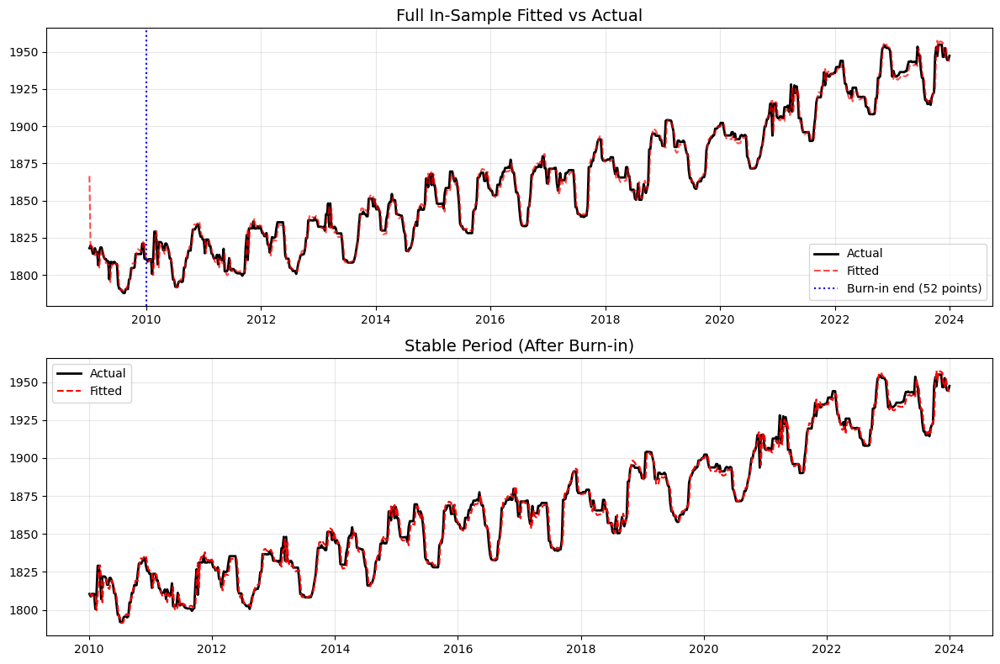

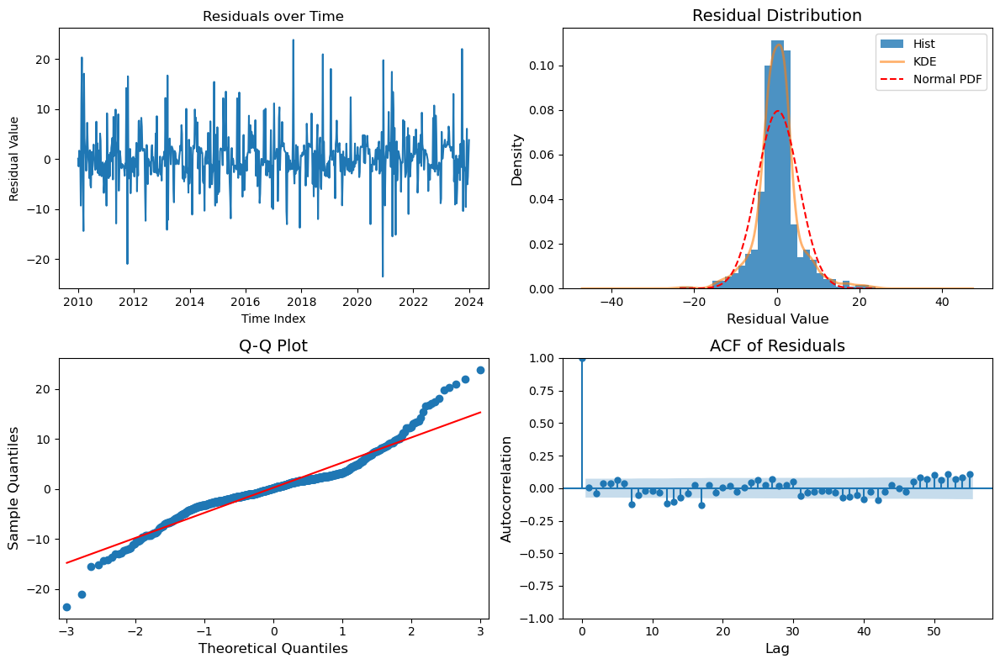


=== Residual Diagnostic Tests ===

--- Distribution Diagnostics ---
Jarque-Bera test:
	JB = 481.77
	p = 0.0000
	Skewness = 0.385
	kurtosis = 6.902

--- Autocorrelation Diagnostics ---
Ljung-Box Test:
(H0: No autocorrelation up to specified lags)
	lag 1: p = 0.9379
	lag 4: p = 0.5070
	lag 13: p = 0.0001
	lag 26: p = 0.0000
	lag 52: p = 0.0000

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0000***
	Lag 8: p-value = 0.0000***
	Lag 12: p-value = 0.0001***
	Lag 26: p-value = 0.0018***

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.6997
White: p = 0.5328


In [560]:
# residual diagnostics for the top model, SARIMAX(2,0,2)(0,0,0,0) + FT(K=1)

exog_train_K1 = make_fourier_terms(train_recent15.index, period=52, K=1)

candidate_model = in_sample_resid_analysis(
    train_recent15,
    order=(2,0,2),
    seasonal_order=(0,0,0,0),
    exog=exog_train_K1,
    estimation_method='lbfgs',
    burn_in_period=52,
    enforce_stationarity=True,
    enforce_invertibility=True,
    run_hetero=True
)

Using 731 residuals for diagnostics (first 52 excluded as burn_in)

--- In-Sample Accuracy (after burn-in) ---
RMSE: 4.951
MAE:  3.142
MAPE: 0.17%
R2:   0.986


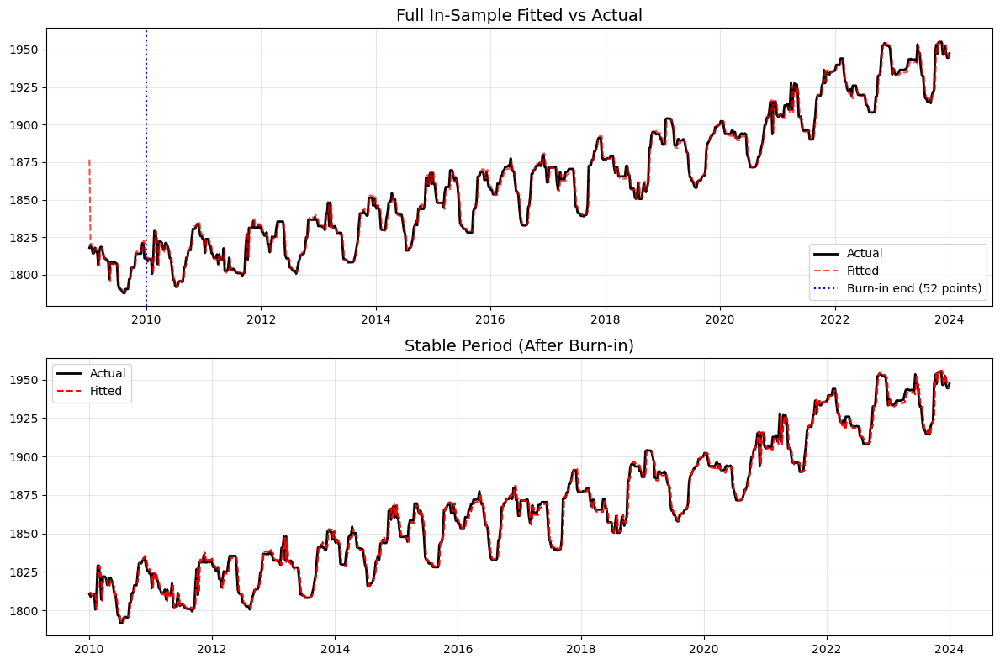

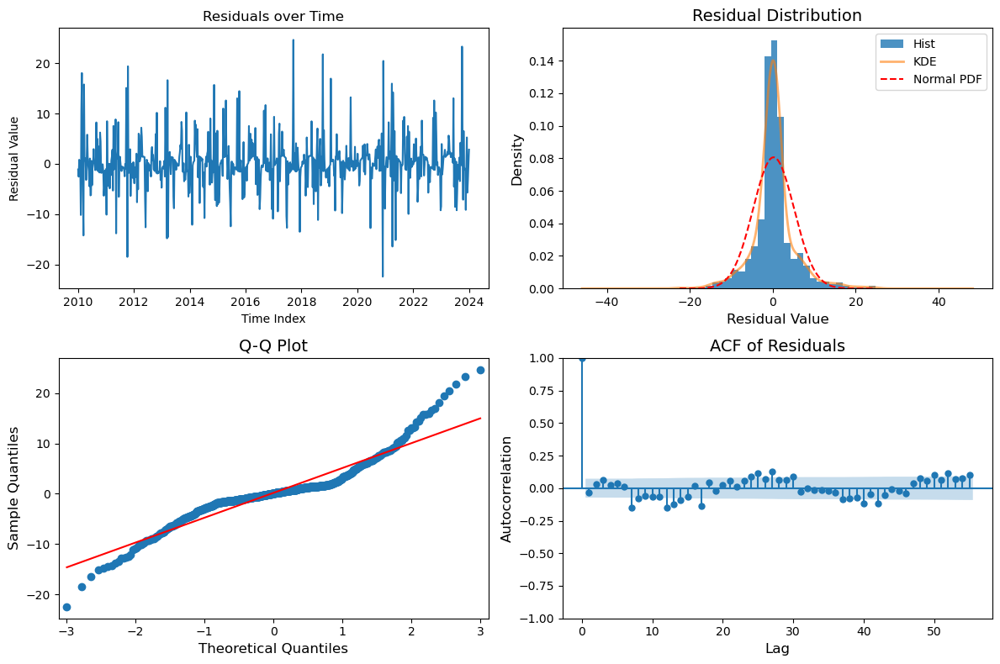


=== Residual Diagnostic Tests ===

--- Distribution Diagnostics ---
Jarque-Bera test:
	JB = 637.23
	p = 0.0000
	Skewness = 0.495
	kurtosis = 7.466

--- Autocorrelation Diagnostics ---
Ljung-Box Test:
(H0: No autocorrelation up to specified lags)
	lag 1: p = 0.3226
	lag 4: p = 0.2663
	lag 13: p = 0.0000
	lag 26: p = 0.0000
	lag 52: p = 0.0000

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0000***
	Lag 8: p-value = 0.0000***
	Lag 12: p-value = 0.0002***
	Lag 26: p-value = 0.0038***

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.7756
White: p = 0.6111


In [472]:
# residual diagnostics for the top model, SARIMAX(1,0,0)(0,0,0,0) + FT(K=1)

exog_train_K1 = make_fourier_terms(train_recent15.index, period=52, K=1)

candidate_model = in_sample_resid_analysis(
    train_recent15,
    order=(1,0,0),
    seasonal_order=(0,0,0,0),
    exog=exog_train_K1,
    estimation_method='lbfgs',
    burn_in_period=52,
    enforce_stationarity=True,
    enforce_invertibility=True,
    run_hetero=True
)

C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Using 731 residuals for diagnostics (first 52 excluded as burn_in)

--- In-Sample Accuracy (after burn-in) ---
RMSE: 4.725
MAE:  3.089
MAPE: 0.17%
R2:   0.987


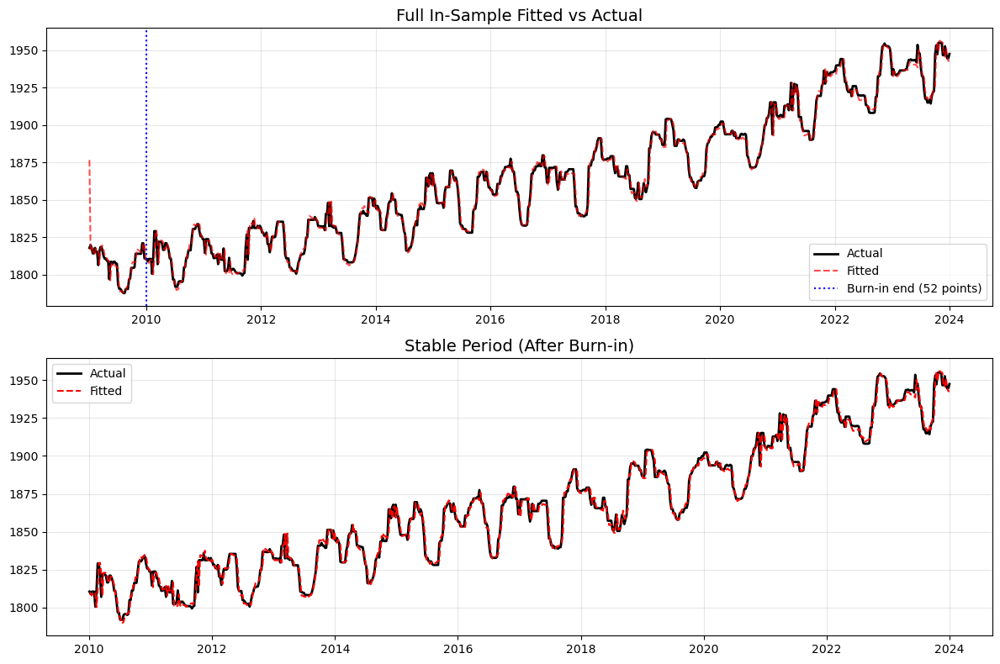

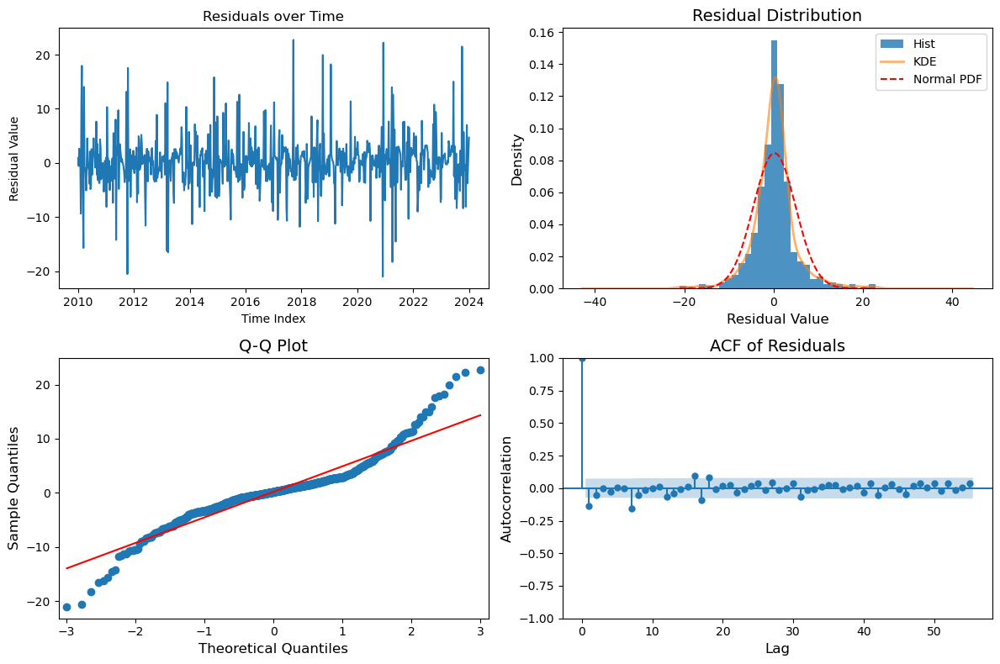


=== Residual Diagnostic Tests ===

--- Distribution Diagnostics ---
Jarque-Bera test:
	JB = 707.79
	p = 0.0000
	Skewness = 0.354
	kurtosis = 7.768

--- Autocorrelation Diagnostics ---
Ljung-Box Test:
(H0: No autocorrelation up to specified lags)
	lag 1: p = 0.0002
	lag 4: p = 0.0029
	lag 13: p = 0.0001
	lag 26: p = 0.0001
	lag 52: p = 0.0058

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0000***
	Lag 8: p-value = 0.0000***
	Lag 12: p-value = 0.0000***
	Lag 26: p-value = 0.0000***

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.7841
White: p = 0.4253


In [548]:
# residual diagnostics for the top model, SARIMAX(1,0,0)(0,0,0,0) + FT(K=2)

exog_train_K2 = make_fourier_terms(train_recent15.index, period=52, K=2)

candidate_model = in_sample_resid_analysis(
    train_recent15,
    order=(1,0,0),
    seasonal_order=(0,0,0,0),
    exog=exog_train_K2,
    estimation_method='lbfgs',
    burn_in_period=52,
    enforce_stationarity=True,
    enforce_invertibility=True,
    run_hetero=True
)

# SARIMAX out-of-sample analysis

## test d = 0, trend = 't'

The create_multi_period_fourier_terms may be incorrectly modeling the seasonal cycles as independent, fundamental cycles, whereas the FFT analysis may be indicating that the major cycles of 26.1 and 12.6  are sub-multiples (harmonics) of the annual cycle (52.2 weeks).  Modeling them as separate cycles could lead to multicollinearity and model instability if their frequencies are related.  

**Use make_fourier_terms function:** The FFT analysis showed sigificant periods corresponding to 1/1, 1/2, and 1/4 of the year.  I will try to model these cycles with Fourier terms with K=4 to capture the highest seasonal harmonic (1/4 or 12.6 weeks).  

K=4 would include K=3, which works out because the FFT analysis also indicates 17.8 weeks (tert-annual) is a significant cycle.  

In [531]:
exog_train_k1 = make_fourier_terms(
    index=train_recent15.index,
    period=52,
    K=1
)

exog_test_k1 = make_fourier_terms(
    index=test_preprocessed.index,
    period=52,
    K=1
)

exog_train_k4 = make_fourier_terms(
    index=train_recent15.index,
    period=52,
    K=4
)

exog_test_k4 = make_fourier_terms(
    index=test_preprocessed.index,
    period=52,
    K=4
)

=== Out-of-Sample Residual Analysis: SARIMA(1,0,0)(0,0,0,0) + FT(K=1) ===
Using estimation method: powell
Test set size: 52 observations

--- Out-of-Sample Forecast Accuracy ---
RMSE: 23.501
MAE:  18.168
MAPE: 0.93%
R²:   -1.147
95% CI coverage: 100.0% (ideal: 95%)


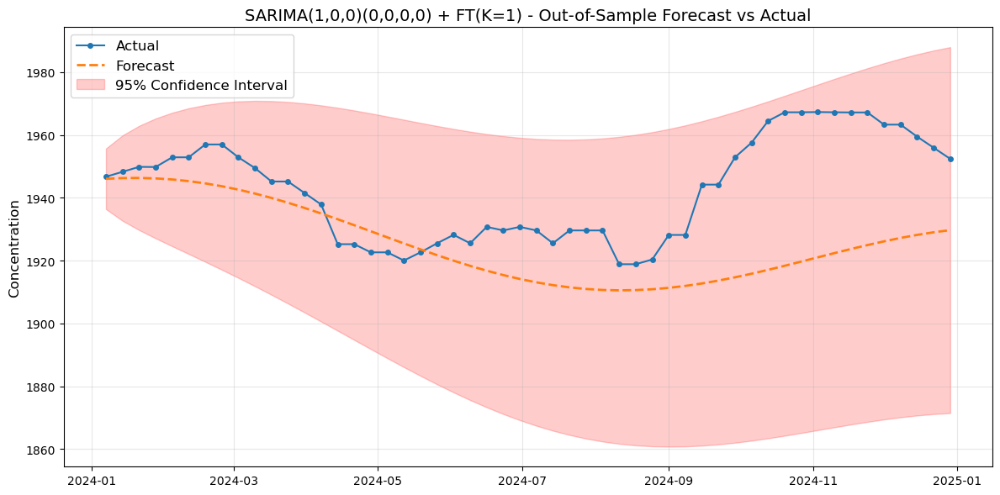


--- Residual Statistical Properties ---
Mean: 16.94409
Std:  16.44352
Skew: 0.569
Kurtosis: -0.793

--- Normality Tests ---
Shapiro-Wilk: p = 0.0021
Jarque-Bera:  p = 0.1257

--- Autocorrelation Diagnostics ---
Ljung-Box Test (H0: No autocorrelation)
  Lag  1: p = 0.0000 ***
  Lag  4: p = 0.0000 ***
  Lag 13: p = 0.0000 ***
  Lag 26: p = 0.0000 ***

"⚠"  Significant autocorrelation detected at lags: [1, 4, 13, 26]

--- Stationarity Check ---
ADF test on residuals: p = 0.3760
"⚠"  Residuals may not be stationary

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.0000
White test:    p = 0.0000
"⚠"  Possible heteroscedasticity

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0000***
	Lag 8: p-value = 0.0000***
	Lag 12: p-value = 0.0000***
	Lag 26: p-value = 0.0000***


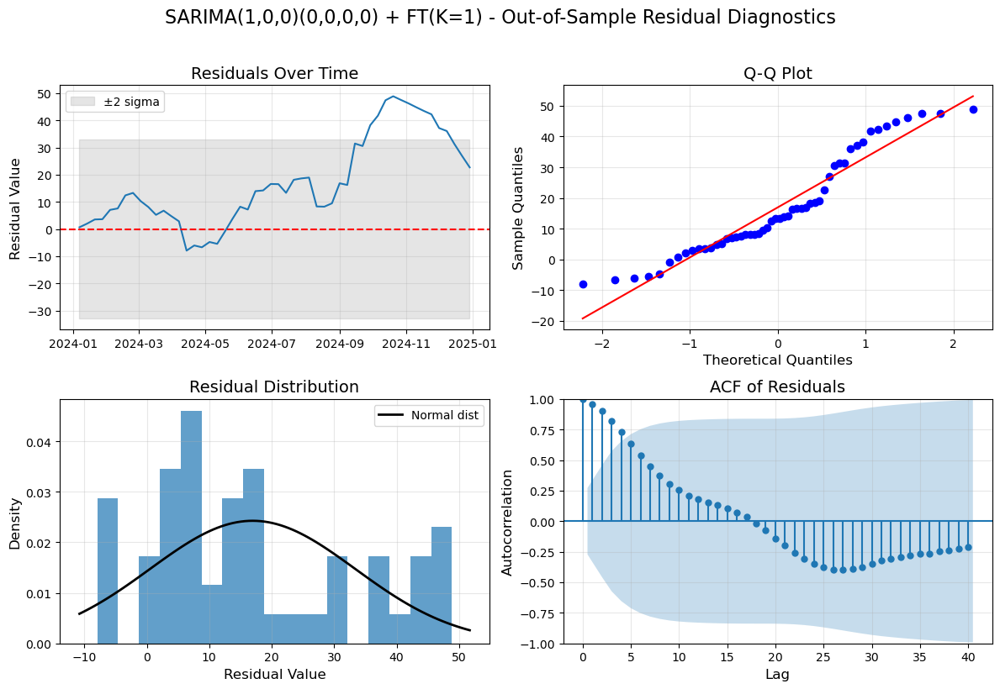

In [532]:
testset_resid_analysis = out_of_sample_resid_analysis(
    train_recent15,
    test_preprocessed,
    order=(1,0,0),
    seasonal_order=(0,0,0,0),
    exog_train=exog_train_k1,
    exog_test=exog_test_k1,
    trend='t',
    estimation_method='powell',
    model_name='SARIMA(1,0,0)(0,0,0,0) + FT(K=1)',
    run_hetero=True
)  

=== Out-of-Sample Residual Analysis: SARIMA(1,0,0)(0,0,0,0) + FT(K=4) ===
Using estimation method: powell
Test set size: 52 observations

--- Out-of-Sample Forecast Accuracy ---
RMSE: 33.596
MAE:  27.522
MAPE: 1.41%
R²:   -3.388
95% CI coverage: 73.1% (ideal: 95%)


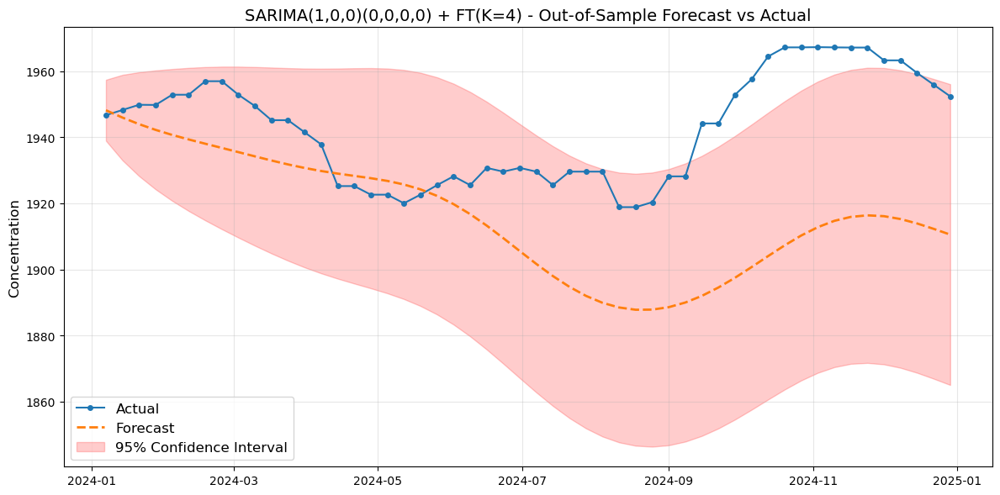


--- Residual Statistical Properties ---
Mean: 26.56971
Std:  20.76062
Skew: 0.053
Kurtosis: -1.341

--- Normality Tests ---
Shapiro-Wilk: p = 0.0078
Jarque-Bera:  p = 0.1458

--- Autocorrelation Diagnostics ---
Ljung-Box Test (H0: No autocorrelation)
  Lag  1: p = 0.0000 ***
  Lag  4: p = 0.0000 ***
  Lag 13: p = 0.0000 ***
  Lag 26: p = 0.0000 ***

"⚠"  Significant autocorrelation detected at lags: [1, 4, 13, 26]

--- Stationarity Check ---
ADF test on residuals: p = 0.6043
"⚠"  Residuals may not be stationary

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.0000
White test:    p = 0.0000
"⚠"  Possible heteroscedasticity

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0000***
	Lag 8: p-value = 0.0000***
	Lag 12: p-value = 0.0000***
	Lag 26: p-value = 0.0000***


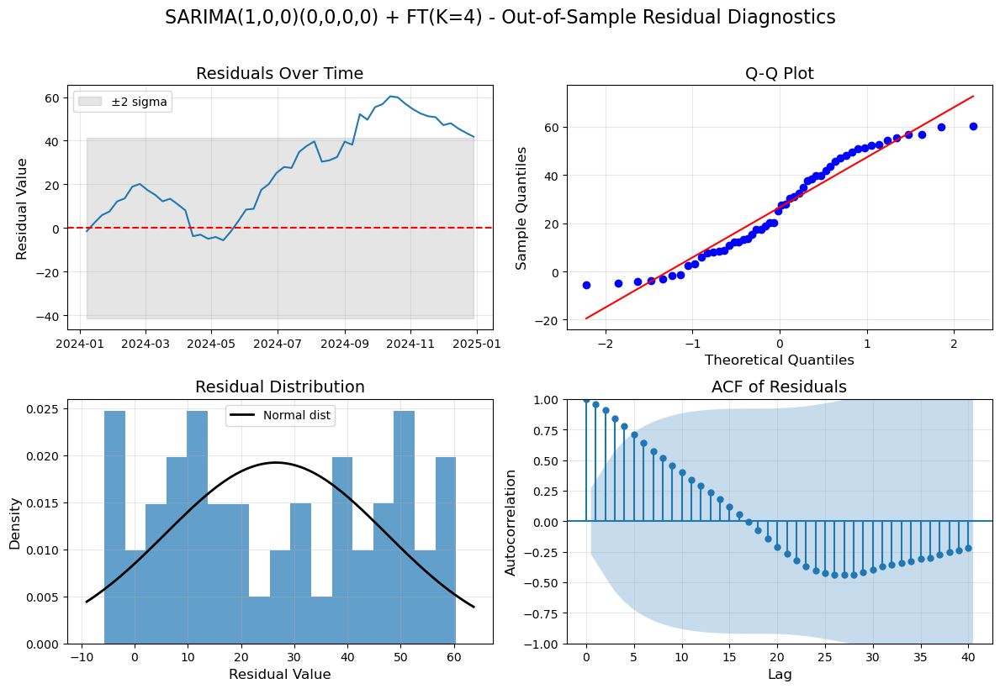

In [535]:
testset_resid_analysis = out_of_sample_resid_analysis(
    train_recent15,
    test_preprocessed,
    order=(1,0,0),
    seasonal_order=(0,0,0,0),
    exog_train=exog_train_k4,
    exog_test=exog_test_k4,
    trend='t',
    estimation_method='powell',
    model_name='SARIMA(1,0,0)(0,0,0,0) + FT(K=4)',
    run_hetero=True
)  

=== Out-of-Sample Residual Analysis: SARIMA(3,0,0)(0,0,0,0) + FT(K=4) ===
Using estimation method: powell
Test set size: 52 observations

--- Out-of-Sample Forecast Accuracy ---
RMSE: 64.764
MAE:  58.460
MAPE: 3.01%
R²:   -15.307
95% CI coverage: 61.5% (ideal: 95%)


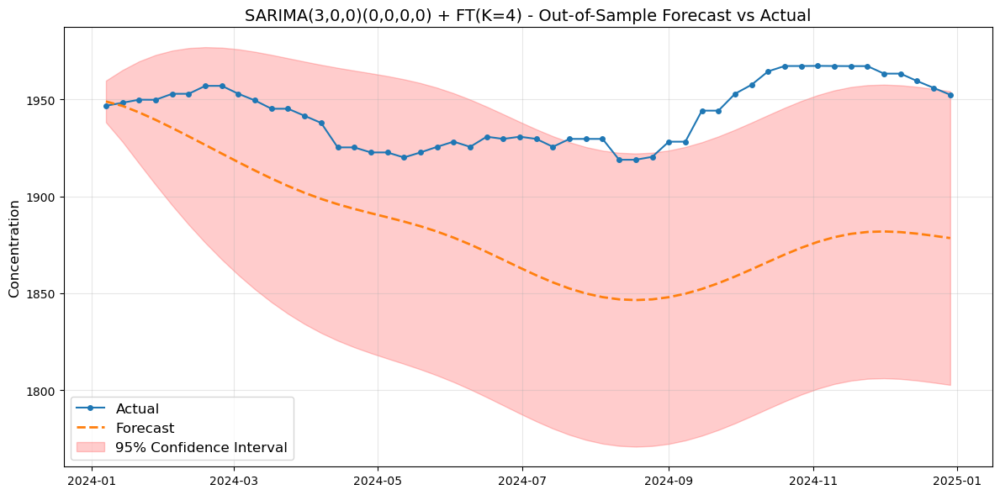


--- Residual Statistical Properties ---
Mean: 58.37469
Std:  28.32256
Skew: -0.388
Kurtosis: -1.028

--- Normality Tests ---
Shapiro-Wilk: p = 0.0035
Jarque-Bera:  p = 0.1657

--- Autocorrelation Diagnostics ---
Ljung-Box Test (H0: No autocorrelation)
  Lag  1: p = 0.0000 ***
  Lag  4: p = 0.0000 ***
  Lag 13: p = 0.0000 ***
  Lag 26: p = 0.0000 ***

"⚠"  Significant autocorrelation detected at lags: [1, 4, 13, 26]

--- Stationarity Check ---
ADF test on residuals: p = 0.3167
"⚠"  Residuals may not be stationary

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.0000
White test:    p = 0.0000
"⚠"  Possible heteroscedasticity

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0000***
	Lag 8: p-value = 0.0000***
	Lag 12: p-value = 0.0000***
	Lag 26: p-value = 0.0000***


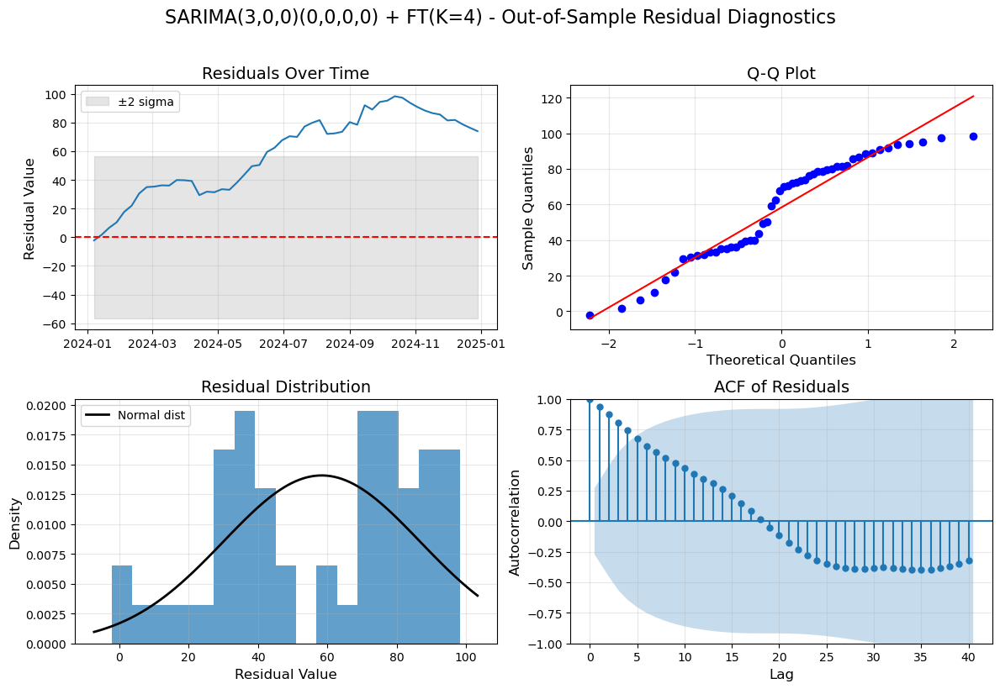

In [534]:
testset_resid_analysis = out_of_sample_resid_analysis(
    train_recent15,
    test_preprocessed,
    order=(3,0,0),
    seasonal_order=(0,0,0,0),
    exog_train=exog_train_k4,
    exog_test=exog_test_k4,
    trend='t',
    estimation_method='powell',
    model_name='SARIMA(3,0,0)(0,0,0,0) + FT(K=4)',
    run_hetero=True
)  

In [422]:
from statsmodels.tsa.statespace.structural import UnobservedComponents

# State space model with multiple error components
model_uc = UnobservedComponents(
    endog=train_recent15,
    level='local linear trend',  # Stochastic trend (not deterministic)
    seasonal=52,  # Stochastic seasonality (not Fourier)
    irregular=True,  # Measurement error
    stochastic_level=True,
    stochastic_trend=True,
    stochastic_seasonal=True,
    freq='W'
)

results_uc = model_uc.fit(method='lbfgs', disp=False)
print(results_uc.summary())

# Check residuals - should be MUCH better
residuals_uc = results_uc.resid
acorr_ljungbox(residuals_uc, lags=[1,4,13,26,52], return_df=True)

C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\tsa\statespace\structural.py:426: SpecificationWarning: Value of `irregular` may be overridden when the trend component is specified using a model string.
  warn("Value of `%s` may be overridden when the trend"
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\tsa\statespace\structural.py:426: SpecificationWarning: Value of `stochastic_level` may be overridden when the trend component is specified using a model string.
  warn("Value of `%s` may be overridden when the trend"
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\tsa\statespace\structural.py:426: SpecificationWarning: Value of `stochastic_trend` may be overridden when the trend component is specified using a model string.
  warn("Value of `%s` may be overridden when the trend"


                            Unobserved Components Results                            
Dep. Variable:              CH4_preprocessed   No. Observations:                  783
Model:                    local linear trend   Log Likelihood               -2217.092
                   + stochastic seasonal(52)   AIC                           4442.185
Date:                       Sat, 13 Dec 2025   BIC                           4460.557
Time:                               18:24:11   HQIC                          4449.273
Sample:                           01-04-2009                                         
                                - 12-31-2023                                         
Covariance Type:                         opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
sigma2.irregular     2.9393      0.665      4.420      0

,lb_stat,lb_pvalue
1,387.962003,2.299082e-86
4,450.563603,3.281001e-96
13,456.707119,2.243743e-89
26,457.488187,2.055213e-80
52,466.685068,5.233543e-68


In [423]:
def sanity_check_sarima():
    """Test if SARIMA works on synthetic data with your code"""
    # Create synthetic ARIMA(1,1,1) data
    np.random.seed(42)
    n = 1000
    synth_data = np.zeros(n)
    
    # ARIMA(1,1,1) process
    for t in range(2, n):
        synth_data[t] = (0.7 * (synth_data[t-1] - synth_data[t-2]) + 
                        0.3 * np.random.randn() + 
                        synth_data[t-1])
    
    synth_series = pd.Series(synth_data[200:], index=range(len(synth_data[200:])))
    
    # Split
    train_synth = synth_series[:-100]
    test_synth = synth_series[-100:]
    
    # Fit SARIMA(1,1,1) - should be perfect
    model = SARIMAX(train_synth, order=(1,1,1), trend='c')
    results = model.fit(method='lbfgs', disp=False)
    
    # Check residuals
    residuals = results.resid[50:]  # Burn-in
    lb_test = acorr_ljungbox(residuals, lags=[1,5,10], return_df=True)
    
    print("Synthetic ARIMA(1,1,1) test:")
    print(f"Ljung-Box p-values: {lb_test['lb_pvalue'].values}")
    print(f"All p > 0.05? {all(lb_test['lb_pvalue'] > 0.05)}")
    
    # Forecast
    forecast = results.get_forecast(steps=100)
    rmse = np.sqrt(mean_squared_error(test_synth, forecast.predicted_mean))
    print(f"Forecast RMSE: {rmse:.4f} (should be low)")
    
    return results

sanity_results = sanity_check_sarima()

Synthetic ARIMA(1,1,1) test:
Ljung-Box p-values: [0.87983473 0.82296509 0.85916666]
All p > 0.05? True
Forecast RMSE: 4.1402 (should be low)


In [424]:
def check_data_issues(series):
    """Check for common time series problems"""
    issues = []
    
    # 1. Missing values
    if series.isna().any():
        issues.append(f"Missing values: {series.isna().sum()}")
    
    # 2. Duplicate indices
    if series.index.duplicated().any():
        issues.append(f"Duplicate indices: {series.index.duplicated().sum()}")
    
    # 3. Irregular spacing
    if hasattr(series.index, 'diff'):
        gaps = series.index.to_series().diff()
        if (gaps > gaps.median() * 1.5).any():
            issues.append("Irregular time spacing")
    
    # 4. Outliers (beyond 4 std)
    z_scores = np.abs((series - series.mean()) / series.std())
    if (z_scores > 4).any():
        issues.append(f"Outliers: {(z_scores > 4).sum()} points > 4 std")
    
    # 5. Structural breaks
    # Use Chow test or visual inspection
    if len(series) > 100:
        mid = len(series) // 2
        mean1, mean2 = series[:mid].mean(), series[mid:].mean()
        if abs(mean1 - mean2) > 2 * series.std():
            issues.append(f"Possible structural break (means: {mean1:.1f} vs {mean2:.1f})")
    
    return issues

issues = check_data_issues(train_recent15)
print("Data issues found:", issues if issues else "None")

Data issues found: None


=== Out-of-Sample Residual Analysis: SARIMA(7,1,1)(2,0,0,52) ===
Test set size: 52 observations

--- Out-of-Sample Forecast Accuracy ---
RMSE: 14.739
MAE:  12.609
MAPE: 0.65%
R²:   0.155
95% CI coverage: 100.0% (ideal: 95%)


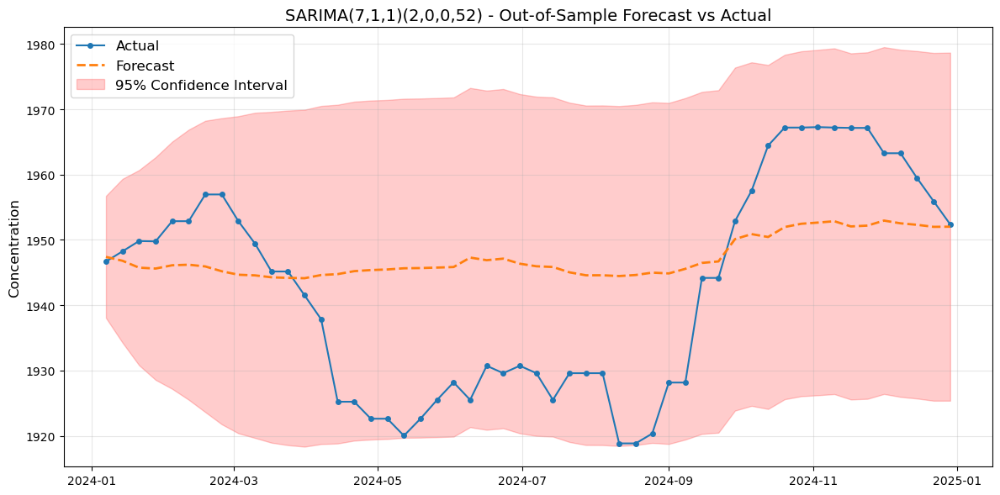


--- Residual Statistical Properties ---
Mean: -4.70140
Std:  14.10558
Skew: -0.073
Kurtosis: -1.552

--- Normality Tests ---
Shapiro-Wilk: p = 0.0003
Jarque-Bera:  p = 0.0801

--- Autocorrelation Diagnostics ---
Ljung-Box Test (H0: No autocorrelation)
  Lag  1: p = 0.0000 ***
  Lag  4: p = 0.0000 ***
  Lag 13: p = 0.0000 ***
  Lag 26: p = 0.0000 ***

"⚠"  Significant autocorrelation detected at lags: [1, 4, 13, 26]

--- Stationarity Check ---
ADF test on residuals: p = 0.1190
"⚠"  Residuals may not be stationary

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.5779
White test:    p = 0.0000
"✅" Constant variance

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0000***
	Lag 8: p-value = 0.0000***
	Lag 12: p-value = 0.0000***
	Lag 26: p-value = 0.0000***


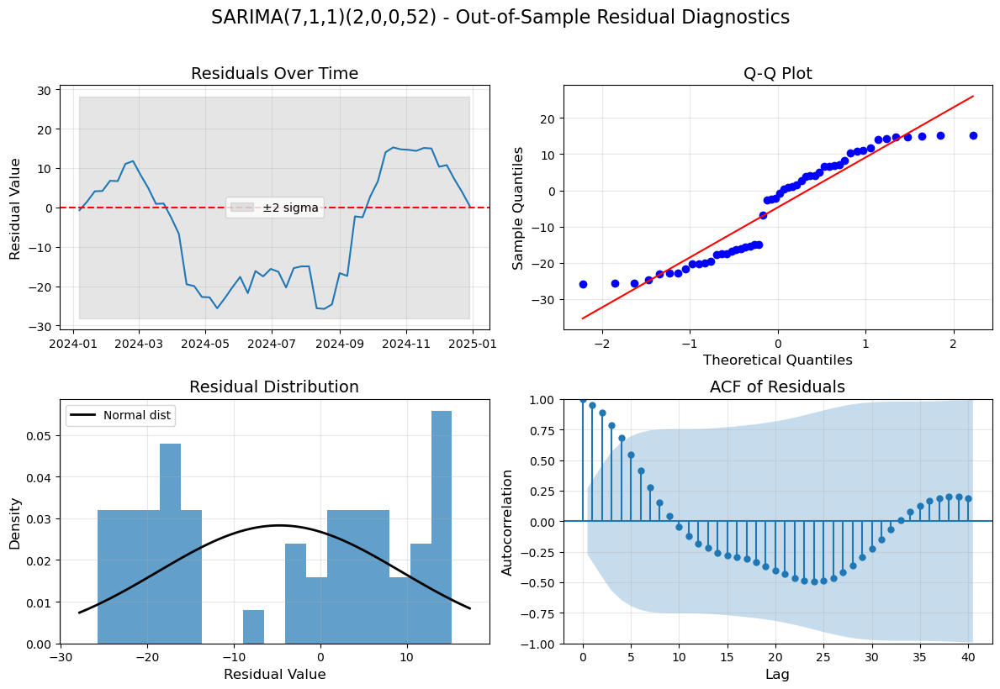

In [122]:
testset_resid_analysis = out_of_sample_resid_analysis(
    train_recent15,
    test_preprocessed,
    order=(7,1,1),
    seasonal_order=(2,0,0,52),
    #exog_train=exog_train,
    #exog_test=exog_test,
    model_name='SARIMA(7,1,1)(2,0,0,52)',
    run_hetero=True
)  

=== Out-of-Sample Residual Analysis: SARIMA(7,1,1)(1,0,1,52) ===
Test set size: 52 observations



C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


--- Out-of-Sample Forecast Accuracy ---
RMSE: 11.520
MAE:  8.668
MAPE: 0.45%
R²:   0.484
95% CI coverage: 96.2% (ideal: 95%)


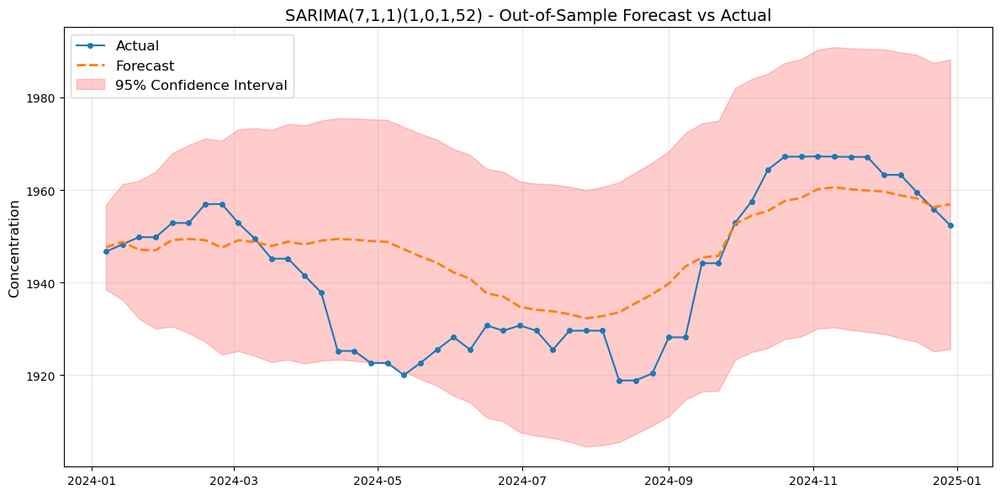


--- Residual Statistical Properties ---
Mean: -4.73619
Std:  10.60339
Skew: -0.661
Kurtosis: -0.571

--- Normality Tests ---
Shapiro-Wilk: p = 0.0028
Jarque-Bera:  p = 0.1093

--- Autocorrelation Diagnostics ---
Ljung-Box Test (H0: No autocorrelation)
  Lag  1: p = 0.0000 ***
  Lag  4: p = 0.0000 ***
  Lag 13: p = 0.0000 ***
  Lag 26: p = 0.0000 ***

"⚠"  Significant autocorrelation detected at lags: [1, 4, 13, 26]

--- Stationarity Check ---
ADF test on residuals: p = 0.0505
"⚠"  Residuals may not be stationary

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.2213
White test:    p = 0.0052
"✅" Constant variance

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0000***
	Lag 8: p-value = 0.0000***
	Lag 12: p-value = 0.0000***
	Lag 26: p-value = 0.0000***


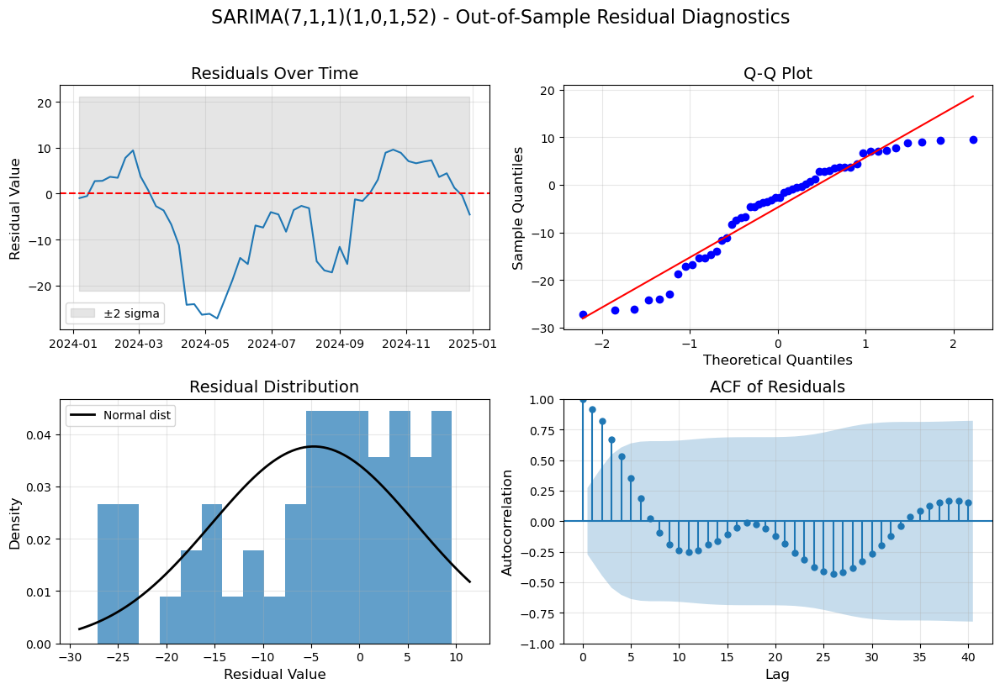

In [123]:
testset_resid_analysis = out_of_sample_resid_analysis(
    train_recent15,
    test_preprocessed,
    order=(7,1,1),
    seasonal_order=(1,0,1,52),
    #exog_train=exog_train,
    #exog_test=exog_test,
    model_name='SARIMA(7,1,1)(1,0,1,52)',
    run_hetero=True
)  

=== Out-of-Sample Residual Analysis: SARIMA(7,1,1)(2,0,1,52) ===
Test set size: 52 observations



C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


--- Out-of-Sample Forecast Accuracy ---
RMSE: 11.372
MAE:  8.535
MAPE: 0.44%
R²:   0.497
95% CI coverage: 94.2% (ideal: 95%)


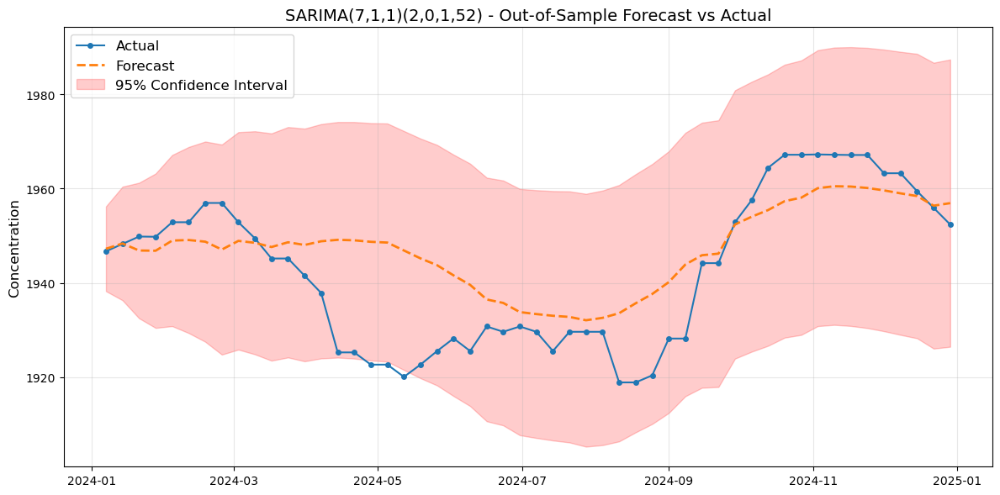


--- Residual Statistical Properties ---
Mean: -4.49387
Std:  10.54885
Skew: -0.676
Kurtosis: -0.547

--- Normality Tests ---
Shapiro-Wilk: p = 0.0025
Jarque-Bera:  p = 0.1037

--- Autocorrelation Diagnostics ---
Ljung-Box Test (H0: No autocorrelation)
  Lag  1: p = 0.0000 ***
  Lag  4: p = 0.0000 ***
  Lag 13: p = 0.0000 ***
  Lag 26: p = 0.0000 ***

"⚠"  Significant autocorrelation detected at lags: [1, 4, 13, 26]

--- Stationarity Check ---
ADF test on residuals: p = 0.0398
"✅" Residuals are stationary

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.2316
White test:    p = 0.0067
"✅" Constant variance

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0000***
	Lag 8: p-value = 0.0000***
	Lag 12: p-value = 0.0000***
	Lag 26: p-value = 0.0000***


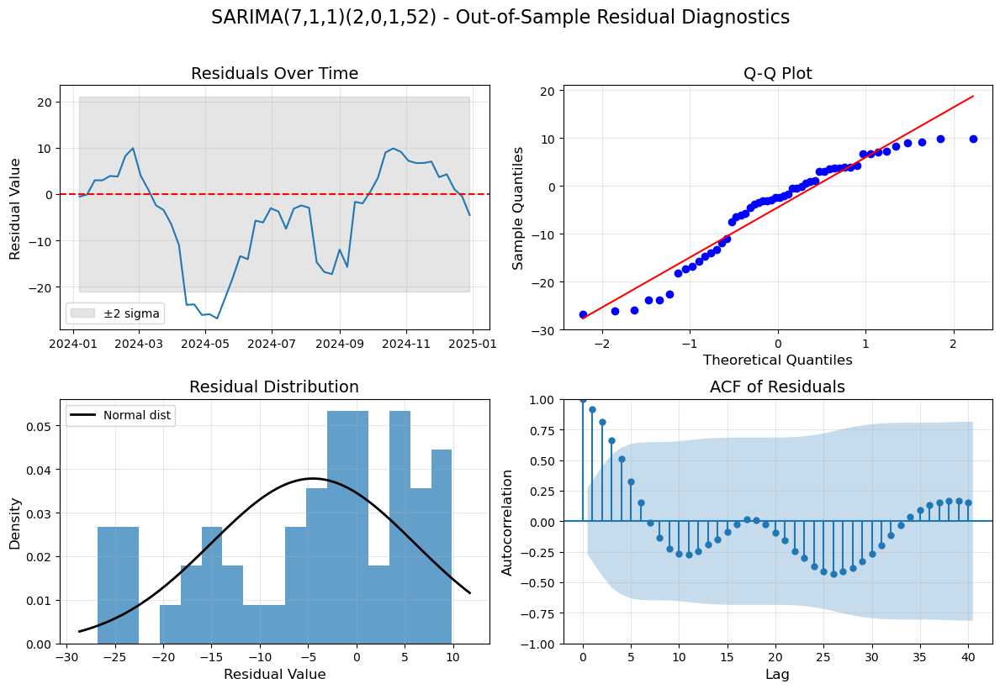

In [124]:
testset_resid_analysis = out_of_sample_resid_analysis(
    train_recent15,
    test_preprocessed,
    order=(7,1,1),
    seasonal_order=(2,0,1,52),
    #exog_train=exog_train,
    #exog_test=exog_test,
    model_name='SARIMA(7,1,1)(2,0,1,52)',
    run_hetero=True
)  

=== Out-of-Sample Residual Analysis: SARIMA(7,1,0)(2,0,2,52) ===
Test set size: 52 observations

--- Out-of-Sample Forecast Accuracy ---
RMSE: 10.742
MAE:  7.737
MAPE: 0.40%
R²:   0.551
95% CI coverage: 94.2% (ideal: 95%)


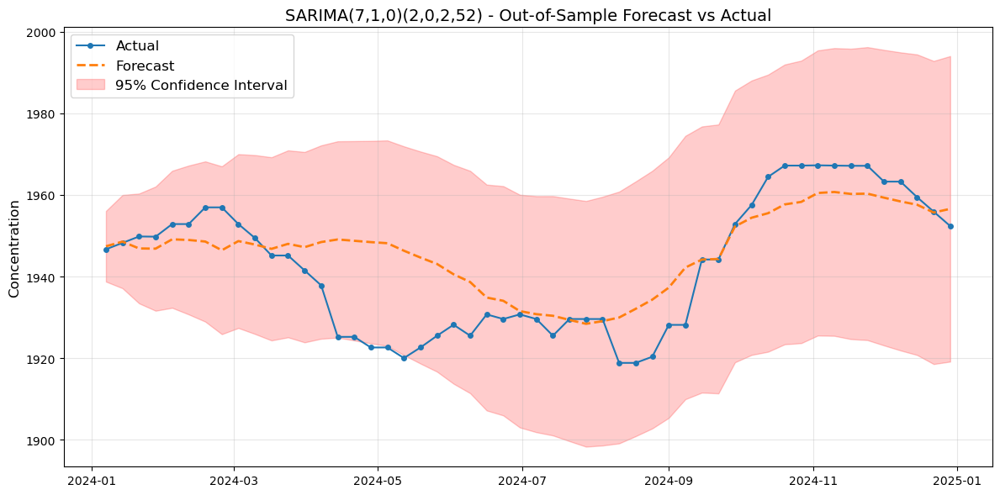


--- Residual Statistical Properties ---
Mean: -3.54799
Std:  10.23833
Skew: -0.871
Kurtosis: -0.181

--- Normality Tests ---
Shapiro-Wilk: p = 0.0004
Jarque-Bera:  p = 0.0415

--- Autocorrelation Diagnostics ---
Ljung-Box Test (H0: No autocorrelation)
  Lag  1: p = 0.0000 ***
  Lag  4: p = 0.0000 ***
  Lag 13: p = 0.0000 ***
  Lag 26: p = 0.0000 ***

"⚠"  Significant autocorrelation detected at lags: [1, 4, 13, 26]

--- Stationarity Check ---
ADF test on residuals: p = 0.0365
"✅" Residuals are stationary

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.1770
White test:    p = 0.0146
"✅" Constant variance

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0000***
	Lag 8: p-value = 0.0000***
	Lag 12: p-value = 0.0000***
	Lag 26: p-value = 0.0000***


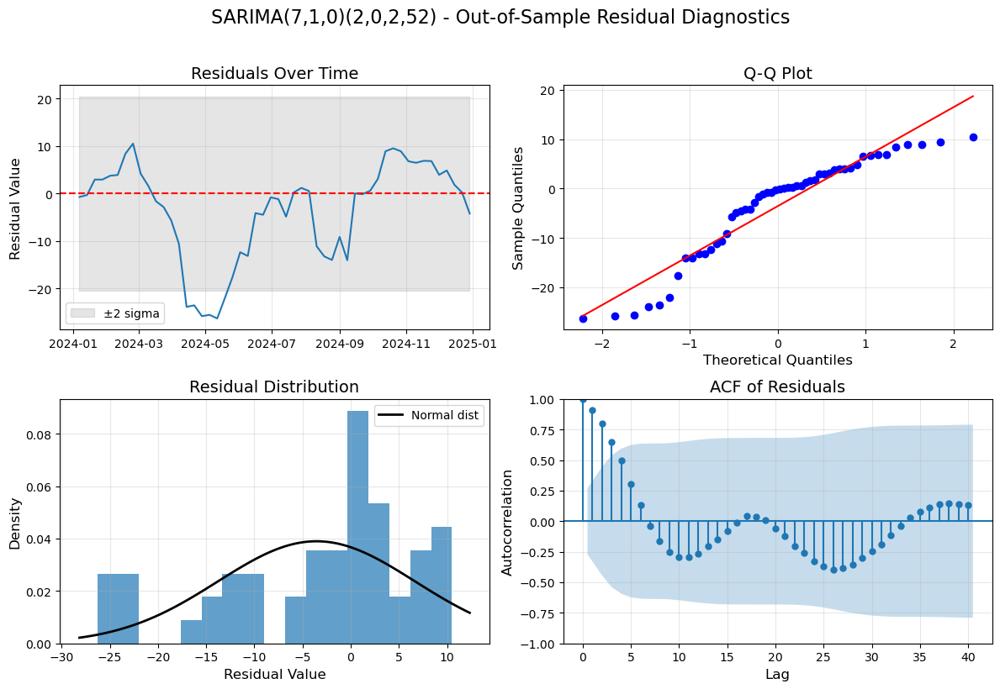

In [125]:
testset_resid_analysis = out_of_sample_resid_analysis(
    train_recent15,
    test_preprocessed,
    order=(7,1,1),
    seasonal_order=(2,0,2,52),
    #exog_train=exog_train,
    #exog_test=exog_test,
    model_name='SARIMA(7,1,1)(2,0,2,52)',
    run_hetero=True
)  

=== Out-of-Sample Residual Analysis: SARIMA(7,1,1)(2,0,3,52) ===
Test set size: 52 observations

--- Out-of-Sample Forecast Accuracy ---
RMSE: 10.568
MAE:  7.585
MAPE: 0.39%
R²:   0.566
95% CI coverage: 90.4% (ideal: 95%)


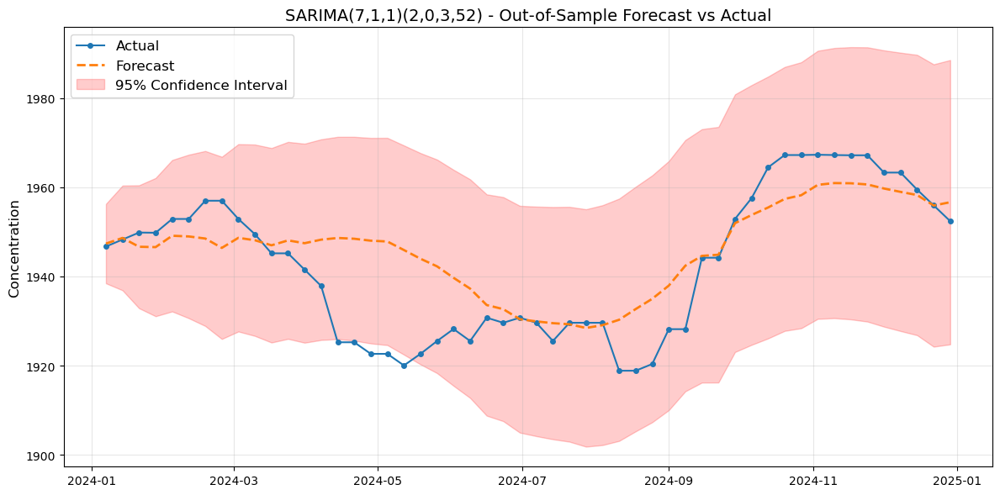


--- Residual Statistical Properties ---
Mean: -3.40601
Std:  10.10211
Skew: -0.873
Kurtosis: -0.182

--- Normality Tests ---
Shapiro-Wilk: p = 0.0004
Jarque-Bera:  p = 0.0410

--- Autocorrelation Diagnostics ---
Ljung-Box Test (H0: No autocorrelation)
  Lag  1: p = 0.0000 ***
  Lag  4: p = 0.0000 ***
  Lag 13: p = 0.0000 ***
  Lag 26: p = 0.0000 ***

"⚠"  Significant autocorrelation detected at lags: [1, 4, 13, 26]

--- Stationarity Check ---
ADF test on residuals: p = 0.0274
"✅" Residuals are stationary

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.1876
White test:    p = 0.0161
"✅" Constant variance

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0000***
	Lag 8: p-value = 0.0000***
	Lag 12: p-value = 0.0000***
	Lag 26: p-value = 0.0000***


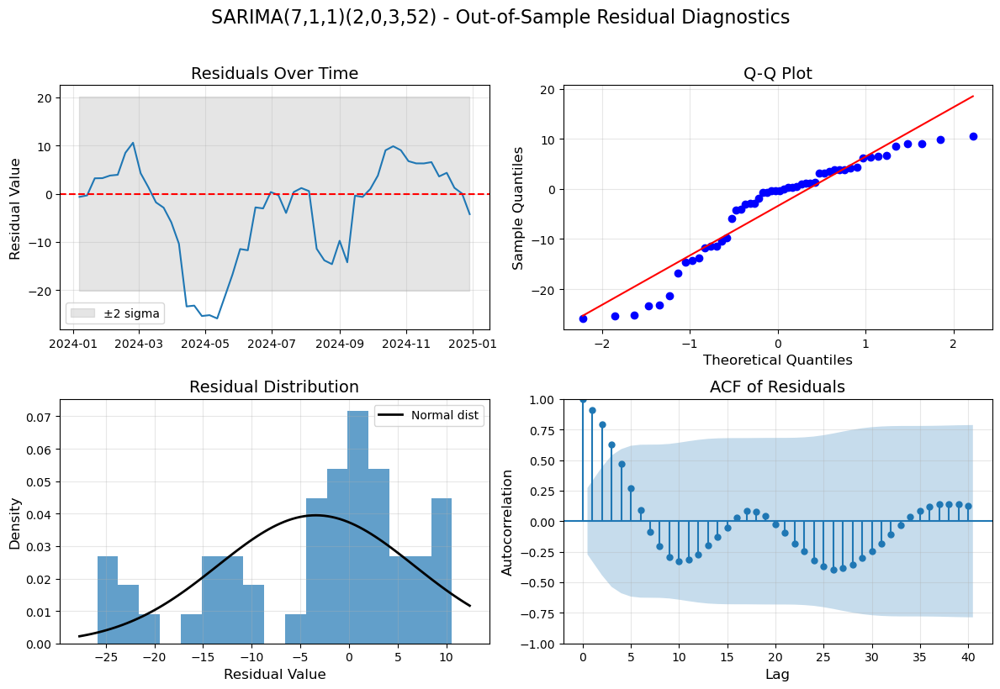

In [170]:
testset_resid_analysis = out_of_sample_resid_analysis(
    train_recent15,
    test_preprocessed,
    order=(7,1,1),
    seasonal_order=(2,0,3,52),
    #exog_train=exog_train,
    #exog_test=exog_test,
    model_name='SARIMA(7,1,1)(2,0,3,52)',
    run_hetero=True
) 

=== Out-of-Sample Residual Analysis: SARIMA(5,1,1)(1,0,0,7) + FT(K=2) ===
Test set size: 52 observations

--- Out-of-Sample Forecast Accuracy ---
RMSE: 12.908
MAE:  9.843
MAPE: 0.51%
R²:   0.352
95% CI coverage: 82.7% (ideal: 95%)


C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


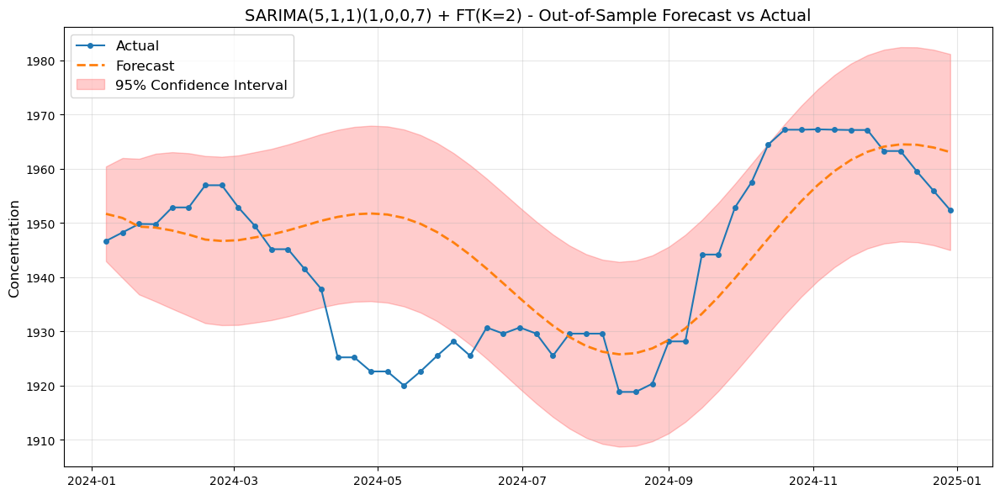


--- Residual Statistical Properties ---
Mean: -3.48190
Std:  12.55130
Skew: -0.593
Kurtosis: -0.232

--- Normality Tests ---
Shapiro-Wilk: p = 0.0236
Jarque-Bera:  p = 0.2128

--- Autocorrelation Diagnostics ---
Ljung-Box Test (H0: No autocorrelation)
  Lag  1: p = 0.0000 ***
  Lag  4: p = 0.0000 ***
  Lag 13: p = 0.0000 ***
  Lag 26: p = 0.0000 ***

"⚠"  Significant autocorrelation detected at lags: [1, 4, 13, 26]

--- Stationarity Check ---
ADF test on residuals: p = 0.0814
"⚠"  Residuals may not be stationary

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.2791
White test:    p = 0.0255
"✅" Constant variance

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0000***
	Lag 8: p-value = 0.0000***
	Lag 12: p-value = 0.0000***
	Lag 26: p-value = 0.0000***


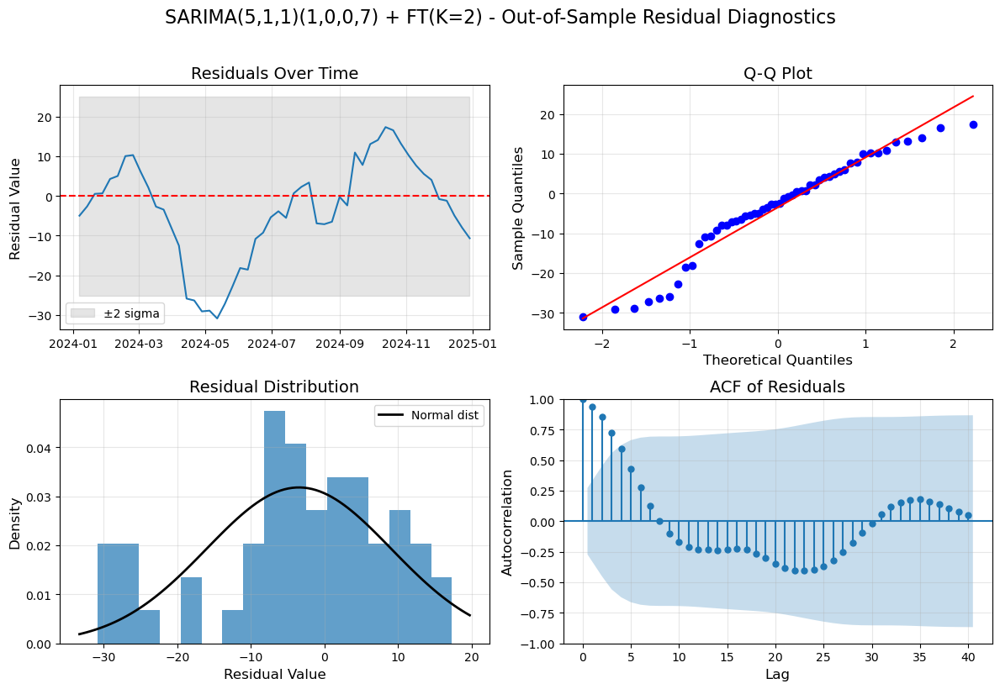

In [149]:
testset_resid_analysis = out_of_sample_resid_analysis(
    train_recent15,
    test_preprocessed,
    order=(5,1,1),
    seasonal_order=(1,0,0,7),
    exog_train=exog_train15_K2,
    exog_test=exog_test_K2,
    model_name='SARIMA(5,1,1)(1,0,0,7) + FT(K=2)',
    run_hetero=True
)  

=== Out-of-Sample Residual Analysis: SARIMA(7,1,1)(2,0,3,52) + FT(K=4) ===
Test set size: 52 observations



C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


--- Out-of-Sample Forecast Accuracy ---
RMSE: 12.662
MAE:  9.506
MAPE: 0.49%
R²:   0.377
95% CI coverage: 82.7% (ideal: 95%)


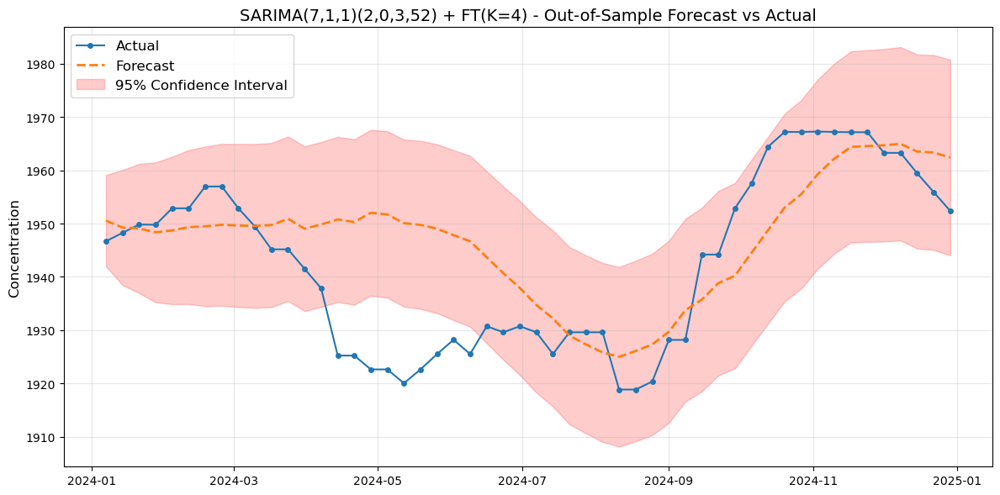


--- Residual Statistical Properties ---
Mean: -4.35966
Std:  12.00341
Skew: -0.633
Kurtosis: -0.220

--- Normality Tests ---
Shapiro-Wilk: p = 0.0110
Jarque-Bera:  p = 0.1748

--- Autocorrelation Diagnostics ---
Ljung-Box Test (H0: No autocorrelation)
  Lag  1: p = 0.0000 ***
  Lag  4: p = 0.0000 ***
  Lag 13: p = 0.0000 ***
  Lag 26: p = 0.0000 ***

"⚠"  Significant autocorrelation detected at lags: [1, 4, 13, 26]

--- Stationarity Check ---
ADF test on residuals: p = 0.2067
"⚠"  Residuals may not be stationary

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.2258
White test:    p = 0.0107
"✅" Constant variance

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0000***
	Lag 8: p-value = 0.0000***
	Lag 12: p-value = 0.0000***
	Lag 26: p-value = 0.0000***


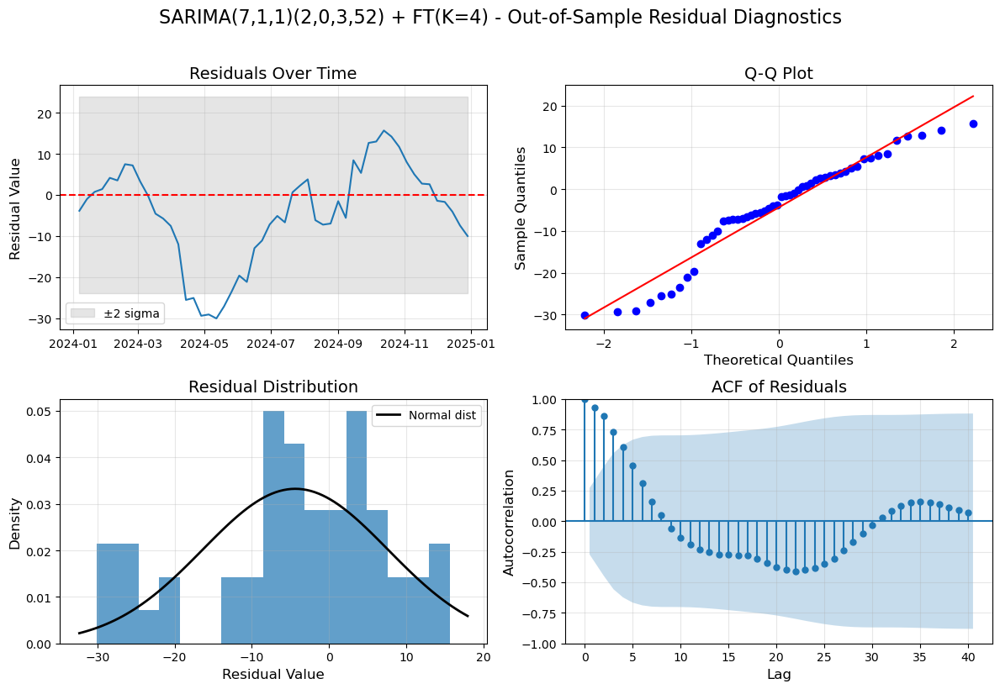

In [183]:
testset_resid_analysis = out_of_sample_resid_analysis(
    train_recent15,
    test_preprocessed,
    order=(7,1,1),
    seasonal_order=(2,0,3,52),
    exog_train=exog_train15_K4,
    exog_test=exog_test_K4,
    model_name='SARIMA(7,1,1)(2,0,3,52) + FT(K=4)',
    run_hetero=True
)  

=== Out-of-Sample Residual Analysis: SARIMA(7,1,7)(1,0,1,52) ===
Test set size: 52 observations



C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\aplor\anaconda3\envs\NewEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


--- Out-of-Sample Forecast Accuracy ---
RMSE: 10.360
MAE:  8.394
MAPE: 0.43%
R²:   0.583
95% CI coverage: 94.2% (ideal: 95%)


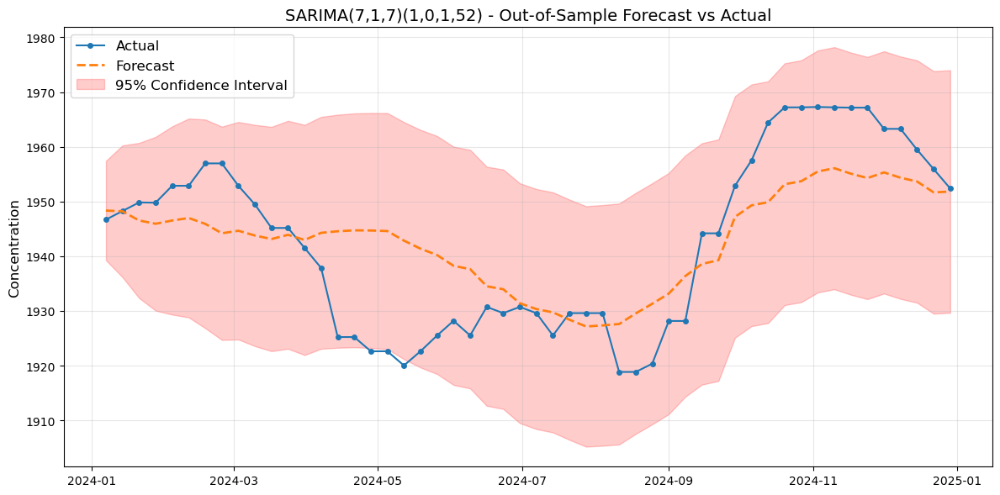


--- Residual Statistical Properties ---
Mean: -0.38495
Std:  10.45416
Skew: -0.640
Kurtosis: -0.456

--- Normality Tests ---
Shapiro-Wilk: p = 0.0081
Jarque-Bera:  p = 0.1391

--- Autocorrelation Diagnostics ---
Ljung-Box Test (H0: No autocorrelation)
  Lag  1: p = 0.0000 ***
  Lag  4: p = 0.0000 ***
  Lag 13: p = 0.0000 ***
  Lag 26: p = 0.0000 ***

"⚠"  Significant autocorrelation detected at lags: [1, 4, 13, 26]

--- Stationarity Check ---
ADF test on residuals: p = 0.0814
"⚠"  Residuals may not be stationary

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.6801
White test:    p = 0.1885
"✅" Constant variance

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0000***
	Lag 8: p-value = 0.0000***
	Lag 12: p-value = 0.0000***
	Lag 26: p-value = 0.0000***


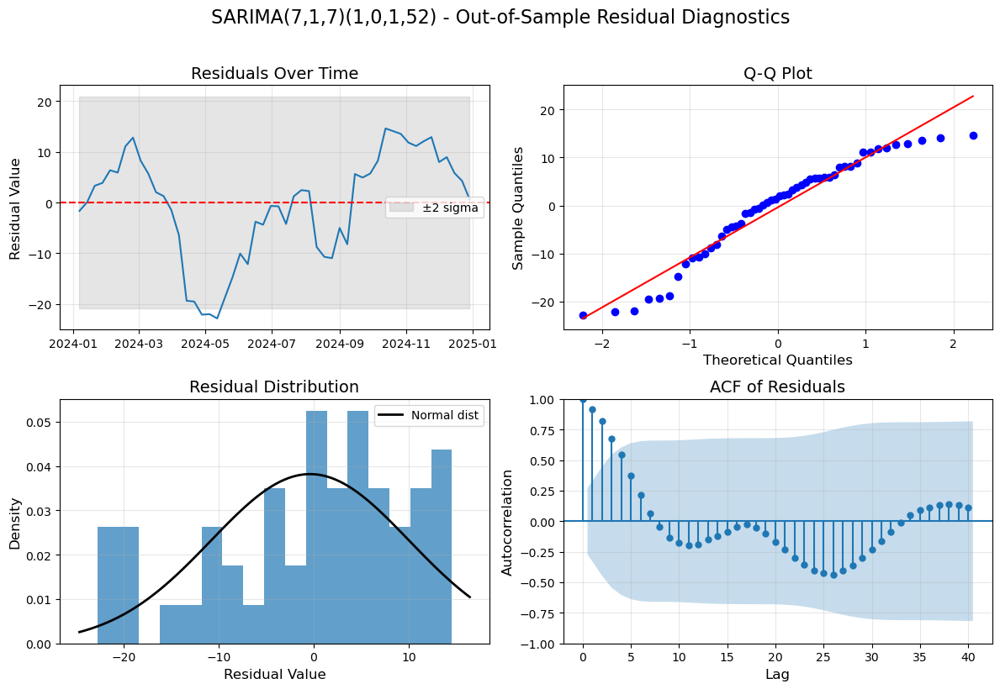

In [162]:
testset_resid_analysis = out_of_sample_resid_analysis(
    train_recent15,
    test_preprocessed,
    order=(7,1,7),
    seasonal_order=(1,0,1,52),
    #exog_train=exog_train,
    #exog_test=exog_test,
    model_name='SARIMA(7,1,7)(1,0,1,52)',
    run_hetero=True
)  

=== Out-of-Sample Residual Analysis: SARIMA(12,1,1)(2,0,1,52) ===
Test set size: 52 observations

--- Out-of-Sample Forecast Accuracy ---
RMSE: 11.319
MAE:  8.681
MAPE: 0.45%
R²:   0.502
95% CI coverage: 96.2% (ideal: 95%)


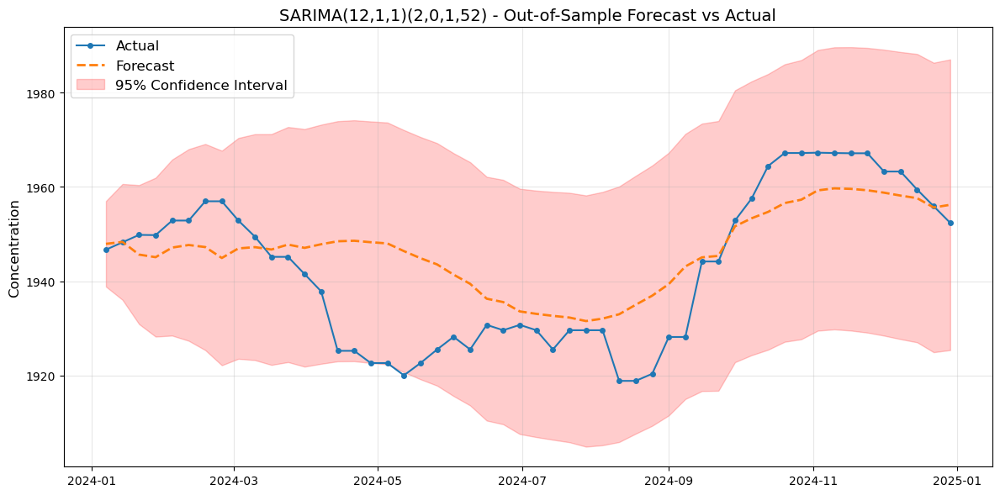


--- Residual Statistical Properties ---
Mean: -3.76168
Std:  10.77967
Skew: -0.634
Kurtosis: -0.593

--- Normality Tests ---
Shapiro-Wilk: p = 0.0044
Jarque-Bera:  p = 0.1223

--- Autocorrelation Diagnostics ---
Ljung-Box Test (H0: No autocorrelation)
  Lag  1: p = 0.0000 ***
  Lag  4: p = 0.0000 ***
  Lag 13: p = 0.0000 ***
  Lag 26: p = 0.0000 ***

"⚠"  Significant autocorrelation detected at lags: [1, 4, 13, 26]

--- Stationarity Check ---
ADF test on residuals: p = 0.0361
"✅" Residuals are stationary

--- Heteroscedasticity Tests ---
Breusch-Pagan: p = 0.2097
White test:    p = 0.0095
"✅" Constant variance

--- Volatility Clustering Diagnostics ---
Engle's ARCH Test (on squared residuals):
(H0: No ARCH effects (constant variance))
	Lag 1: p-value = 0.0000***
	Lag 4: p-value = 0.0000***
	Lag 8: p-value = 0.0000***
	Lag 12: p-value = 0.0000***
	Lag 26: p-value = 0.0000***


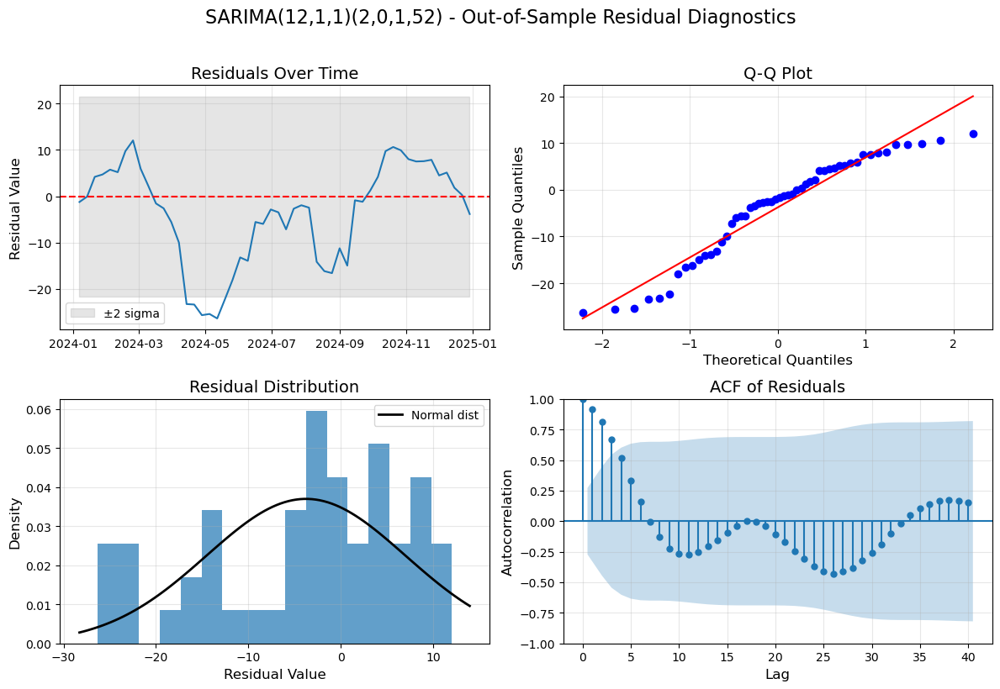

In [148]:
testset_resid_analysis = out_of_sample_resid_analysis(
    train_recent15,
    test_preprocessed,
    order=(12,1,1),
    seasonal_order=(2,0,1,52),
    #exog_train=exog_train,
    #exog_test=exog_test,
    model_name='SARIMA(12,1,1)(2,0,1,52)',
    run_hetero=True
)  

# Troubleshoot in-sample vs out-of-sample performance discrepencies 

In [129]:
# Check alignment of exogenous regressors 

print(exog_train15_K3.shape, exog_test_K3.shape)
print(list(exog_train15_K3.columns))
print(list(exog_test_K3.columns))
print(exog_train15_K3.index[0], exog_train15_K3.index[-1])
print(exog_test_K3.index[0], exog_test_K3.index[-1])

# quick alignment and NA check
assert exog_train15_K3.index.is_monotonic_increasing
assert exog_test_K3.index.is_monotonic_increasing
assert exog_train15_K3.columns.equals(exog_test_K3.columns)
assert exog_train15_K3.isna().sum().sum() == 0
assert exog_test_K3.isna().sum().sum() == 0

(783, 6) (52, 6)
['sin_1', 'cos_1', 'sin_2', 'cos_2', 'sin_3', 'cos_3']
['sin_1', 'cos_1', 'sin_2', 'cos_2', 'sin_3', 'cos_3']
2009-01-04 00:00:00 2023-12-31 00:00:00
2024-01-07 00:00:00 2024-12-29 00:00:00


In [130]:
# Verify exog construction correctness
# regenerate explicitly

exog_train = make_fourier_terms(train_recent15.index, period=52, K=3)
exog_test  = make_fourier_terms(test_preprocessed.index, period=52, K=3)
print('train rows', len(exog_train), 'train series', len(train_recent15))
print('test rows', len(exog_test), 'test series', len(test_preprocessed))
print('columns equal?', exog_train.columns.equals(exog_test.columns))

train rows 783 train series 783
test rows 52 test series 52
columns equal? True


The train and test exogenous regressors have the same number of Fourier columns and cover the same periods.  There are no misalignment issues.  

In [131]:
# One-step filtered RMSE (quick check)

mod = SARIMAX(train_recent15, order=(7,1,1), seasonal_order=(0,0,0,0), exog=exog_train15_K3)
res = mod.fit(disp=False)

pred = res.get_prediction(start=train_recent15.index[0],
                          end=train_recent15.index[-1],
                          exog=exog_train15_K2,
                          dynamic=False)
filtered = pred.predicted_mean.iloc[1:]
y = train_recent15.iloc[1:]
print(f'Filtered RMSE: {np.sqrt(mean_squared_error(y, filtered)):.3f}')

Filtered RMSE: 4.490


In [134]:
mod = SARIMAX(train_recent15, order=(7,1,1), seasonal_order=(2,0,3,52), exog=None)
res = mod.fit(disp=False)

pred = res.get_prediction(start=train_recent15.index[0],
                          end=train_recent15.index[-1],
                          #exog=exog_train15_K2,
                          dynamic=False)
filtered = pred.predicted_mean.iloc[1:]
y = train_recent15.iloc[1:]
print(f'Filtered RMSE: {np.sqrt(mean_squared_error(y, filtered)):.3f}')

LinAlgError: LU decomposition error.

# Evaluate best model out-of-sample residuals (predictions vs test set)

In [ ]:
# Evaluate SARIMA(7,1,0)(1,1,1,52) out-of-sample residuals (prediction vs test set)

sarima710111_outsample_resid, sarima710111_outsample_results = out_of_sample_resid_analysis(
    train_data=CH4_train_log_preprocessed,
    test_data=CH4_test_log_preprocessed,
    order=(7,1,0),
    seasonal_order=(1,1,1,52),
    model_name='SARIMA(7,1,0)(1,1,1,52)'
)

In [ ]:
# Evaluate SARIMA(1,1,1)(0,1,1,52) out-of-sample residuals (prediction vs test set)

sarima111011_outsample_resid, sarima111011_outsample_results = out_of_sample_resid_analysis(
    train_data=CH4_train_log_preprocessed,
    test_data=CH4_test_log_preprocessed,
    order=(1,1,1),
    seasonal_order=(0,1,1,52),
    model_name='SARIMA(1,1,1)(0,1,1,52)'
)

I will try a dummy regressor for the SARIMAX model to handle the significant spikes seen in the pre-1990 residuals.  A dummy regressor is a specific type of exogenous X variable that takes on either 1 (spike) or 0 (no spike) at all timepoints.  So, instead of letting the SARIMA model's AR or MA try to model the extreme outlier(s) or ending up in the error term, the dummy variable captures the magnitude of the unique event (shock).  

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.api import qqplot

def make_outlier_exog(index, outlier_dates):
    exog = pd.DataFrame(0, index=index, columns=[f'out_{i}' for i in range(len(outlier_dates))])
    for i, dt in enumerate(outlier_dates):
        if dt in index:
            exog.loc[dt, f'out_{i}'] = 1
        else:
            # if exact date not present (possible weekly freq), find nearest match
            nearest = index.get_indexer([dt], method='nearest')[0]
            exog.iloc[nearest, i] = 1
    return exog

initial = SARIMAX(CH4_train_log_preprocessed, 
                order=(7,1,0), 
                seasonal_order=(1,1,1,52),
                enforce_stationarity=True, 
                enforce_invertibility=True, 
                trend='c').fit(method='powell', disp=False)
init_resid = initial.resid.abs()
top_dates = init_resid.nlargest(5).index.tolist()
print(f'Top outlier dates: {top_dates}')

# create individual dummies, exogenous regressors, for the "outliers"
exog_train_indiv = make_outlier_exog(CH4_train_log_preprocessed.index, top_dates)

# the following code is the in_sample_resid_ansalysis function from model_evaluation.py, with included exog parameter
model = SARIMAX(CH4_train_log_preprocessed, 
                order=(7,1,0), 
                seasonal_order=(1,1,1,52),
                exog=exog_train_indiv,
                enforce_stationarity=True, 
                enforce_invertibility=True, 
                trend='c')
results = model.fit(method='powell', disp=False)
residuals = results.resid

top_resid_df = init_resid.nlargest(5).to_frame(name='|Residual|')
top_resid_df.index.name = 'Date'

# show both signed and absolute values
signed_resid = initial.resid.loc[top_resid_df.index]
top_resid_df['Residual (Signed)'] = signed_resid

print('\nTop 5 residuals:')
print(top_resid_df)

# --- Plot residual diagnostics ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
# Residual time series
axes[0,0].plot(residuals)
axes[0,0].set_title('Residuals over Time')
axes[0,0].set_xlabel('Time Index')
axes[0,0].set_ylabel('Residual Value')

# Histogram + KDE
axes[0,1].hist(residuals, bins=30, density=True, alpha=0.8, label='Hist')
residuals.plot(kind='kde', ax=axes[0,1], linewidth=2, alpha=0.6, label='KDE')

# Theoretical normal curve
x_vals = np.linspace(residuals.min(), residuals.max(), 200)
normal_pdf = stats.norm.pdf(x_vals, loc=residuals.mean(), scale=residuals.std())
axes[0,1].plot(x_vals, normal_pdf, color='r', linestyle='--', label='Normal PDF')
axes[0,1].set_title('Residual Distribution', fontsize=14)
axes[0,1].set_xlabel('Residual Value', fontsize=12)
axes[0,1].set_ylabel('Density', fontsize=12)
axes[0,1].legend()

# Q-Q plot
qqplot(residuals, line='s', ax=axes[1,0])
axes[1,0].set_title('Q-Q Plot', fontsize=14)
axes[1,0].set_xlabel('Theoretical Quantiles', fontsize=12)
axes[1,0].set_ylabel('Sample Quantiles', fontsize=12)

# ACF plot
plot_acf(residuals, lags=55, ax=axes[1,1])
axes[1,1].set_title('ACF of Residuals', fontsize=14)
axes[1,1].set_xlabel('Lag', fontsize=12)
axes[1,1].set_ylabel('Autocorrelation', fontsize=12)

plt.tight_layout()
plt.show()

# Ljung-Box test
lb = acorr_ljungbox(residuals, lags=[1,5,10,52], return_df=True)
print('\n--- Autocorrelation Diagnostics ---')
print('Ljung-Box Test')
print('H0: No autocorrelation up to specified lags')
for lag in [1,5,10,52]:
    print(f"lag {lag}: p = {lb.loc[lag, 'lb_pvalue']:.4f}")

In [ ]:
# Two major spikes remain.  I will check the top 5 residuals again to verify that they are the same two
# early spikes seen prior to the SARIMAX model fit with exogenous dummy variables.  

print('Top 5 Residuals for Magnitude, Before and After Dummy Variables')
print('\nBefore dummy variables:')
print(init_resid.abs().nlargest(5))
print('\nAfter dummy variables:')
print(residuals.abs().nlargest(5))

In [ ]:
# Verify that all outlier dates exist in the train set index

for dt in top_dates:
    print(dt, dt in CH4_train_log_preprocessed.index)

All outlier dates do exist in the train set and the dummy variables can be properly aligned to the exact observations in the train set.

In [ ]:
# Verify that the exogenous variable matrix is correct

print(exog_train_indiv.sum())               # each column should sum to 1
print(exog_train_indiv.loc[top_dates])

The exogenous matrix is correct.  Each dummy column corresponds to the correct specific date.

In [ ]:
# After fit `results`

# extract coefficients and standard errors for outlier dummy regressors
outlier_cols = [c for c in results.params.index if 'out' in c or 'outlier' in c]

# create a summary DataFrame
outlier_summary = pd.DataFrame({
    'Top Dates': top_dates,
    'Coefficient': results.params[outlier_cols],
    'Std. Error': results.bse[outlier_cols]  # standard errors of parameter estimates
})

# compute z-scores and two sided p-values
outlier_summary['z-score'] = outlier_summary['Coefficient'] / outlier_summary['Std. Error']
outlier_summary['p-value'] = 2 * (1 - stats.norm.cdf(np.abs(outlier_summary['z-score'])))

# pretty print
print('\nOutlier Regressor Coefficients Summary:')
print(outlier_summary.round(5).to_string())                 

The dummy variables captured two substantial residual shocks: 1988-12-18 (out_2) and 1985-11-24 (out_4)

In [ ]:
# Compare residuals before vs after including individual outlier dummies
plt.figure(figsize=(12, 4))
plt.plot(initial.resid.loc[:'1989'], label='Initial Residuals (no dummies)', linewidth=4, alpha=0.8)
plt.plot(results.resid.loc[:'1989'], label='Residuals (with individual dummies)', linestyle='--',alpha=1)

# Mark the top residual dates in red
plt.scatter(top_dates, results.resid.loc[top_dates], color='red', zorder=5, label='Outlier Dates')

plt.legend(fontsize=14)
plt.title('Residuals pre-1990: Before vs After Including Individual Outlier Dummies', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Residual Value', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Compare residuals before vs after including individual outlier dummies
plt.figure(figsize=(12, 4))
plt.plot(initial.resid.loc['1989':], label='Initial Residuals (no dummies)', linewidth=3, alpha=0.8)
plt.plot(results.resid.loc['1989':], label='Residuals (with individual dummies)', linestyle='--',alpha=1)

# Mark the top residual dates in red
# plt.scatter(top_dates, results.resid.loc[top_dates], color='red', zorder=5, label='Outlier Dates')

plt.legend(fontsize=14)
plt.title('Residuals post-1990: Before vs After Including Individual Outlier Dummies', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Residual Value', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(initial.resid.loc['1985':], label='Initial Residuals (no dummies)', linewidth=3, alpha=0.6)
plt.plot(results.resid.loc['1985':], label='Residuals (with individual dummies)', linestyle='--', alpha=1)

plt.legend(loc='lower right', fontsize=14)
plt.title('Residuals post-1985: Before vs After Including Individual Outlier Dummies', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Residual Value', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
def make_outlier_exog(index, outlier_dates):
    exog = pd.DataFrame(0, index=index, columns=[f'out_{i}' for i in range(len(outlier_dates))])
    for i, dt in enumerate(outlier_dates):
        if dt in index:
            exog.loc[dt, f'out_{i}'] = 1
        else:
            # if exact date not present (possible weekly freq), find nearest match
            nearest = index.get_indexer([dt], method='nearest')[0]
            exog.iloc[nearest, i] = 1
    return exog

initial = SARIMAX(CH4_train_log_preprocessed, 
                order=(7,1,0), 
                seasonal_order=(1,1,1,52),
                enforce_stationarity=True, 
                enforce_invertibility=True, 
                trend='c').fit(method='powell', disp=False)
init_resid = initial.resid.abs()
top_dates = init_resid.nlargest(5).index.tolist()
print(f'Top outlier dates: {top_dates}')

# create grouped dummy (one column) OR individual dummies
# grouped:
# exog_train_grouped = pd.DataFrame({'outlier_flag': 0}, index=train.index)
# exog_train_grouped.loc[top_dates, 'outlier_flag'] = 1

# create individual dummies
exog_train_indiv = make_outlier_exog(CH4_train_log_preprocessed.index, top_dates)

model = SARIMAX(CH4_train_log_preprocessed, 
                order=(7,1,0), 
                seasonal_order=(1,1,1,52),
                exog=exog_train_indiv,
                enforce_stationarity=True, 
                enforce_invertibility=True, 
                trend='c',
                initialization='diffuse')
results = model.fit(method='powell', disp=False)
residuals = results.resid

top_resid_df = init_resid.nlargest(5).to_frame(name='|Residual|')
top_resid_df.index.name = 'Date'

# show both signed and absolute values
signed_resid = initial.resid.loc[top_resid_df.index]
top_resid_df['Residual (Signed)'] = signed_resid

print('\nTop 5 residuals:')
print(top_resid_df)

# --- Plot residual diagnostics ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
# Residual time series
axes[0,0].plot(residuals)
axes[0,0].set_title('Residuals over Time')
axes[0,0].set_xlabel('Time Index')
axes[0,0].set_ylabel('Residual Value')

# Histogram + KDE
axes[0,1].hist(residuals, bins=30, density=True, alpha=0.8, label='Hist')
residuals.plot(kind='kde', ax=axes[0,1], linewidth=2, alpha=0.6, label='KDE')

# Theoretical normal curve
x_vals = np.linspace(residuals.min(), residuals.max(), 200)
normal_pdf = stats.norm.pdf(x_vals, loc=residuals.mean(), scale=residuals.std())
axes[0,1].plot(x_vals, normal_pdf, color='r', linestyle='--', label='Normal PDF')
axes[0,1].set_title('Residual Distribution', fontsize=14)
axes[0,1].set_xlabel('Residual Value', fontsize=12)
axes[0,1].set_ylabel('Density', fontsize=12)
axes[0,1].legend()

# Q-Q plot
qqplot(residuals, line='s', ax=axes[1,0])
axes[1,0].set_title('Q-Q Plot', fontsize=14)
axes[1,0].set_xlabel('Theoretical Quantiles', fontsize=12)
axes[1,0].set_ylabel('Sample Quantiles', fontsize=12)

# ACF plot
plot_acf(residuals, lags=55, ax=axes[1,1])
axes[1,1].set_title('ACF of Residuals', fontsize=14)
axes[1,1].set_xlabel('Lag', fontsize=12)
axes[1,1].set_ylabel('Autocorrelation', fontsize=12)

plt.tight_layout()
plt.show()

# Ljung-Box test
lb = acorr_ljungbox(residuals, lags=[1,5,10,52], return_df=True)
print('\n--- Autocorrelation Diagnostics ---')
print('Ljung-Box Test')
print('H0: No autocorrelation up to specified lags')
for lag in [1,5,10,52]:
    print(f"lag {lag}: p = {lb.loc[lag, 'lb_pvalue']:.4f}")

# Save Best Model Parameters for Production

In [ ]:
import json
from datetime import datetime

model_config_best = {
    'model_type': 'SARIMAX',
    'order': (7,1,0),
    'seasonal_order': (1,1,1,52),
    'trend': 'c',
    'enforce_stationarity': True,
    'enforce_invertibility': True,
    'training_data_range': {
        'start': CH4_train_log_preprocessed.index[0].strftime('%Y-%m-%d'),
        'end': CH4_train_log_preprocessed.index[-1].strftime('%Y-%m-%d')
    },
    'data_points': len(CH4_train_log_preprocessed),
    'data_frequency': 'W',  # Weekly
    'transformation': 'log',  # using log-transformed data
    'preprocessor_version': '1.0',  
    'cv_performance': {  # Store best CV metrics
        'RMSE_mean': 0.010205,
        'MAE_mean': 0.007906
    },
    'test_performance': {  # From final validation
        'RMSE_log': 0.004636,
        'MAE_log': 0.003592,
        'RMSE_original': 8.983181,
        'MAE_original': 6.971737
    },
    'selection_rationale': 'Best overall RMSE in both CV and test validation',
    'fit_method': 'powell',
    'saved_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
}

model_config_best_simple = {
    'model_type': 'SARIMAX',
    'order': (1,1,1),
    'seasonal_order': (0,1,1,52),
    'trend': 'c',
    'enforce_stationarity': True,
    'enforce_invertibility': True,
    'training_data_range': {
        'start': CH4_train_log_preprocessed.index[0].strftime('%Y-%m-%d'),
        'end': CH4_train_log_preprocessed.index[-1].strftime('%Y-%m-%d')
    },
    'data_points': len(CH4_train_log_preprocessed),
    'data_frequency': 'W',  # Weekly
    'transformation': 'log',  # using log-transformed data
    'preprocessor_version': '1.0',  
    'cv_performance': {  # Store best CV metrics
        'RMSE_mean': 0.010530,
        'MAE_mean': 0.008095
    },
    'test_performance': {
        'RMSE_log': 0.005097,
        'MAE_log': 0.003489,
        'RMSE_original': 9.868525,
        'MAE_original': 6.768671
    },
    'selection_rationale': 'Pareto-optimal balance of simplicity and performance',
    'fit_method': 'powell',
    'saved_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
}

# save as JSON file
with open('../results/CH4_train_best_model_config.json', 'w') as f:
    json.dump(model_config_best, f, indent=2)

with open('../results/CH4_train_best_simple_model_config.json', 'w') as f:
    json.dump(model_config_best_simple, f, indent=2)

print('CH4 best model configuration saved.  Re-fit in next notebook.')
print('CH4 best simple model configuration saved.  Re-fit in next notebook.')

**NOTE** 
- Check deepseek regarding saving the models for the entire dataset, not just the train set
- may want to produce the plots and analyze residuals of prediction vs test set in this notebook and treat the next notebook as just forecasting.  